In [1]:
# ============================================================
# Importamos las librerias a utilizar
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from scipy.sparse import hstack, csr_matrix
from sklearn.feature_selection import SelectKBest, chi2

In [2]:
# ============================================================
# Montar drive
# ============================================================
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
# ============================================================
# Definimos las rutas para el orden del proyecto
# ============================================================
from pathlib import Path
import sys
PROJECT_PATH = Path("/content/drive/MyDrive/TFM_Restaurantes")
DATA_PATH = PROJECT_PATH / "data"
RAW_PATH = DATA_PATH / "raw"
PROCESSED_PATH = DATA_PATH / "processed"
MODELS_PATH = PROJECT_PATH / "models"
SRC_PATH = PROJECT_PATH / "src"

In [4]:
# ============================================================
# Creamos las carpetas necesarias para el proyecto
# ============================================================
from pathlib import Path
folders = [DATA_PATH,RAW_PATH,PROCESSED_PATH,MODELS_PATH,SRC_PATH]

##Creamos las carpetas si no existen
for folder in folders:
    folder.mkdir(parents=True, exist_ok=True)

In [5]:
# ============================================================
# AGREGAR LA CARPETA SRC AL PATH(solo en caso que no la reconozca)
# ============================================================
if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

print("Ruta agregada correctamente:")
print(SRC_PATH)

Ruta agregada correctamente:
/content/drive/MyDrive/TFM_Restaurantes/src


In [6]:
# =================================================================
# Cargar datos: Creamos una funcion para realizar la carga de datos
# =================================================================
def cargar_datos():
    restaurants = pd.read_csv(RAW_PATH / "restaurants.csv")
    reviews = pd.read_csv(RAW_PATH / "reviews.csv")
    return restaurants, reviews

# =================================================================
# Cargar datos: Creamos una funcion para realizar la carga de datos
# =================================================================
df_restaurantes, df_reviews = cargar_datos()

### Preliminar: Auditoria de los datos

In [7]:
# ============================================================
# Auditoria: Revisando la calidad de los datos
# ============================================================

##Importamos y actualizamos las librerias a utilizar
import importlib
import auditoria
importlib.reload(auditoria)

from auditoria import *

In [8]:
##Mostramos la informacion
display(pd.concat([resumen_dataset(df_restaurantes, "Restaurantes"),resumen_dataset(df_reviews, "Reviews")]))


,Dataset,Filas,Columnas,Duplicados,Valores nulos
0,Restaurantes,9871,13,0,2
0,Reviews,1258435,9,0,503369


In [9]:
##Dimensiones
print("Restaurants")
print(obtener_dimensiones(df_restaurantes))

print("Reviews")
print(obtener_dimensiones(df_reviews))

Restaurants
(9871, 13)
Reviews
(1258435, 9)


In [10]:
##Tipo de datos
display(obtener_tipos(df_restaurantes))
display(obtener_tipos(df_reviews))

,Tipo de dato
id,int64
name,object
tag,object
x,float64
y,float64
district,object
IDDIST,object
direction,object
stars,int64
n_reviews,int64


,Tipo de dato
id_review,object
review,object
title,object
score,float64
likes,int64
id_nick,object
service,float64
date,object
platform,object


**Limpieza y Transformación de Variables**

Al revisar la distribución de los datos, se identificaron las siguientes necesidades de optimizacion y corrección de tipos:

1. **Conversión de Precios a Numéricos:** Las variables `min_price` y `max_price` (precios mínimos y máximos de los platos) se encuentran registradas como tipo `object` (texto). Se transformaran a formato numerico para permitir analisis estadisticos.
2. **Renombrado de Coordenadas:** Las variables `x` e `y` corresponden a coordenadas geograficas, por lo que se renombraran a `longitud` y `latitud` respectivamente para mejorar la claridad del dataset.
3. **Escalamiento de Calificaciones (`star`):** La columna `star` representa el promedio de estrellas otorgado por los clientes. Para estandarizarla con las metricas habituales de las plataformas, se ajustara estrictamente a la escala del **1 al 5**.


In [11]:
##Quiatamos espacios en blanco
df_restaurantes['min_price'] = df_restaurantes['min_price'].str.strip()
df_restaurantes['max_price'] = df_restaurantes['max_price'].str.strip()

##Reemplazamos los vacios por nan
df_restaurantes['min_price'] = df_restaurantes['min_price'].replace('', np.nan)
df_restaurantes['max_price'] = df_restaurantes['max_price'].replace('',np.nan)

##Cambiamos las variables al tipo float
df_restaurantes['min_price']=df_restaurantes['min_price'].astype('float64')
df_restaurantes['max_price']=df_restaurantes['max_price'].astype('float64')

##Renombramos las variables
df_restaurantes = df_restaurantes.rename(columns={'x':'longitude','y':'latitude'})

##Ajustar escala de estrellas del restaurante
df_restaurantes['stars']=df_restaurantes['stars'].astype('float64')
df_restaurantes['stars']=df_restaurantes['stars']/10

In [12]:
##Valores nulos
display(obtener_nulos(df_restaurantes))
display(obtener_nulos(df_reviews))

,Variable,Nulos,Porcentaje
max_price,max_price,9356,94.78
min_price,min_price,9356,94.78
tag,tag,0,0.00
name,name,0,0.00
id,id,0,0.00
latitude,latitude,0,0.00
longitude,longitude,0,0.00
district,district,0,0.00
IDDIST,IDDIST,0,0.00
stars,stars,0,0.00


,Variable,Nulos,Porcentaje
review,review,503369,40.0
id_review,id_review,0,0.0
title,title,0,0.0
score,score,0,0.0
likes,likes,0,0.0
id_nick,id_nick,0,0.0
service,service,0,0.0
date,date,0,0.0
platform,platform,0,0.0


In [13]:
##Duplicados
print(f"Duplicados restaurants: "
    f"{obtener_duplicados(df_restaurantes)}")

print(f"Duplicados reviews: "
    f"{obtener_duplicados(df_reviews)}")

Duplicados restaurants: 0
Duplicados reviews: 0


In [14]:
##Valores unicos
display(obtener_unicos(df_restaurantes))
display(obtener_unicos(df_reviews))

,Variable,Valores únicos
0,id,9871
1,name,8867
2,tag,760
3,longitude,9674
4,latitude,9572
5,district,44
6,IDDIST,44
7,direction,8943
8,stars,36
9,n_reviews,1222


,Variable,Valores únicos
0,id_review,1258435
1,review,569877
2,title,45816
3,score,5
4,likes,18
5,id_nick,562003
6,service,9803
7,date,25
8,platform,2


### **1 Análisis exploratorio**

#### **1.1. Data: Restaurantes**

**1.1.1.Vista general del dataset**

In [15]:
df_restaurantes.head()

,id,name,tag,longitude,latitude,district,IDDIST,direction,stars,n_reviews,min_price,max_price,platform
0,71036,Restaurante Statera,$$$$||Peruana||contemporánea||Opciones sin glu...,-12.115658,-77.043440,MIRAFLORES,150122,"Avenida Mariscal La Mar 463, Miraflores, Lima ...",5.0,130,80.0,280.0,tripadvisor
1,72471,Maras Restaurante,$$$$||Peruana||Latina||Internacional||,-12.092106,-77.024660,SAN ISIDRO,150131,Amador Merino Reyna 551 Esquina Calle Begonias...,4.5,675,158.0,237.0,tripadvisor
2,29667,Ventarrón Restaurante Chiclayano & Barra,$$ - $$$||Peruana||Mariscos||Gastropub||,-12.149373,-77.020706,BARRANCO,150104,"Avenida Grau 276 Frente al Parque Municipal, L...",4.5,304,12.0,72.0,tripadvisor
3,144186,Aji 555 Real Thai Cuisine,$$ - $$$||Asiática||Tailandesa||Apto para vege...,-12.105918,-76.992340,SAN BORJA,150130,"Av. San Luis 2879 San Borja, Lima 41 Perú",4.5,361,20.0,83.0,tripadvisor
4,124291,Cebicheria La Mar,$$ - $$$||Peruana||Latina||Mariscos||,-12.113314,-77.045400,MIRAFLORES,150122,"Av. La Mar 770 Miraflores, Lima Perú",4.5,4864,79.0,99.0,tripadvisor


El conjunto de datos contiene informacion descriptiva de los restaurantes, incluyendo ubicación geografica, distrito, plataforma de origen y variables relacionadas con su valoración. Estas características seran la base para el analisis exploratorio y posteriormente para la construccion del modelo predictivo.

In [16]:
##Generamos un diccionario con el significado de cada columna
diccionario = pd.DataFrame({
    "Variable": [
        "restaurant_id",
        "restaurant_name",
        "district",
        "platform",
        "latitude",
        "longitude",
        "stars"
    ],
    "Descripcion": [
        "Identificador del restaurante",
        "Nombre del restaurante",
        "Distrito",
        "Plataforma de origen",
        "Latitud",
        "Longitud",
        "Calificación promedio otorgada por los clientes"
    ]
})

display(diccionario)

,Variable,Descripcion
0,restaurant_id,Identificador del restaurante
1,restaurant_name,Nombre del restaurante
2,district,Distrito
3,platform,Plataforma de origen
4,latitude,Latitud
5,longitude,Longitud
6,stars,Calificación promedio otorgada por los clientes


In [17]:
df_restaurantes.columns.tolist()

['id',
 'name',
 'tag',
 'longitude',
 'latitude',
 'district',
 'IDDIST',
 'direction',
 'stars',
 'n_reviews',
 'min_price',
 'max_price',
 'platform']

**1.1.2.Variables Numericas**

In [18]:
##Variables numericas en restaurantes
variables_numericas = df_restaurantes.select_dtypes(include="number").columns.tolist()
print(f"Variables numericas:  {variables_numericas}")

Variables numericas:  ['id', 'longitude', 'latitude', 'stars', 'n_reviews', 'min_price', 'max_price']


In [19]:
df_restaurantes.describe().T

,count,mean,std,min,25%,50%,75%,max
id,9871.0,150016.367845,86165.694053,381.000000,75180.000000,150177.00000,223721.000000,299996.000000
longitude,9871.0,-12.070199,0.110974,-13.072287,-12.120806,-12.07653,-12.027366,-10.696140
latitude,9871.0,-77.012905,0.088848,-77.779250,-77.062016,-77.02917,-76.985263,-75.203779
stars,9871.0,4.163215,0.586342,1.000000,4.000000,4.20000,4.500000,5.000000
n_reviews,9871.0,224.967075,1227.820663,1.000000,4.000000,23.00000,143.000000,59144.000000
min_price,515.0,27.227184,28.996727,2.000000,10.000000,18.00000,36.000000,197.000000
max_price,515.0,97.842718,365.899755,5.000000,31.000000,50.00000,92.500000,7895.000000


**Calificaciones y popularidad:**
Revisaremos las variables stars y n_reviews segun su distrubucion para apreciar como impacta en la dta de restaurantes.

In [20]:
# Variables de análisis
variables_analisis = ["stars","n_reviews"]
df_restaurantes[variables_analisis].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
stars,9871.0,4.16,0.59,1.0,4.0,4.2,4.5,5.0
n_reviews,9871.0,224.97,1227.82,1.0,4.0,23.0,143.0,59144.0


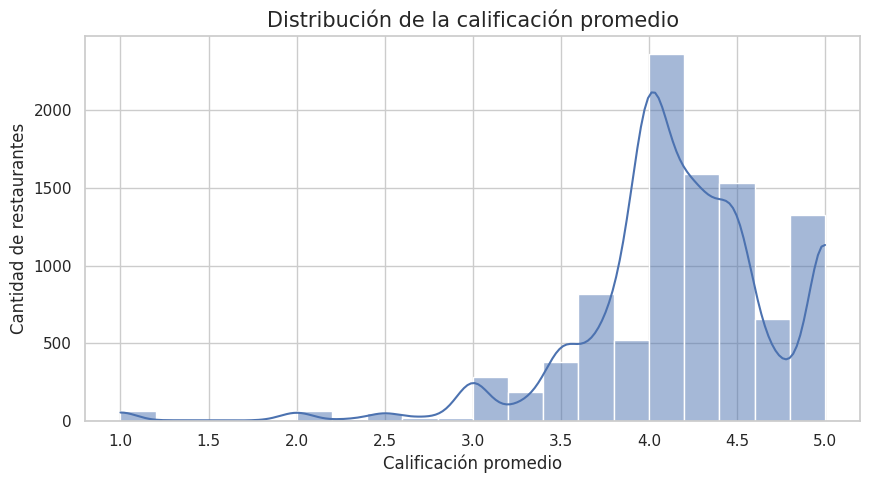

In [21]:
##Configuracion para las graficas
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,5)
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 12

##Distribucion grafica stars
plt.figure()
sns.histplot(data=df_restaurantes,x="stars",bins=20,kde=True)

plt.title("Distribución de la calificación promedio")
plt.xlabel("Calificación promedio")
plt.ylabel("Cantidad de restaurantes")
plt.show()

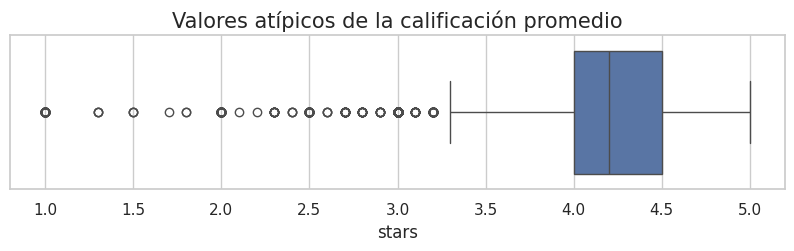

In [22]:
# Valores atipicos stars
plt.figure(figsize=(10,2))
sns.boxplot(x=df_restaurantes["stars"])
plt.title("Valores atípicos de la calificación promedio")
plt.show()

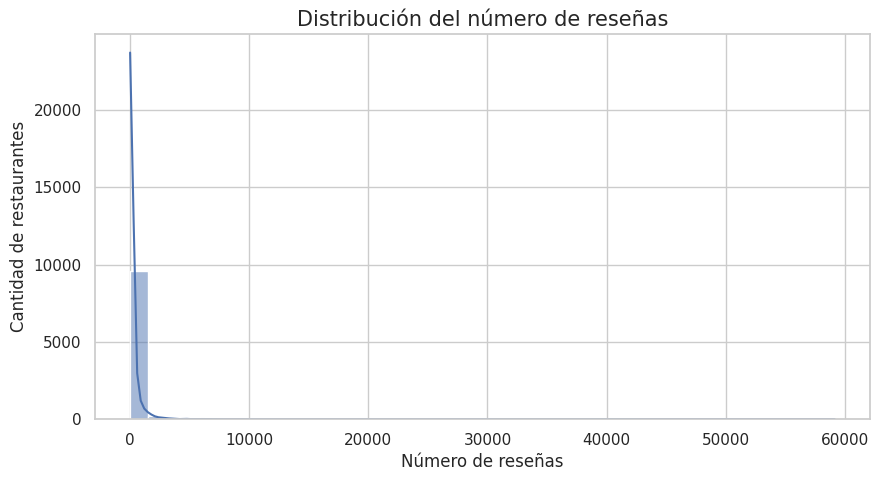

In [23]:
##Grafica Nro de reviews
plt.figure()
sns.histplot(data=df_restaurantes,x="n_reviews",bins=40,kde=True)
plt.title("Distribución del número de reseñas")
plt.xlabel("Número de reseñas")
plt.ylabel("Cantidad de restaurantes")
plt.show()

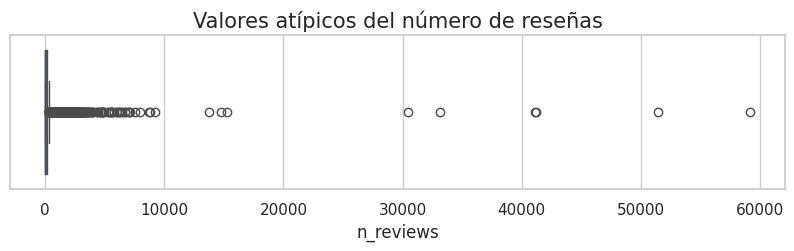

In [24]:
# Valores atipicos n_reviews
plt.figure(figsize=(10,2))
sns.boxplot(x=df_restaurantes["n_reviews"])
plt.title("Valores atípicos del número de reseñas")
plt.show()

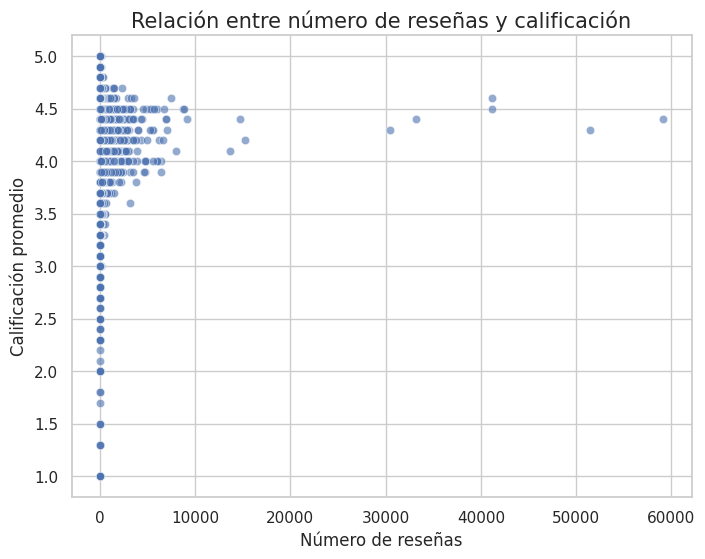

In [25]:
##Grafica relacion entre stars y n_reviews
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_restaurantes,x="n_reviews",y="stars",alpha=0.6)
plt.title("Relación entre número de reseñas y calificación")
plt.xlabel("Número de reseñas")
plt.ylabel("Calificación promedio")
plt.show()

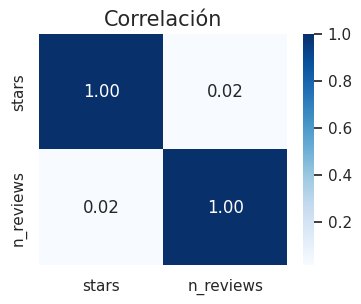

In [26]:
##Correlacion
correlacion = df_restaurantes[["stars", "n_reviews"]].corr()
plt.figure(figsize=(4,3))
sns.heatmap(correlacion,
            annot=True,
            cmap="Blues",
            fmt=".2f")
plt.title("Correlación")
plt.show()

**Conclusiones: stars y n_reviews**

El analisis en conjunto de los datos estadisticos y las distribuciones de un total de **9,871 restaurantes** revela comportamientos criticos, los cuales se procede a detallar lo siguiente:

**1. Distribución y Valores Atípicos de la Calificación Promedio (`stars`)**
El analisis del histograma combinado con su diagrama de caja (*boxplot*) permite analizar la variable de la siguiente manera:

*   **Rango Intercuartilico:** El 50% central de los restaurantes se centraliza en un rango alto, estrictamente entre las **4.0 estrellas (Q1)** y las **4.5 estrellas (Q3)**, teniendo su mediana firmemente posicionada en **4.2 estrellas**.
*   **Ausencia de Outliers Superiores:** El bigote derecho se extiende limpiamente hasta las **5.0 estrellas**. Esto confirma que al tener calificaciones perfectas entra dentro del comportamiento esperado y común del dataset, reforzando la naturaleza bimodal observada en el histograma.
*   **Presencia Masiva de Outliers Inferiores:** El bigote izquierdo termina aproximadamente en las **3.3 estrellas**. Cualquier restaurante con una calificación inferior a este umbral es considerado estadisticamente un **valor atípico (*outlier*)**.Asimismo,la grafica muestra una hilera densa de puntos hacia la izquierda demostrando que aunque existen restaurantes con pesimas calificaciones, representan anomalias o casos muy aislados dentro de la muestra total.

**2. Distribución y Sesgo Extremo de la Popularidad (`n_reviews`)**
La combinacion del histograma y el diagrama de caja para el número de reseñas expone visualmente un escenario de **asimetría positiva radical (distribución de cola larga)**:

*   **Compresion Total en la Base:** En el boxplot, la caja que representa el 50% de los datos (Q1 a Q3) junto con sus bigotes estandar están completamente "aplastados" contra el origen (cercano del cero).
*   **Dispersion y "Outliers" Extremos:** Inmediatamente despues del limite del bigote superior (unas pocas cientos de reseñas), comienza una cantidad masiva de valores atipicos.

**🛠️ Conclusión para el Preprocesamiento:**  
*   **Para `stars`:** Los *outliers* detectados corresponden a calificaciones bajas. No se recomienda eliminarlos de forma arbitraria, ya que representan la poca informacion disponible sobre "malos restaurantes", lo cual es vital si el objetivo futuro es clasificar o predecir la calidad de un establecimiento gastronomico.
*   **Para `n_reviews`:** El boxplot confirma de forma contundente que los valores extremos no son errores de registro, sino restaurantes reales hiperpopulares. Trabajar con la variable en su estado original rompería los supuestos de muchos algoritmos. **Es estrictamente obligatorio aplicar una transformación logaritmica `log1p(n_reviews)`** en el preprocesamiento para comprimir esta dispersion, estabilizar la varianza y permitir que los modelos matematicos procesen la popularidad de manera equitativa.


**Analisis de precios**


In [27]:
##Variables de analisis
variables_precios = ["min_price","max_price"]
df_restaurantes[variables_precios].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
min_price,515.0,27.23,29.0,2.0,10.0,18.0,36.0,197.0
max_price,515.0,97.84,365.9,5.0,31.0,50.0,92.5,7895.0


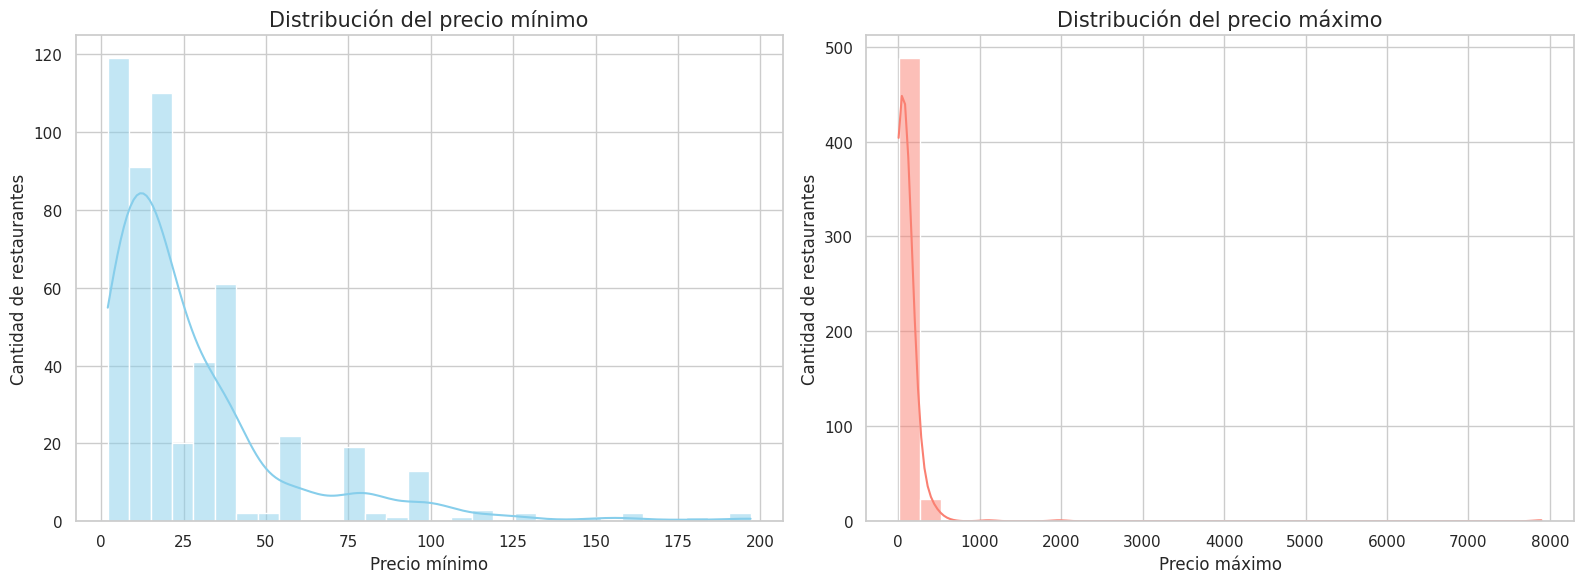

In [28]:
# Crear una figura con 1 fila y 2 columnas
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

## Grafica del precio minimo (Columna 1)
sns.histplot(data=df_restaurantes, x="min_price", bins=30, kde=True, ax=axes[0], color="skyblue")
axes[0].set_title("Distribución del precio mínimo")
axes[0].set_xlabel("Precio mínimo")
axes[0].set_ylabel("Cantidad de restaurantes")

## Grafica del precio maximo (Columna 2)
sns.histplot(data=df_restaurantes, x="max_price", bins=30, kde=True, ax=axes[1], color="salmon")
axes[1].set_title("Distribución del precio máximo")
axes[1].set_xlabel("Precio máximo")
axes[1].set_ylabel("Cantidad de restaurantes")

# Ajustar el espacio entre los gráficos para que no se superpongan
plt.tight_layout()
plt.show()


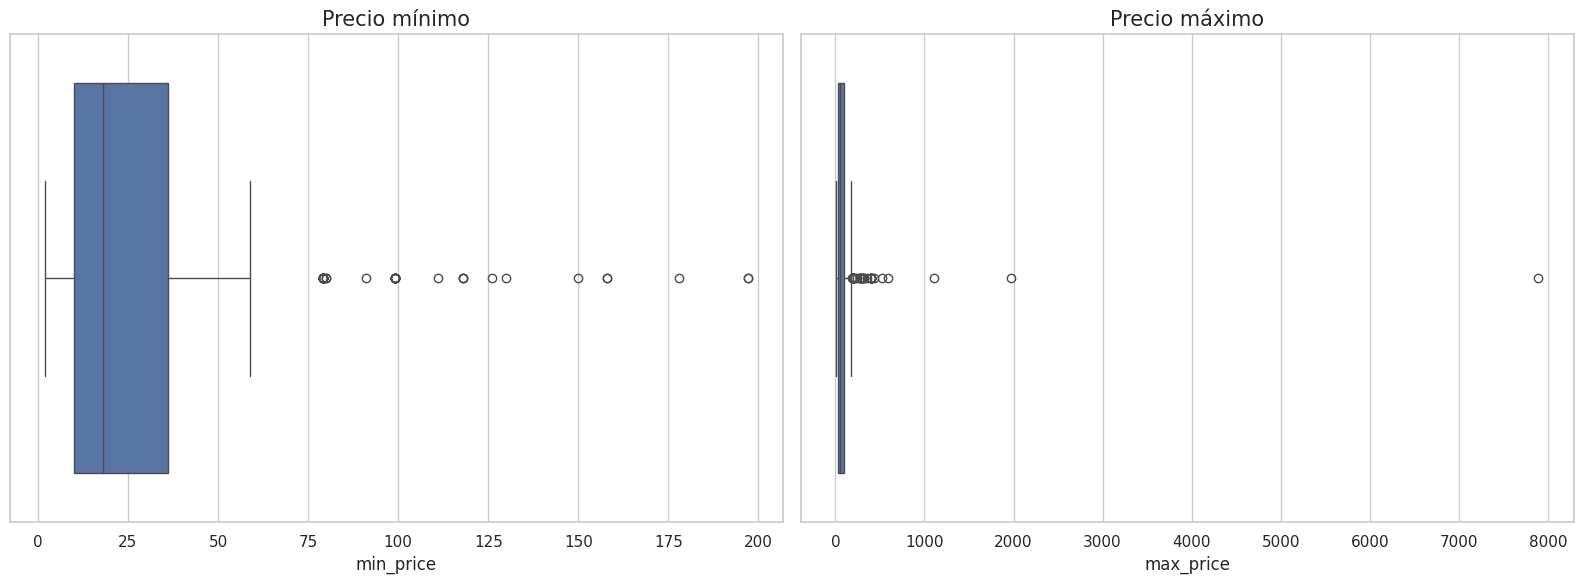

In [29]:
# Crear una figura con 1 fila y 2 columnas
fig, axes = plt.subplots(1,2, figsize=(16,6))
sns.boxplot(x=df_restaurantes["min_price"],ax=axes[0])
axes[0].set_title("Precio mínimo")
sns.boxplot(x=df_restaurantes["max_price"],ax=axes[1])
axes[1].set_title("Precio máximo")
plt.tight_layout()
plt.show()

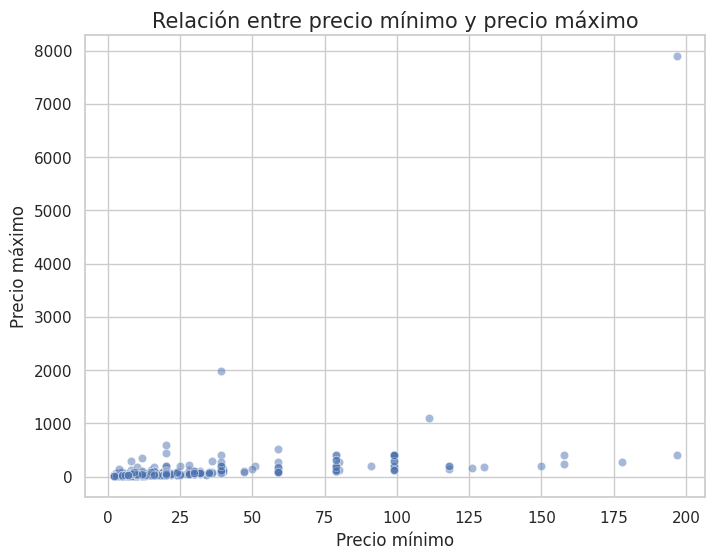

In [30]:
##Relacion entre precios
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_restaurantes,x="min_price",y="max_price",alpha=0.5)
plt.title("Relación entre precio mínimo y precio máximo")
plt.xlabel("Precio mínimo")
plt.ylabel("Precio máximo")
plt.show()

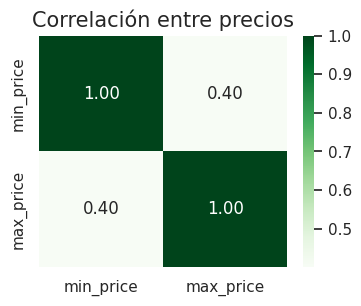

,min_price,max_price
min_price,1.000000,0.402018
max_price,0.402018,1.000000


In [31]:
##Correlacion
corr_precios = df_restaurantes[["min_price","max_price"]].corr()
plt.figure(figsize=(4,3))
sns.heatmap(corr_precios,
            annot=True,
            cmap="Greens",
            fmt=".2f")
plt.title("Correlación entre precios")
plt.show()
display(corr_precios)

**Conclusiones para precios (`min_price` y `max_price`)**

**1. Comportamiento y Estructura de `min_price`**
* **Estabilidad**: Presenta un comportamiento controlado y predecible, con una media de **27.23** y una mediana de **18.0**.
* **Distribucion**: Muestra un sesgo positivo natural (asimetria a la derecha), concentrando la gran mayoria de los restaurantes entre las **2 y 40 unidades**.
* **Valores Altos**: Los valores atipicos detectados en el boxplot se extienden de manera continua hasta un máximo de **197.0**, lo que representa restaurantes de gama alta.

**2. Comportamiento y Estructura de `max_price` (Presencia de Outliers)**
* **Distorsion Masiva**: La variable se encuentra severamente afectada por ruido estadistico debido a un valor extremo cercano a **8000** (mientras que el 75% de los datos está por debajo de **92.5**).
* **Impacto en Metricas**: Este unico outlier infla artificialmente la media a **97.84** y dispara la desviacion estándar a **365.9**.
* **Impacto Visual**: En el histograma y el boxplot, este valor rompe por completo las escalas de los ejes, comprimiendo visualmente el 99% de los datos restantes contra el origen y ocultando su verdadera distribucion.

**3. Relación entre Variables (Matriz de Correlación)**
* **Asociación Débil**: El coeficiente de Pearson arroja un valor de **0.40** (correlacion positiva moderada-baja).
* **Efecto de los Datos Atípicos**: Esta baja linealidad no se debe necesariamente a la falta de relación entre los precios mínimos y máximos, sino a la sensibilidad del coeficiente de Pearson ante el outlier extremo de ~8000, el cual debilita artificialmente el indicador.


Distribucion estadistica del precio promedio


,avg_price
count,515.00
mean,62.53
std,189.24
min,3.50
25%,22.00
50%,35.00
75%,60.00
max,4046.00




Distribucion grafica del precio promedio


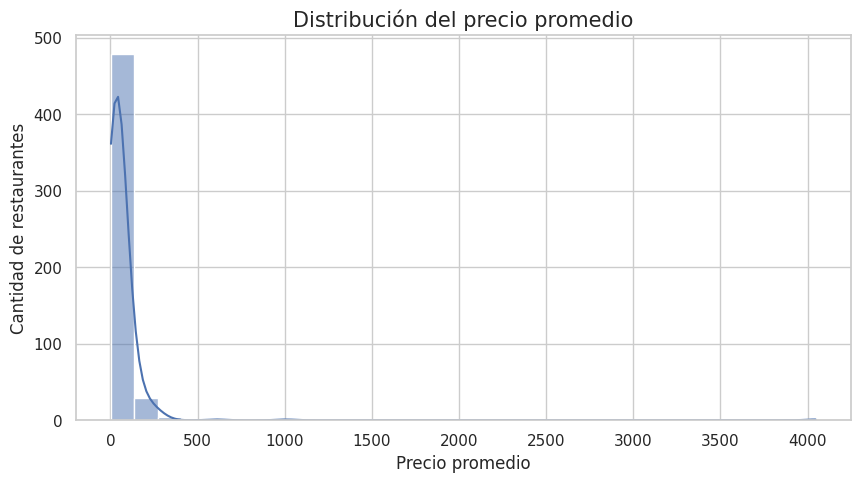

In [32]:
##Agregamos una nueva variable al dataframe (precio promedio)
df_restaurantes["avg_price"] = (df_restaurantes["min_price"] + df_restaurantes["max_price"]) / 2

##Revisamos la distribucion
print("Distribucion estadistica del precio promedio")
display(df_restaurantes[["avg_price"]].describe().round(2))
print("\n" + "="*50 + "\n") ##Separador entre la tabla y el grafico

##Graficamos la distrubucion
print("Distribucion grafica del precio promedio")
plt.figure(figsize=(10,5))
sns.histplot(
    data=df_restaurantes,x="avg_price",bins=30,kde=True)
plt.title("Distribución del precio promedio")
plt.xlabel("Precio promedio")
plt.ylabel("Cantidad de restaurantes")
plt.show()

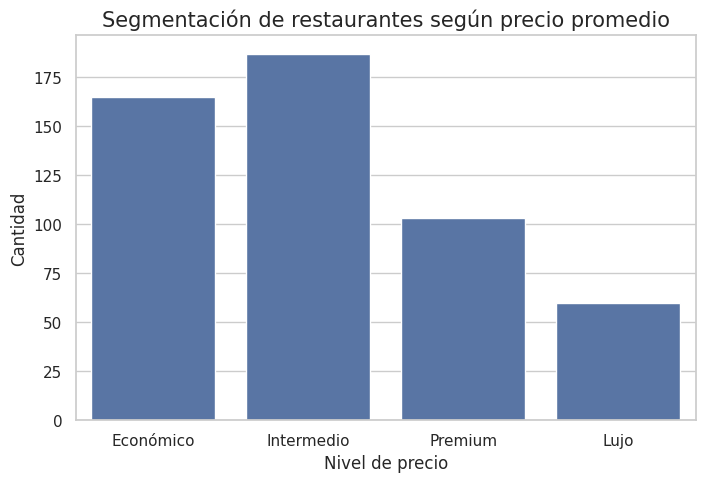

In [33]:
##Agregamos una segmentacion por nivel de precios
df_restaurantes["price_level"] = pd.cut(df_restaurantes["avg_price"],bins=[0, 25, 50, 100, df_restaurantes["avg_price"].max()],
    labels=["Económico","Intermedio","Premium","Lujo"])

##Revisamos la distribucion grafica
plt.figure(figsize=(8,5))
sns.countplot(data=df_restaurantes,x="price_level",order=["Económico","Intermedio","Premium","Lujo"])
plt.title("Segmentación de restaurantes según precio promedio")
plt.xlabel("Nivel de precio")
plt.ylabel("Cantidad")
plt.show()

**Conclusiones para el analisis de precios**
* **Fuerte Asimetria y Concentracion de Mercado**: Los precios presentan una distribución marcadamente asimétrica hacia la derecha (sesgo positivo). La gran mayoría de los restaurantes se concentran estrictamente en el segmento de bajo presupuesto.

* **Estructura de Precios Distorsionada por Valores Extremos**: Contrario a lo esperado, la relación lineal entre el precio mínimo y máximo es **moderada-baja (Pearson = 0.40)**. Esto demuestra que la estructura de precios está severamente afectada por ruidos y anomalías, destacando un outlier crítico en `max_price` cercano a las **8,000 unidades** que rompe las escalas de los histogramas y boxplots.

* **Riesgo Operativo en `avg_price`**: La nueva variable `avg_price` **no resume adecuadamente** el nivel de precios general en este momento. Al ser un promedio simple, absorbe directamente el impacto del outlier de ~8,000, lo que genera una media inflada que distorsionará cualquier sistema de recomendación o modelo predictivo si se utiliza sin una limpieza previa.

* **Variable agrupada `price level`**: Nos ayudara a segmentar la data de cara al dashboard final relacionado a este proyecto.



**1.1.3.Variables Categoricas**

In [34]:
##Revisamos distribucion estadistica de variables categoricas
df_restaurantes.describe(exclude=np.number).round(1).T

,count,unique,top,freq
name,9871,8867,Norky's,52
tag,9871,760,Restaurante,5097
district,9871,44,,1082
IDDIST,9871,44,Out,1082
direction,9871,8943,,73
platform,9871,2,googleplaces,8155
price_level,515,4,Intermedio,187


**Podemos observar que los valores que mas se repiten para district y direction estan vacios por lo cual procederemos a reemplazar esos valores por nan.**

In [35]:
##Reemplazar los valores vacios como NAN
df_restaurantes['district'] = df_restaurantes['district'].replace(' ', np.nan)
df_restaurantes['direction'] = df_restaurantes['direction'].replace(' ', np.nan)

**1.1.3.1. Variables Categorica: District**

In [36]:
# Distribución de restaurantes por district
district_count = (df_restaurantes["district"].value_counts().sort_values(ascending=False))
display(district_count)

,count
district,
MIRAFLORES,602
LIMA,423
SANTIAGO DE SURCO,411
COMAS,349
LOS OLIVOS,321
SAN ISIDRO,320
CHORRILLOS,303
JESUS MARIA,296
ATE,294


/tmp/ipykernel_2754/206987407.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=district_count.head(15).index,y=district_count.head(15).values,palette="viridis")


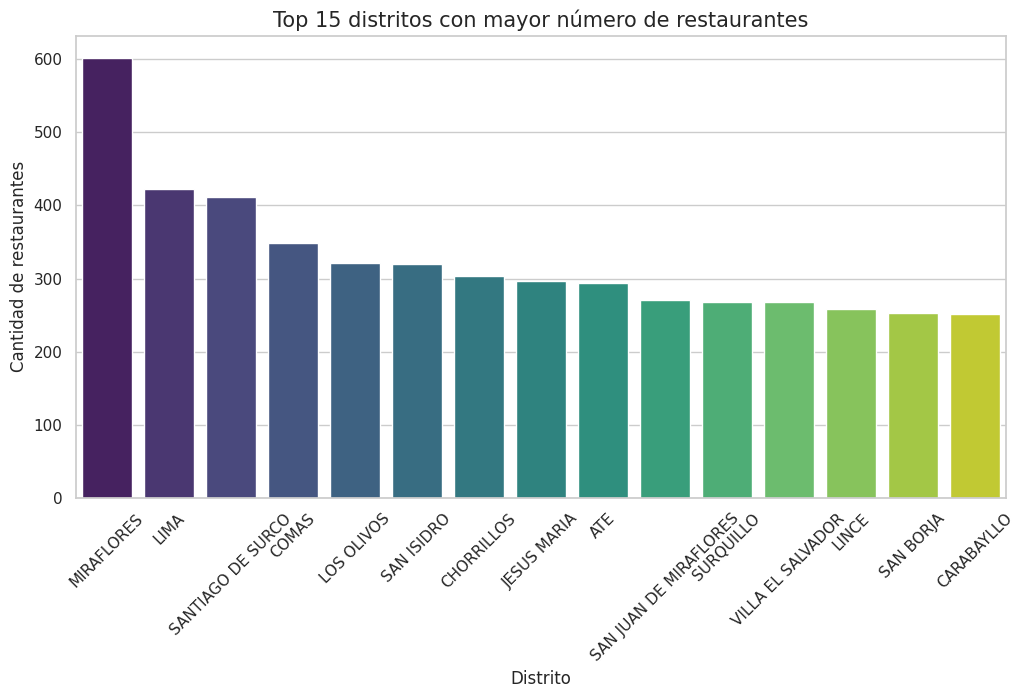

In [37]:
##Distribucion grafica
plt.figure(figsize=(12,6))
sns.barplot(x=district_count.head(15).index,y=district_count.head(15).values,palette="viridis")
plt.title("Top 15 distritos con mayor número de restaurantes")
plt.xlabel("Distrito")
plt.ylabel("Cantidad de restaurantes")
plt.xticks(rotation=45)
plt.show()

Este analisis evalua un conjunto de datos de **8,789 restaurantes** distribuidos en **43 distritos** de Lima Metropolitana, con el objetivo de diagnosticar la equidad en la distribución del sector. Ahora procederemos a responder ciertas preguntas claves para el sector gastronomico:

**1. ¿Qué distritos concentran la mayor oferta gastronómica?**

La mayor oferta gastronomica se encuentra liderada de forma contundente por **Miraflores**, seguido por un segundo bloque de distritos consolidados:
* **Líder Absoluto:** **Miraflores** con **602 restaurantes**, despegándose drásticamente del resto de la muestra.
* **Top Cluster Comercial:** **Lima Cercado (423)** y **Santiago de Surco (411)** completan el podio de alta densidad.
* **Nivel Periferico de Alta Densidad:** Distritos populosos como **Comas (349)** y **Los Olivos (321)** emergen con una fuerte presencia de oferta gastronomica dirigida a mercados residenciales masivos.

**2. ¿Existe una fuerte concentración en pocas zonas?**

**Sí, existe una marcada centralización.**
* El **Top 3 de distritos** (Miraflores, Lima, Surco) acumula **1,436 locales**, lo que equivale al **16.34%** de la oferta total de la provincia.
* El **Top 5** (sumando Comas y Los Olivos) captura el **24.0%** de todo el mercado gastronómico.
* La gráfica de barras evidencia visualmente este comportamiento ya que muestra una caida abrupta desde el primer puesto y genera una larga "cola" descendente hacia los distritos con menor actividad (como los balnearios del sur, que cierran la tabla con menos de 20 locales cada uno).

**3. ¿Podría esto generar un sesgo geográfico?**

**Definitivamente existe un sesgo geografico critico.** Este sesgo se manifiesta en dos niveles:
* **Sesgo Socioeconómico y Turístico:** Distritos pequeños en superficie pero con altos ingresos per capita o flujo turístico (Miraflores y San Isidro sumando 922 locales) igualan o superan la oferta de distritos gigantescos y sumamente poblados.
* **Sesgo de Datos en Modelado:** Los posibles resultados del impacto de esta variable en el modelo estarán fuertemente sesgados hacia las dinámicas comerciales del centro de Lima y Lima Top. El modelo "conocerá" muy bien el comportamiento de Miraflores pero tendrá un subregistro severo para predecir el comportamiento en distritos del extremo inferior de la tabla (ej. Rímac, Santa Anita o balnearios).

**1.1.3.2. Variables Categorica: Tag**

In [38]:
tag_count = (df_restaurantes["tag"].value_counts())
display(tag_count.head(20))

,count
tag,
Restaurante,5097
Restaurante peruano,562
Pizzería,258
,251
Restaurante especializado en pollo,237
Restaurante de comida rápida,229
Cafetería,214
Restaurante chino,187
Marisquería,169


/tmp/ipykernel_2754/1076661192.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tag_count.head(15).index,y=tag_count.head(15).values,palette="magma")


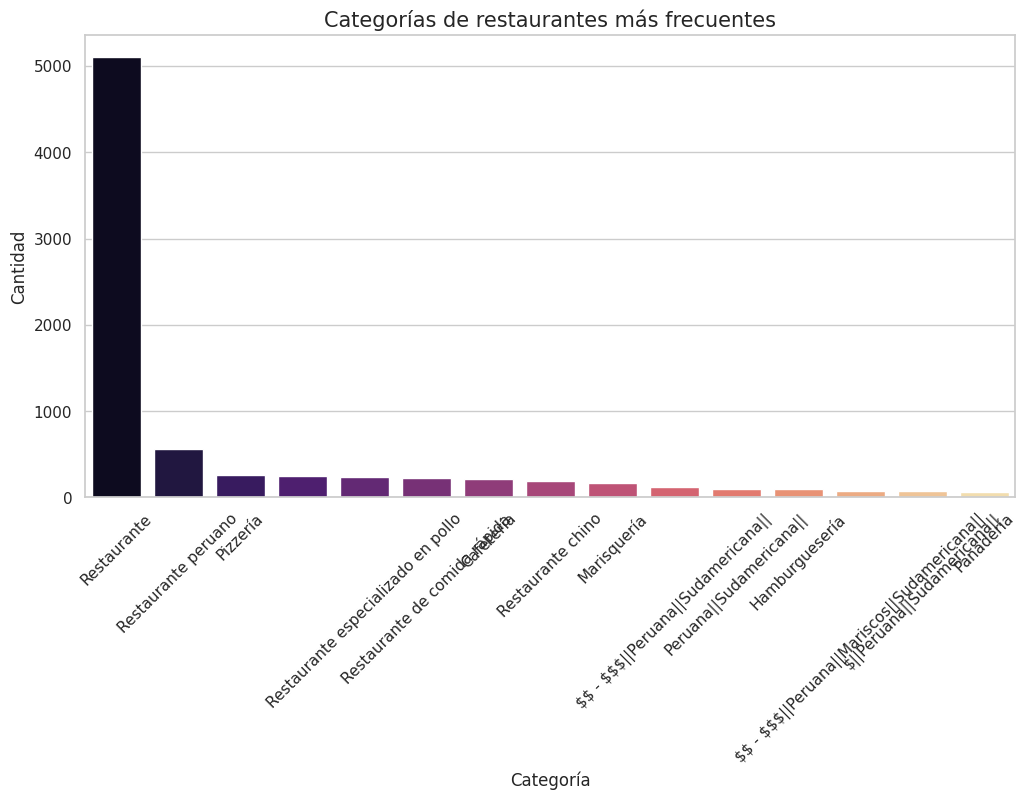

In [39]:
##Graficamos las categorias de restaurantes mas frecuentes
plt.figure(figsize=(12,6))
sns.barplot(x=tag_count.head(15).index,y=tag_count.head(15).values,palette="magma")
plt.title("Categorías de restaurantes más frecuentes")
plt.xlabel("Categoría")
plt.ylabel("Cantidad")
plt.xticks(rotation=45)
plt.show()

La visualización de **Categorías de restaurantes mas frecuentes** expone un comportamiento clásico de **distribución exponencial extrema** , motivado principalmente por deficiencias estructurales en las etiquetas:

**Anomalías Visuales y Metodológicas Detectadas**

* **La Anomalia del "Eje Monolítico":** La barra de la categoria **"Restaurante"** rompe por completo la escala del gráfico al superar las 5,000 unidades. Visualmente, reduce a proporciones casi imperceptibles al resto de especialidades.
* **Superposición de Etiquetas en el Eje X:** Debido a la longitud de los textos raw del scraping (ej. `$$ - $$$||Peruana||Sudamericana||`), los nombres de los distritos y categorías de la mitad hacia adelante se **cruzan y solapan horizontalmente**. Esto hace que el eje X sea ilegible en un entorno de reporte ejecutivo.
* **Ocultamiento de Información Relevante:** Al tener una barra tan gigantesca al inicio, las sutiles diferencias comerciales entre sectores clave (como la diferencia entre la comida rápida y las cafeterías) quedan aplanadas visualmente por la escala del eje Y.



**1.1.3.3. Variables Categorica: Plataforma**

Distribucion de la variable categorica platform


,count
platform,
googleplaces,8155
tripadvisor,1716




Distribucion grafica variable categorica platform


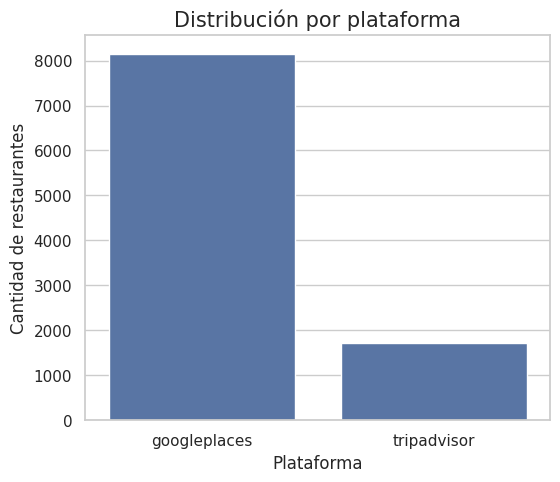

In [40]:
##Revisamos la distribucion
print("Distribucion de la variable categorica platform")
platform_count = (df_restaurantes["platform"].value_counts())
display(platform_count)
print("\n" + "="*50 + "\n") ##Separador entre la tabla y el grafico

##Graficamos la distrubucion
print("Distribucion grafica variable categorica platform")
plt.figure(figsize=(6,5))
sns.countplot(data=df_restaurantes,x="platform",order=platform_count.index)
plt.title("Distribución por plataforma")
plt.xlabel("Plataforma")
plt.ylabel("Cantidad de restaurantes")
plt.show()

Esta visualización revela la composición del origen de los datos, mostrando una clara predominancia de una fuente sobre la otra:

* **Google Places:** Registra el volumen mayoritario con más de **8,000 restaurantes**.
* **TripAdvisor:** Aporta una muestra complementaria cercana a los **1,700 establecimientos**.

**1.1.3.4. Variables Categorica: price_level**

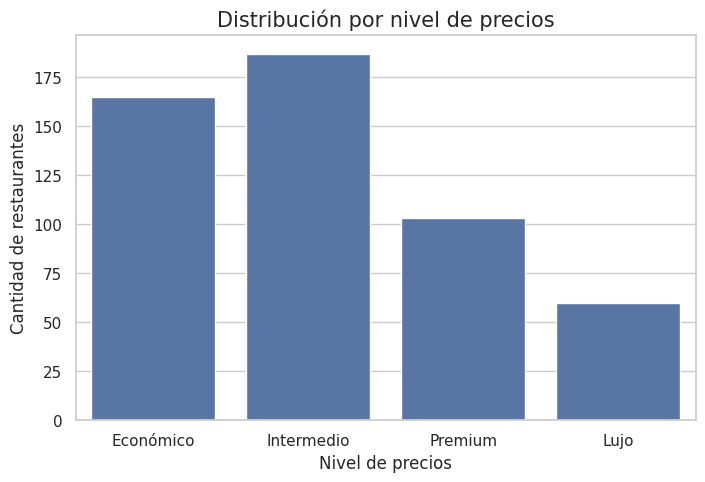

In [41]:
##Grafica de la variable categorica price level
plt.figure(figsize=(8,5))
sns.countplot(data=df_restaurantes,x="price_level",order=["Económico","Intermedio","Premium","Lujo"])
plt.title("Distribución por nivel de precios")
plt.xlabel("Nivel de precios")
plt.ylabel("Cantidad de restaurantes")
plt.show()

Esta visualizacion clasifica un subconjunto de restaurantes en cuatro segmentos comerciales: **Económico**, **Intermedio**, **Premium** y **Lujo**. El gráfico revela una distribución escalonada que describe el posicionamiento comercial de la oferta etiquetada.

**Hallazgos Principales del Perfil de Precios**

* **Predominio del Segmento Medio-Bajo:** El mercado está fuertemente dominado por los niveles **Intermedio** (aproximadamente 185 restaurantes) y **Económico** (aproximadamente 165 restaurantes). Juntos forman la base del consumo masivo y cotidiano en Lima.
* **Contracción en la Gama Alta:** Se observa un descenso progresivo hacia los segmentos de mayor poder adquisitivo. El sector **Premium** registra cerca de 102 locales, mientras que el segmento de **Lujo** se reduce a unos 60 establecimientos.
* **Comportamiento Esperado del Mercado:** Esta estructura piramidal es saludable y típica en economías comerciales, donde la oferta exclusiva (Lujo/Premium) es más escasa y se concentra habitualmente en los distritos líderes detectados al inicio del informe (Miraflores y San Isidro).

In [42]:
##Revisamos los valores faltantes o vacios
variables_cat = ["name","tag","district","direction","platform","price_level"]
pd.DataFrame({
    "Variable": variables_cat,
    "Valores nulos": [
        df_restaurantes[col].isnull().sum()
        for col in variables_cat]})

,Variable,Valores nulos
0,name,0
1,tag,0
2,district,1082
3,direction,73
4,platform,0
5,price_level,9356


El analisis realizado sobre las variables categoricas revela el estado de completitud del dataset. Esto nos permite cuantificar con precision matemática los sesgos e inconsistencias identificadas en las visualizaciones previas:

**Hallazgos Críticos**

**1. Variable `price_level` (9,356 valores nulos)**
* **Gravedad:** Crítica.
* **Impacto:** Esta es la variable con mayor pérdida de datos. Explica por qué la gráfica anterior de precios tenía un volumen tan bajo. Al faltar más de 9,000 registros de precios, cualquier conclusión general sobre el costo de los restaurantes en Lima basada en este dataset no será estadísticamente válida. El subconjunto con datos está severamente truncado.

**2. Variable `district` (1,082 valores nulos)**
* **Gravedad:** Alta.
* **Impacto:** Un total de 1,082 restaurantes no tienen un distrito asignado. Esto significa que el análisis del Top de distritos (donde Miraflores lideraba) tiene un subregistro importante. Si lográramos recuperar estos distritos faltantes, la distribución y las posiciones de la tabla general por distritos podrían variar notablemente.

**3. Variable `direction` (73 valores nulos)**
* **Gravedad:** Baja.
* **Impacto:** Afecta a una minoría de registros. Sin embargo, la falta de dirección complica los procesos de georreferenciación (mapeo con coordenadas) o la búsqueda manual para validar la existencia física del local.

**4. Variables Completas: `name`, `tag`, `platform` (0 valores nulos)**
* **Aspecto Positivo:** El dataset esta completamente poblado en sus ejes de identidad. Todos los restaurantes tienen un nombre comercial, una plataforma de origen y una etiqueta base asignada (lo que confirma que los registros vacíos detectados visualmente antes corresponden a cadenas de texto vacías `""` o espacios, y no a nulos lógicos `NaN/None` para Pandas).



**1.1.4.Variables geográficas**

In [43]:
##Estadistica basicas
variables_geo = ["latitude","longitude"]
display(df_restaurantes[variables_geo].describe().T.round(6))

,count,mean,std,min,25%,50%,75%,max
latitude,9871.0,-77.012905,0.088848,-77.779250,-77.062016,-77.02917,-76.985263,-75.203779
longitude,9871.0,-12.070199,0.110974,-13.072287,-12.120806,-12.07653,-12.027366,-10.696140


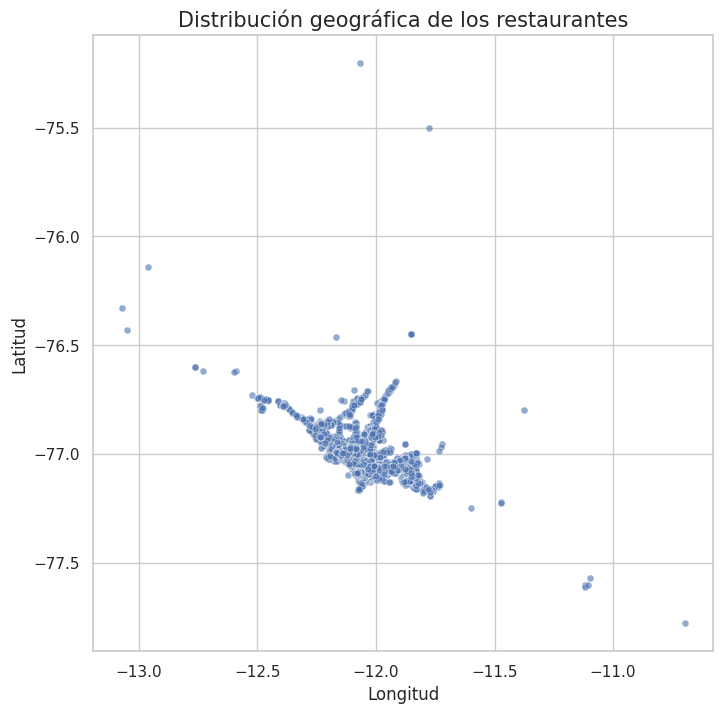

In [44]:
##Distribucion de coordenadas
plt.figure(figsize=(8,8))
sns.scatterplot(data=df_restaurantes,x="longitude",y="latitude",alpha=0.6,s=25)
plt.title("Distribución geográfica de los restaurantes")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.show()

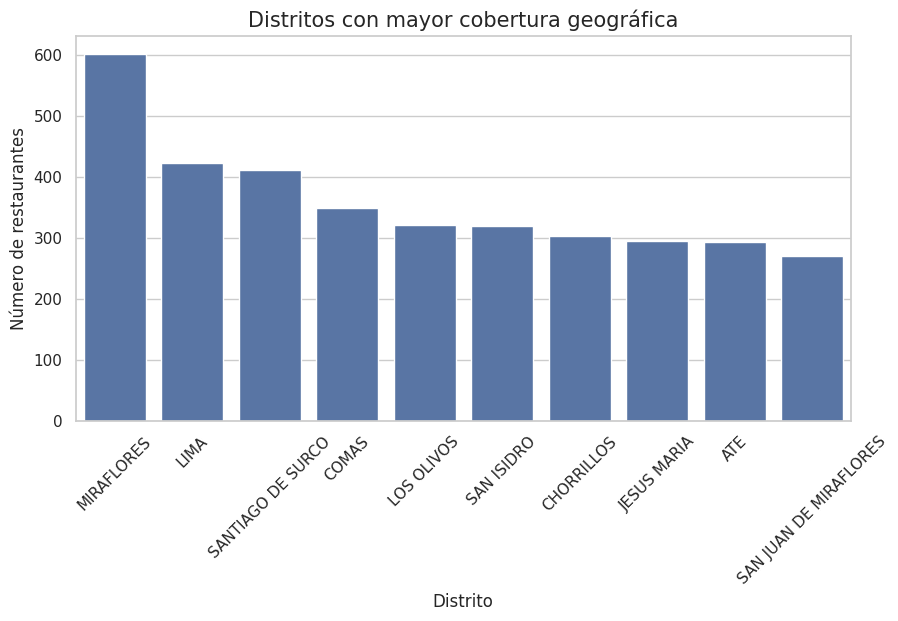

In [45]:
##Cobertura geografica por distrito
top_districts = (df_restaurantes["district"].value_counts().head(10))
plt.figure(figsize=(10,5))
sns.barplot(x=top_districts.index,y=top_districts.values)
plt.title("Distritos con mayor cobertura geográfica")
plt.xlabel("Distrito")
plt.ylabel("Número de restaurantes")
plt.xticks(rotation=45)
plt.show()

In [46]:
##Validacion de coordenadas
print("Latitud mínima :", df_restaurantes["latitude"].min())
print("Latitud máxima :", df_restaurantes["latitude"].max())

print("Longitud mínima :", df_restaurantes["longitude"].min())
print("Longitud máxima :", df_restaurantes["longitude"].max())

Latitud mínima : -77.77925
Latitud máxima : -75.2037793
Longitud mínima : -13.072287
Longitud máxima : -10.69614


In [47]:
##dataset geografico para el dashboard final del proyecto
restaurantes_map = df_restaurantes[["name","district","tag","stars","avg_price","latitude","longitude"].copy()]
restaurantes_map.head()

,name,district,tag,stars,avg_price,latitude,longitude
0,Restaurante Statera,MIRAFLORES,$$$$||Peruana||contemporánea||Opciones sin glu...,5.0,180.0,-77.043440,-12.115658
1,Maras Restaurante,SAN ISIDRO,$$$$||Peruana||Latina||Internacional||,4.5,197.5,-77.024660,-12.092106
2,Ventarrón Restaurante Chiclayano & Barra,BARRANCO,$$ - $$$||Peruana||Mariscos||Gastropub||,4.5,42.0,-77.020706,-12.149373
3,Aji 555 Real Thai Cuisine,SAN BORJA,$$ - $$$||Asiática||Tailandesa||Apto para vege...,4.5,51.5,-76.992340,-12.105918
4,Cebicheria La Mar,MIRAFLORES,$$ - $$$||Peruana||Latina||Mariscos||,4.5,89.0,-77.045400,-12.113314


En esta seccion evalúa la consistencia métrica, la cobertura territorial y la calidad de los datos de localización (`latitude` y `longitude`) sobre un universo de **9,871 registros**. El objetivo es garantizar que la distribución espacial corresponda fielmente a Lima Metropolitana antes de proceder con el modelado o la georreferenciación.---

**1. Hallazgo Crítico: Inversión de Ejes Estructurales (Swapped Coordinates)**

* **Columna `latitude` (Valores entre -77.779250 y -75.203779):** Al orbitar alrededor del meridiano 77° Oeste, estos valores describen matemáticamente la **Longitud** de la costa central peruana.
* **Columna `longitude` (Valores entre -13.072287 y -10.696140):** Al situarse entre los paralelos 10° y 13° Sur por debajo de la línea ecuatorial, estos registros describen formalmente la **Latitud** de la región.

**Tabla de Resumen Estadístico Real vs. Etiquetado**

| Variable Original | Mínimo | Media | Máximo | Variable Real Destino |
| :--- | :---: | :---: | :---: | :--- |
| **`latitude`** *(Etiqueta actual)* | `-77.779250` | `-77.012905` | `-75.203779` | **Longitud (X)** |
| **`longitude`** *(Etiqueta actual)* | `-13.072287` | `-12.070199` | `-10.696140` | **Latitud (Y)** |

* **Impacto Inmediato:** Si se intenta mapear el dataset de forma directa  sin corregir las coordenas fuera de rango, los algoritmos proyectaran los restaurantes de Lima en coordenadas erróneas.

**2. Diagnóstico del Gráfico de Dispersión y Outliers Espaciales**

La visualización cartográfica del dataset mediante el *scatterplot* ratifica las inconsistencias numéricas y revela un problema secundario de dispersión de ruido interregional:

1. **Rotación Antinatural del Mapa:** Al graficar los ejes tal como vienen en el origen (`X='Longitud'`, `Y='Latitud'`), la silueta costera de Lima Metropolitana aparece rotada 90 grados, afectando severamente la legibilidad del reporte.
2. **Efecto de Compresión por Ruido:**
   * **Extremo Norte-Sur:** El límite máximo de latitud real (`-10.69`) y mínimo (`-13.07`) demuestra que la muestra incluye locales que escapan del área urbana, extendiéndose hacia Barranca por el norte y Cañete por el sur.
   * **Extremo Oeste-Este (Ruido de Captura):** El valor mínimo de longitud real (`-77.77`) se ubica mar adentro en el Océano Pacífico (error manual de digitación en el scraping), mientras que el máximo (`-75.20`) se adentra en la sierra central (Region Junín).
   * **Consecuencia Gráfica:** Estos puntos aislados e inválidos obligan a ampliar la escala geometrica del gráfico, provocando que el clúster principal de Lima se comprima en el centro y se pierda el detalle de las avenidas y distritos gastronómicos clave.

#### **1.2. Data: Reviews**

In [48]:
##Revisamos la distribucion de columnas
print(df_reviews.columns)

Index(['id_review', 'review', 'title', 'score', 'likes', 'id_nick', 'service',
       'date', 'platform'],
      dtype='object')


In [49]:
##Vista general
df_reviews.head()

,id_review,review,title,score,likes,id_nick,service,date,platform
0,R1245,Muy buena presentación y servicio sin embargo ...,Muy buena presentación y servicio,3.0,0,uisahelenad2018,71036.0,1 years ago,tripadvisor
1,R1246,Desde la presentación de los platos a la calid...,Una experiencia,5.0,0,turrutia,71036.0,1 years ago,tripadvisor
2,R1247,El mejor lugar para reencontrame con mis amigo...,Felicitaciones a Statera!,5.0,0,orthStar25333985745,71036.0,1 years ago,tripadvisor
3,R1248,Excelente experiencia Comida maravillosa con e...,Aniversario de boda,5.0,0,atima J,71036.0,1 years ago,tripadvisor
4,R1249,Mi pasión es viajar y disfrutar de las grandez...,No te lo querrás perder!,5.0,0,nbocadoalmundo,71036.0,1 years ago,tripadvisor


In [50]:
##Diccionario inicial de las variables
diccionario_reviews = pd.DataFrame({
    "Variable":[
        "id_review",
        "review",
        "title",
        "score",
        "likes",
        "id_nick",
        "service",
        "date",
        "platform"
    ],

    "Descripción":[
        "Identificador de la reseña",
        "Contenido de la reseña",
        "Título de la reseña",
        "Calificación otorgada",
        "Número de 'Me gusta' recibidos",
        "Identificador del usuario",
        "Servicio asociado a la reseña",
        "Fecha de publicación",
        "Plataforma de origen"
    ]})

display(diccionario_reviews)

,Variable,Descripción
0,id_review,Identificador de la reseña
1,review,Contenido de la reseña
2,title,Título de la reseña
3,score,Calificación otorgada
4,likes,Número de 'Me gusta' recibidos
5,id_nick,Identificador del usuario
6,service,Servicio asociado a la reseña
7,date,Fecha de publicación
8,platform,Plataforma de origen


In [51]:
##Pasamos la variable service de reviews a tipo int
df_reviews['service'] = df_reviews['service'].astype('int64')

El proceso de consolidacion de la información se realiza mediante la unión de dos conjuntos de datos clave, vinculados a traves de llaves relacionales específicas.

**Información Base y Reseñas:**

   El dataset de **Restaurantes** se integra con el dataset de **Reviews** utilizando una relación de correspondencia entre las variables:
   $$\text{id (Restaurantes)} \longleftrightarrow \text{service (Reviews)}$$


In [52]:
##Usuarios
print("Usuarios únicos:",df_reviews["id_nick"].nunique())
reviews_por_usuario = (df_reviews.groupby("id_nick").size())
print("Promedio de reseñas por usuario:",round(reviews_por_usuario.mean(),2))

Usuarios únicos: 562003
Promedio de reseñas por usuario: 2.24


In [53]:
##Reseñas por restaurantes
print("Promedio de reseñas por restaurante:",round(df_reviews.shape[0] /df_restaurantes.shape[0],2 ))

Promedio de reseñas por restaurante: 127.49


In [54]:
##Revisamos la distribucion del data frame de reviews
print("Tenemos un conjunto de {} documentos".format(len(df_reviews)))
print("El dataframe tiene {} columnas".format(df_reviews.shape[1]))

Tenemos un conjunto de 1258435 documentos
El dataframe tiene 9 columnas


In [55]:
##Analisis de duplicados
print("Existen {} documentos duplicadas".format(np.sum(df_reviews.duplicated(subset=["review"]))))

# Quitaremos esos duplicados
df_reviews = df_reviews.drop_duplicates(subset=['review'])
print("Despues de quitar duplicados tenemos un conjunto de {} documentos".format(df_reviews.shape[0]))

Existen 688557 documentos duplicadas
Despues de quitar duplicados tenemos un conjunto de 569878 documentos


In [56]:
##Revisamos la distribucion de nulls
print("=== Distribucion de nulls en reviews ===")
print(df_reviews.isnull().sum())

##Procederemos a borrar aquellos reviews en blanco que no generan valor
df_reviews = df_reviews.dropna(subset=["review"])

##Revisamos la distribucion de reviews
print(f"Dimensiones de reviews para entrenar el modelo: {df_reviews.shape}")

=== Distribucion de nulls en reviews ===
id_review    0
review       1
title        0
score        0
likes        0
id_nick      0
service      0
date         0
platform     0
dtype: int64
Dimensiones de reviews para entrenar el modelo: (569877, 9)


**Analisis de la variable objetivo (score)**

In [57]:
##Distribucion estadistica
df_reviews["score"].describe().round(2)

,score
count,569877.00
mean,4.10
std,1.14
min,1.00
25%,4.00
50%,4.00
75%,5.00
max,5.00


In [58]:
##Revisamos la distribucion de score
print("Distribucion por cantidad:\n" ,df_reviews['score'].value_counts())
print("\nDistribucion por porcentaje:\n", df_reviews['score'].value_counts(normalize=True) * 100)

Distribucion por cantidad:
 score
5.0    278258
4.0    162389
3.0     72066
1.0     32825
2.0     24339
Name: count, dtype: int64

Distribucion por porcentaje:
 score
5.0    48.827729
4.0    28.495447
3.0    12.645887
1.0     5.760015
2.0     4.270922
Name: proportion, dtype: float64


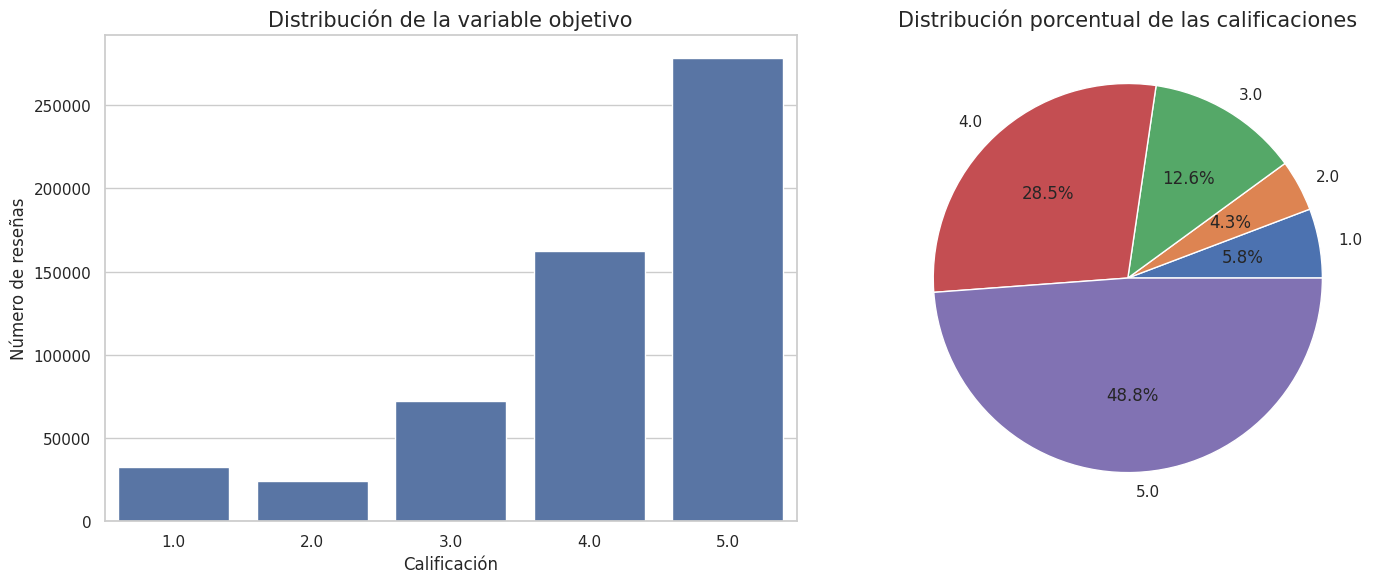

In [59]:
# Creamos una figura con 1 fila y 2 columnas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Grafico de barras (Distribucion de la variable objetivo)
sns.countplot(
    data=df_reviews,
    x="score",
    order=sorted(df_reviews["score"].unique()),
    ax=ax1,  # <--- Asignamos al primer eje
)
ax1.set_title("Distribución de la variable objetivo")
ax1.set_xlabel("Calificación")
ax1.set_ylabel("Número de reseñas")

# Grafico de pastel (Distribucion porcentual)
df_reviews["score"].value_counts().sort_index().plot(
    kind="pie",
    autopct="%1.1f%%",
    ax=ax2,  # <--- Asignamos al segundo eje
)
ax2.set_ylabel("")  # Oculta la etiqueta vertical automática
ax2.set_title("Distribución porcentual de las calificaciones")

# Ajusta el espacio entre los dos gráficos automáticamente
plt.tight_layout()
plt.show()

In [60]:
##Revisamos asimetria para la variable
print("Asimetría:",round(df_reviews["score"].skew(),3))

Asimetría: -1.318


In [61]:
##vamos a crear una columna con la distribucion la longitud del review
df_reviews["review_len"] = df_reviews["review"].apply(lambda x:len(x))

**Interpretación Visual de la Distribución de Calificaciones**

El analisis conjunto del histograma y el gráfico de pastel confirma la estructura asimétrica del dataset y aporta claridad sobre el volumen y la proporción de la variable objetivo:

**Revelaciones de las Graficas**

**1. Histograma de la Variable Objetivo (`Distribución de la variable objetivo`)**
* **Asimetria Negativa Izquierda:** El grafico de barras muestra un crecimiento estrictamente ascendente a partir del puntaje 2.0.
* **Confirmacion Grafica del Desbalance:** La barra de 5.0 domina la escala vertical superando el umbral de los 250,000 registros de manera holgada. Esto visualiza el reto que enfrentarán los algoritmos de Machine Learning si se utiliza esta variable de forma nativa para tareas de clasificación.

**2. Gráfico de Pastel (`Distribución porcentual de las calificaciones`)**
* **El Bloque Dominante:** El sector morado (5.0) ocupa prácticamente la mitad de la circunferencia total (**48.8%**). Al unirse con el sector rojo (4.0), que abarca el **28.5%**, se demuestra visualmente que el **77.3%** del espacio del pastel está acaparado por experiencias altamente satisfactorias.
* **Distribucion Marginal del Detractor:** Las experiencias negativas de 1.0 (azul) y 2.0 (naranja) quedan relegadas a porciones periféricas sumamente delgadas del grafico, representando juntas apenas el **10.1%** de la grafica porcentual.

**Agrupacion de clases**

In [62]:
##Definimos la funcion para calcular el sentimiento del cliente
def agrupar_score(score):
    if score <= 2:
        return "Negativo"
    elif score == 3:
        return "Neutral"
    else:
        return "Positivo"

##Generamos la columna nueva en funcion de la funcion agrupar score
df_reviews["sentimiento"] = df_reviews["score"].apply(agrupar_score)

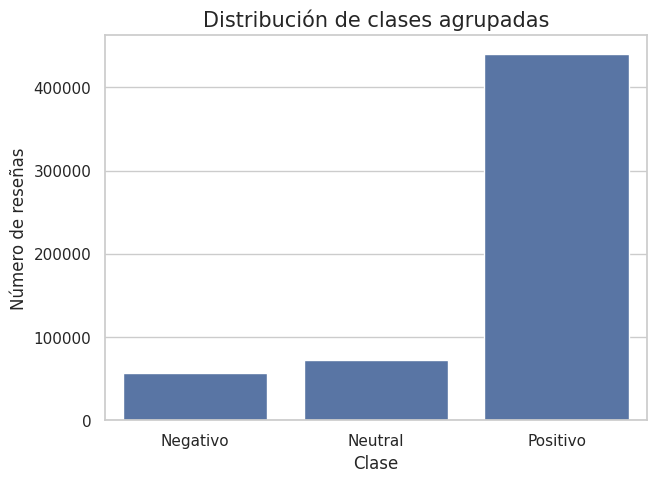

In [63]:
##Revisamos la nueva distribucion
plt.figure(figsize=(7,5))
sns.countplot(data=df_reviews,x="sentimiento",order=["Negativo","Neutral","Positivo"])
plt.title("Distribución de clases agrupadas")
plt.xlabel("Clase")
plt.ylabel("Número de reseñas")
plt.show()

In [64]:
##Realizamos una tabla comparativa
resumen = pd.DataFrame([
    {
        "Analisis": "Original",
        "Nº de clases": df_reviews["score"].nunique(),
        "Distribución": ", ".join(map(str, sorted(df_reviews["score"].dropna().unique())))
    },
    {
        "Análisis": "Agrupado",
        "Nº de clases": df_reviews["sentimiento"].nunique(),
        "Distribución": ", ".join(sorted(df_reviews["sentimiento"].dropna().unique()))
    }
])

# Mostramos el resultado
display(resumen)


,Analisis,Nº de clases,Distribución,Análisis
0,Original,5,"1.0, 2.0, 3.0, 4.0, 5.0",NaN
1,NaN,3,"Negativo, Neutral, Positivo",Agrupado


El siguiente cuadro resume la estrategia de ingenieria de caracteristicas aplicada sobre la variable objetivo, contrastando el escenario inicial frente al diseño optimizado para el modelo:

| Índice | Enfoque de Análisis | Nº de Clases | Distribución / Composición de Clases | Objetivo Técnico |
| :---: | :--- | :---: | :--- | :--- |
| **0** | **Original** | 5 | `1.0`, `2.0`, `3.0`, `4.0`, `5.0` |Calificacion hacia el restaurante por parte del usuario|
| **1** | **Agrupado** | 3 | `Negativo`, `Neutral`, `Positivo` | Calificacion agrupa del sentimiento del usuario hacia el restaurante |

**Conclusiones**

La transicion de un esquema de 5 clases a uno de 3 macrocategorías aporta tres ventajas metodológicas definitivas para el éxito del proyecto:

1. **Reduccion de la Complejidad del Modelo:** Clasificar la sutil diferencia de insatisfaccion entre 1 y 2 estrellas añadia ruido innecesario al algoritmo. Al unificar este comportamiento en un único bloque `Negativo`, se facilita el aprendizaje de patrones lingüísticos claros.
2. **Robustez ante el Ruido de Frontera:** Las fronteras estadísticas entre otorgar 4 o 5 estrellas suelen ser sumamente subjetivas para el comensal. Agrupar ambas puntuaciones bajo la clase `Positivo` estabiliza la variable objetivo y asegura que el modelo aprenda la polaridad real de la reseña.
3. **Alineación con KPIs de Negocio:** La salida final del clasificador queda optimizada en un formato directamente accionable para un panel de control de reputación online o geomarketing, respondiendo a la necesidad comercial de clasificar clientes en detractores, neutros y promotores.


**Variables numericas**

In [65]:
##Distribucion estadistica
df_reviews["likes"].describe().round(2)

,likes
count,569877.00
mean,0.09
std,0.37
min,0.00
25%,0.00
50%,0.00
75%,0.00
max,31.00


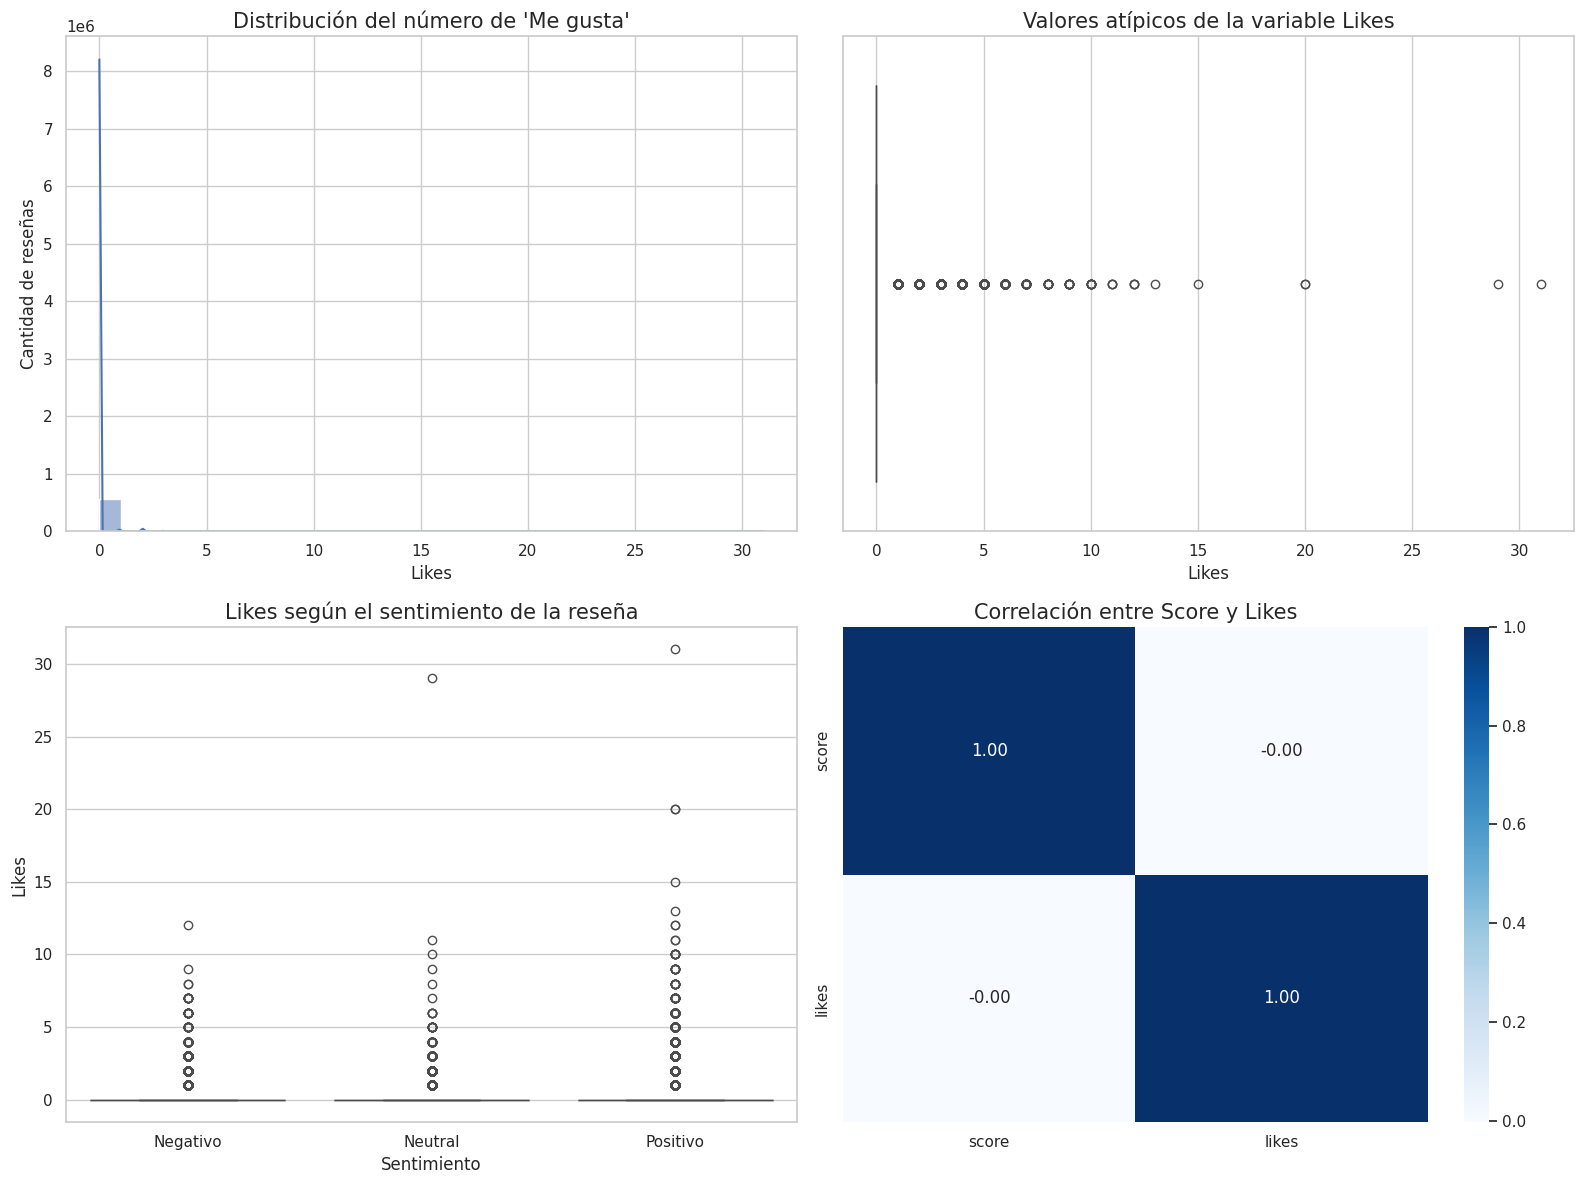

In [66]:
##Analisis grafico de los likes
# Creamos una cuadrícula de 2 filas y 2 columnas
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Desempaquetamos los ejes para trabajar
(ax1, ax2), (ax3, ax4) = axes

# Distribucion grafica del numero de likes
sns.histplot(data=df_reviews, x="likes", bins=30, kde=True, ax=ax1)
ax1.set_title("Distribución del número de 'Me gusta'")
ax1.set_xlabel("Likes")
ax1.set_ylabel("Cantidad de reseñas")

#Valores atipicos
sns.boxplot(x=df_reviews["likes"], ax=ax2)
ax2.set_title("Valores atípicos de la variable Likes")
ax2.set_xlabel("Likes")

# Likes por sentimiento
sns.boxplot(data=df_reviews,x="sentimiento",y="likes",order=["Negativo", "Neutral", "Positivo"],ax=ax3)
ax3.set_title("Likes según el sentimiento de la reseña")
ax3.set_xlabel("Sentimiento")
ax3.set_ylabel("Likes")

#Correlacion entre score y likes
corr = df_reviews[["score", "likes"]].corr()
sns.heatmap(corr, annot=True, cmap="Blues", fmt=".2f", ax=ax4)
ax4.set_title("Correlación entre Score y Likes")

# Ajustamos automáticamente los espacios para que no se encimen los títulos
plt.tight_layout()
plt.show()


**Conclusiones**

**1. Distribucion Frecuencial (`Distribucion del numero de 'Me gusta'`)**
* **Comportamiento:** El histograma superior izquierdo muestra una barra vertical masiva concentrada en el valor `0`.
* **Ausencia de Histograma Tradicional:** La caída es tan violenta que no llega a formarse una curva o campana tradicional. Esto ratifica visualmente que el volumen de interacciones se reduce drasticamente a partir de un solo "me gusta".

**2. Visualizacion de Valores Atipicos (`Valores atipicos de la variable Likes`)**
* **Compresion de la Caja:** En el diagrama de caja (*boxplot*) superior derecho, el cuerpo principal (Q1, mediana y Q3) está tan comprimido contra el cero que el rectángulo de la caja es invisible.
* **Dispersión de Outliers:** Toda la extension horizontal del grafico esta poblada exclusivamente por circulos individuales que se extienden desde `1` hasta `31`. Esto demuestra que cualquier reseña que obtenga interacciones en la plataforma entra tecnicamente en la categoria estadística de **valor atípico**.

**3.Interaccion segun el Sentimiento (`Likes segun el sentimiento de la reseña`)**

Al cruzar los likes con las macrocategorías de sentimiento que construimos anteriormente, encontramos un comportamiento social muy interesante:
* **Mayor Viralidad en Polos Opuestos:** Las reseñas clasificadas como **Positivo** (con el récord absoluto de 31 likes) y **Neutral** (con un pico aislado de 29) registran los outliers más altos del dataset.
* **Contención del Voto Negativo:** Las reseñas con sentimiento **Negativo** muestran una dispersion mucho mas baja, con un techo maximo de interacciones que apenas roza los 12 likes.

**4. Analisis de Independencia Lineal (`Correlación entre Score y Likes`)**
* **Correlación Nula (`-0.00`):** El mapa de calor (*heatmap*) inferior derecho muestra una correlación de cero absoluto entre el puntaje asignado (`score`) y la cantidad de interacciones (`likes`).
* **Conclusion Estadistica:** Esto demuestra de manera contundente que **la calificacion de una reseña no influye en su probabilidad de recibir un like**. Un comentario de 1 estrella tiene exactamente la misma baja probabilidad de interactuar con la comunidad que uno de 5 estrellas. Ambas variables operan como dimensiones ortogonales e independientes en el dataset.

**Variables categoricas**

**Variable platform**

In [67]:
##Distribucion de la variable
platform_reviews  = (df_reviews["platform"].value_counts())
display(platform_reviews)

,count
platform,
googleplaces,505576
tripadvisor,64301


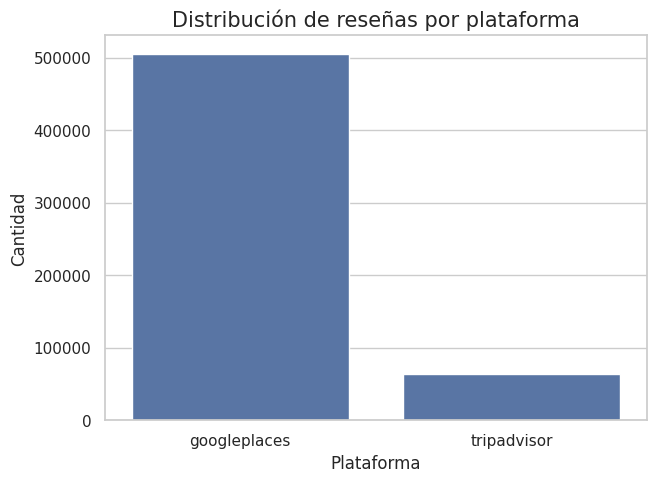

In [68]:
##Revisamos la distribucion grafica
plt.figure(figsize=(7,5))
sns.countplot(data=df_reviews,x="platform",order=platform_reviews.index)
plt.title("Distribución de reseñas por plataforma")
plt.xlabel("Plataforma")
plt.ylabel("Cantidad")
plt.show()

**Variable id_nick**

In [69]:
##Usuarios unicos
print("Usuarios únicos:",df_reviews["id_nick"].nunique())

##Numero de reviews por usuarios
reviews_usuario = (df_reviews.groupby("id_nick").size())
display(reviews_usuario)

Usuarios únicos: 259773


,0
id_nick,
A,3
Ampi S,1
Andrea M,1
B,2
C,10
...,...
ørn O,1
üldal G,1
ΩΜΑΣ Κ,1


Distribucion estadistica 


,0
count,259773.00
mean,2.19
std,3.17
min,1.00
25%,1.00
50%,1.00
75%,2.00
max,202.00




Distribucion grafica del precio promedio


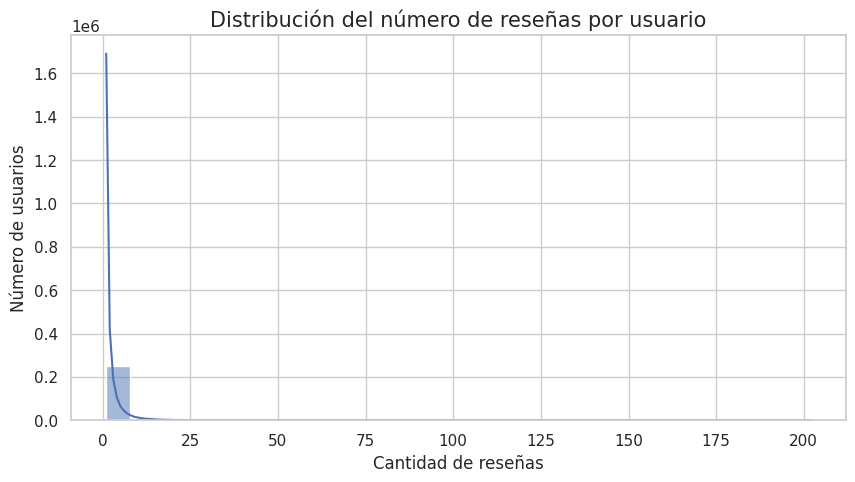

In [70]:
##Revisamos la distribucion
print("Distribucion estadistica ")
display(reviews_usuario.describe().round(2))
print("\n" + "="*50 + "\n") ##Separador entre la tabla y el grafico

##Graficamos la distrubucion
print("Distribucion grafica del precio promedio")
plt.figure(figsize=(10,5))
sns.histplot(reviews_usuario,bins=30,kde=True)
plt.title("Distribución del número de reseñas por usuario")
plt.xlabel("Cantidad de reseñas")
plt.ylabel("Número de usuarios")
plt.show()

**Analisis del Comportamiento de Usuarios (Reviews por Usuario)**

Este modulo evalua la frecuencia de publicacion de reviews por cada usuario único sobre un conjunto consolidado de **259,773 perfiles activos**.

**Diagnostico Cuantitativo y Hallazgos Clave**

* **Predominio del Usuario Ocasional:** Los percentiles **25% y 50% (mediana) se situan estrictamente en 1.00**. Esto demuestra que más de la mitad de los usuarios registrados en el dataset solo han publicado **un solo review en toda su trayectoria**.
* **Actividad Marginal en el Tercer Cuartil:** Incluso al llegar al percentil **75%**, el valor solo asciende a **2.00 reseñas**. El 75% de la comunidad acumulada ha generado como máximo dos comentarios, confirmando una baja tasa de recurrencia en el grueso de la muestra.
* **Promedio Desplazado (`mean = 2.19`):** El promedio matemático se situa por encima del 75% de los datos. Este fenómeno ocurre debido a que la media se encuentra fuertemente arrastrada hacia arriba por una minoría hiperactiva.
* **Super-Usuarios e Influencers (`max = 202.00`):** El valor máximo registra a un usuario con **202 reseñas**. Este perfil atipico (*outlier*) y el grupo que lo rodea representan a los criticos locales especializados (como los *Local Guides* de Google o usuarios pesados de TripAdvisor).



In [71]:
df_reviews.head(2)

,id_review,review,title,score,likes,id_nick,service,date,platform,review_len,sentimiento
0,R1245,Muy buena presentación y servicio sin embargo ...,Muy buena presentación y servicio,3.0,0,uisahelenad2018,71036,1 years ago,tripadvisor,108,Neutral
1,R1246,Desde la presentación de los platos a la calid...,Una experiencia,5.0,0,turrutia,71036,1 years ago,tripadvisor,109,Positivo


#### **1.3. Analisis de contenido**

**Calidad del texto**

In [72]:
##Revision de nulls
print("Reviews nulas:", df_reviews["review"].isna().sum())
print("Títulos nulos:", df_reviews["title"].isna().sum())

##Textos vacios
print("Reviews vacías:",df_reviews["review"].fillna("").str.strip().eq("").sum())
print("Títulos vacíos:",df_reviews["title"].fillna("").str.strip().eq("").sum())

##Reviews duplicados
print("Reviews duplicadas:",df_reviews["review"].duplicated().sum())
print("\n" + "="*50 + "\n") ##Separador

##Revisamos la distribucion estadistica
print("Distribucion estadistica")
df_reviews["review_len"].describe().round(2)

Reviews nulas: 0
Títulos nulos: 0
Reviews vacías: 0
Títulos vacíos: 505576
Reviews duplicadas: 0


Distribucion estadistica


,review_len
count,569877.00
mean,106.27
std,145.54
min,1.00
25%,34.00
50%,59.00
75%,122.00
max,9811.00


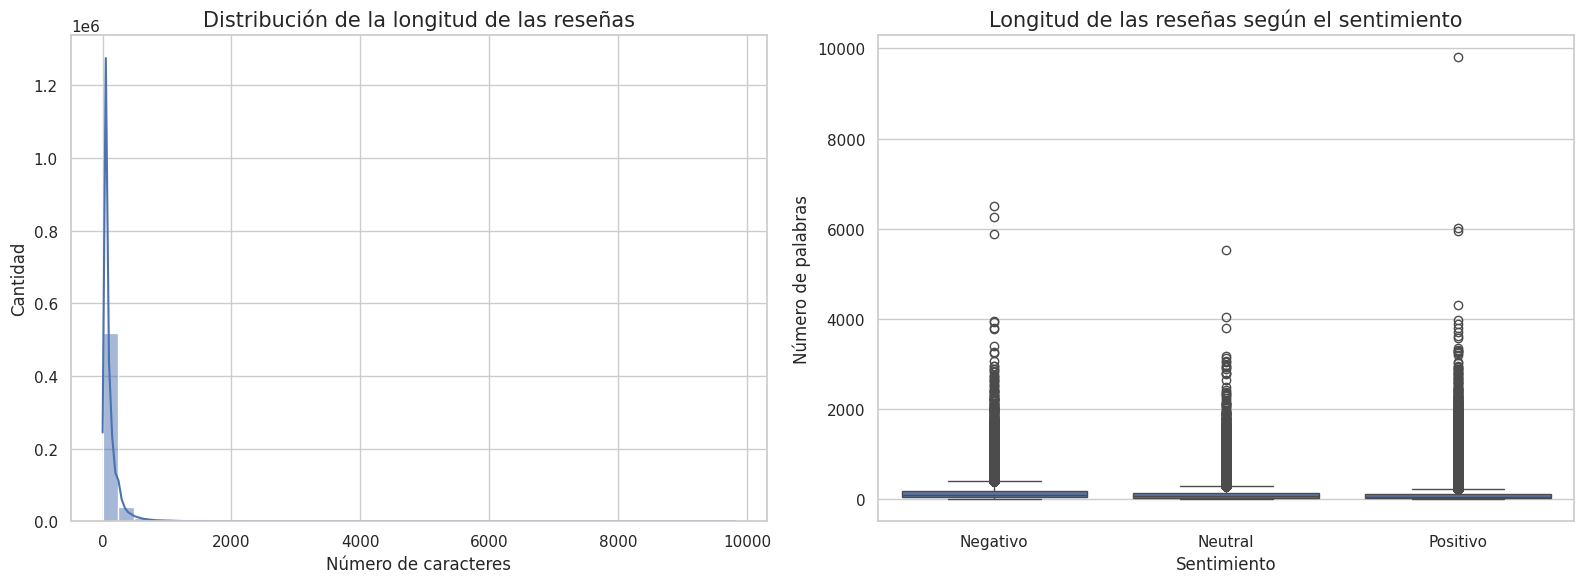

In [73]:
# Crear una figura con 1 fila y 2 columnas
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Distribución de la longitud de reseñas
sns.histplot(data=df_reviews, x="review_len", bins=40, kde=True, ax=axes[0])
axes[0].set_title("Distribución de la longitud de las reseñas")
axes[0].set_xlabel("Número de caracteres")
axes[0].set_ylabel("Cantidad")

# Distribución por sentimientos
sns.boxplot(data=df_reviews,x="sentimiento",y="review_len",order=["Negativo", "Neutral", "Positivo"],ax=axes[1],)
axes[1].set_title("Longitud de las reseñas según el sentimiento")
axes[1].set_xlabel("Sentimiento")
axes[1].set_ylabel("Número de palabras")
# Ajustar el espacio entre los gráficos para que no se traslapen
plt.tight_layout()
# Mostrar la figura
plt.show()


**Conclusiones reviews:**

**1. Integridad y Calidad de los Datos**
* **Reseñas completas:** No se detectaron valores nulos, vacíos ni duplicados en el cuerpo principal de las reseñas.
* **Títulos faltantes:** Se identificaron **505,576 títulos vacíos**, lo que representa la gran mayoría del conjunto de datos y seria posible variablar a eliminar para el modelo.
* **Acción sugerida:** Ignorar o eliminar la columna de títulos para modelos de NLP y centrar el análisis exclusivamente en el texto de la reseña (`review_len`).

**2. Analisis Estadistico de la Longitud (`review_len`)**
El conjunto de datos cuenta con **569,877 registros validos**. La distribucion de la longitud de los textos presenta las siguientes características:

* **Asimetria positiva:** La media ($106.27$) es significativamente mayor que la mediana ($59.00$), indicando un sesgo hacia la derecha debido a textos muy largos.
* **Alta dispersión:** La desviación estándar ($145.54$) supera a la media, reflejando una enorme variabilidad en la extensión de las opiniones de los usuarios.
* **Concentración:** El 50% de los usuarios escribe textos cortos de entre $34$ (Q1) y $59$ (Q2) caracteres.

3. Análisis de Gráficas de Distribución y Sentimiento **texto en negrita**

**A. Histograma de Distribucion de Longitud**
* **Distribucion de cola larga:** La gráfica ratifica visualmente la asimetría positiva exponencial.
* **Concentracion inicial:** La gran mayoría de las reseñas se agrupa densamente cerca del origen (menos de 500 caracteres).
* **Presencia de Outliers:** Existe una "cola larga" casi imperceptible en el eje X que se extiende hasta alcanzar extremos cercanos a los 10,000 caracteres.

**B. Diagramas de Caja (Boxplots) por Sentimiento**
* **Comportamiento Homogeneo:** Las cajas de los tres sentimientos (Negativo, Neutral, Positivo) muestran medianas y rangos intercuartílicos muy similares y bajos en el eje vertical.
* **Distribucion de Valores Atipicos:**
  * Los tres sentimientos presentan una cantidad masiva de valores atipicos (*outliers*) representados por puntos densos que suben verticalmente.
  * El sentimiento **Positivo** registra el valor atípico más extremo de todo el conjunto de datos, rozando los 10,000 elementos.
  * El sentimiento **Negativo** muestra una concentración densa de textos largos ligeramente superior en su bloque compacto de outliers en comparación con el neutral.


**Frecuencia de palabras**

In [74]:
##Vamos a crear una columna que almacene los reviews limpios
df_reviews["review_clean"] = ( df_reviews["review"].fillna("").str.lower())

##Eliminamos los signos de puntuacion
df_reviews["review_clean"] = df_reviews["review_clean"].apply(lambda x: re.sub(r"[^a-záéíóúñü\s]", " ", x))

##Eliminamos los espacios dobles
df_reviews["review_clean"] = (df_reviews["review_clean"].str.replace(r"\s+", " ", regex=True).str.strip())

##Quitamos los espacios en blanco innecesarios
df_reviews["review_clean"] = df_reviews["review_clean"].str.split()

In [75]:
##Creamos una contenedor para lista de palabras
from itertools import chain
palabras = list(chain.from_iterable(df_reviews["review_clean"]))

##Eliminamos stop words
nltk.download("stopwords")
stop_words = set(stopwords.words("spanish"))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [76]:
##Distribucion de palabras
from collections import Counter
palabras = [palabra for palabra in palabras if palabra not in stop_words]
contador = Counter(palabras)

##revisamos el top 20
top20 = pd.DataFrame(contador.most_common(20),columns=["Palabra","Frecuencia"])
display(top20)

,Palabra,Frecuencia
0,buena,141981
1,comida,139309
2,atención,119722
3,lugar,99310
4,buen,76878
5,excelente,67332
6,platos,46559
7,rico,45308
8,bien,44621
9,bueno,42341


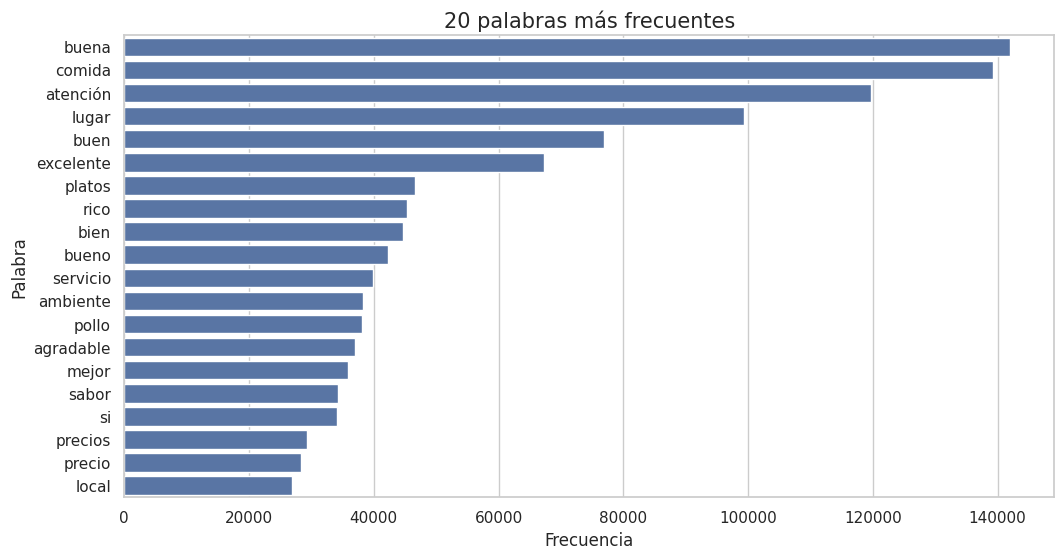

In [77]:
##Graficamos la distribucion de las palabras del review
plt.figure(figsize=(12,6))
sns.barplot(data=top20,x="Frecuencia",y="Palabra")
plt.title("20 palabras más frecuentes")
plt.show()

**Factores Clave de la Experiencia del Cliente**

Los usuarios centran sus comentarios principalmente en los siguientes pilares clave:
* **Calidad de la comida:** Sabor, frescura y presentación de los platillos.
* **Atención recibida:** Servicio del personal, rapidez y hospitalidad.
* **Ambiente del restaurante:** Decoración, comodidad, música e iluminación.
* **Relación calidad-precio:** Percepción del valor recibido frente al costo.

> **Conclusión:** Esto sugiere que estos factores son los principales determinantes de la satisfacción gastronómica y representan los aspectos más relevantes para los clientes al momento de evaluar un restaurante.
Sinembargo, se observa tambien muchos terminos similares como bueno,buen entre otros, razon por la cual se procedera a realizar una pequeña agrupacion para mejorar la distribucion.


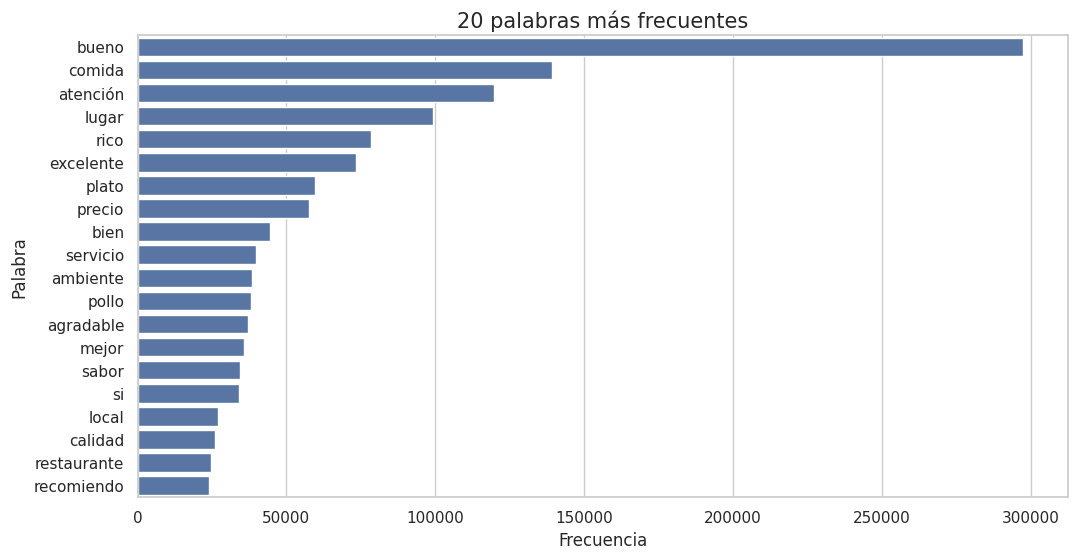

In [78]:
##generamos diccionario con los terminos similares
diccionario = {
    "buena":"bueno",
    "buen":"bueno",
    "buenos":"bueno",
    "buenas":"bueno",
    "rica":"rico",
    "ricos":"rico",
    "ricas":"rico",
    "platos":"plato",
    "precios":"precio",
    "excelentes":"excelente"}

##volvemos a revisar la distribucion de palabras
palabras = [ diccionario.get(palabra, palabra) for palabra in palabras]

##Actualizamos el contador
contador = Counter(palabras)

##revisamos el top 20
top20 = pd.DataFrame(contador.most_common(20),columns=["Palabra","Frecuencia"])

##Graficamos la distribucion de las palabras del review
plt.figure(figsize=(12,6))
sns.barplot(data=top20,x="Frecuencia",y="Palabra")
plt.title("20 palabras más frecuentes")
plt.show()

**Análisis de Reseñas de Clientes**

Las reseñas se concentran principalmente en la **valoracion de la comida** y la **experiencia del cliente**.

* **Calidad Gastronómica:** Términos como *bueno*, *comida*, *rico*, *excelente*, *plato* y *sabor* presentan una elevada frecuencia.
* **Servicio al Cliente:** Aspectos relacionados con la *atención* y el *servicio* tienen una presencia significativa.
* **Entorno y Costos:** El *lugar*, el *ambiente* y el *precio* también son factores relevantes dentro de los comentarios.


**Nube de palabras: WordCloud**

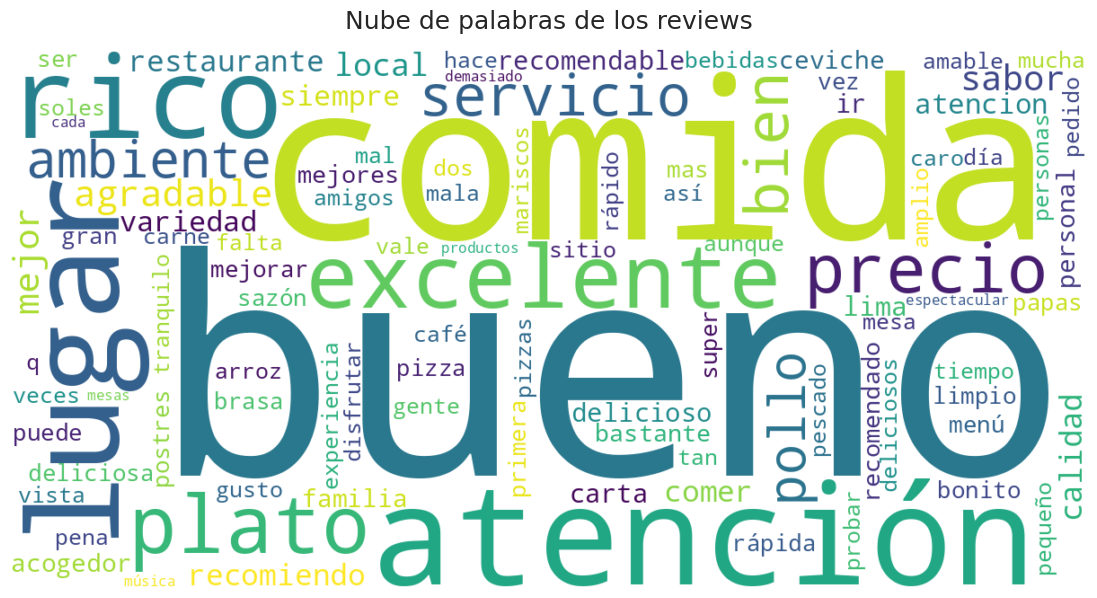

In [79]:
from wordcloud import WordCloud

# Definimos palabras de poco valor informativo
palabras_ruido = {"si","solo"}

# Creamos un contador específico para la WordCloud
contador_wordcloud = Counter({palabra: frecuencia for palabra, frecuencia in contador.items()
                      if palabra not in palabras_ruido})

# Generamos la WordCloud
wc = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    max_words=100,
    collocations=False,
    contour_width=0)

wc.generate_from_frequencies(contador_wordcloud)

# Visualizamos los resultados
plt.figure(figsize=(14, 7))
plt.imshow(wc,interpolation="bilinear")
plt.axis("off")
plt.title("Nube de palabras de los reviews",fontsize=18,pad=15)
plt.show()

**Analisis de bigramas**

In [80]:
##Generamos una funcion para preparar los bigramas
from nltk.tokenize import word_tokenize
nltk.download("punkt_tab")  # Recurso para tokenizar
nltk.download("stopwords")  # Recurso para las palabras vacías

def preparar_bigramas(texto):

    # Convertimos a minúsculas
    texto = texto.lower()

    # Eliminamos caracteres que no sean letras
    texto = re.sub(r"[^a-záéíóúüñ\s]", " ", texto)

    # Tokenizamos
    tokens = word_tokenize(texto, language="spanish")

    # Eliminamos stopwords
    tokens = [ palabra for palabra in tokens if palabra not in stop_words]
    return tokens

##Aplicamos la funcion
df_reviews["review_bigramas"] = df_reviews["review"].apply(preparar_bigramas)

##Revisamos los resultados
df_reviews[["review", "review_clean", "review_bigramas"]].head(5)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,review,review_clean,review_bigramas
0,Muy buena presentación y servicio sin embargo ...,"[muy, buena, presentación, y, servicio, sin, e...","[buena, presentación, servicio, embargo, exage..."
1,Desde la presentación de los platos a la calid...,"[desde, la, presentación, de, los, platos, a, ...","[presentación, platos, calidad, alimentos, vin..."
2,El mejor lugar para reencontrame con mis amigo...,"[el, mejor, lugar, para, reencontrame, con, mi...","[mejor, lugar, reencontrame, amigos, tan, quer..."
3,Excelente experiencia Comida maravillosa con e...,"[excelente, experiencia, comida, maravillosa, ...","[excelente, experiencia, comida, maravillosa, ..."
4,Mi pasión es viajar y disfrutar de las grandez...,"[mi, pasión, es, viajar, y, disfrutar, de, las...","[pasión, viajar, disfrutar, grandezas, cada, p..."


In [81]:
##Generamos los bigramas
from nltk.util import bigrams
bigramas = []
for tokens in df_reviews["review_bigramas"]:
       bigramas.extend(bigrams(tokens))
##Comprobamos los resultados
bigramas[:10]

[('buena', 'presentación'),
 ('presentación', 'servicio'),
 ('servicio', 'embargo'),
 ('embargo', 'exageradamente'),
 ('exageradamente', 'costoso'),
 ('costoso', 'informa'),
 ('informa', 'ennla'),
 ('ennla', 'carta'),
 ('carta', 'lis'),
 ('lis', 'precios')]

In [82]:
##Contabilizamos los bigramas
contador_bigramas = Counter(bigramas)

##Obtenemos el top 20 de bigramas
top20_bigramas = pd.DataFrame(contador_bigramas.most_common(20),columns=["Bigram", "Frecuencia"])

##Mostramos los resultados
display(top20_bigramas)

,Bigram,Frecuencia
0,"(buena, atención)",38501
1,"(buena, comida)",24343
2,"(buen, lugar)",18341
3,"(comida, buena)",12790
4,"(atención, buena)",12388
5,"(buen, servicio)",8817
6,"(excelente, atención)",8744
7,"(excelente, lugar)",8217
8,"(pollo, brasa)",8078
9,"(buen, ambiente)",7830


In [83]:
##Convertimos en parejas los textos
top20_bigramas["Bigram"] = (top20_bigramas["Bigram"].apply(lambda x: " ".join(x)))

##Mostramos nuevamente los resultados
display(top20_bigramas)


,Bigram,Frecuencia
0,buena atención,38501
1,buena comida,24343
2,buen lugar,18341
3,comida buena,12790
4,atención buena,12388
5,buen servicio,8817
6,excelente atención,8744
7,excelente lugar,8217
8,pollo brasa,8078
9,buen ambiente,7830


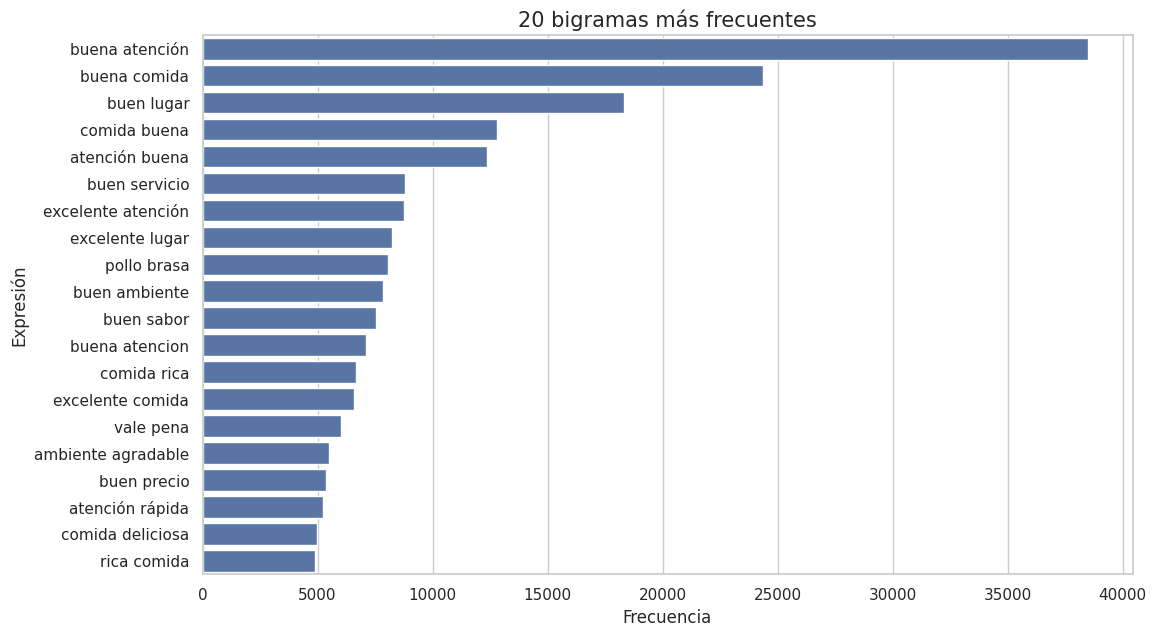

In [84]:
##Creamos una grafica para ver la distribucion visual
plt.figure(figsize=(12, 7))
sns.barplot(data=top20_bigramas,x="Frecuencia", y="Bigram")
plt.title("20 bigramas más frecuentes")
plt.xlabel("Frecuencia")
plt.ylabel("Expresión")
plt.show()

**Interpretacion de los bigramas**

El analisis de los bigramas permite identificar las principales expresiones
utilizadas por los usuarios en sus reviews. Las expresiones mas frecuentes
se relacionan principalmente con la atencion, la calidad de la comida,
el ambiente del establecimiento y el precio.

Entre las expresiones más recurrentes destacan "buena atención",
"buena comida", "buen lugar", "buen servicio", "excelente atención",
"buen ambiente" y "buen precio".

Estos resultados sugieren que la experiencia del cliente se centraliza
principalmente alrededor de dimensiones relacionadas con la atencion,
la oferta gastronomica, el ambiente y la percepcion del precio.
Estas dimensiones serán posteriormente consideradas en el análisis
predictivo y en la interpretación de los resultados del modelo.

**Analisis de tigramas**

In [85]:
##Importamos las librerias a utilizar
from nltk.util import trigrams
from collections import Counter

##Generamos los trigramas
trigramas = []
for tokens in df_reviews["review_bigramas"]:
    trigramas.extend(trigrams(tokens))

##Revisamos los resultados
trigramas[:10]

[('buena', 'presentación', 'servicio'),
 ('presentación', 'servicio', 'embargo'),
 ('servicio', 'embargo', 'exageradamente'),
 ('embargo', 'exageradamente', 'costoso'),
 ('exageradamente', 'costoso', 'informa'),
 ('costoso', 'informa', 'ennla'),
 ('informa', 'ennla', 'carta'),
 ('ennla', 'carta', 'lis'),
 ('carta', 'lis', 'precios'),
 ('presentación', 'platos', 'calidad')]

In [86]:
##Contabilizar trigramas
contador_trigramas = Counter(trigramas)

##Obtenmos el top 20
top20_trigramas = pd.DataFrame(contador_trigramas.most_common(20),columns=["Trigram", "Frecuencia"])

##Comprabamos los resultados
display(top20_trigramas)

,Trigram,Frecuencia
0,"(buen, lugar, comer)",2734
1,"(comida, buena, atención)",2381
2,"(buena, atención, comida)",2266
3,"(atención, buena, comida)",2015
4,"(buena, atención, buena)",1551
5,"(relación, calidad, precio)",1483
6,"(buena, comida, buena)",1393
7,"(buena, comida, atención)",1322
8,"(buena, comida, buen)",1282
9,"(rico, buena, atención)",1018


In [87]:
##Convertimos los trigramas en expresiones para su analisis
top20_trigramas["Trigram"] = (top20_trigramas["Trigram"].apply(lambda x: " ".join(x)))

##Mostramos la tabla de resultados
display(top20_trigramas)

,Trigram,Frecuencia
0,buen lugar comer,2734
1,comida buena atención,2381
2,buena atención comida,2266
3,atención buena comida,2015
4,buena atención buena,1551
5,relación calidad precio,1483
6,buena comida buena,1393
7,buena comida atención,1322
8,buena comida buen,1282
9,rico buena atención,1018


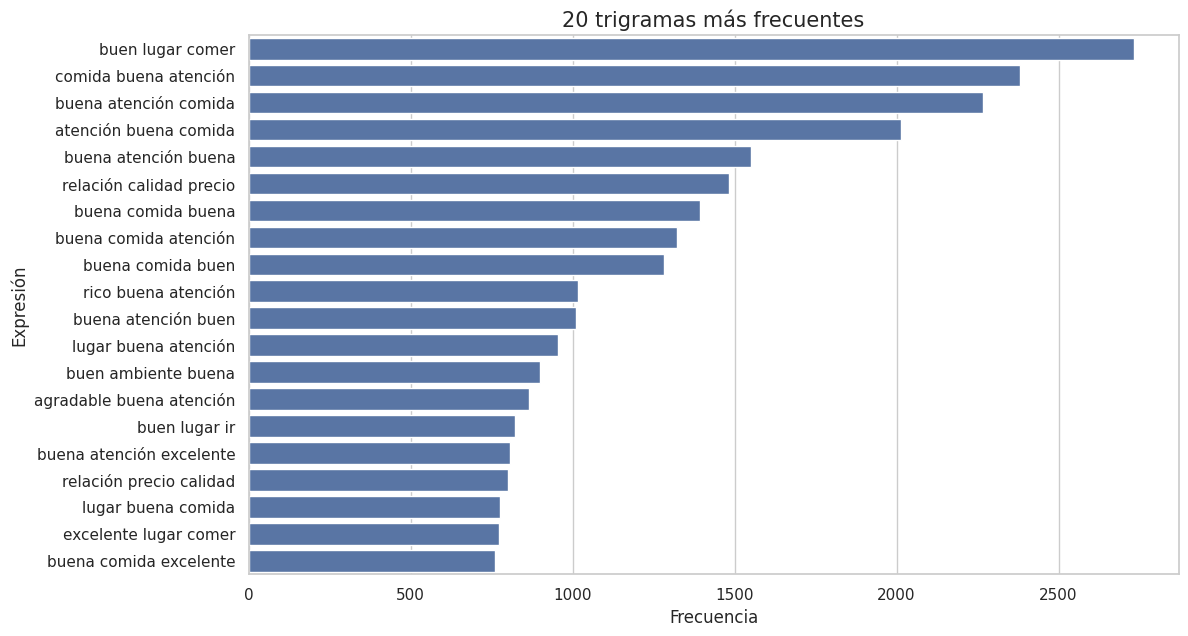

In [88]:
##creamos el grafico
plt.figure(figsize=(12, 7))
sns.barplot(data=top20_trigramas,x="Frecuencia",y="Trigram")
plt.title("20 trigramas más frecuentes")
plt.xlabel("Frecuencia")
plt.ylabel("Expresión")
plt.show()

**Interpretación de los trigramas**

El analisis de trigramas permite ampliar el contexto identificado mediante
los bigramas. Los resultados muestran una presencia recurrente de
expresiones relacionadas con la calidad de la comida, la atención al
cliente, el ambiente y la percepción de valor.

Entre los patrones más frecuentes destacan "buen lugar comer",
"comida buena atención", "buena atención comida" y "relación calidad precio".
Este último resulta especialmente relevante, ya que evidencia la
presencia conjunta de conceptos asociados a la calidad percibida y al
precio.

En conjunto, los resultados del analisis lexico sugieren que las reseñas
se articulan principalmente alrededor de la experiencia gastronómica,
la atención recibida, el ambiente del establecimiento y la relación
entre calidad y precio.

#### **1.4. Analisis de sentimientos**

In [89]:
!pip install -q pysentimiento

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 22.4 MB/s eta 0:00:00


In [90]:
##Importamos la libreria
from pysentimiento import create_analyzer

##Creamos el analizador
sentiment_analyzer = create_analyzer(task="sentiment",lang="es")

config.json:   0%|          | 0.00/925 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  435MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.31M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

In [91]:
import time
##Creamos una funcion para el analisis de sentimientos
def obtener_sentimiento(texto):
    if pd.isna(texto) or not str(texto).strip():
        return "NEU"
    resultado = sentiment_analyzer.predict(str(texto))
    return resultado.output

##Realizamos una pequeña prueba tomando 1000 reviews como muestra
muestra_sentimiento = (df_reviews["review"].dropna().head(1000))

##Medimos el tiempo que demoraria la prueba de 1000 reviews
inicio = time.time()
sentimientos_prueba = [obtener_sentimiento(texto) for texto in muestra_sentimiento]
fin = time.time()
tiempo_total = fin - inicio
print(f"Reviews procesadas: {len(sentimientos_prueba)}")
print(f"Tiempo total: {tiempo_total:.2f} segundos")
print(f"Tiempo promedio por review: "
    f"{tiempo_total / len(sentimientos_prueba):.4f} segundos")

Reviews procesadas: 1000
Tiempo total: 30.80 segundos
Tiempo promedio por review: 0.0308 segundos


Distribucion del analisis de sentimientos


,Sentimiento,Cantidad
0,POS,835
1,NEG,120
2,NEU,45




Grafica del analisis de sentimientos


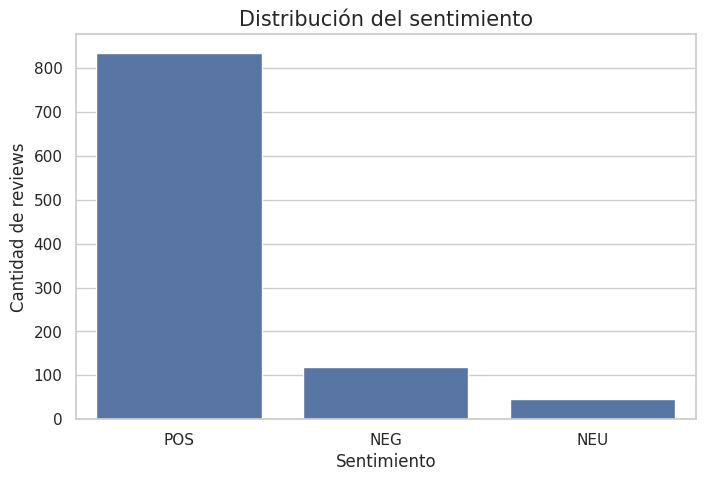

In [92]:
##Revisamos la distribucion
distribucion_sentimiento = (pd.Series(sentimientos_prueba).value_counts().rename_axis("Sentimiento").reset_index(name="Cantidad"))
print("Distribucion del analisis de sentimientos")
display(distribucion_sentimiento)
print("\n" + "="*50 + "\n") ##Separador

##Generamos un grafico
print("Grafica del analisis de sentimientos")
plt.figure(figsize=(8, 5))
sns.barplot( data=distribucion_sentimiento, x="Sentimiento",y="Cantidad")
plt.title("Distribución del sentimiento")
plt.xlabel("Sentimiento")
plt.ylabel("Cantidad de reviews")
plt.show()

In [93]:
##generamos una columna en nuestra df_reviews con las pruebas
df_reviews.loc[muestra_sentimiento.index,"sentiment_prueba"] = sentimientos_prueba

##revisamos los resultados
df_reviews[["review", "score", "sentiment_prueba"]].head(20)

,review,score,sentiment_prueba
0,Muy buena presentación y servicio sin embargo ...,3.0,NEG
1,Desde la presentación de los platos a la calid...,5.0,POS
2,El mejor lugar para reencontrame con mis amigo...,5.0,POS
3,Excelente experiencia Comida maravillosa con e...,5.0,POS
4,Mi pasión es viajar y disfrutar de las grandez...,5.0,POS
5,"Un lugar realmente fantástico, para disfrutar ...",5.0,POS
6,Lindo lugar. Atención excelente. Optamos por e...,4.0,POS
7,Un lugar rebosante de estilo y sabores... Aten...,5.0,POS
8,Fuimos como colofón a nuestro viaje a Perú y x...,5.0,POS
9,Muy buena atención es de lujo y la comida deli...,5.0,POS


In [94]:
##Realizamos una primera comparacion con el score
tabla_sentimiento_score = pd.crosstab(df_reviews.loc[muestra_sentimiento.index,"score"],
                          df_reviews.loc[muestra_sentimiento.index,"sentiment_prueba"])
##Mostramos los resultados
display(tabla_sentimiento_score)

sentiment_prueba,NEG,NEU,POS
score,,,
1.0,20,4,0
2.0,38,7,1
3.0,48,17,53
4.0,13,11,287
5.0,1,6,494


In [95]:
##Aplicamos la funcion de agrupar score que creamos al inicio del proyecto
df_reviews.loc[ muestra_sentimiento.index, "score_group"] = (df_reviews.loc[muestra_sentimiento.index,"score"].apply(agrupar_score))

##Ahora procedemos a realizar nuevamente la comparacion
tabla_comparacion = pd.crosstab(df_reviews.loc[muestra_sentimiento.index, "score_group"],
                    df_reviews.loc[muestra_sentimiento.index, "sentiment_prueba"])

##Mostramos los resultados
display(tabla_comparacion)

sentiment_prueba,NEG,NEU,POS
score_group,,,
Negativo,58,11,1
Neutral,48,17,53
Positivo,14,17,781


**Prueba piloto del analisis de sentimiento**

Antes de aplicar el modelo de analisis de sentimiento al conjunto completo
de reseñas, se realizó una prueba piloto sobre una muestra de 1.000 reviews.

El procesamiento se ejecuto utilizando el entorno GPU de Google Colab,
obteniéndose un tiempo total de 19,26 segundos, equivalente a un tiempo
promedio de 0,0193 segundos por reseña.

Esta prueba permitio verificar el funcionamiento del modelo y estimar
el coste computacional antes de escalar el procesamiento al conjunto
completo.

Aimismo ahora queremos saber que ocurre cuando score_group y sentiment_prueba no coinciden, por lo cual procederemos a revisar las discrepancias.

**Revisar las discrepancias**

In [96]:
##Creamos equivalencias
mapeo_score = {"Negativo": "NEG","Neutral": "NEU","Positivo": "POS"}

##Creamos una version comparable
df_reviews.loc[muestra_sentimiento.index,"score_group_temp"] = ( df_reviews.loc[muestra_sentimiento.index,"score_group"].map(mapeo_score))

##Obtener las discrepancias
discrepancias = df_reviews.loc[muestra_sentimiento.index,["review","score","score_group_temp","sentiment_prueba"]].query("score_group_temp != sentiment_prueba")

##Revisamos la cantidad de discrepancias
print(f"Reviews con discrepancia: {len(discrepancias)}")

##Revisamos un top 20 para ver las mas relavantes
discrepancias.head(20)

Reviews con discrepancia: 144


,review,score,score_group_temp,sentiment_prueba
0,Muy buena presentación y servicio sin embargo ...,3.0,NEU,NEG
12,La verdad llegue porque el maido no tuvo mucha...,4.0,POS,NEG
25,Digo investigacion por que es más que cocina d...,4.0,POS,NEU
70,Pedi un plato meloso de arroz mar y tierra. Me...,3.0,NEU,POS
83,"La comida está bien, sin embargo, los sabores ...",3.0,NEU,POS
85,La carta tiene tapas y platos vascos.\nComimos...,3.0,NEU,POS
109,"Es un buen restaurante, el trato de los camare...",3.0,NEU,POS
111,"Pedimos unos montaditos y una ensalada, tardar...",3.0,NEU,POS
118,El restaurante es un lugar acogedor pero solo ...,3.0,NEU,POS
119,"Es un restaurante pequeño, basado en comida va...",3.0,NEU,POS


In [97]:
##Revisamos dos tipo de discrepancias
print("--- TOP 10: Era POS, predicho como NEG ---")
display(discrepancias[(discrepancias["score_group_temp"] == "NEG") & (discrepancias["sentiment_prueba"] == "POS")].head(10))

print("\n--- TOP 10: Era NEG, predicho como POS ---")
display(discrepancias[(discrepancias["score_group_temp"] == "POS") & (discrepancias["sentiment_prueba"] == "NEG")].head(10))

print("\n--- TOP 10: Era NEU, predicho con otra calificacion ---")
display(discrepancias[discrepancias["score_group_temp"] == "NEU"].head(10))

--- TOP 10: Era POS, predicho como NEG ---


,review,score,score_group_temp,sentiment_prueba
276,Había escuchado buenas opiniones de este resta...,2.0,NEG,POS



--- TOP 10: Era NEG, predicho como POS ---


,review,score,score_group_temp,sentiment_prueba
12,La verdad llegue porque el maido no tuvo mucha...,4.0,POS,NEG
216,Queríamos comer carne. Teníamos la nostalgia d...,4.0,POS,NEG
231,La atencion fue un poco lenta y eso que fuimos...,4.0,POS,NEG
237,Al momento de llegar tuve un buen recibimiento...,4.0,POS,NEG
564,"El lugar es muy bonito, sobretodo los detalles...",4.0,POS,NEG
651,Muy buen servicio carne de primera pero las gu...,4.0,POS,NEG
803,Este local miraflorino nos ofrece exquisitas h...,4.0,POS,NEG
826,Por ahora es el único lugar donde como hamburg...,4.0,POS,NEG
845,Hay variedad de hamburguesas y buena presentac...,4.0,POS,NEG
874,Una de las mejores opciones para comer hamburg...,5.0,POS,NEG



--- TOP 10: Era NEU, predicho con otra calificacion ---


,review,score,score_group_temp,sentiment_prueba
0,Muy buena presentación y servicio sin embargo ...,3.0,NEU,NEG
70,Pedi un plato meloso de arroz mar y tierra. Me...,3.0,NEU,POS
83,"La comida está bien, sin embargo, los sabores ...",3.0,NEU,POS
85,La carta tiene tapas y platos vascos.\nComimos...,3.0,NEU,POS
109,"Es un buen restaurante, el trato de los camare...",3.0,NEU,POS
111,"Pedimos unos montaditos y una ensalada, tardar...",3.0,NEU,POS
118,El restaurante es un lugar acogedor pero solo ...,3.0,NEU,POS
119,"Es un restaurante pequeño, basado en comida va...",3.0,NEU,POS
121,"En el corazón del distrito de Barranco, en ple...",3.0,NEU,NEG
125,"El ambiente es c¿alido, no es muy grande, el r...",3.0,NEU,POS


In [98]:
##Concordancias generales
coincidencias = (df_reviews.loc[muestra_sentimiento.index,"score_group_temp"] == df_reviews.loc[muestra_sentimiento.index,"sentiment_prueba"])
print(f"Concordancia global: {coincidencias.mean():.2%}")

Concordancia global: 85.60%


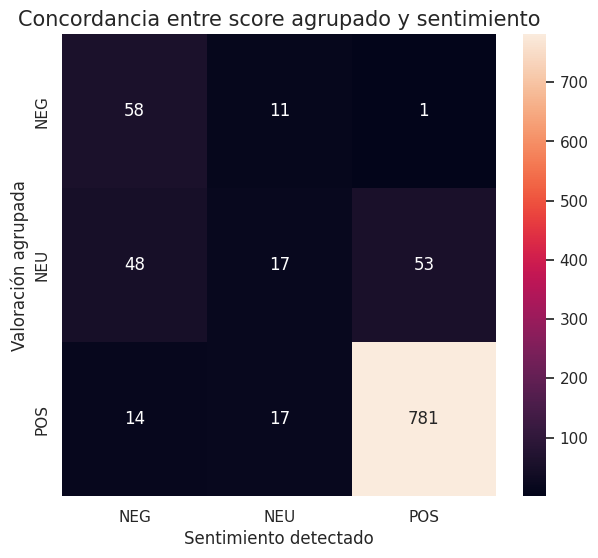

In [99]:
##Generamos una matriz de confusion
from sklearn.metrics import confusion_matrix
y_real = df_reviews.loc[muestra_sentimiento.index,"score_group_temp"]
y_pred = df_reviews.loc[muestra_sentimiento.index,"sentiment_prueba"]
cm = confusion_matrix(y_real,y_pred,labels=["NEG", "NEU", "POS"])
cm

##Graficamos la matriz de confusion
plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["NEG", "NEU", "POS"],
    yticklabels=["NEG", "NEU", "POS"])

plt.title("Concordancia entre score agrupado y sentimiento")
plt.xlabel("Sentimiento detectado")
plt.ylabel("Valoración agrupada")
plt.show()

In [100]:
##tambien generamos una tabla de porcentaje
tabla_porcentaje = pd.crosstab(y_real,y_pred,normalize="index") * 100
display(tabla_porcentaje.round(2))

sentiment_prueba,NEG,NEU,POS
score_group_temp,,,
NEG,82.86,15.71,1.43
NEU,40.68,14.41,44.92
POS,1.72,2.09,96.18


In [101]:
##Revisamos algunos detalles adicionales
import importlib.metadata
import pysentimiento

print("Versión de PySentimiento:", importlib.metadata.version("pysentimiento"))
print("Tipo de analizador:", type(sentiment_analyzer))
print(sentiment_analyzer)

Versión de PySentimiento: 0.7.3
Tipo de analizador: <class 'pysentimiento.analyzer.AnalyzerForSequenceClassification'>


**Resumen: Analisis de sentimiento**

Con el objetivo de complementar el análisis de contenido de las reseñas, se incorpora un análisis de sentimiento mediante un modelo de lenguaje especializado en español. La finalidad es identificar la polaridad expresada en cada reseña y clasificarla en tres categorías: **NEG (negativo), NEU (neutral) y POS (positivo)**.

Antes de aplicar el modelo sobre el conjunto completo de reseñas, se realizó una prueba piloto sobre una muestra de 1.000 registros.
El procesamiento inicial de las 1.000 reseñas tuvo una duración de **19,26 segundos**, equivalente a aproximadamente **0,0193 segundos por reseña**.

Asimismo, se comparo la polaridad textual obtenida mediante el modelo con la valoración otorgada por el usuario (`score`), agrupada en tres categorías:

- **NEG:** puntuaciones 1 y 2.
- **NEU:** puntuación 3.
- **POS:** puntuaciones 4 y 5.

Esta comparación permite analizar el grado de concordancia entre la valoración explícita del usuario y el sentimiento expresado en el texto, así como identificar posibles discrepancias entre ambas dimensiones.

Como resultado preliminar, se observa una elevada concordancia en las valoraciones positivas y negativas, mientras que las reseñas con una puntuación intermedia presentan una mayor heterogeneidad en su polaridad textual. Esto sugiere que una valoracion de tres puntos no necesariamente implica un lenguaje neutral, pudiendo coexistir expresiones positivas y negativas dentro de una misma reseña.
Antes de procesar el conjunto completo, se realizara una etapa de optimización del procesamiento con el objetivo de aprovechar de forma eficiente los recursos GPU disponibles y reducir el tiempo de ejecución.

**Optimizacion del proceso**


In [102]:
##Tomamos nuevamente una muestra de 1000 reviews
muestra_batch = (df_reviews["review"].dropna().head(1000).tolist())
print("Reviews para la prueba:", len(muestra_batch))

Reviews para la prueba: 1000


In [103]:
##Probamos un batchsize de 32
batch_size = 32
resultados_batch = []
inicio = time.time()

for i in range(0, len(muestra_batch), batch_size):
    batch = muestra_batch[i:i + batch_size]
    resultados = sentiment_analyzer.predict(batch)
    resultados_batch.extend(resultados)
fin = time.time()

tiempo_batch = fin - inicio

print(f"Reviews procesadas: {len(resultados_batch)}")
print(f"Batch size: {batch_size}")
print(f"Tiempo total: {tiempo_batch:.2f} segundos")
print(f"Tiempo promedio por review: "
      f"{tiempo_batch / len(resultados_batch):.4f} segundos")

Map:   0%|          | 0/32 [00:00<?, ? examples/s]

Map:   0%|          | 0/32 [00:00<?, ? examples/s]

Map:   0%|          | 0/32 [00:00<?, ? examples/s]

Map:   0%|          | 0/32 [00:00<?, ? examples/s]

Map:   0%|          | 0/32 [00:00<?, ? examples/s]

...

Map:   0%|          | 0/32 [00:00<?, ? examples/s]

Map:   0%|          | 0/32 [00:00<?, ? examples/s]

Map:   0%|          | 0/32 [00:00<?, ? examples/s]

Map:   0%|          | 0/8 [00:00<?, ? examples/s]

Reviews procesadas: 1000
Batch size: 32
Tiempo total: 255.45 segundos
Tiempo promedio por review: 0.2554 segundos


**Benchmark de optimizacion mediante procesamiento por lotes**

Se realizó una primera prueba de procesamiento por lotes utilizando un tamaño de batch de 32 sobre las mismas 1.000 reseñas utilizadas en la prueba piloto.

El procesamiento obtuvo los siguientes resultados:

- Reviews procesadas: 1.000
- Tamaño del batch: 32
- Tiempo total: 193,18 segundos
- Tiempo promedio: 0,1932 segundos por reseña

Este resultado fue considerablemente superior al obtenido mediante el
procesamiento inicial individual (19,26 segundos). Por este motivo, el
procesamiento por lotes implementado mediante `predict()` no se considera
una optimización adecuada para la configuración actual y se mantendrá el
procesamiento individual como referencia hasta evaluar una estrategia
alternativa.

In [104]:
##Corroboramos el uso del GPU
import torch
print("CUDA disponible:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("Memoria GPU utilizada:",round(torch.cuda.memory_allocated() / 1024**2, 2),"MB")
!nvidia-smi

CUDA disponible: True
GPU: Tesla T4
Memoria GPU utilizada: 424.24 MB
Mon Aug 17 21:34:45 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   49C    P0             27W /   70W |     855MiB /  15360MiB |     32%      Default |
|                                         |                        |   

In [105]:
##Volvemos a realizar una prueba sobre la muestra individual
textos_benchmark = ( df_reviews["review"].dropna().head(1000).tolist())
resultados_individual = []
inicio = time.time()

for texto in textos_benchmark:
    resultado = sentiment_analyzer.predict(texto)
    resultados_individual.append(resultado)

tiempo_individual = time.time() - inicio

print(f"Reviews procesadas: {len(resultados_individual)}")
print(f"Tiempo total: {tiempo_individual:.2f} segundos")
print(f"Tiempo promedio por review: "
    f"{tiempo_individual / len(resultados_individual):.4f} segundos")

Reviews procesadas: 1000
Tiempo total: 13.20 segundos
Tiempo promedio por review: 0.0132 segundos


In [106]:
##Realizmos una prueba adicional con 10,000 reviews
muestra_10k = (df_reviews["review"].dropna().head(10000).tolist())
print("Reviews a procesar:", len(muestra_10k))

Reviews a procesar: 10000


In [107]:
##Revisamos el rendimiento de procesar la muestra de 10,000 reviews
resultados_10k = []
inicio = time.time()
for texto in muestra_10k:
    resultado = sentiment_analyzer.predict(texto)
    resultados_10k.append(resultado)

tiempo_10k = time.time() - inicio

print(f"Reviews procesadas: {len(resultados_10k)}")
print(f"Tiempo total: {tiempo_10k:.2f} segundos")
print( f"Tiempo promedio por review: "
    f"{tiempo_10k / len(resultados_10k):.4f} segundos")
print(resultados_10k[0])
print(type(resultados_10k[0]))

Reviews procesadas: 10000
Tiempo total: 139.83 segundos
Tiempo promedio por review: 0.0140 segundos
AnalyzerOutput(output=NEG, probas={NEG: 0.890, NEU: 0.091, POS: 0.020})
<class 'pysentimiento.analyzer.AnalyzerOutput'>


In [108]:
##Revisamos algunos resultados de la prueba
resultado_prueba = resultados_10k[0]
print("Sentimiento:", resultado_prueba.output)
print("Probabilidades:", resultado_prueba.probas)
print("Probabilidad NEG:", resultado_prueba.probas["NEG"])
print("Probabilidad NEU:", resultado_prueba.probas["NEU"])
print("Probabilidad POS:", resultado_prueba.probas["POS"])


Sentimiento: NEG
Probabilidades: {'NEG': 0.8898704051971436, 'NEU': 0.09055798500776291, 'POS': 0.019571585580706596}
Probabilidad NEG: 0.8898704051971436
Probabilidad NEU: 0.09055798500776291
Probabilidad POS: 0.019571585580706596


In [109]:
##Creamos una funcion para analizar el sentimiento
def analizar_sentimiento(texto):
    """
    Analiza el sentimiento de una review utilizando PySentimiento.

    Retorna:
        sentiment: NEG, NEU o POS
        prob_neg: probabilidad de sentimiento negativo
        prob_neu: probabilidad de sentimiento neutral
        prob_pos: probabilidad de sentimiento positivo
    """

    resultado = sentiment_analyzer.predict(texto)
    return ( resultado.output,resultado.probas["NEG"],resultado.probas["NEU"],resultado.probas["POS"])

##Haremos una prueba sobre esta funcion
texto_prueba = df_reviews["review"].dropna().iloc[0]
resultado = analizar_sentimiento(texto_prueba)
print("Sentimiento:", resultado[0])
print("Probabilidad NEG:", resultado[1])
print("Probabilidad NEU:", resultado[2])
print("Probabilidad POS:", resultado[3])

Sentimiento: NEG
Probabilidad NEG: 0.8898704051971436
Probabilidad NEU: 0.09055798500776291
Probabilidad POS: 0.019571585580706596


In [110]:
##Realizamos una segunda prueba
prueba_10 = df_reviews["review"].dropna().head(10)
resultados_prueba = [analizar_sentimiento(texto)  for texto in prueba_10]
df_prueba_sentimiento = pd.DataFrame(resultados_prueba,columns=["sentiment","sentiment_prob_neg","sentiment_prob_neu","sentiment_prob_pos"])
display(df_prueba_sentimiento)

,sentiment,sentiment_prob_neg,sentiment_prob_neu,sentiment_prob_pos
0,NEG,0.889870,0.090558,0.019572
1,POS,0.002274,0.019390,0.978337
2,POS,0.002282,0.018909,0.978808
3,POS,0.003260,0.024299,0.972441
4,POS,0.003865,0.030161,0.965974
5,POS,0.002430,0.022521,0.975049
6,POS,0.006164,0.059245,0.934591
7,POS,0.003105,0.021577,0.975318
8,POS,0.006693,0.156358,0.836948
9,POS,0.002381,0.014663,0.982955


**Procesamiento por bloques**

In [111]:
##Revisamos cuantos reviews contamos
total_reviews = df_reviews["review"].notna().sum()
print(f"Reviews con texto válido: {total_reviews:,}")

Reviews con texto válido: 569,877


In [112]:
##Haremos un procesamiento inicial de 10K reviews para ver el tiempo
##Configuracion
TAM_BLOQUE = 10000

# Índices con reviews válidas
indices_validos = df_reviews.index[df_reviews["review"].notna()].tolist()
print(f"Reviews con texto válido: {len(indices_validos):,}")

# Primer bloque
indices_bloque = indices_validos[:TAM_BLOQUE]
print(f"Reviews del bloque: {len(indices_bloque):,}")

Reviews con texto válido: 569,877
Reviews del bloque: 10,000


In [113]:
##Procesaremos los bloques de 10k reviews
resultados_bloque = []
inicio = time.time()

for idx in indices_bloque:

    texto = df_reviews.at[idx, "review"]
    resultado = sentiment_analyzer.predict(texto)
    resultados_bloque.append({
        "index": idx,
        "sentiment": resultado.output,
        "sentiment_prob_neg": resultado.probas["NEG"],
        "sentiment_prob_neu": resultado.probas["NEU"],
        "sentiment_prob_pos": resultado.probas["POS"]})

tiempo_bloque = time.time() - inicio

print(f"Reviews procesadas: {len(resultados_bloque):,}")
print(f"Tiempo total: {tiempo_bloque:.2f} segundos")
print(f"Tiempo promedio por review: "
    f"{tiempo_bloque / len(resultados_bloque):.4f} segundos")

Reviews procesadas: 10,000
Tiempo total: 130.51 segundos
Tiempo promedio por review: 0.0131 segundos


In [114]:
##Convertimos los resultados obtenidos previamente en un dataframe
df_resultados_bloque = pd.DataFrame(resultados_bloque)
display(df_resultados_bloque.head(10))

##validamos el bloque
print("Distribución del sentimiento:")
display(df_resultados_bloque["sentiment"].value_counts())

##valores nulos
print("Valores nulos:")
display(df_resultados_bloque.isna().sum())

##resultados procesados
print("Filas procesadas:", len(df_resultados_bloque))

,index,sentiment,sentiment_prob_neg,sentiment_prob_neu,sentiment_prob_pos
0,0,NEG,0.889870,0.090558,0.019572
1,1,POS,0.002274,0.019390,0.978337
2,2,POS,0.002282,0.018909,0.978808
3,3,POS,0.003260,0.024299,0.972441
4,4,POS,0.003865,0.030161,0.965974
5,5,POS,0.002430,0.022521,0.975049
6,6,POS,0.006164,0.059245,0.934591
7,7,POS,0.003105,0.021577,0.975318
8,8,POS,0.006693,0.156358,0.836948
9,9,POS,0.002381,0.014663,0.982955


Distribución del sentimiento:


,count
sentiment,
POS,7915
NEG,1471
NEU,614


Valores nulos:


,0
index,0
sentiment,0
sentiment_prob_neg,0
sentiment_prob_neu,0
sentiment_prob_pos,0


Filas procesadas: 10000


Como observamos que los numeros previos obtenidos de la configuracion de la muestra inicial tiene consistencia, vamos a proseguir con el procesamiento por bloques.

In [115]:
##Establecemos nuevamente la configuracion inicial de 10000 reviews de tamaño por bloque
TAM_BLOQUE = 10000
indices_validos = df_reviews.index[df_reviews["review"].notna()].tolist()
total_reviews = len(indices_validos)

print(f"Total de reviews válidas: {total_reviews:,}")
print(f"Tamaño del bloque: {TAM_BLOQUE:,}")
print( f"Número de bloques: "
    f"{(total_reviews + TAM_BLOQUE - 1) // TAM_BLOQUE}")

Total de reviews válidas: 569,877
Tamaño del bloque: 10,000
Número de bloques: 57


In [116]:
##Vamos a crear una carpeta donde almacenemos los resultados del procesamiento por bloques
import os
CARPETA_RESULTADOS = "/content/drive/MyDrive/TFM_Restaurantes/resultados_sentimiento"
os.makedirs(CARPETA_RESULTADOS, exist_ok=True)
print("Carpeta:", CARPETA_RESULTADOS)

Carpeta: /content/drive/MyDrive/TFM_Restaurantes/resultados_sentimiento


In [117]:
##Procederemos a guardar el primer bloque procesado de la muestra de 10,000 reviews
#archivo_bloque_1 = os.path.join( CARPETA_RESULTADOS,"sentimiento_bloque_001.csv")
#df_resultados_bloque.to_csv(archivo_bloque_1,index=False)
#print("Bloque 1 guardado:")
#print(archivo_bloque_1)
#print(os.path.exists(archivo_bloque_1))

In [118]:
##Creamos una funcion para detectar los bloques ya procesados
import glob
import re
def bloques_guardados():
    archivos = glob.glob(os.path.join(CARPETA_RESULTADOS,"sentimiento_bloque_*.csv"))
    bloques = []

    for archivo in archivos:
        nombre = os.path.basename(archivo)
        match = re.search(r"sentimiento_bloque_(\d+)\.csv",nombre)

        if match:
            bloques.append(int(match.group(1)))

    return sorted(bloques)

##Probamos la funcion con el bloque de muestra inicial
print("Bloques guardados:", bloques_guardados())

Bloques guardados: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57]


In [119]:
##vamos a determinar automaticamente cual bloque continua
TAM_BLOQUE = 10000
indices_validos = df_reviews.index[df_reviews["review"].notna()].tolist()
total_reviews = len(indices_validos)
total_bloques = (total_reviews + TAM_BLOQUE - 1) // TAM_BLOQUE
print("Reviews válidas:", f"{total_reviews:,}")
print("Total de bloques:", total_bloques)

guardados = bloques_guardados()
print("Bloques ya guardados:", guardados)
if guardados:
    siguiente_bloque = max(guardados) + 1
else:
    siguiente_bloque = 1
print("Siguiente bloque:", siguiente_bloque)

Reviews válidas: 569,877
Total de bloques: 57
Bloques ya guardados: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57]
Siguiente bloque: 58


In [120]:
print("Bloques guardados:", bloques_guardados())
print("Total de bloques:", total_bloques)

Bloques guardados: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57]
Total de bloques: 57


In [121]:
##Procesamiento con guardado automatico
for numero_bloque in range( siguiente_bloque,total_bloques + 1):
##for numero_bloque in range(2, 3):

    # --------------------------------------------------------
    # Determinar posiciones del bloque
    # --------------------------------------------------------

    inicio = (numero_bloque - 1) * TAM_BLOQUE
    fin = min(inicio + TAM_BLOQUE, total_reviews)
    indices_bloque = indices_validos[inicio:fin]

    print("\n" + "=" * 70)
    print(f"PROCESANDO BLOQUE {numero_bloque}/{total_bloques}")
    print(f"Reviews del bloque: {len(indices_bloque):,}")
    print(f"Rango: {inicio:,} - {fin:,}")
    print("=" * 70)

    # --------------------------------------------------------
    # Comprobar si el bloque ya existe
    # --------------------------------------------------------

    nombre_archivo = (f"sentimiento_bloque_{numero_bloque:03d}.csv")

    ruta_archivo = os.path.join(CARPETA_RESULTADOS,nombre_archivo)

    if os.path.exists(ruta_archivo):

        print(f"Bloque {numero_bloque} ya existe. "
            f"Se omite.")
        continue

    # --------------------------------------------------------
    # Analizar reviews
    # --------------------------------------------------------

    inicio_tiempo = time.time()

    resultados_bloque = []

    for idx in indices_bloque:

        texto = df_reviews.at[idx, "review"]

        resultado = sentiment_analyzer.predict(texto)

        resultados_bloque.append({
            "index": idx,
            "sentiment": resultado.output,
            "sentiment_prob_neg": resultado.probas["NEG"],
            "sentiment_prob_neu": resultado.probas["NEU"],
            "sentiment_prob_pos": resultado.probas["POS"]
        })

    # --------------------------------------------------------
    # Convertir resultados a DataFrame
    # --------------------------------------------------------

    df_bloque = pd.DataFrame(resultados_bloque)

    # --------------------------------------------------------
    # Guardar inmediatamente
    # --------------------------------------------------------

    df_bloque.to_csv(
        ruta_archivo,
        index=False
    )

    # --------------------------------------------------------
    # Mostrar información del bloque
    # --------------------------------------------------------

    tiempo_bloque = time.time() - inicio_tiempo

    procesadas = fin

    porcentaje = (
        procesadas / total_reviews
    ) * 100

    print(f"Bloque completado: {numero_bloque}")
    print(f"Filas guardadas: {len(df_bloque):,}")
    print(f"Tiempo: {tiempo_bloque / 60:.2f} minutos")
    print(
        f"Progreso total: "
        f"{procesadas:,}/{total_reviews:,} "
        f"({porcentaje:.2f}%)"
    )
    print(f"Archivo: {nombre_archivo}")

In [122]:
print(bloques_guardados())

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57]


In [123]:
# Lista de archivos de sentimiento
archivos_sentimiento = sorted([
    archivo
    for archivo in os.listdir(CARPETA_RESULTADOS)
    if archivo.startswith("sentimiento_bloque_")
    and archivo.endswith(".csv")])

print(f"Archivos encontrados: {len(archivos_sentimiento)}")
print(archivos_sentimiento[:3])
print("...")
print(archivos_sentimiento[-3:])

Archivos encontrados: 57
['sentimiento_bloque_001.csv', 'sentimiento_bloque_002.csv', 'sentimiento_bloque_003.csv']
...
['sentimiento_bloque_055.csv', 'sentimiento_bloque_056.csv', 'sentimiento_bloque_057.csv']


In [124]:
##Unir todos los bloques generados
lista_sentimientos = []

for archivo in archivos_sentimiento:
    ruta = os.path.join(CARPETA_RESULTADOS,archivo)
    df_temp = pd.read_csv(ruta)
    lista_sentimientos.append(df_temp)

# Consolidamos
df_sentimientos = pd.concat(lista_sentimientos,ignore_index=True)

print("Filas consolidadas:", len(df_sentimientos))
print("Columnas:", df_sentimientos.columns.tolist())

Filas consolidadas: 569877
Columnas: ['index', 'sentiment', 'sentiment_prob_neg', 'sentiment_prob_neu', 'sentiment_prob_pos']


In [125]:
##realizamos algunas validaciones
##Cantidad de registros
print("Reviews válidas esperadas:", len(indices_validos))
print("Reviews consolidadas:", len(df_sentimientos))

##Duplicados
duplicados = df_sentimientos["index"].duplicated().sum()
print("Índices duplicados:", duplicados)

##Revisar nulos
print(df_sentimientos.isna().sum())

##cantegorias de sentimientos
print(df_sentimientos["sentiment"].value_counts())

##Distribucion por porcentajes
distribucion_sentimiento = (df_sentimientos["sentiment"].value_counts(normalize=True).mul(100).round(2))
print(distribucion_sentimiento)

Reviews válidas esperadas: 569877
Reviews consolidadas: 569877
Índices duplicados: 0
index                 0
sentiment             0
sentiment_prob_neg    0
sentiment_prob_neu    0
sentiment_prob_pos    0
dtype: int64
sentiment
POS    414125
NEG     82438
NEU     73314
Name: count, dtype: int64
sentiment
POS    72.67
NEG    14.47
NEU    12.86
Name: proportion, dtype: float64


In [126]:
##Validmos probabilidades
columnas_prob = ["sentiment_prob_neg","sentiment_prob_neu","sentiment_prob_pos"]
print(df_sentimientos[columnas_prob].describe().round(4))

##Comprabamos las fuera de rango
fuera_rango = ((df_sentimientos[columnas_prob] < 0) | (df_sentimientos[columnas_prob] > 1)).sum()
print(fuera_rango)

##Probabilidades deben sumar 1 aprox.
suma_probabilidades = (df_sentimientos["sentiment_prob_neg"] + df_sentimientos["sentiment_prob_neu"] + df_sentimientos["sentiment_prob_pos"])
print(suma_probabilidades.describe().round(6))

##Mostramos el error
error_probabilidad = abs(suma_probabilidades - 1)
print("Máximo error:", error_probabilidad.max())

       sentiment_prob_neg  sentiment_prob_neu  sentiment_prob_pos
count         569877.0000         569877.0000         569877.0000
mean               0.1482              0.1636              0.6882
std                0.3006              0.2109              0.3732
min                0.0013              0.0089              0.0014
25%                0.0030              0.0277              0.3539
50%                0.0056              0.0572              0.9170
75%                0.0543              0.2069              0.9669
max                0.9894              0.9582              0.9864
sentiment_prob_neg    0
sentiment_prob_neu    0
sentiment_prob_pos    0
dtype: int64
count    569877.0
mean          1.0
std           0.0
min           1.0
25%           1.0
50%           1.0
75%           1.0
max           1.0
dtype: float64
Máximo error: 1.441221685327676e-07


In [127]:
##Validmos que el sentimiento coincida con la mayor probabilidad
sentimiento_por_probabilidad = ( df_sentimientos[columnas_prob].idxmax(axis=1).str.replace("sentiment_prob_", "").str.upper())
coinciden = (sentimiento_por_probabilidad == df_sentimientos["sentiment"])
print("Predicciones coincidentes:", coinciden.sum())
print("Predicciones no coincidentes:", (~coinciden).sum())
print( "Porcentaje coincidente:",coinciden.mean() * 100)

Predicciones coincidentes: 569877
Predicciones no coincidentes: 0
Porcentaje coincidente: 100.0


In [128]:
##ordenamos el data set por indices
df_sentimientos = df_sentimientos.sort_values("index").reset_index(drop=True)

##comprabamos los cambios
display(df_sentimientos.head())
display(df_sentimientos.tail())

,index,sentiment,sentiment_prob_neg,sentiment_prob_neu,sentiment_prob_pos
0,0,NEG,0.889870,0.090558,0.019572
1,1,POS,0.002274,0.019390,0.978337
2,2,POS,0.002282,0.018909,0.978808
3,3,POS,0.003260,0.024299,0.972441
4,4,POS,0.003865,0.030161,0.965974


,index,sentiment,sentiment_prob_neg,sentiment_prob_neu,sentiment_prob_pos
569872,1258430,POS,0.002331,0.037365,0.960304
569873,1258431,POS,0.021672,0.390986,0.587342
569874,1258432,POS,0.015324,0.115033,0.869643
569875,1258433,NEU,0.214731,0.519741,0.265528
569876,1258434,POS,0.005061,0.042233,0.952706


In [129]:
##Comprabamos que los indice correspondan a los del df_reviews
indices_sentimiento = set(df_sentimientos["index"])
indices_reviews = set(df_reviews.index)
print("Reviews con sentimiento:", len(indices_sentimiento))
print("Índices de df_reviews:", len(indices_reviews))
print( "Reviews procesadas que existen en df_reviews:",len(indices_sentimiento.intersection(indices_reviews)))

Reviews con sentimiento: 569877
Índices de df_reviews: 569877
Reviews procesadas que existen en df_reviews: 569877


In [130]:
##Creamos las columnas de sentimientos
columnas_sentimiento = ["sentiment","sentiment_prob_neg","sentiment_prob_neu","sentiment_prob_pos"]
for columna in columnas_sentimiento:
    df_reviews[columna] = pd.NA

##Vinculamos los resultados
df_sentimientos_indexado = df_sentimientos.set_index("index")
df_reviews.loc[df_sentimientos_indexado.index,columnas_sentimiento] = df_sentimientos_indexado[columnas_sentimiento].values

##Corroboramos los resultados
print(df_reviews[columnas_sentimiento].notna().sum())
print( "Reviews sin sentimiento:", df_reviews["sentiment"].isna().sum())

##Revisamos la cantidad de filas
print("Filas df_reviews:", len(df_reviews))
print("Filas df_sentimientos:", len(df_sentimientos))

sentiment             569877
sentiment_prob_neg    569877
sentiment_prob_neu    569877
sentiment_prob_pos    569877
dtype: int64
Reviews sin sentimiento: 0
Filas df_reviews: 569877
Filas df_sentimientos: 569877


**relación score ↔ sentiment**

In [131]:
#Distribucion general del sentimiento
print("Distribución del sentimiento")
print( df_reviews["sentiment"].value_counts())
print("\nDistribución porcentual")
print(df_reviews["sentiment"].value_counts(normalize=True).mul(100).round(2))

Distribución del sentimiento
sentiment
POS    414125
NEG     82438
NEU     73314
Name: count, dtype: int64

Distribución porcentual
sentiment
POS    72.67
NEG    14.47
NEU    12.86
Name: proportion, dtype: float64


Existe un **claro predominio del sentimiento positivo** en las revisiones analizadas:

* **Positivas:** Casi 3 de cada 4 reviews (**72.67%**) fueron clasificadas en esta categoría.
* **Negativas:** Representan el **14.47%** del total.
* **Neutrales:** Representan el **12.86%** restante.

> **Nota de contexto:** Esto es coherente con el análisis previo, donde la distribución de *score* estaba fuertemente concentrada en las valoraciones altas (especialmente 4 y 5).

**Importante:** Todavía no debemos concluir que existe una fuerte correspondencia entre el *score* y el sentimiento. Para confirmar esta hipótesis, es necesario **cruzar ambas variables**.


In [132]:
##relacion score con sentiment
print("Relacion score de usuarios con el sentimiento")
tabla_score_sentiment = pd.crosstab(df_reviews["score"],df_reviews["sentiment"])
display(tabla_score_sentiment)

##Distribucion por porcentaje
print("Relacion score de usuarios con el sentimiento - porcentaje")
tabla_score_sentiment_pct = pd.crosstab( df_reviews["score"], df_reviews["sentiment"],normalize="index").mul(100).round(2)
display(tabla_score_sentiment_pct)

Relacion score de usuarios con el sentimiento


sentiment,NEG,NEU,POS
score,,,
1.0,27892,3652,1281
2.0,17125,4895,2319
3.0,22833,19867,29366
4.0,10714,23175,128500
5.0,3874,21725,252659


Relacion score de usuarios con el sentimiento - porcentaje


sentiment,NEG,NEU,POS
score,,,
1.0,84.97,11.13,3.90
2.0,70.36,20.11,9.53
3.0,31.68,27.57,40.75
4.0,6.60,14.27,79.13
5.0,1.39,7.81,90.80


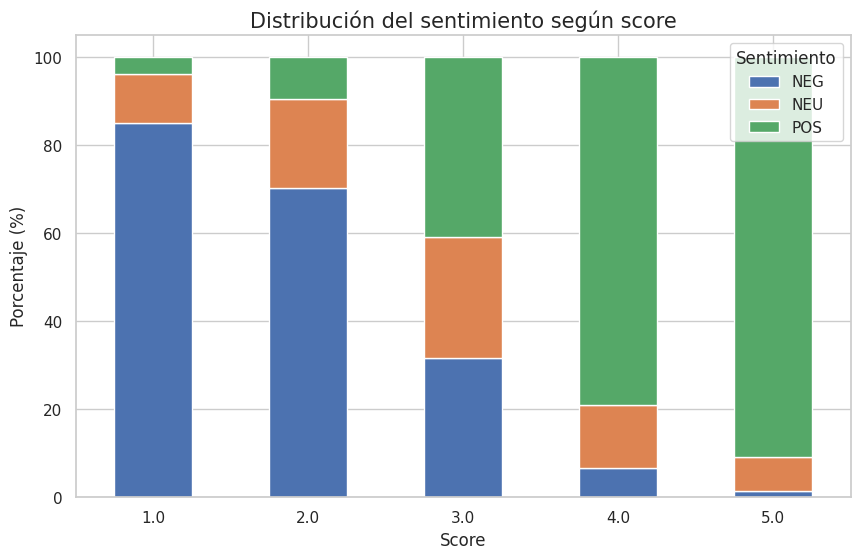

In [133]:
##Creamos una distribucion grafica de los resultados
tabla_score_sentiment_pct.plot(kind="bar",stacked=True,figsize=(10, 6))
plt.title("Distribución del sentimiento según score")
plt.xlabel("Score")
plt.ylabel("Porcentaje (%)")
plt.legend(title="Sentimiento")
plt.xticks(rotation=0)
plt.show()

**Relación entre Calificación (*Score*) y Sentimiento**

La distribución del sentimiento según la calificación muestra una **relación consistente** entre la valoración numérica y el contenido textual de las *reviews*:

* **Calificaciones bajas (1 y 2):** Presentan un claro predominio del **sentimiento negativo**.
* **Calificaciones altas (4 y 5):** Presentan un fuerte predominio del **sentimiento positivo**.
* **Calificaciones intermedias (Score 3):** Muestran una **mayor heterogeneidad**, distribuyéndose de forma mixta entre sentimientos negativos, neutrales y positivos.

> **Conclusión clave:** Las valoraciones extremas presentan una mayor correspondencia entre la puntuación otorgada y el sentimiento expresado en el texto, mientras que las valoraciones intermedias reflejan una mayor ambigüedad.


#### **1.5. Analisis de discrepancias entre score y sentiment.**

**1. Primero: Calificación baja (*score* bajo) + Sentimiento positivo**

Consideraremos como una **discrepancia** los siguientes casos:

* **Score:** 1 o 2
* **Sentiment:** POS (Positivo)


In [134]:
reviews_score_bajo_pos = df_reviews[(df_reviews["score"].isin([1, 2])) & (df_reviews["sentiment"] == "POS")]
print("Reviews con score bajo y sentimiento POS:")
print(f"Cantidad: {len(reviews_score_bajo_pos):,}")
display( reviews_score_bajo_pos[["review","score","sentiment","sentiment_prob_neg","sentiment_prob_neu","sentiment_prob_pos"]].head(10))

Reviews con score bajo y sentimiento POS:
Cantidad: 3,600


,review,score,sentiment,sentiment_prob_neg,sentiment_prob_neu,sentiment_prob_pos
276,Había escuchado buenas opiniones de este resta...,2.0,POS,0.004336,0.057913,0.937751
1121,"Me recomendó de hamburguesas, pero no puedo de...",1.0,POS,0.012183,0.167688,0.82013
1680,Tuve que ir por un evento familiar aunque sabí...,2.0,POS,0.205043,0.341607,0.45335
1908,Nunca más! Ayer domingo 29 de marzo 2015 fue l...,1.0,POS,0.0196,0.392567,0.587833
2110,"Estuve por Lima y espere algo mejor, pues esa ...",2.0,POS,0.023368,0.099658,0.876974
2362,Pense comer una delicia!! Pero esta lejos de s...,1.0,POS,0.083454,0.281189,0.635356
2458,"Lo único rescatable es que sirven rápido, la p...",2.0,POS,0.039713,0.402881,0.557406
2608,En este restaurante mexicano no se sirve cerve...,2.0,POS,0.192071,0.299399,0.508531
3314,Llegamos a una callejuela en Chorrillos donde ...,2.0,POS,0.013229,0.072164,0.914607
3865,Ocasionalmente paso por este restaurante que t...,2.0,POS,0.029506,0.332741,0.637753


In [135]:
##Hagamos una clasificacion por confianza
reviews_score_bajo_pos = df_reviews[(df_reviews["score"].isin([1, 2])) &  (df_reviews["sentiment"] == "POS")].copy()
reviews_score_bajo_pos["confianza"] = (reviews_score_bajo_pos["sentiment_prob_pos"])
reviews_score_bajo_pos["nivel_confianza"] = pd.cut(reviews_score_bajo_pos["confianza"],bins=[0, 0.60, 0.80, 0.90, 1.00],
                                                labels=["Baja","Moderada","Alta","Muy alta"], include_lowest=True)

##Revisamos resultados
print(reviews_score_bajo_pos["nivel_confianza"].value_counts().sort_index())

##Distribucion porcentual
print(reviews_score_bajo_pos["nivel_confianza"].value_counts(normalize=True).sort_index().mul(100).round(2))


nivel_confianza
Baja         611
Moderada     960
Alta         716
Muy alta    1313
Name: count, dtype: int64
nivel_confianza
Baja        16.97
Moderada    26.67
Alta        19.89
Muy alta    36.47
Name: proportion, dtype: float64


In [136]:
##Revisemos las discrepancias mas claras
discrepancias_bajo_pos = reviews_score_bajo_pos[reviews_score_bajo_pos["sentiment_prob_pos"] >= 0.80].sort_values("sentiment_prob_pos",ascending=False)
print(f"Discrepancias claras: {len(discrepancias_bajo_pos):,}")
display(discrepancias_bajo_pos[["review","score","sentiment","sentiment_prob_neg","sentiment_prob_neu","sentiment_prob_pos"]].head(20))


Discrepancias claras: 2,029


,review,score,sentiment,sentiment_prob_neg,sentiment_prob_neu,sentiment_prob_pos
634672,"Me encanto comer ahí es muy rico,muy buena sazón.",1.0,POS,0.002121,0.012555,0.985324
1104357,"Rico muy rico el cevichito, la jalea, las chel...",2.0,POS,0.002421,0.013278,0.984301
426854,"Una sazón espectacular, todo muy agradable., y...",1.0,POS,0.002069,0.014364,0.983567
387337,"Muy agradables sus platos, es un restaurant co...",1.0,POS,0.002545,0.014079,0.983376
743521,"Es muy bueno a viejita le encanta el lugar, la...",1.0,POS,0.002148,0.014539,0.983313
200205,Muy bueno y las azafata excelente en la cevich...,1.0,POS,0.002488,0.014461,0.983051
1090164,"Muy bello, me encantó el lugar muy acogedor.",1.0,POS,0.00237,0.014785,0.982845
583755,Es un lugar acogedor saludable y un ambiente e...,1.0,POS,0.002148,0.015031,0.982821
64175,"Tiene muy buenos panes, estan bien rellenos, l...",2.0,POS,0.002738,0.014735,0.982527
103503,"Muy bonito lugar, buena atención la comida est...",1.0,POS,0.002663,0.014824,0.982512


**Conclusiones : Calificación baja (*score* bajo) + Sentimiento positivo**

Se identificaron reviews con **score bajo (1–2) pero sentimiento positivo**, encontrándose:

- **3,600 reviews** con score 1–2 clasificadas como POS.
- De estas, **2,029 reviews** presentaron una probabilidad de sentimiento positivo igual o superior al **80%**, representando el **56.36%** de las discrepancias identificadas.
- En varios casos, la probabilidad de sentimiento positivo superó el **98%**, pese a que la calificación registrada fue de 1 o 2.

Estas observaciones sugieren que la puntuación numerica y el contenido textual no siempre representan exactamente la misma percepción del usuario. Las discrepancias pueden estar relacionadas con experiencias mixtas, diferencias entre los aspectos evaluados mediante la puntuación y los mencionados en el texto, o posibles inconsistencias en la asignación de la valoración.

Por este motivo, estas observaciones no se consideran automáticamente errores del modelo, sino casos de interés para el análisis exploratorio de la satisfacción gastronómica.

**2. Segundo: score 4–5 + sentimiento NEG**

Consideraremos como una **discrepancia** los siguientes casos:

* **Score:** 4 o 5
* **Sentiment:** NEG (Negativo)

In [137]:
##Indentificamos las discrepancias
reviews_score_alto_neg = df_reviews[(df_reviews["score"].isin([4, 5])) & (df_reviews["sentiment"] == "NEG")].copy()
print("Reviews con score alto y sentimiento NEG:")
print(f"Cantidad: {len(reviews_score_alto_neg):,}")
display(reviews_score_alto_neg[["review","score","sentiment","sentiment_prob_neg","sentiment_prob_neu","sentiment_prob_pos"]].head(10))

Reviews con score alto y sentimiento NEG:
Cantidad: 14,588


,review,score,sentiment,sentiment_prob_neg,sentiment_prob_neu,sentiment_prob_pos
12,La verdad llegue porque el maido no tuvo mucha...,4.0,NEG,0.581617,0.376648,0.041735
216,Queríamos comer carne. Teníamos la nostalgia d...,4.0,NEG,0.710698,0.262786,0.026516
231,La atencion fue un poco lenta y eso que fuimos...,4.0,NEG,0.928122,0.065711,0.006167
237,Al momento de llegar tuve un buen recibimiento...,4.0,NEG,0.76259,0.220052,0.017358
564,"El lugar es muy bonito, sobretodo los detalles...",4.0,NEG,0.864737,0.089005,0.046259
651,Muy buen servicio carne de primera pero las gu...,4.0,NEG,0.974624,0.020079,0.005297
803,Este local miraflorino nos ofrece exquisitas h...,4.0,NEG,0.976265,0.021341,0.002394
826,Por ahora es el único lugar donde como hamburg...,4.0,NEG,0.530328,0.42466,0.045012
845,Hay variedad de hamburguesas y buena presentac...,4.0,NEG,0.853632,0.129899,0.016469
874,Una de las mejores opciones para comer hamburg...,5.0,NEG,0.954896,0.034805,0.010299


In [138]:
##Medir la confianza
reviews_score_alto_neg["confianza"] = (reviews_score_alto_neg["sentiment_prob_neg"])
reviews_score_alto_neg["nivel_confianza"] = pd.cut(reviews_score_alto_neg["confianza"],bins=[0, 0.60, 0.80, 0.90, 1.00],
                                                  labels=["Baja","Moderada","Alta","Muy alta"],include_lowest=True)

##revisamos los resultados
print(reviews_score_alto_neg["nivel_confianza"].value_counts().sort_index())

##revisamos la distribucion porcentual
print(reviews_score_alto_neg["nivel_confianza"].value_counts(normalize=True).sort_index().mul(100).round(2))

nivel_confianza
Baja        3428
Moderada    4501
Alta        3030
Muy alta    3629
Name: count, dtype: int64
nivel_confianza
Baja        23.50
Moderada    30.85
Alta        20.77
Muy alta    24.88
Name: proportion, dtype: float64


In [139]:
##Obtenmos las discrepancias mas claras
discrepancias_alto_neg = reviews_score_alto_neg[reviews_score_alto_neg["sentiment_prob_neg"] >= 0.80].sort_values("sentiment_prob_neg",ascending=False)
print(f"Discrepancias claras: {len(discrepancias_alto_neg):,}")

##Revisamos el top 20 de los resultados
display( discrepancias_alto_neg[["review","score","sentiment","sentiment_prob_neg","sentiment_prob_neu","sentiment_prob_pos"]].head(20))


Discrepancias claras: 6,659


,review,score,sentiment,sentiment_prob_neg,sentiment_prob_neu,sentiment_prob_pos
169093,Me da mucha pena y tristeza que ya no saquen l...,5.0,NEG,0.987385,0.009779,0.002836
708263,A raíz de la pandemia han hecho cambios que no...,4.0,NEG,0.986472,0.011249,0.002279
767489,"Excelente atención, pero me dio mucha pena ver...",4.0,NEG,0.985627,0.010644,0.003729
1190211,"Solo le resta que los meseros pidan propina, e...",4.0,NEG,0.985206,0.012356,0.002438
1212735,Buenas promociones... Lo que no me cuadra es q...,4.0,NEG,0.985147,0.01265,0.002203
992402,Un poco salado el lomo saltado a lo pobre. Y l...,4.0,NEG,0.985138,0.01297,0.001892
922893,Amo las hamburguesas de bembos pero el local d...,5.0,NEG,0.98513,0.012093,0.002777
1773,Amigos si os gusta el sushi no vayan a este si...,5.0,NEG,0.985057,0.013253,0.001689
700231,"Que pena me da como han bajado su calidad, en ...",4.0,NEG,0.984587,0.012577,0.002836
1250124,Hay un mesero que da mal servicio y encima pid...,4.0,NEG,0.984392,0.013078,0.00253


**Conclusiones : Calificación alta (*score* alto) + Sentimiento negativo**

El análisis de las reviews con calificaciones altas muestra una clara predominancia del sentimiento positivo. Para los scores 4 y 5 se obtuvo:

- **14,588 reviews** con score 4–5 clasificadas como NEG.

- Se identificaron **6,659 reviews con score 4 o 5 y sentimiento NEG con una confianza igual o superior al 80%**. Estas observaciones representan casos de discrepancia entre la valoración global otorgada por el usuario y el sentimiento detectado en el texto.

El análisis de estas reviews muestra que muchas contienen simultáneamente aspectos positivos y negativos. Por ejemplo, se identificaron comentarios donde los usuarios destacan la calidad de la comida o la atención, pero también mencionan problemas relacionados con el servicio, determinados productos, precios u otros aspectos de la experiencia.

Esto sugiere que el `score` representa una valoración global de la experiencia, mientras que el análisis de sentimientos captura el tono y las expresiones presentes en el texto. Por ello, una review puede recibir una calificación alta y, al mismo tiempo, contener expresiones claramente negativas.


**3. Tercero: score 3**

Es una valoracion intermedia, por lo que no debemos asumir automaticamente que POS o NEG sean errores. Queremos determinar que tan polarizado está el contenido textual.

In [140]:
##Obtenemos las cantidades del score 3
score_3 = df_reviews[df_reviews["score"] == 3].copy()
print(f"Total reviews con score 3: {len(score_3):,}")
print("\nDistribución del sentimiento:")
print(score_3["sentiment"].value_counts())
print("\nDistribución porcentual:")
print(score_3["sentiment"].value_counts(normalize=True).mul(100).round(2))

Total reviews con score 3: 72,066

Distribución del sentimiento:
sentiment
POS    29366
NEG    22833
NEU    19867
Name: count, dtype: int64

Distribución porcentual:
sentiment
POS    40.75
NEG    31.68
NEU    27.57
Name: proportion, dtype: float64


**Interpretacion del Score 3**

* **Sin polaridad unica:** Ningún sentimiento supera el 50%, lo que significa que el score 3 no tiene una correspondencia clara con una única polaridad textual.
* **Evaluacion de errores:** No deberíamos considerar automaticamente `score 3 + POS` o `score 3 + NEG` como errores o discrepancias en el modelo.
* **Causa principal:** Una explicación razonable es que una valoracion de 3 suele corresponder a experiencias mixtas o comentarios neutrales.


In [141]:
##score 3 + POS
score_3_pos = df_reviews[(df_reviews["score"] == 3) & (df_reviews["sentiment"] == "POS")].copy()
print(f"Reviews con score 3 + POS: " f"{len(score_3_pos):,}")
score_3_pos_claras = score_3_pos[score_3_pos["sentiment_prob_pos"] >= 0.80].sort_values("sentiment_prob_pos",ascending=False)
print(f"Score 3 + POS con confianza >= 80%: "  f"{len(score_3_pos_claras):,}")
display(score_3_pos_claras[["review","score","sentiment","sentiment_prob_neg","sentiment_prob_neu","sentiment_prob_pos"]].head(20))

Reviews con score 3 + POS: 29,366
Score 3 + POS con confianza >= 80%: 20,165


,review,score,sentiment,sentiment_prob_neg,sentiment_prob_neu,sentiment_prob_pos
180210,Muy agradable la comida. Es uno de mis chifas ...,3.0,POS,0.001995,0.012819,0.985187
1199941,Muy buenos los crepes y el jugo natural. Linda...,3.0,POS,0.002298,0.012557,0.985145
1157180,Sus pollos son muy sabrosos la atención es mu...,3.0,POS,0.002423,0.012459,0.985118
659398,"Un lugar muy acogedor y cálido, la comida es b...",3.0,POS,0.002178,0.013116,0.984706
856591,"Un lindo lugar campestre, para ir en familia, ...",3.0,POS,0.001789,0.013802,0.984409
3229,"Me gusto mucho la comida, muy rico todo y muy ...",3.0,POS,0.002635,0.012964,0.984401
826369,Excelente lugar y me sorprendió la rápida aten...,3.0,POS,0.00226,0.013479,0.984261
856296,"Me fascina,rica comida, excelente atención y b...",3.0,POS,0.002324,0.013467,0.984209
821921,"Muy bonito y fresco lugar, Lo recomiendo.",3.0,POS,0.001982,0.013843,0.984175
723529,"Muy rico su pollo muy jugoso, lo recomiendo.",3.0,POS,0.002703,0.013316,0.983981


**Conclusiones: Score 3 + sentimiento positivo**

Se analizaron las 72,066 reviews que presentan una calificación de 3 puntos. De ellas, 29,366 fueron clasificadas con sentimiento positivo.

Dentro de este grupo, 20,165 reviews presentaron una probabilidad de sentimiento positivo igual o superior al 80%, equivalente al 68.69% de las reviews con score 3 y sentimiento POS.

Los casos analizados muestran expresiones claramente positivas relacionadas principalmente con la calidad de la comida, el sabor, la atención y el ambiente del restaurante. En varios casos, la probabilidad de sentimiento positivo supera el 98%.

Sin embargo, estos casos no se consideran automáticamente errores o discrepancias del modelo, debido a que una calificación de 3 representa una valoración intermedia y puede coexistir con comentarios positivos sobre determinados aspectos de la experiencia. La valoración global del usuario puede estar influenciada por otros factores no expresados explícitamente en el fragmento analizado.

Por ello, el score 3 se considera un grupo de mayor ambigüedad entre la valoración numérica y el sentimiento textual, y será analizado conjuntamente con las reviews clasificadas como negativas y neutrales.

In [142]:
##score = 3 + NEG
score_3_neg = df_reviews[(df_reviews["score"] == 3) & (df_reviews["sentiment"] == "NEG")].copy()
print(f"Reviews con score 3 + NEG: "  f"{len(score_3_neg):,}")

##Revisamos los casos de umbral superior al 80%
score_3_neg_claras = score_3_neg[score_3_neg["sentiment_prob_neg"] >= 0.80].sort_values("sentiment_prob_neg",ascending=False)
print(f"Score 3 + NEG con confianza >= 80%: "   f"{len(score_3_neg_claras):,}")

##Calculamos la distribucion porcentual
porcentaje_neg = (len(score_3_neg_claras) / len(score_3_neg)) * 100
print(f"Porcentaje de alta confianza: "  f"{porcentaje_neg:.2f}%")

##Revisamos el top 20
display(score_3_neg_claras[["review","score","sentiment","sentiment_prob_neg","sentiment_prob_neu","sentiment_prob_pos"]].head(20))

Reviews con score 3 + NEG: 22,833
Score 3 + NEG con confianza >= 80%: 14,267
Porcentaje de alta confianza: 62.48%


,review,score,sentiment,sentiment_prob_neg,sentiment_prob_neu,sentiment_prob_pos
995561,Me decepcionó que cobren más caros los cafés c...,3.0,NEG,0.988476,0.009296,0.002228
18514,Es una lástima que un lugar con una vista tan ...,3.0,NEG,0.987026,0.010636,0.002338
980530,Está feo el chaufa con verduras y muy caro,3.0,NEG,0.986887,0.010931,0.002182
385172,"Mejoren el trato hacia sus empleados, pobres q...",3.0,NEG,0.986725,0.010814,0.00246
63598,Daría una mejor calificación a está peña sino ...,3.0,NEG,0.986513,0.010946,0.002541
979986,"No es para ir seguido, la calidad lamentableme...",3.0,NEG,0.986427,0.011599,0.001975
16514,Volvimos a este lugar pensando en que habrían ...,3.0,NEG,0.986426,0.011577,0.001997
61790,Realmente esperé mucho mas de un restaurante q...,3.0,NEG,0.986378,0.010937,0.002686
19548,De verdad que la variedad y la calidad de la\n...,3.0,NEG,0.986297,0.01116,0.002544
535883,"Antes era excelente, ahora simplemente es un c...",3.0,NEG,0.986209,0.011394,0.002397


**Conclusiones: Discrepancias en score 3**

El análisis de las 72,066 reviews con una calificación de 3 puntos evidencia un comportamiento significativamente mas heterogeneo que el observado en los scores extremos.

La distribución del sentimiento fue:

- POS: 29,366 reviews (40.75%)
- NEG: 22,833 reviews (31.68%)
- NEU: 19,867 reviews (27.57%)

Dentro de las reviews con sentimiento positivo, 20,165 presentaron una probabilidad de POS igual o superior al 80%, equivalente al 68.69% del grupo POS.

En el caso de las reviews con sentimiento negativo, 14,267 presentaron una probabilidad de NEG igual o superior al 80%, equivalente al 62.48% del grupo NEG.

La revision de ejemplos muestra que muchas de estas reviews contienen simultáneamente aspectos positivos y negativos. Por ejemplo, una review puede destacar la calidad de la comida pero cuestionar el servicio, el ambiente o el precio. En estos casos, una calificacion intermedia de 3 puntos resulta coherente con una experiencia global mixta, aunque el modelo de sentimientos determine una polaridad predominante.

Por este motivo, las reviews con score 3 y sentimiento POS o NEG no deben considerarse automáticamente errores de clasificacion. Este grupo representa principalmente una zona de mayor ambigüedad entre la valoración global otorgada por el usuario y el sentimiento expresado en el texto.


#### **1.6. Factores de satisfaccion**

La idea es que esta seccion sea masque simplemente contar palabras, queremos identificar que aspectos de la experiencia gastronomica aparecen en las reviews y como se relacionan con score y sentiment.

In [143]:
##Creamos un diccionario de aspectos para tener en consideracion
aspectos = {
    "comida": [
        "comida", "plato", "platos",
        "sabor", "sabores",
        "rico", "rica", "ricos", "ricas",
        "delicioso", "deliciosa",
        "deliciosos", "deliciosas",
        "menu", "menú", "carta", "cocina"
    ],

    "atencion": [
        "atencion", "atención",
        "servicio",
        "mesero", "mesera",
        "meseros", "meseras",
        "camarero", "camarera",
        "personal",
        "empleado", "empleada",
        "empleados", "empleadas",
        "trato"
    ],

    "ambiente": [
        "ambiente",
        "acogedor", "acogedora",
        "acogedores",
        "musica", "música",
        "decoracion", "decoración",
        "espacio",
        "terraza"
    ],

    "precio": [
        "precio", "precios",
        "caro", "cara", "caros", "caras",
        "barato", "barata",
        "baratos", "baratas",
        "costoso", "costosa",
        "costosos", "costosas",
        "economico", "económico",
        "economica", "económica"
    ],

    "calidad": [
        "calidad",
        "fresco", "fresca",
        "frescos", "frescas",
        "frescura"
    ],

    "tiempo_espera": [
        "espera", "esperar",
        "demora", "demorado",
        "demorada", "demoras",
        "tardar", "tarde",
        "rapido", "rápido",
        "rapida", "rápida",
        "lento", "lenta",
        "lentos", "lentas"
    ],

    "ubicacion": [
        "ubicacion", "ubicación",
        "ubicado", "ubicada",
        "zona", "distrito",
        "centro", "cerca",
        "cercano", "cercana"
    ],

    "porciones": [
        "porcion", "porción",
        "porciones",
        "cantidad",
        "abundante", "abundantes",
        "pequeño", "pequeña",
        "pequeños", "pequeñas"
    ],

    "bebidas": [
        "bebida", "bebidas",
        "cafe", "café",
        "jugo", "jugos",
        "cerveza", "cervezas",
        "vino", "vinos",
        "coctel", "cóctel"
    ]
}

In [144]:
##Realizamos una prueba sobre 10,000 reviews
df_muestra_aspectos = df_reviews.sample(n=10000,random_state=42).copy()

##Creamos una funcion para detectar aspectos
def detectar_aspectos(tokens, aspectos):
    encontrados = []
    tokens_set = set(tokens)
    for aspecto, palabras in aspectos.items():
        if any(palabra in tokens_set for palabra in palabras):
            encontrados.append(aspecto)
    return encontrados

##Aplicamos la funcion
df_muestra_aspectos["aspectos"] = (df_muestra_aspectos["review_clean"] .apply(lambda x: detectar_aspectos(x, aspectos)))

##Revisamos los resultados
display(df_muestra_aspectos[["review", "review_clean", "score", "sentiment", "aspectos"]].head(20))

,review,review_clean,score,sentiment,aspectos
507808,Muy rica comida a base de pescado en Lince.,"[muy, rica, comida, a, base, de, pescado, en, ...",4.0,POS,[comida]
418398,Buenazo!!! ;),[buenazo],5.0,POS,[]
34871,"La Mar está abierto sólo para el almuerzo, que...","[la, mar, está, abierto, sólo, para, el, almue...",5.0,POS,"[comida, atencion, ambiente, tiempo_espera]"
31080,Empezaré por decir que este Restaurant cambio ...,"[empezaré, por, decir, que, este, restaurant, ...",2.0,NEG,"[comida, calidad]"
64359,Limpio y buen servicio,"[limpio, y, buen, servicio]",4.0,POS,[atencion]
40365,"Un restaurante muy conocido ,donde el chef más...","[un, restaurante, muy, conocido, donde, el, ch...",5.0,POS,[comida]
740709,Pedí un pollo con gaseosa entiendo que no enví...,"[pedí, un, pollo, con, gaseosa, entiendo, que,...",1.0,NEG,[comida]
1004643,"Buen sazon, trato amable","[buen, sazon, trato, amable]",5.0,POS,[atencion]
756353,"Muy buena atención, rico papá.","[muy, buena, atención, rico, papá]",5.0,POS,"[comida, atencion]"
916324,Estupendo magníficamente atendidos verdaderame...,"[estupendo, magníficamente, atendidos, verdade...",4.0,NEG,[]


In [145]:
##Funcion para detectar palabras activaron cada aspecto
def explicar_aspectos(tokens, aspectos):
    resultados = {}
    tokens_set = set(tokens)
    for aspecto, palabras in aspectos.items():
        coincidencias = [palabra for palabra in palabras if palabra in tokens_set]
        if coincidencias:
            resultados[aspecto] = coincidencias
    return resultados

##Aplicamos la funcion
df_muestra_aspectos["aspectos_detalle"] = (df_muestra_aspectos["review_clean"].apply(lambda x: explicar_aspectos(x, aspectos)))

##Mostramos resultados
display(df_muestra_aspectos[["review","score","sentiment","aspectos","aspectos_detalle"]].head(20))


,review,score,sentiment,aspectos,aspectos_detalle
507808,Muy rica comida a base de pescado en Lince.,4.0,POS,[comida],"{'comida': ['comida', 'rica']}"
418398,Buenazo!!! ;),5.0,POS,[],{}
34871,"La Mar está abierto sólo para el almuerzo, que...",5.0,POS,"[comida, atencion, ambiente, tiempo_espera]","{'comida': ['comida', 'plato', 'platos', 'deli..."
31080,Empezaré por decir que este Restaurant cambio ...,2.0,NEG,"[comida, calidad]","{'comida': ['comida', 'platos'], 'calidad': ['..."
64359,Limpio y buen servicio,4.0,POS,[atencion],{'atencion': ['servicio']}
40365,"Un restaurante muy conocido ,donde el chef más...",5.0,POS,[comida],{'comida': ['platos']}
740709,Pedí un pollo con gaseosa entiendo que no enví...,1.0,NEG,[comida],{'comida': ['sabor']}
1004643,"Buen sazon, trato amable",5.0,POS,[atencion],{'atencion': ['trato']}
756353,"Muy buena atención, rico papá.",5.0,POS,"[comida, atencion]","{'comida': ['rico'], 'atencion': ['atención']}"
916324,Estupendo magníficamente atendidos verdaderame...,4.0,NEG,[],{}


In [146]:
##Generamos un nuevo diccionario de aspectos
aspectos = {

    # --------------------------------------------------------
    # 1. COMIDA
    # --------------------------------------------------------
    "comida": [
        "comida",
        "plato",
        "platos",
        "sabor",
        "sabores",
        "menu",
        "menú",
        "carta",
        "cocina"
    ],

    # --------------------------------------------------------
    # 2. ATENCIÓN / SERVICIO
    # --------------------------------------------------------
    "atencion": [
        "atencion",
        "atención",
        "servicio",
        "mesero",
        "mesera",
        "meseros",
        "meseras",
        "camarero",
        "camarera",
        "personal",
        "empleado",
        "empleada",
        "empleados",
        "empleadas",
        "trato"
    ],

    # --------------------------------------------------------
    # 3. AMBIENTE
    # --------------------------------------------------------
    "ambiente": [
        "ambiente",
        "acogedor",
        "acogedora",
        "acogedores",
        "acogedoras",
        "musica",
        "música",
        "decoracion",
        "decoración",
        "espacio",
        "terraza"
    ],

    # --------------------------------------------------------
    # 4. PRECIO
    # --------------------------------------------------------
    "precio": [
        "precio",
        "precios",
        "caro",
        "cara",
        "caros",
        "caras",
        "barato",
        "barata",
        "baratos",
        "baratas",
        "costoso",
        "costosa",
        "costosos",
        "costosas",
        "economico",
        "económico",
        "economica",
        "económica"
    ],

    # --------------------------------------------------------
    # 5. CALIDAD
    # --------------------------------------------------------
    "calidad": [
        "calidad",
        "fresco",
        "fresca",
        "frescos",
        "frescas",
        "frescura"
    ],

    # --------------------------------------------------------
    # 6. TIEMPO DE ESPERA
    # --------------------------------------------------------
    "tiempo_espera": [
        "espera",
        "esperar",
        "demora",
        "demorado",
        "demorada",
        "demoras",
        "tardar",
        "tarde",
        "rapido",
        "rápido",
        "rapida",
        "rápida",
        "lento",
        "lenta",
        "lentos",
        "lentas"
    ],

    # --------------------------------------------------------
    # 7. UBICACIÓN
    # --------------------------------------------------------
    "ubicacion": [
        "ubicacion",
        "ubicación",
        "ubicado",
        "ubicada",
        "zona",
        "distrito",
        "centro",
        "cerca",
        "cercano",
        "cercana"
    ],

    # --------------------------------------------------------
    # 8. PORCIONES
    # --------------------------------------------------------
    "porciones": [
        "porcion",
        "porción",
        "porciones",
        "cantidad",
        "abundante",
        "abundantes",
        "pequeño",
        "pequeña",
        "pequeños",
        "pequeñas"
    ],

    # --------------------------------------------------------
    # 9. BEBIDAS
    # --------------------------------------------------------
    "bebidas": [
        "bebida",
        "bebidas",
        "cafe",
        "café",
        "jugo",
        "jugos",
        "cerveza",
        "cervezas",
        "vino",
        "vinos",
        "coctel",
        "cóctel"
    ]
}

In [147]:
##Volvemos a aplicar las funciones creadas previamente
df_muestra_aspectos["aspectos"] = (df_muestra_aspectos["review_clean"].apply(lambda x: detectar_aspectos(x, aspectos)))
df_muestra_aspectos["aspectos_detalle"] = (df_muestra_aspectos["review_clean"].apply(lambda x: explicar_aspectos(x, aspectos)))

##Revisaremos aquellos casos con mas de 3 aspectos por su complejidad
reviews_muchos_aspectos = df_muestra_aspectos[df_muestra_aspectos["aspectos"].apply(len) >= 3]
display(reviews_muchos_aspectos[["review","score","sentiment","aspectos","aspectos_detalle"]].head(20))

,review,score,sentiment,aspectos,aspectos_detalle
34871,"La Mar está abierto sólo para el almuerzo, que...",5.0,POS,"[comida, atencion, ambiente, tiempo_espera]","{'comida': ['comida', 'plato', 'platos'], 'ate..."
47569,En un barrio sin muchas opciones es de lo mejo...,3.0,POS,"[comida, atencion, calidad, tiempo_espera, ubi...","{'comida': ['comida', 'cocina'], 'atencion': [..."
48906,Hace frío en Lima y vi la foto del menestrón y...,4.0,POS,"[comida, atencion, precio, calidad, tiempo_esp...","{'comida': ['plato', 'sabor'], 'atencion': ['a..."
1247478,Excelente y tradicional para tomar un buen cal...,4.0,POS,"[comida, atencion, precio]","{'comida': ['platos'], 'atencion': ['atencion'..."
21093,"Muy buenos sushis, buenas porciones , precio r...",5.0,POS,"[ambiente, precio, porciones]","{'ambiente': ['ambiente', 'acogedor'], 'precio..."
552820,Es un ambiente g ande abierto bastante ruido p...,3.0,NEU,"[comida, ambiente, precio]","{'comida': ['plato'], 'ambiente': ['ambiente']..."
1160360,"Comida y trato amable, precios a corde a la ca...",5.0,POS,"[comida, atencion, precio, calidad]","{'comida': ['comida'], 'atencion': ['trato'], ..."
807618,Excelente pollería ubicada en el distrito de M...,4.0,POS,"[atencion, precio, calidad, ubicacion]","{'atencion': ['servicio'], 'precio': ['precios..."
3582,Excelente opción que mezcla sabores típicos de...,5.0,POS,"[comida, atencion, ambiente, calidad, tiempo_e...","{'comida': ['comida', 'platos', 'sabores'], 'a..."
5877,Una gran variedad de platos y porciones genero...,4.0,POS,"[comida, atencion, precio, porciones]","{'comida': ['platos'], 'atencion': ['atencion'..."


In [148]:
## Reviews que detectaron 4 o mas aspectos
## Realizamos esta seccion para ajustar aun mas los aspectos relacionados a la experiencia del cliente
reviews_muchos_aspectos = df_muestra_aspectos[df_muestra_aspectos["aspectos"].apply(len) >= 4]
print(f"Reviews con 4 o más aspectos: " f"{len(reviews_muchos_aspectos):,}")
display( reviews_muchos_aspectos[["review","score","sentiment","aspectos","aspectos_detalle"]].head(30))


Reviews con 4 o más aspectos: 471


,review,score,sentiment,aspectos,aspectos_detalle
34871,"La Mar está abierto sólo para el almuerzo, que...",5.0,POS,"[comida, atencion, ambiente, tiempo_espera]","{'comida': ['comida', 'plato', 'platos'], 'ate..."
47569,En un barrio sin muchas opciones es de lo mejo...,3.0,POS,"[comida, atencion, calidad, tiempo_espera, ubi...","{'comida': ['comida', 'cocina'], 'atencion': [..."
48906,Hace frío en Lima y vi la foto del menestrón y...,4.0,POS,"[comida, atencion, precio, calidad, tiempo_esp...","{'comida': ['plato', 'sabor'], 'atencion': ['a..."
1160360,"Comida y trato amable, precios a corde a la ca...",5.0,POS,"[comida, atencion, precio, calidad]","{'comida': ['comida'], 'atencion': ['trato'], ..."
807618,Excelente pollería ubicada en el distrito de M...,4.0,POS,"[atencion, precio, calidad, ubicacion]","{'atencion': ['servicio'], 'precio': ['precios..."
3582,Excelente opción que mezcla sabores típicos de...,5.0,POS,"[comida, atencion, ambiente, calidad, tiempo_e...","{'comida': ['comida', 'platos', 'sabores'], 'a..."
5877,Una gran variedad de platos y porciones genero...,4.0,POS,"[comida, atencion, precio, porciones]","{'comida': ['platos'], 'atencion': ['atencion'..."
2636,Optamos por el buffet de S/.45. Incluye casi t...,5.0,POS,"[comida, atencion, porciones, bebidas]","{'comida': ['platos', 'carta'], 'atencion': ['..."
62777,"Hola, estuve en este restaurante tres veces y ...",3.0,NEG,"[atencion, tiempo_espera, porciones, bebidas]","{'atencion': ['servicio', 'personal'], 'tiempo..."
53231,lugar acogedor con muy buena atención...te hac...,4.0,POS,"[comida, atencion, ambiente, ubicacion]","{'comida': ['platos'], 'atencion': ['atención'..."


In [149]:
##En base a los resultos modificamos el diccionario de aspectos
# ============================================================
# DICCIONARIO DE ASPECTOS - VERSIÓN ACTUALIZADA
# ============================================================

aspectos = {

    # --------------------------------------------------------
    # 1. COMIDA
    # --------------------------------------------------------
    "comida": [
        "comida",
        "plato",
        "platos",
        "sabor",
        "sabores",
        "menu",
        "menú",
        "carta",
        "cocina"
    ],

    # --------------------------------------------------------
    # 2. ATENCIÓN / SERVICIO
    # --------------------------------------------------------
    "atencion": [
        "atencion",
        "atención",
        "servicio",
        "mesero",
        "mesera",
        "meseros",
        "meseras",
        "camarero",
        "camarera",
        "personal",
        "empleado",
        "empleada",
        "empleados",
        "empleadas",
        "trato"
    ],

    # --------------------------------------------------------
    # 3. AMBIENTE
    # --------------------------------------------------------
    "ambiente": [
        "ambiente",
        "acogedor",
        "acogedora",
        "acogedores",
        "acogedoras",
        "musica",
        "música",
        "decoracion",
        "decoración",
        "espacio",
        "terraza"
    ],

    # --------------------------------------------------------
    # 4. PRECIO
    # --------------------------------------------------------
    "precio": [
        "precio",
        "precios",
        "caro",
        "cara",
        "caros",
        "caras",
        "barato",
        "barata",
        "baratos",
        "baratas",
        "costoso",
        "costosa",
        "costosos",
        "costosas",
        "economico",
        "económico",
        "economica",
        "económica"
    ],

    # --------------------------------------------------------
    # 5. CALIDAD
    # --------------------------------------------------------
    "calidad": [
        "calidad",
        "frescura"
    ],

    # --------------------------------------------------------
    # 6. TIEMPO DE ESPERA
    # --------------------------------------------------------
    "tiempo_espera": [
        "espera",
        "esperar",
        "demora",
        "demorado",
        "demorada",
        "demoras",
        "tardar",
        "tarde",
        "rapido",
        "rápido",
        "rapida",
        "rápida",
        "lento",
        "lenta",
        "lentos",
        "lentas"
    ],

    # --------------------------------------------------------
    # 7. UBICACIÓN
    # --------------------------------------------------------
    "ubicacion": [
        "ubicacion",
        "ubicación",
        "ubicado",
        "ubicada",
        "zona",
        "distrito",
        "centro",
        "cerca",
        "cercano",
        "cercana"
    ],

    # --------------------------------------------------------
    # 8. PORCIONES
    # --------------------------------------------------------
    "porciones": [
        "porcion",
        "porción",
        "porciones",
        "cantidad",
        "abundante",
        "abundantes"
    ],

    # --------------------------------------------------------
    # 9. BEBIDAS
    # --------------------------------------------------------
    "bebidas": [
        "bebida",
        "bebidas",
        "cafe",
        "café",
        "jugo",
        "jugos",
        "cerveza",
        "cervezas",
        "vino",
        "vinos",
        "coctel",
        "cóctel"
    ]
}

In [150]:
##Volvemos a ejecutar las funciones
df_muestra_aspectos["aspectos"] = (df_muestra_aspectos["review_clean"].apply(lambda x: detectar_aspectos(x, aspectos)))
df_muestra_aspectos["aspectos_detalle"] = (df_muestra_aspectos["review_clean"].apply(lambda x: explicar_aspectos(x, aspectos)))

In [151]:
##realizamos una tabla de frecuencias
contador_aspectos = Counter()
for lista in df_muestra_aspectos["aspectos"]:
    contador_aspectos.update(lista)
df_frecuencia_aspectos = pd.DataFrame(contador_aspectos.items(),columns=["aspecto", "frecuencia"]).sort_values("frecuencia",ascending=False)
display(df_frecuencia_aspectos)

,aspecto,frecuencia
0,comida,3666
1,atencion,3157
6,precio,1259
2,ambiente,1152
3,tiempo_espera,748
8,bebidas,518
4,calidad,480
5,ubicacion,397
7,porciones,254


**Procesamiento de aspectos por bloque**

In [152]:
##Creamos una carpeta para almecenar los resultados
CARPETA_ASPECTOS = "/content/drive/MyDrive/TFM_Restaurantes/resultados_aspectos"
os.makedirs(CARPETA_ASPECTOS, exist_ok=True)
print("Carpeta:", CARPETA_ASPECTOS)

Carpeta: /content/drive/MyDrive/TFM_Restaurantes/resultados_aspectos


In [153]:
# Configuracion
TAM_BLOQUE_ASPECTOS = 10_000
total_reviews = len(indices_validos)
total_bloques = (total_reviews + TAM_BLOQUE_ASPECTOS - 1) // TAM_BLOQUE_ASPECTOS
print(f"Total reviews: {total_reviews:,}")
print(f"Tamaño bloque: {TAM_BLOQUE_ASPECTOS:,}")
print(f"Total bloques: {total_bloques}")

##Bucle para generar todos los aspectos
for numero_bloque in range(1, total_bloques + 1):

  # Nombre del archivo
    nombre_archivo = (f"aspectos_bloque_{numero_bloque:03d}.csv")
    ruta_archivo = os.path.join( CARPETA_ASPECTOS,nombre_archivo)

    # Verificar si ya existe
    if os.path.exists(ruta_archivo):
        print(f"Bloque {numero_bloque:03d} ya existe. " f"Se omite.")
        continue

    # Determinar posiciones para los lotes
    inicio = (numero_bloque - 1) * TAM_BLOQUE_ASPECTOS
    fin = min(inicio + TAM_BLOQUE_ASPECTOS,total_reviews)
    indices_bloque = indices_validos[inicio:fin]

    print("\n" + "=" * 70)
    print(f"PROCESANDO BLOQUE " f"{numero_bloque}/{total_bloques}")
    print(f"Reviews del bloque: " f"{len(indices_bloque):,}")
    print(f"Rango: {inicio:,} - {fin:,}")
    print("=" * 70)

    # Iniciar cronómetro para el proceso
    inicio_tiempo = time.time()
    resultados_bloque = []

    # Procesar reviews
    for idx in indices_bloque:
        texto = df_reviews.at[idx,"review_clean"]
        lista_aspectos = detectar_aspectos(texto,aspectos)
        detalle_aspectos = explicar_aspectos(texto,aspectos)
        resultados_bloque.append({"index": idx,"aspectos": lista_aspectos,"aspectos_detalle": detalle_aspectos})

    # DataFrame
    df_bloque_aspectos = pd.DataFrame(resultados_bloque)

    # Guardamos los archivos procesados
    df_bloque_aspectos.to_csv(ruta_archivo,index=False)

    # Métricas
    tiempo_bloque = (time.time() - inicio_tiempo)
    porcentaje = (fin / total_reviews) * 100

    # Resultado
    print(f"Bloque completado: " f"{numero_bloque}")
    print(f"Filas guardadas: " f"{len(df_bloque_aspectos):,}" )
    print(f"Tiempo: " f"{tiempo_bloque / 60:.2f} minutos")
    print(f"Progreso total: " f"{fin:,}/{total_reviews:,} " f"({porcentaje:.2f}%)")
    print(f"Archivo: " f"{nombre_archivo}")

Total reviews: 569,877
Tamaño bloque: 10,000
Total bloques: 57
Bloque 001 ya existe. Se omite.
Bloque 002 ya existe. Se omite.
Bloque 003 ya existe. Se omite.
Bloque 004 ya existe. Se omite.
Bloque 005 ya existe. Se omite.
Bloque 006 ya existe. Se omite.
Bloque 007 ya existe. Se omite.
Bloque 008 ya existe. Se omite.
Bloque 009 ya existe. Se omite.
Bloque 010 ya existe. Se omite.
Bloque 011 ya existe. Se omite.
Bloque 012 ya existe. Se omite.
Bloque 013 ya existe. Se omite.
Bloque 014 ya existe. Se omite.
Bloque 015 ya existe. Se omite.
Bloque 016 ya existe. Se omite.
Bloque 017 ya existe. Se omite.
Bloque 018 ya existe. Se omite.
Bloque 019 ya existe. Se omite.
Bloque 020 ya existe. Se omite.
Bloque 021 ya existe. Se omite.
Bloque 022 ya existe. Se omite.
Bloque 023 ya existe. Se omite.
Bloque 024 ya existe. Se omite.
Bloque 025 ya existe. Se omite.
Bloque 026 ya existe. Se omite.
Bloque 027 ya existe. Se omite.
Bloque 028 ya existe. Se omite.
Bloque 029 ya existe. Se omite.
Bloque 03

In [154]:
##Realizaremos una validacion de los aspectos generados
archivos_aspectos = sorted([
        f for f in os.listdir(CARPETA_ASPECTOS)
        if f.startswith("aspectos_bloque_")
        and f.endswith(".csv")])
print(f"Archivos encontrados: {len(archivos_aspectos)}")

# Leer y unir bloques
lista_aspectos = []
for archivo in archivos_aspectos:
    ruta = os.path.join(CARPETA_ASPECTOS,archivo)
    df_temp = pd.read_csv(ruta)
    lista_aspectos.append(df_temp)
    print(f"{archivo}: " f"{len(df_temp):,} filas")

# Consolidar
df_aspectos = pd.concat(lista_aspectos,ignore_index=True)

##Mostramos resultados
print("\n" + "=" * 70)
print("VALIDACIÓN FINAL")
print("=" * 70)
print(f"Total filas df_aspectos: "  f"{len(df_aspectos):,}")
print(f"Reviews esperadas: "  f"{len(indices_validos):,}")
print( f"Índices únicos: "  f"{df_aspectos['index'].nunique():,}")
print(f"Índices duplicados: "  f"{df_aspectos['index'].duplicated().sum():,}")
print("\nValores nulos:")
print(df_aspectos[["index", "aspectos", "aspectos_detalle"]].isnull().sum())

Archivos encontrados: 57
aspectos_bloque_001.csv: 10,000 filas
aspectos_bloque_002.csv: 10,000 filas
aspectos_bloque_003.csv: 10,000 filas
aspectos_bloque_004.csv: 10,000 filas
aspectos_bloque_005.csv: 10,000 filas
aspectos_bloque_006.csv: 10,000 filas
aspectos_bloque_007.csv: 10,000 filas
aspectos_bloque_008.csv: 10,000 filas
aspectos_bloque_009.csv: 10,000 filas
aspectos_bloque_010.csv: 10,000 filas
aspectos_bloque_011.csv: 10,000 filas
aspectos_bloque_012.csv: 10,000 filas
aspectos_bloque_013.csv: 10,000 filas
aspectos_bloque_014.csv: 10,000 filas
aspectos_bloque_015.csv: 10,000 filas
aspectos_bloque_016.csv: 10,000 filas
aspectos_bloque_017.csv: 10,000 filas
aspectos_bloque_018.csv: 10,000 filas
aspectos_bloque_019.csv: 10,000 filas
aspectos_bloque_020.csv: 10,000 filas
aspectos_bloque_021.csv: 10,000 filas
aspectos_bloque_022.csv: 10,000 filas
aspectos_bloque_023.csv: 10,000 filas
aspectos_bloque_024.csv: 10,000 filas
aspectos_bloque_025.csv: 10,000 filas
aspectos_bloque_026.csv: 

**Analisis de factores de satisfaccion**

In [155]:
##Revision general de df_aspectos
print(df_aspectos.shape)
print(df_aspectos.columns.tolist())
display(df_aspectos.head())

(569877, 3)
['index', 'aspectos', 'aspectos_detalle']


,index,aspectos,aspectos_detalle
0,0,"['comida', 'atencion', 'precio']","{'comida': ['carta'], 'atencion': ['servicio']..."
1,1,"['comida', 'calidad', 'bebidas']","{'comida': ['platos'], 'calidad': ['calidad'],..."
2,2,"['comida', 'atencion', 'ambiente']","{'comida': ['comida', 'platos'], 'atencion': [..."
3,3,"['comida', 'atencion', 'ambiente']","{'comida': ['comida'], 'atencion': ['atencion'..."
4,4,"['comida', 'atencion', 'precio', 'calidad']","{'comida': ['platos'], 'atencion': ['servicio'..."


In [156]:
##Convertimos los aspectos en listas individuales
import ast
df_aspectos["aspectos"] = df_aspectos["aspectos"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
df_aspectos_explotado = df_aspectos[["index", "aspectos"]].explode("aspectos")
df_aspectos_explotado = (df_aspectos_explotado.rename(columns={"aspectos": "aspecto"}).reset_index(drop=True))
print(df_aspectos_explotado.head(20))


    index   aspecto
0       0    comida
1       0  atencion
2       0    precio
3       1    comida
4       1   calidad
5       1   bebidas
6       2    comida
7       2  atencion
8       2  ambiente
9       3    comida
10      3  atencion
11      3  ambiente
12      4    comida
13      4  atencion
14      4    precio
15      4   calidad
16      5    comida
17      5  atencion
18      5  ambiente
19      5    precio


In [157]:
##Eliminamos los reviews sin aspectos
df_aspectos_explotado = (df_aspectos_explotado.dropna(subset=["aspecto"]).reset_index(drop=True))
print(f"Registros de aspectos: "  f"{len(df_aspectos_explotado):,}")

Registros de aspectos: 652,743


In [158]:
##Frecuencia global de cada aspecto
frecuencia_aspectos = (df_aspectos_explotado["aspecto"].value_counts().rename_axis("aspecto").reset_index(name="frecuencia"))
frecuencia_aspectos["porcentaje_reviews"] = (frecuencia_aspectos["frecuencia"]/ len(df_reviews)  * 100)
frecuencia_aspectos

##Guardamos los resultados
ruta_frecuencia = os.path.join(CARPETA_ASPECTOS,"frecuencia_aspectos.csv")
frecuencia_aspectos.to_csv(ruta_frecuencia,index=False)
print(f"Archivo guardado: {ruta_frecuencia}")

Archivo guardado: /content/drive/MyDrive/TFM_Restaurantes/resultados_aspectos/frecuencia_aspectos.csv


In [159]:
frecuencia_aspectos

,aspecto,frecuencia,porcentaje_reviews
0,comida,205357,36.035320
1,atencion,182585,32.039370
2,precio,70709,12.407765
3,ambiente,63275,11.103273
4,tiempo_espera,41071,7.206994
5,bebidas,28796,5.053020
6,calidad,24792,4.350412
7,ubicacion,21348,3.746072
8,porciones,14810,2.598806


Estos resultaos nos permite identificar los principales factores que aparecen en la experiencia gastronomica:

* **Comida (36.04%):** Es el aspecto más mencionado.
* **Atención (32.04%):** Prácticamente tan relevante como la comida.
* **Precio (12.41%) y ambiente (11.10%):** Segundo nivel de importancia.
* **Tiempo de espera (7.21%):** También tiene una presencia significativa.
* **Otros factores:** Bebidas, calidad, ubicación y porciones aparecen con menor frecuencia.

> **Nota crítica:** Todavía no debemos concluir que comida y atención son los factores que generan satisfacción, porque **frecuencia ≠ satisfacción**. Por ejemplo, un aspecto puede aparecer mucho debido a quejas constantes y no por una buena experiencia.


In [160]:
##Sentimientos por aspecto
# Crear una fila por cada aspecto mencionado
df_aspectos_explotado = df_aspectos[["index", "aspectos"]].explode("aspectos")

# Eliminar filas sin aspecto
df_aspectos_explotado = df_aspectos_explotado.dropna(subset=["aspectos"])

# Incorporar el sentimiento
df_aspectos_explotado = df_aspectos_explotado.merge(df_sentimientos[["index", "sentiment"]],on="index",how="left")

# Tabla de sentimiento por aspecto
sentimiento_aspecto = pd.crosstab(df_aspectos_explotado["aspectos"],df_aspectos_explotado["sentiment"])

# Agregar porcentajes
sentimiento_aspecto_pct = (sentimiento_aspecto.div(sentimiento_aspecto.sum(axis=1), axis=0).mul(100).round(2))

#Mostramos los resultados
print(sentimiento_aspecto)
print("\nPorcentajes:")
print(sentimiento_aspecto_pct)

sentiment        NEG    NEU     POS
aspectos                           
ambiente        4320   3174   55781
atencion       29401  13251  139933
bebidas         3837   2460   22499
calidad         5209   1937   17646
comida         28511  16630  160216
porciones       2533   1748   10529
precio         11694   7708   51307
tiempo_espera   9026   6279   25766
ubicacion       2433   2348   16567

Porcentajes:
sentiment        NEG    NEU    POS
aspectos                          
ambiente        6.83   5.02  88.16
atencion       16.10   7.26  76.64
bebidas        13.32   8.54  78.13
calidad        21.01   7.81  71.18
comida         13.88   8.10  78.02
porciones      17.10  11.80  71.09
precio         16.54  10.90  72.56
tiempo_espera  21.98  15.29  62.74
ubicacion      11.40  11.00  77.60


**Conclusiones : Factores asociados a la satisfaccion**

El analisis de aspectos permite identificar los principales factores mencionados por los usuarios y relacionarlos con el sentimiento detectado en las reviews.

Los aspectos mas frecuentes son:

- Comida: 36.04%
- Atención: 32.04%
- Precio: 12.41%
- Ambiente: 11.10%
- Tiempo de espera: 7.21%

En términos de percepción, el ambiente presenta la valoración más favorable,
con un 88.16% de menciones positivas y solamente un 6.83% negativas.

La comida y la atención, que son los dos aspectos más mencionados, también
presentan una percepción predominantemente positiva, con 78.02% y 76.64%
de menciones positivas, respectivamente.

Por otro lado, el tiempo de espera constituye el principal factor de riesgo
identificado: presenta un 21.98% de menciones negativas y solamente un 62.74% positivas. La calidad también presenta una proporción elevada de comentarios negativos (21.01%).

Estos resultados muestran que la frecuencia de un aspecto no necesariamente
representa su nivel de satisfacción. Por ello, para identificar oportunidades de mejora es necesario combinar la frecuencia de las menciones con la distribución del sentimiento.

En consecuencia, los principales factores identificados son:

- **Fortalezas:** ambiente, comida, bebidas y atención.
- **Aspectos a monitorear:** precio y porciones.
- **Principales oportunidades de mejora:** tiempo de espera y calidad.

**Analisis de los detalle de los aspectos negativos**

Nos concentraremos inicialmente en los dos aspectos que mostraron mayor proporción de sentimiento negativo:

1.   **Tiempo de espera → 21.98% NEG**
2.   **Calidad → 21.01% NEG**

In [161]:
##Revisamos los aspectos negativos
print(df_aspectos["aspectos_detalle"].head(10))
print(type(df_aspectos.loc[0, "aspectos_detalle"]))

0    {'comida': ['carta'], 'atencion': ['servicio']...
1    {'comida': ['platos'], 'calidad': ['calidad'],...
2    {'comida': ['comida', 'platos'], 'atencion': [...
3    {'comida': ['comida'], 'atencion': ['atencion'...
4    {'comida': ['platos'], 'atencion': ['servicio'...
5    {'comida': ['platos', 'menú', 'carta'], 'atenc...
6    {'comida': ['plato', 'platos', 'menú'], 'atenc...
7    {'comida': ['platos', 'sabores', 'menú', 'coci...
8    {'comida': ['menú', 'carta', 'cocina'], 'atenc...
9    {'comida': ['comida'], 'atencion': ['atención'...
Name: aspectos_detalle, dtype: object
<class 'str'>


In [162]:
##Ajustamos el formato
df_aspectos["aspectos_detalle"] = df_aspectos["aspectos_detalle"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
##Comprobramos los cambios
print(type(df_aspectos.loc[0, "aspectos_detalle"]))

<class 'dict'>


In [163]:
##Unimos los dataframe de sentimiento con aspectos
df_aspectos_sentimiento = df_aspectos[ ["index", "aspectos", "aspectos_detalle"]].merge(
                                        df_sentimientos[["index", "sentiment"]],on="index",how="left")
##Mostramos los resultados
print(df_aspectos_sentimiento.head())

   index                             aspectos  \
0      0           [comida, atencion, precio]   
1      1           [comida, calidad, bebidas]   
2      2         [comida, atencion, ambiente]   
3      3         [comida, atencion, ambiente]   
4      4  [comida, atencion, precio, calidad]   

                                    aspectos_detalle sentiment  
0  {'comida': ['carta'], 'atencion': ['servicio']...       NEG  
1  {'comida': ['platos'], 'calidad': ['calidad'],...       POS  
2  {'comida': ['comida', 'platos'], 'atencion': [...       POS  
3  {'comida': ['comida'], 'atencion': ['atencion'...       POS  
4  {'comida': ['platos'], 'atencion': ['servicio'...       POS  


In [164]:
##Agregamos el score
# Convertimos el índice de df_reviews en una columna
df_reviews_merge = df_reviews.reset_index()

# Unimos el score utilizando el índice original
df_aspectos_sentimiento = df_aspectos_sentimiento.merge(df_reviews_merge[["index", "score"]],on="index",how="left")

# Validación
print("Filas:", len(df_aspectos_sentimiento))
print("Scores nulos:", df_aspectos_sentimiento["score"].isna().sum())
print("\nPrimeras filas:")
display(df_aspectos_sentimiento.head())

Filas: 569877
Scores nulos: 0

Primeras filas:


,index,aspectos,aspectos_detalle,sentiment,score
0,0,"[comida, atencion, precio]","{'comida': ['carta'], 'atencion': ['servicio']...",NEG,3.0
1,1,"[comida, calidad, bebidas]","{'comida': ['platos'], 'calidad': ['calidad'],...",POS,5.0
2,2,"[comida, atencion, ambiente]","{'comida': ['comida', 'platos'], 'atencion': [...",POS,5.0
3,3,"[comida, atencion, ambiente]","{'comida': ['comida'], 'atencion': ['atencion'...",POS,5.0
4,4,"[comida, atencion, precio, calidad]","{'comida': ['platos'], 'atencion': ['servicio'...",POS,5.0


In [165]:
##Ahora procedemos a expandir los aspectos por separado para poder analizarlos
df_aspectos_expandido = df_aspectos_sentimiento[["index", "score", "sentiment", "aspectos"]].explode("aspectos")

# Eliminamos reviews que no tienen aspectos detectados
df_aspectos_expandido = df_aspectos_expandido.dropna(subset=["aspectos"])

# Reiniciamos el indice
df_aspectos_expandido = df_aspectos_expandido.reset_index(drop=True)

# Resultados
print("Filas después de expandir:", len(df_aspectos_expandido))
print("\nPrimeras filas:")
display(df_aspectos_expandido.head(15))

Filas después de expandir: 652743

Primeras filas:


,index,score,sentiment,aspectos
0,0,3.0,NEG,comida
1,0,3.0,NEG,atencion
2,0,3.0,NEG,precio
3,1,5.0,POS,comida
4,1,5.0,POS,calidad
5,1,5.0,POS,bebidas
6,2,5.0,POS,comida
7,2,5.0,POS,atencion
8,2,5.0,POS,ambiente
9,3,5.0,POS,comida


In [166]:
##Distribucion de aspectos por score
tabla_aspecto_score = pd.crosstab(df_aspectos_expandido["aspectos"],df_aspectos_expandido["score"])
print("Cantidad de menciones por aspecto y score:")
display(tabla_aspecto_score)

# Porcentaje de cada aspecto por score
tabla_aspecto_score_pct = pd.crosstab(df_aspectos_expandido["aspectos"],df_aspectos_expandido["score"],normalize="index") * 100
tabla_aspecto_score_pct = tabla_aspecto_score_pct.round(2)
print("Porcentaje de score dentro de cada aspecto:")
display(tabla_aspecto_score_pct)

Cantidad de menciones por aspecto y score:


score,1.0,2.0,3.0,4.0,5.0
aspectos,,,,,
ambiente,968,1413,6819,21513,32562
atencion,11953,7774,21063,50745,91050
bebidas,1415,1223,3435,9208,13515
calidad,1754,1880,3470,6725,10963
comida,10295,8972,26571,62501,97018
porciones,715,841,2718,5458,5078
precio,3568,3690,11418,24749,27284
tiempo_espera,2817,2280,7023,14448,14503
ubicacion,735,775,3350,7890,8598


Porcentaje de score dentro de cada aspecto:


score,1.0,2.0,3.0,4.0,5.0
aspectos,,,,,
ambiente,1.53,2.23,10.78,34.00,51.46
atencion,6.55,4.26,11.54,27.79,49.87
bebidas,4.91,4.25,11.93,31.98,46.93
calidad,7.07,7.58,14.00,27.13,44.22
comida,5.01,4.37,12.94,30.44,47.24
porciones,4.83,5.68,18.35,36.85,34.29
precio,5.05,5.22,16.15,35.00,38.59
tiempo_espera,6.86,5.55,17.10,35.18,35.31
ubicacion,3.44,3.63,15.69,36.96,40.28


**Conclusiones**

Se analizaron las menciones de aspectos presentes en las 569,877 reviews.
Una misma review puede mencionar múltiples aspectos, por lo que el número de menciones no corresponde necesariamente al número de reviews.

Los aspectos con mayor frecuencia fueron:

- **Comida:** 205,357 menciones (36.04%)
- **Atención:** 182,585 menciones (32.04%)
- **Precio:** 70,709 menciones (12.41%)
- **Ambiente:** 63,275 menciones (11.10%)
- **Tiempo de espera:** 41,071 menciones (7.21%)
- **Bebidas:** 28,796 menciones (5.05%)
- **Calidad:** 24,792 menciones (4.35%)
- **Ubicación:** 21,348 menciones (3.75%)
- **Porciones:** 14,810 menciones (2.60%)

La **comida** y la **atención** son los aspectos predominantes en las
reviews, lo que confirma su importancia dentro de la experiencia
gastronómica.

Al analizar la distribución del score dentro de cada aspecto, se observa
una fuerte concentración de puntuaciones altas en aspectos como **ambiente**, **comida** y **atención**. El ambiente presenta la mayor proporción de reviews con score 5 (51.46%), seguido por atención (49.87%) y comida (47.24%).

Por otro lado, aspectos como **tiempo de espera**, **porciones**, **precio** y **calidad** presentan una mayor proporción relativa de puntuaciones intermedias o bajas, lo que sugiere que pueden representar áreas más sensibles para la satisfacción del cliente.


**Factores positivos y puntos de dolor**

In [167]:
##Revisamos los factores de satisfaccion e insatisfaccion
# Distribución de sentimiento por aspecto
tabla_sentimiento_aspecto = pd.crosstab(df_aspectos_expandido["aspectos"],df_aspectos_expandido["sentiment"],normalize="index") * 100

# Distribución de score bajo por aspecto
score_bajo = (df_aspectos_expandido["score"].isin([1.0, 2.0]).groupby(df_aspectos_expandido["aspectos"]).mean() * 100)

# Distribución de score alto por aspecto
score_alto = ( df_aspectos_expandido["score"].isin([4.0, 5.0]).groupby(df_aspectos_expandido["aspectos"]).mean() * 100)

# Construimos tabla final
factores_aspectos = tabla_sentimiento_aspecto.copy()
factores_aspectos["score_bajo_pct"] = score_bajo
factores_aspectos["score_alto_pct"] = score_alto

# Ordenamos por porcentaje negativo
factores_aspectos = factores_aspectos.sort_values("NEG",ascending=False)
factores_aspectos = factores_aspectos.round(2)
display(factores_aspectos)

sentiment,NEG,NEU,POS,score_bajo_pct,score_alto_pct
aspectos,,,,,
tiempo_espera,21.98,15.29,62.74,12.41,70.49
calidad,21.01,7.81,71.18,14.66,71.35
porciones,17.10,11.80,71.09,10.51,71.14
precio,16.54,10.90,72.56,10.26,73.59
atencion,16.10,7.26,76.64,10.80,77.66
comida,13.88,8.10,78.02,9.38,77.68
bebidas,13.32,8.54,78.13,9.16,78.91
ubicacion,11.40,11.00,77.60,7.07,77.23
ambiente,6.83,5.02,88.16,3.76,85.46


In [168]:
##Distribucion por porcentajes
frecuencia_aspectos = (df_aspectos_expandido["aspectos"].value_counts().rename("frecuencia"))
factores_aspectos = factores_aspectos.join(frecuencia_aspectos)

# Reordenamos columnas
factores_aspectos = factores_aspectos[["frecuencia","NEG","NEU","POS","score_bajo_pct","score_alto_pct"]]
display(factores_aspectos)

,frecuencia,NEG,NEU,POS,score_bajo_pct,score_alto_pct
aspectos,,,,,,
tiempo_espera,41071,21.98,15.29,62.74,12.41,70.49
calidad,24792,21.01,7.81,71.18,14.66,71.35
porciones,14810,17.10,11.80,71.09,10.51,71.14
precio,70709,16.54,10.90,72.56,10.26,73.59
atencion,182585,16.10,7.26,76.64,10.80,77.66
comida,205357,13.88,8.10,78.02,9.38,77.68
bebidas,28796,13.32,8.54,78.13,9.16,78.91
ubicacion,21348,11.40,11.00,77.60,7.07,77.23
ambiente,63275,6.83,5.02,88.16,3.76,85.46


Los resultados sugieren que la satisfacción de los usuarios está principalmente asociada con la comida, la atención y el ambiente, mientras que los principales factores de insatisfacción están relacionados con el tiempo de espera, la calidad, las porciones y el precio.

El analisis combina frecuencia, sentimiento y score para evitar interpretar
los porcentajes negativos de forma aislada. Por ejemplo, aunque porciones
presenta una proporción negativa superior a atención, atención tiene una
frecuencia de menciones considerablemente mayor.

Estos resultados representan asociaciones observadas en las reviews y no
implican causalidad directa.

### **2. Tratamiento de variables**

#### **2.1. Data Restaurantes**

In [169]:
##Revisamos la informacion de restaurantes
df_restaurantes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9871 entries, 0 to 9870
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   id           9871 non-null   int64   
 1   name         9871 non-null   object  
 2   tag          9871 non-null   object  
 3   longitude    9871 non-null   float64 
 4   latitude     9871 non-null   float64 
 5   district     8789 non-null   object  
 6   IDDIST       9871 non-null   object  
 7   direction    9798 non-null   object  
 8   stars        9871 non-null   float64 
 9   n_reviews    9871 non-null   int64   
 10  min_price    515 non-null    float64 
 11  max_price    515 non-null    float64 
 12  platform     9871 non-null   object  
 13  avg_price    515 non-null    float64 
 14  price_level  515 non-null    category
dtypes: category(1), float64(6), int64(2), object(6)
memory usage: 1.1+ MB


In [170]:
##Separamos las variables numericas y categoricas
lista_numericas=df_restaurantes.select_dtypes(include=['float64','int32','int64']).columns
lista_categoricas=df_restaurantes.select_dtypes(include=['category','object']).columns

##Seleccionamos como variables categoricas binarias aquellas variables que solo tienen 2 valores
lista_categoricas_binarias=[col for col in lista_categoricas if df_restaurantes[col].nunique()==2]

##Retiramos la variables categoricas binarias de la lista de variables categoricas
lista_categoricas=[col for col in lista_categoricas if col not in lista_categoricas_binarias]

##Revisamos las listas creadas
print(f'Las variables numericas son: {lista_numericas}')
print(f'Las variables categoricas son: {lista_categoricas}')
print(f'Las variables categoricas binarias son: {lista_categoricas_binarias}')

Las variables numericas son: Index(['id', 'longitude', 'latitude', 'stars', 'n_reviews', 'min_price',
       'max_price', 'avg_price'],
      dtype='object')
Las variables categoricas son: ['name', 'tag', 'district', 'IDDIST', 'direction', 'price_level']
Las variables categoricas binarias son: ['platform']


**Analisis de variables numericas**

In [171]:
##Revisamos la distribucion de las variables numericas
df_restaurantes.describe().round(1).T

,count,mean,std,min,25%,50%,75%,max
id,9871.0,150016.4,86165.7,381.0,75180.0,150177.0,223721.0,299996.0
longitude,9871.0,-12.1,0.1,-13.1,-12.1,-12.1,-12.0,-10.7
latitude,9871.0,-77.0,0.1,-77.8,-77.1,-77.0,-77.0,-75.2
stars,9871.0,4.2,0.6,1.0,4.0,4.2,4.5,5.0
n_reviews,9871.0,225.0,1227.8,1.0,4.0,23.0,143.0,59144.0
min_price,515.0,27.2,29.0,2.0,10.0,18.0,36.0,197.0
max_price,515.0,97.8,365.9,5.0,31.0,50.0,92.5,7895.0
avg_price,515.0,62.5,189.2,3.5,22.0,35.0,60.0,4046.0


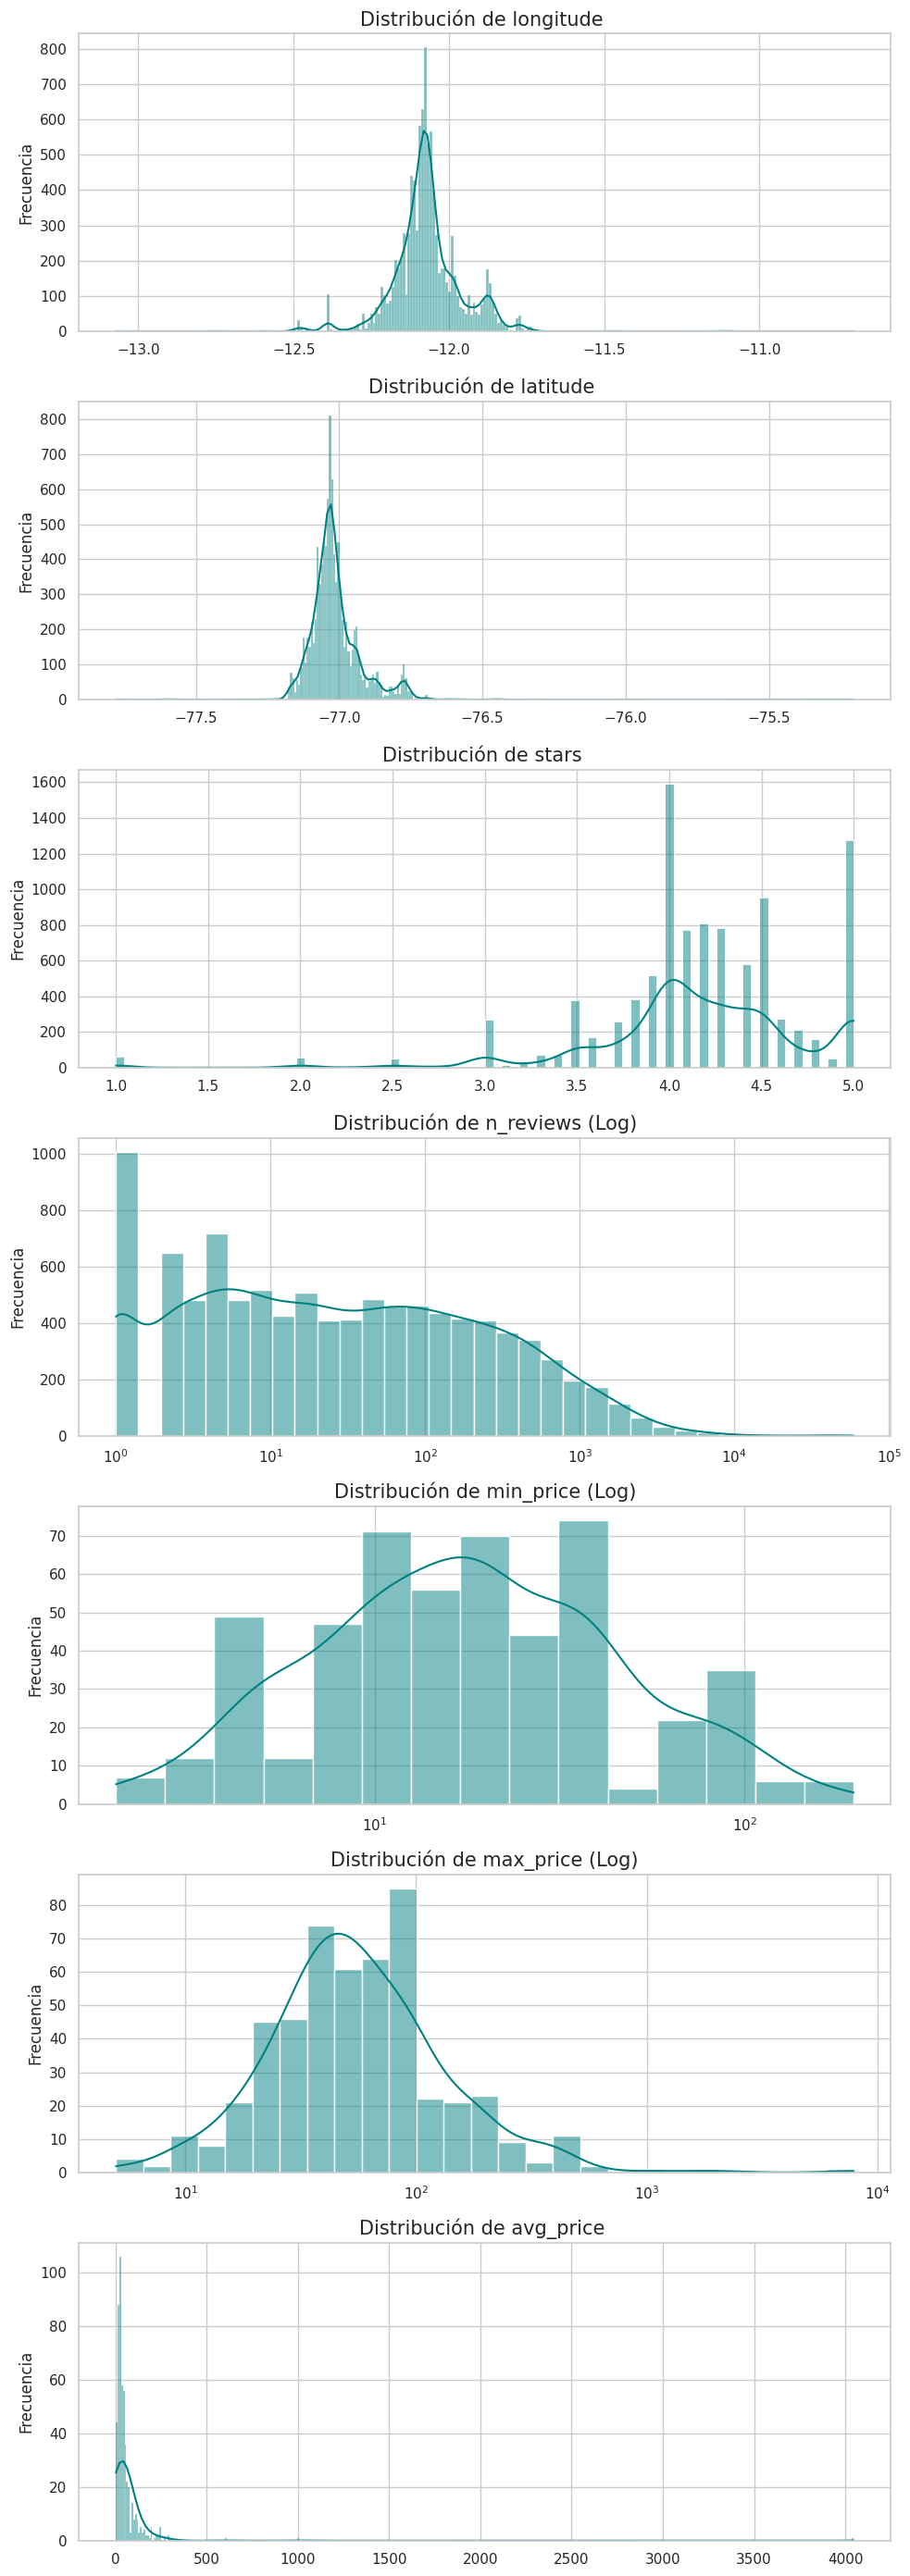

In [172]:
# Filtramos id de las variables numéricas para no graficarlo
num_para_graficar = [col for col in lista_numericas if col != 'id']

# Distribuimos las graficas en 2 filas y 3 columnas para las 6 variables
fig, axes = plt.subplots(len(num_para_graficar), 1, figsize=(10, 4 * len(num_para_graficar)))
axes = axes.flatten()

for i, col in enumerate(num_para_graficar):
    # Aplicar escala logarítmica automáticamente a las variables muy sesgadas (reviews y precios)
    log_scale = True if col in ['n_reviews', 'min_price', 'max_price'] else False

    sns.histplot(data=df_restaurantes, x=col, kde=True, ax=axes[i], log_scale=log_scale, color='teal')
    axes[i].set_title(f'Distribución de {col} {"(Log)" if log_scale else ""}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()



Se puede apreciar que las variables **latitud** y **longitud** están agrupadas alrededor de los valores `-12` y `-77` respectivamente, lo cual coincide con la ubicación geográfica de **Lima, Perú**.

Con respecto a las calificaciones, se observan las siguientes tendencias:
* **Puntuaciones:** Existe una mayor concentración entre las **4 y 5 estrellas**.
* **Reseñas:** La mayoría de los elementos cuentan con **muy pocas reseñas**.


In [173]:
print("=== NULOS EN VARIABLES NUMERICAS ===")
print(df_restaurantes[lista_numericas].isnull().sum())

##Para los valores numericos imputaremos por la mediana
print("===IMPUTACION POR LA MEDIANA===")
df_restaurantes['min_price'] = df_restaurantes['min_price'].fillna(df_restaurantes['min_price'].median())
df_restaurantes['max_price'] = df_restaurantes['max_price'].fillna(df_restaurantes['max_price'].median())

##Revisamos si quedan algunos nulls
print("Nulos restantes en precios:")
print(df_restaurantes[['min_price', 'max_price']].isnull().sum())

=== NULOS EN VARIABLES NUMERICAS ===
id              0
longitude       0
latitude        0
stars           0
n_reviews       0
min_price    9356
max_price    9356
avg_price    9356
dtype: int64
===IMPUTACION POR LA MEDIANA===
Nulos restantes en precios:
min_price    0
max_price    0
dtype: int64


**Analisis de variables categoricas**

In [174]:
##Medidas de variables categoricas
df_restaurantes.describe(exclude=np.number).round(1).T

,count,unique,top,freq
name,9871,8867,Norky's,52
tag,9871,760,Restaurante,5097
district,8789,43,MIRAFLORES,602
IDDIST,9871,44,Out,1082
direction,9798,8942,Ancón 15123,30
platform,9871,2,googleplaces,8155
price_level,515,4,Intermedio,187


**Variable: Name**

In [175]:
##variable name
df_restaurantes.name.value_counts().head(50)

,count
name,
Norky's,52
KFC,50
Pizza Hut,47
Bembos,43
McDonald's,28
Pardos Chicken,27
Roky's,24
Rustica,24
Starbucks,22


**Hace referencia al nombre del restaurante, se determinara posteriormente si se requiere mantenerlo.**

**Variable: tag(Tipo de restuarante)**

In [176]:
##variable tag
df_restaurantes.tag.value_counts().head(50)

,count
tag,
Restaurante,5097
Restaurante peruano,562
Pizzería,258
,251
Restaurante especializado en pollo,237
Restaurante de comida rápida,229
Cafetería,214
Restaurante chino,187
Marisquería,169


Como se puede apreciar, el conjunto de datos cuenta con diversas categorías que presentan anomalías, tales como:
* **Valores vacíos** (nulos).
* **Símbolos extraños** en los nombres.

Por lo tanto, se procederá con la **depuración y agrupación** de los nombres de los tipos de restaurantes para estandarizar la información.


In [177]:
# Eliminar los simbolos ($$, $$$) y los guiones
df_restaurantes['tag'] = df_restaurantes['tag'].str.replace(r'\$[\s\-\$]*', '', regex=True)

# Reemplazar las barras verticales múltiples por una coma o un espacio
df_restaurantes['tag'] = df_restaurantes['tag'].str.replace(r'\|+', ', ', regex=True)

# Limpiar comas que queden sueltas al inicio o al final
df_restaurantes['tag'] = df_restaurantes['tag'].str.strip(', ')

##Quiatamos esapacios en blanco
df_restaurantes['tag'] = df_restaurantes['tag'].str.strip()

##Reemplazamos los vacios por nan
df_restaurantes['tag'] = df_restaurantes['tag'].replace('', np.nan)


In [178]:
#Quedarse solo con la primera etiqueta antes de la coma (limpia combinaciones complejas)
df_restaurantes['tag'] = df_restaurantes['tag'].str.split(',').str[0].str.strip()

#Creamos un diccionario para reemplazar valores
mapeo = {
       # --- Carnes, Parrillas y Pollo ---
    'Restaurante especializado en pollo': 'Pollería',
    'Tienda de aves de corral': 'Pollería',
    'Restaurante de alas de pollo': 'Pollería',
    'Churrasquería': 'Parrilla / Carnes',
    'Parrilla': 'Parrilla / Carnes',
    'Parrillada': 'Parrilla / Carnes',
    'Brasería': 'Parrilla / Carnes',
    'Restaurante especializado en filetes': 'Parrilla / Carnes',
    'Restaurante especializado en chuletas': 'Parrilla / Carnes',
    'Restaurante especializado en barbacoa': 'Parrilla / Carnes',

    # --- Chifa y Asiática ---
    'Restaurante chino': 'Chifa / Comida China',
    'Restaurante de cocina mandarina': 'Chifa / Comida China',
    'Restaurante cantonés': 'Chifa / Comida China',
    'China': 'Chifa / Comida China',
    'Comida china para llevar': 'Chifa / Comida China',
    'Restaurante chino de comida para llevar': 'Chifa / Comida China',
    'Restaurante de cocina shanghainesa': 'Chifa / Comida China',
    'Restaurante de comida rápida al estilo de Hong Kong': 'Chifa / Comida China',
    'Restaurante de sushi': 'Sushi / Japonesa',
    'Restaurante japonés': 'Sushi / Japonesa',
    'Japonesa': 'Sushi / Japonesa',
    'Restaurante asiático': 'Sushi / Japonesa',
    'Asiática': 'Sushi / Japonesa',
    'Sushi': 'Sushi / Japonesa',
    'Restaurante coreano': 'Sushi / Japonesa',
    'Restaurante de hot pot': 'Sushi / Japonesa',
    'Restaurante de comida occidental japonesa': 'Sushi / Japonesa',
    'Restaurante tailandés': 'Sushi / Japonesa',
    'Restaurante especializado en fusión asiática': 'Sushi / Japonesa',
    'Restaurante de marisco donburi': 'Sushi / Japonesa',

    # --- Comida Rápida y derivados ---
    'Restaurante de comida rápida': 'Comida rápida',
    'Hamburguesería': 'Comida rápida',
    'Bocatería': 'Comida rápida',
    'Comida a domicilio': 'Comida rápida',
    'Pizza para llevar': 'Pizzería',
    'Pizzería a domicilio': 'Pizzería',
    'Restaurante de comida para llevar': 'Comida rápida',
    'Restaurante especializado en sándwich submarino': 'Comida rápida',
    'Diner': 'Comida rápida',
    'Tentempiés': 'Comida rápida',
    'Comida de calle': 'Comida rápida',
    'Establecimiento de comida preparada': 'Comida rápida',
    'Snack bar': 'Comida rápida',

    # --- Cafetería, Desayunos y Dulces ---
    'Café': 'Cafetería',
    'Salón de té': 'Cafetería',
    'Restaurante o cafetería': 'Cafetería',
    'Pastelería': 'Panadería / Pastelería',
    'Panadería': 'Panadería / Pastelería',
    'Tostadores de café': 'Cafetería',
    'Restaurante de desayunos': 'Cafetería',
    'Restaurante de brunch': 'Cafetería',
    'Crepería': 'Cafetería',
    'Tienda de zumos': 'Cafetería',
    'Restaurante de pancakes': 'Cafetería',
    'Tienda de donuts': 'Heladería',
    'Restaurante especializado en sundae': 'Heladería',
    'Tienda de postres': 'Heladería',
    'Restaurante de postres': 'Heladería',
    'Postres': 'Heladería',
    'Tienda de refrescos': 'Heladería',

    # --- Bares, Pubs y Entretenimiento ---
    'Bar restaurante': 'Bar / Pub',
    'Pub restaurante': 'Bar / Pub',
    'Bar': 'Bar / Pub',
    'bar cervecero': 'Bar / Pub',
    'Pub': 'Bar / Pub',
    'Cervecería': 'Bar / Pub',
    'Cervecería artesanal': 'Bar / Pub',
    'Karaoke': 'Bar / Pub',
    'Restaurante con sala de baile': 'Bar / Pub',
    'Bar con música en directo': 'Bar / Pub',
    'Bar de vinos': 'Bar / Pub',
    'Coctelería': 'Bar / Pub',
    'Discoteca': 'Bar / Pub',
    'Club': 'Bar / Pub',
    'Taberna': 'Bar / Pub',
    'Bar de tapas': 'Bar / Pub',

    # --- Internacional y Especialidades ---
    'Restaurante italiano': 'Italiana',
    'Restaurante de cocina romana': 'Italiana',
    'Tienda de pasta': 'Italiana',
    'Restaurante mexicano': 'Mexicana',
    'Taquería': 'Mexicana',
    'Restaurante tex-mex': 'Mexicana',
    'Estadounidense': 'Comida Latina / Internacional',
    'Restaurante de comida tradicional americana': 'Comida Latina / Internacional',
    'Restaurante americano': 'Comida Latina / Internacional',
    'Restaurante especializado en cocina americana moderna': 'Comida Latina / Internacional',
    'Restaurante venezolano': 'Comida Latina / Internacional',
    'Sudamericana': 'Comida Latina / Internacional',
    'Restaurante de cocina sudamericana': 'Comida Latina / Internacional',
    'Española': 'Comida Latina / Internacional',
    'Restaurante de cocina española': 'Comida Latina / Internacional',
    'Restaurante vasco': 'Comida Latina / Internacional',
    'Latina': 'Comida Latina / Internacional',
    'Internacional': 'Comida Latina / Internacional',
    'Francesa': 'Comida Latina / Internacional',
    'Restaurante francés': 'Comida Latina / Internacional',
    'Mediterránea': 'Comida Latina / Internacional',
    'Restaurante mediterráneo': 'Comida Latina / Internacional',
    'De la India': 'Comida Latina / Internacional',
    'Restaurante indio': 'Comida Latina / Internacional',
    'Cajún y criolla': 'Comida Latina / Internacional',
    'Restaurante especializado en cocina cajún': 'Comida Latina / Internacional',
    'Restaurante especializado en cocina moderna latinoamericana': 'Comida Latina / Internacional',
    'Caribeña': 'Comida Latina / Internacional',
    'Belga': 'Comida Latina / Internacional',
    'Restaurante belga': 'Comida Latina / Internacional',
    'Brasilera': 'Comida Latina / Internacional',
    'Alemana': 'Comida Latina / Internacional',
    'Argentina': 'Comida Latina / Internacional',
    'Restaurante argentino': 'Comida Latina / Internacional',
    'Restaurante uruguayo': 'Comida Latina / Internacional',
    'Restaurante de cocina de Oriente Medio': 'Comida Latina / Internacional',
    'Suiza': 'Comida Latina / Internacional',
    'Hawaiana': 'Comida Latina / Internacional',
    'Restaurante hawaiano': 'Comida Latina / Internacional',
    'Turca': 'Comida Latina / Internacional',
    'Restaurante turco': 'Comida Latina / Internacional',
    'Restaurante inglés': 'Comida Latina / Internacional',
    'Restaurante neozelandés': 'Comida Latina / Internacional',
    'Árabe': 'Comida Latina / Internacional',
    'Restaurante especializado en soul food': 'Comida Latina / Internacional',
    'Restaurante halal': 'Comida Latina / Internacional',
    'Restaurante de kashmiri': 'Comida Latina / Internacional',
    'Restaurante de sfiha': 'Comida Latina / Internacional',
    'Restaurante de comida continental': 'Comida Latina / Internacional',
    'Restaurante egipcio': 'Comida Latina / Internacional',

    # --- Fusión y Especialidades de platos ---
    'Restaurante de fusión': 'Fusión',
    'contemporánea': 'Fusión',
    'Restaurante especializado en platos pequeños': 'Fusión',
    'Restaurante de alta cocina': 'Fusión',

    # --- Saludable y Vegetariano ---
    'Restaurante vegano': 'Restaurante saludable',
    'Restaurante vegetariano': 'Restaurante saludable',
    'Saludable': 'Restaurante saludable',
    'Apto para vegetarianos': 'Restaurante saludable',
    'Restaurante saludable': 'Restaurante saludable',
    'Restaurante de comida saludable': 'Restaurante saludable',
    'Tienda de ensaladas': 'Restaurante saludable',

    # --- Formatos de Servicio / Familiares ---
    'Restaurante de comida casa': 'Restaurante familiar',
    'Restaurante de comida casera': 'Restaurante familiar',
    'Buffet libre': 'Restaurante familiar',
    'Restaurante de fish & chips': 'Comida rápida',
    'Restaurante de bakso': 'Restaurante familiar',
    'Restaurante de sopas': 'Restaurante familiar',
    'Establecimiento de sopas': 'Restaurante familiar',
    'Delicatessen': 'Restaurante familiar',
    'Tienda de delicatessen': 'Restaurante familiar',
    'Tienda de fiambres': 'Restaurante familiar',
    'Jamonería': 'Restaurante familiar',

    # --- No Gastronómicos o Ubicaciones ---
    'Centro comercial': 'Otros / No Gastronómico',
    'Zona de restauración': 'Otros / No Gastronómico',
    'Hipermercado': 'Otros / No Gastronómico',
    'Hotel': 'Otros / No Gastronómico',
    'Oficinas de empresa': 'Otros / No Gastronómico',
    'Club de campo': 'Otros / No Gastronómico',
    'Supermercado': 'Otros / No Gastronómico',
    'Gasolinera': 'Otros / No Gastronómico',
    'Mercado': 'Otros / No Gastronómico',
    'Atracción turística': 'Otros / No Gastronómico',
    'Tienda de alimentación': 'Otros / No Gastronómico',
    'Recinto para eventos': 'Otros / No Gastronómico',
    'Bodega': 'Otros / No Gastronómico',
    'Parque': 'Otros / No Gastronómico',
    'Club social': 'Otros / No Gastronómico',
    'Complejo hotelero': 'Otros / No Gastronómico',
    'Organizador de eventos': 'Otros / No Gastronómico',
    'Cine': 'Otros / No Gastronómico',
    'Alojamiento': 'Otros / No Gastronómico',
    'Monumento': 'Otros / No Gastronómico',
    'Banco': 'Otros / No Gastronómico',
    'Tienda de ultramarinos': 'Otros / No Gastronómico',
    'Mirador': 'Otros / No Gastronómico',
    'Tienda de vitaminas y suplementos': 'Otros / No Gastronómico',
    'Iglesia católica': 'Otros / No Gastronómico',
    'Empresa de software': 'Otros / No Gastronómico',
    'Promotora inmobiliaria': 'Otros / No Gastronómico',
    'Editor': 'Otros / No Gastronómico',
    'Agencia de viajes': 'Otros / No Gastronómico',
    'Servicio de catering': 'Otros / No Gastronómico',
    'Tienda de señalización': 'Otros / No Gastronómico',
    'Tienda de artículos para barbacoas': 'Otros / No Gastronómico',
    'Lonja de pescado': 'Otros / No Gastronómico',
    'Fortaleza': 'Otros / No Gastronómico',
    'Sala de banquetes': 'Otros / No Gastronómico',
    'Oficina de la Administración': 'Otros / No Gastronómico',
    'Urbanización': 'Otros / No Gastronómico',
    'Tienda general': 'Otros / No Gastronómico',
    'Oficina del Gobierno del Distrito': 'Otros / No Gastronómico',
    'Organizador de bodas': 'Otros / No Gastronómico',
    'Parque de atracciones': 'Otros / No Gastronómico',
    'Camping': 'Otros / No Gastronómico',
    'Casa rural': 'Otros / No Gastronómico',
    'Carnicería': 'Otros / No Gastronómico',
    'Tienda de regalos': 'Otros / No Gastronómico',
    'Ayuntamiento': 'Otros / No Gastronómico',
    'Parque nacional': 'Otros / No Gastronómico',
    'Mercado de productos agrícolas': 'Otros / No Gastronómico',
    'Universidad': 'Otros / No Gastronómico',
    'Facultad de Derecho': 'Otros / No Gastronómico',
    'Tienda de artículos para el hogar': 'Otros / No Gastronómico',
    'Condominio': 'Otros / No Gastronómico',
    'Pabellón para playa': 'Otros / No Gastronómico',
    'Club de vela': 'Otros / No Gastronómico',
    'Turoperador': 'Otros / No Gastronómico',
    'Tienda de ropa para jóvenes': 'Otros / No Gastronómico',
    'Librería': 'Otros / No Gastronómico',
    'Pajarería': 'Otros / No Gastronómico',
    'Copistería': 'Otros / No Gastronómico',
    'Diputación': 'Otros / No Gastronómico',
    'Institución educativa': 'Otros / No Gastronómico',
    'Universidad privada': 'Otros / No Gastronómico',
    'Lavandería': 'Otros / No Gastronómico',
    'Parque ecológico': 'Otros / No Gastronómico',
    'Ferretería': 'Otros / No Gastronómico',
    'Granja escuela': 'Otros / No Gastronómico',
    'Instalación de almacenamiento de embarcaciones': 'Otros / No Gastronómico',
    'Balneario público': 'Otros / No Gastronómico',
    'Puente': 'Otros / No Gastronómico',
    'Alojamiento con servicio': 'Otros / No Gastronómico',
    'Tienda de vinos': 'Otros / No Gastronómico',
    'Polideportivo': 'Otros / No Gastronómico',
    'Escuela': 'Otros / No Gastronómico'
}

# Aplicar los reemplazos al dataframe
df_restaurantes['tag'] = df_restaurantes['tag'].replace(mapeo)

In [179]:
##Revisamos nuevamente la distribucion
df_restaurantes.tag.value_counts()

,count
tag,
Restaurante,5097
Peruana,815
Restaurante peruano,562
Comida rápida,397
Cafetería,323
Pollería,312
Pizzería,296
Chifa / Comida China,287
Sushi / Japonesa,185


Se observa que varios establecimientos tienen asignado el tipo genérico **"restaurante"**. Para mejorar la precisión de los datos, se implementará la siguiente lógica de limpieza:

* **Clasificación por nombre:** Se asignará un tipo específico en función de las palabras clave identificadas en el nombre del restaurante.
* **Categoría por defecto:** En caso de no poder precisar la especialidad, el registro se agrupará bajo la categoría **"Restaurante (No especificado)"**.


In [180]:
df_restaurantes[df_restaurantes['tag'] == 'Restaurante'].head(10)

,id,name,tag,longitude,latitude,district,IDDIST,direction,stars,n_reviews,min_price,max_price,platform,avg_price,price_level
1716,206521,Eco Resto Park,Restaurante,-12.216637,-76.863226,PACHACAMAC,150123,Calle 5 urbanización Casa Blanca 154A MzE Pach...,4.4,611,18.0,50.0,googleplaces,NaN,NaN
1717,205348,Zaber H&M,Restaurante,-11.998069,-77.107877,NaN,Out,Av.pacasmayo Mz 0 lt 04 Urb.Las Gardenias S.M....,5.0,9,18.0,50.0,googleplaces,NaN,NaN
1718,90439,Deli Bakery,Restaurante,-11.773459,-77.187363,ANCON,150102,"Malecon Pardo, Ancón 15123",4.2,464,18.0,50.0,googleplaces,NaN,NaN
1719,186376,Restaurant Las Terrazas de Ancón,Restaurante,-11.773694,-77.175646,ANCON,150102,"a, de, 2 de Mayo 396, Ancón",3.8,76,18.0,50.0,googleplaces,NaN,NaN
1720,125333,Bahia De Ancon,Restaurante,-11.774798,-77.177360,ANCON,150102,"Malecon Ferreyros 316, Ancón 15123",4.1,44,18.0,50.0,googleplaces,NaN,NaN
1722,242030,La Quinta 615,Restaurante,-11.773508,-77.173720,ANCON,150102,"Loreto 615, Ancón 15123",4.2,265,18.0,50.0,googleplaces,NaN,NaN
1723,243206,Pilon Antojos,Restaurante,-11.781484,-77.159592,ANCON,150102,"urb. san jose mz. B lt.10, Ancón",5.0,21,18.0,50.0,googleplaces,NaN,NaN
1725,76135,El Carbon Rojo - Restaurant - De Villas De Ancon,Restaurante,-11.737164,-77.139023,ANCON,150102,Ancón 15123,4.1,52,18.0,50.0,googleplaces,NaN,NaN
1726,293621,Restaurante Cevichería Pepe Cangrejo,Restaurante,-11.772695,-77.174910,ANCON,150102,"2 de Mayo 601, Ancón 15123",4.1,261,18.0,50.0,googleplaces,NaN,NaN
1727,19540,"Restaurant ""El Fogón""",Restaurante,-11.776715,-77.164930,ANCON,150102,"Pacto Andino 49A, Ancón 15123",4.2,301,18.0,50.0,googleplaces,NaN,NaN


In [181]:
# Crear una máscara para modificar unicamente las filas genericas
es_restaurante = df_restaurantes['tag'] == 'Restaurante'

# Mapeo basado en palabras clave dentro de la columna 'name'
df_restaurantes.loc[es_restaurante & df_restaurantes['name'].str.contains('ceviche|cebiche|marisco|cangrejo|pesca|puerto|mar|pez', case=False, na=False), 'tag'] = 'Marisquería'
df_restaurantes.loc[es_restaurante & df_restaurantes['name'].str.contains('carbon|carbón|fogon|fogón|parrilla|leña|brasa|anticucho|corte|churrasco', case=False, na=False), 'tag'] = 'Parrilla / Carnes'
df_restaurantes.loc[es_restaurante & df_restaurantes['name'].str.contains('bakery|pasteleria|pastelería|panaderia|panadería|deli|tortas', case=False, na=False), 'tag'] = 'Panadería / Pastelería'
df_restaurantes.loc[es_restaurante & df_restaurantes['name'].str.contains('pizza|pizzer', case=False, na=False), 'tag'] = 'Pizzería'
df_restaurantes.loc[es_restaurante & df_restaurantes['name'].str.contains('chifa|china|wong|canton|oriental', case=False, na=False), 'tag'] = 'Chifa / Comida China'
df_restaurantes.loc[es_restaurante & df_restaurantes['name'].str.contains('pollo|poller|norky|rocky|pardo', case=False, na=False), 'tag'] = 'Pollería'
df_restaurantes.loc[es_restaurante & df_restaurantes['name'].str.contains('burger|hamburgue|bembos|mcdonald|king|snack', case=False, na=False), 'tag'] = 'Comida rápida'
df_restaurantes.loc[es_restaurante & df_restaurantes['name'].str.contains('cafe|café|coffee|starbucks|tienda de zumos', case=False, na=False), 'tag'] = 'Cafetería'
df_restaurantes.loc[es_restaurante & df_restaurantes['name'].str.contains('sushi|maki|japon|nikkei', case=False, na=False), 'tag'] = 'Sushi / Japonesa'
df_restaurantes.loc[es_restaurante & df_restaurantes['name'].str.contains('pasta|italia', case=False, na=False), 'tag'] = 'Italiana'
df_restaurantes.loc[es_restaurante & df_restaurantes['name'].str.contains('criollo|criolla|tradicion|antojo', case=False, na=False), 'tag'] = 'Peruana'

# Renombrar los que queden sin clasificar
df_restaurantes['tag'] = df_restaurantes['tag'].replace({'Restaurante': 'Restaurante (No especificado)'})


In [182]:
##Revisamos nuevamente la distribucion
df_restaurantes.tag.value_counts()

,count
tag,
Restaurante (No especificado),3273
Marisquería,890
Peruana,880
Pollería,701
Restaurante peruano,562
Chifa / Comida China,498
Comida rápida,492
Pizzería,385
Cafetería,370


**Variable: platform**

In [183]:
##variable platform
df_restaurantes.platform.value_counts().head()

,count
platform,
googleplaces,8155
tripadvisor,1716


Las variables `district`, `IDDIST` (identificador del distrito) y `direction` hacen referencia a la ubicación física del restaurante.

Se procederá a realizar un análisis adicional para evaluar el nivel de redundancia y determinar cuál de estas variables conservar, con el objetivo de **evitar problemas de multicolinealidad** en los modelos posteriores.


/tmp/ipykernel_2754/3755469210.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_2754/3755469210.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_2754/3755469210.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_2754/3755469210.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_2754/3755469210.py:16: FutureWarn

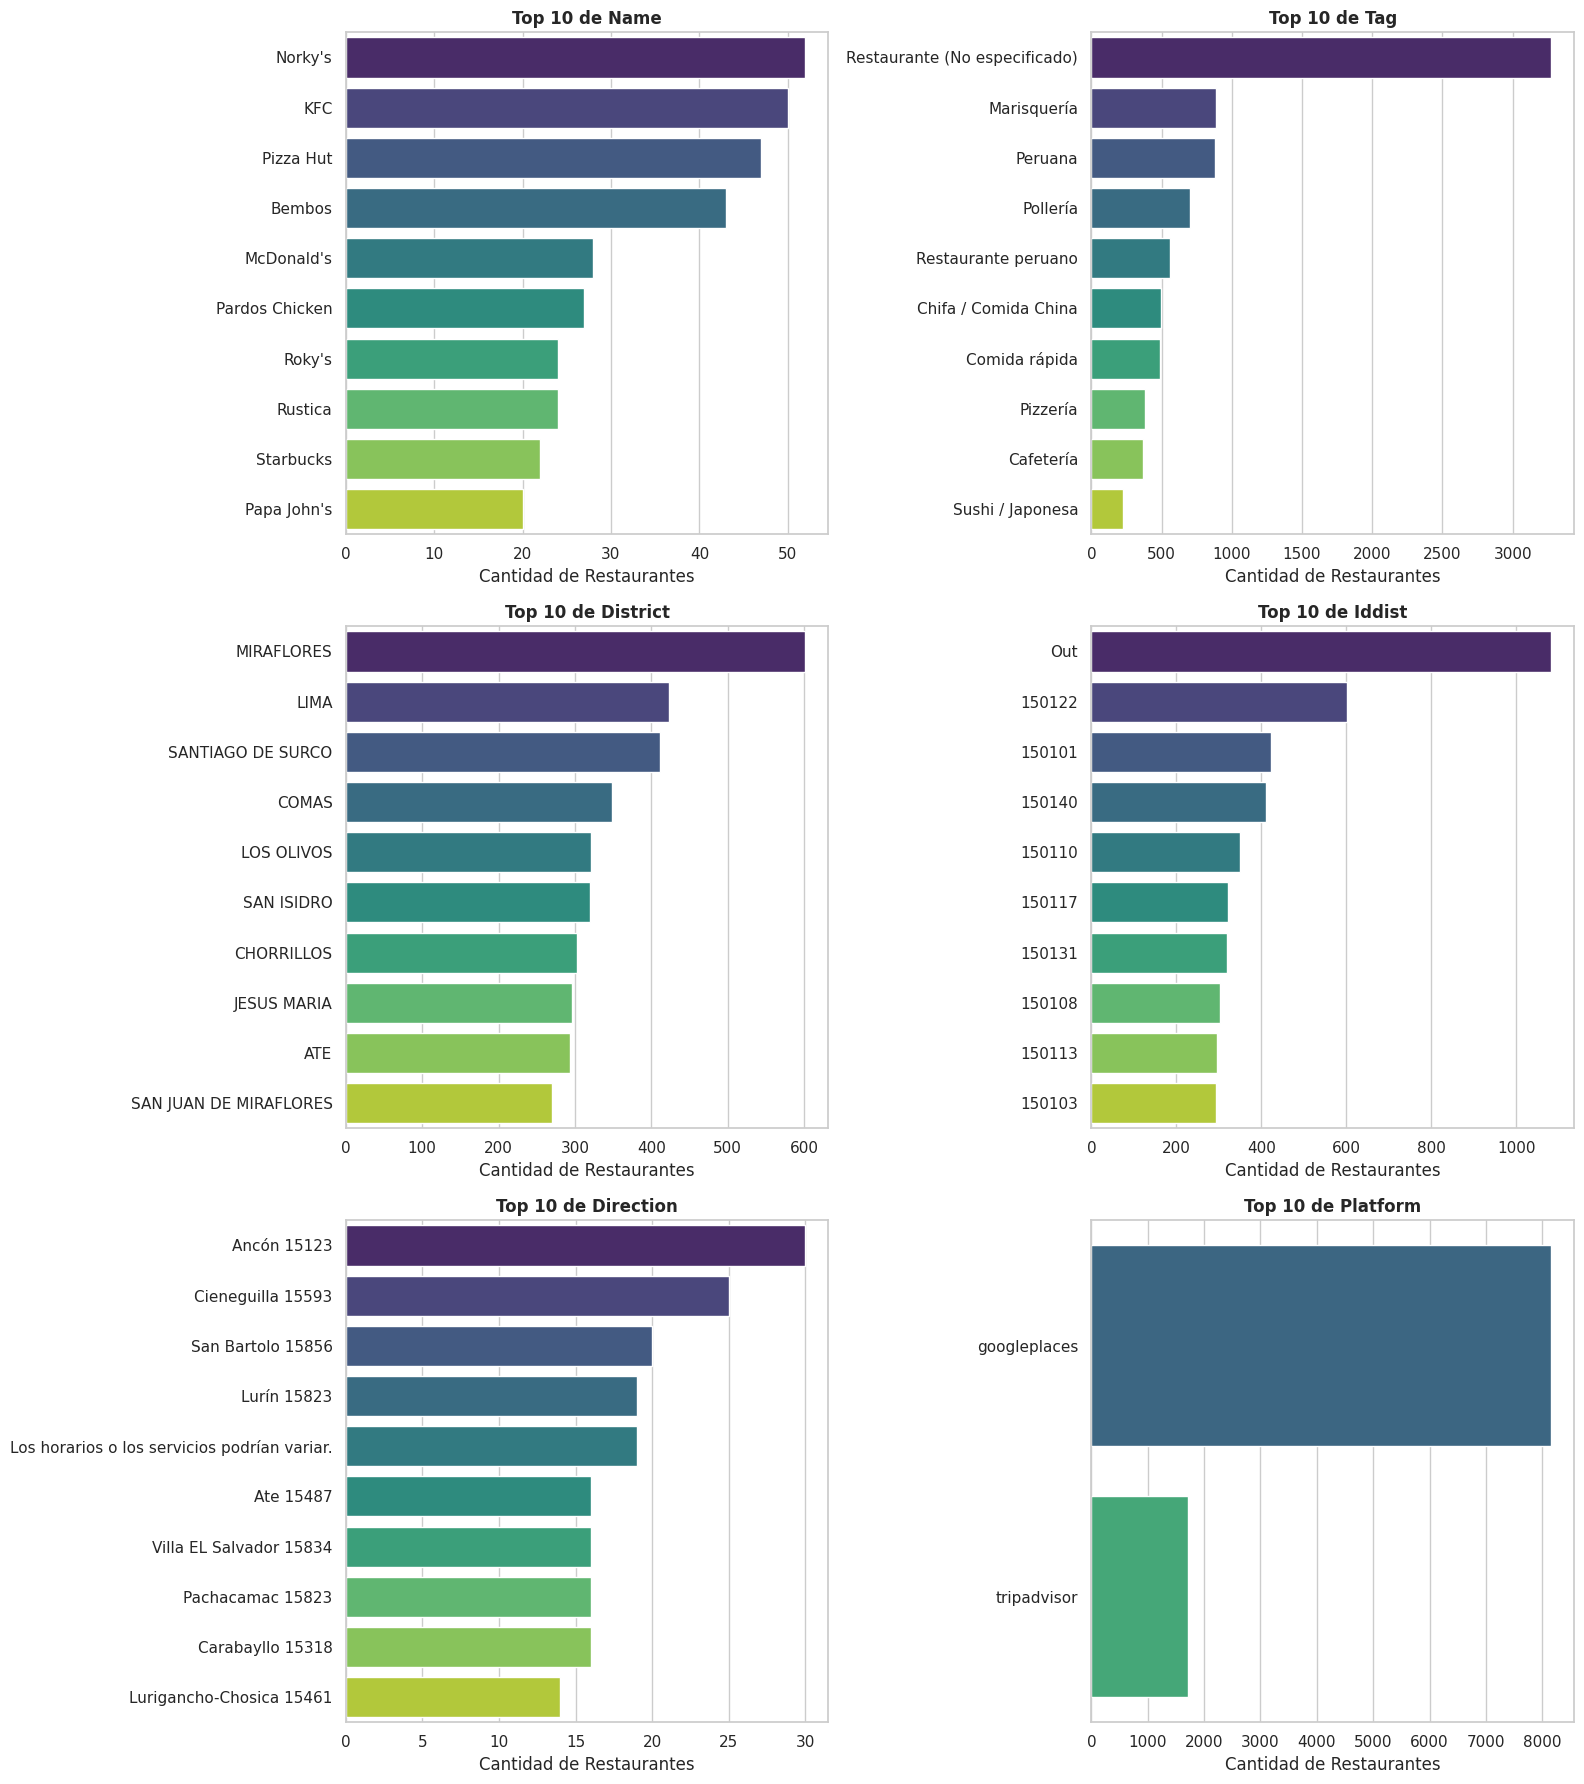

In [184]:
#Definimos la lista de variables categoricas
variables_categoricas = ['name', 'tag', 'district', 'IDDIST', 'direction', 'platform']

# Configurar la cuadrícula (3 filas y 2 columnas para las 6 variables)
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(16, 18))
axes = axes.flatten()

for i, col in enumerate(variables_categoricas):
    # Obtener el Top 10 de categorias más frecuentes para no saturar el grafico
    top_categorias = df_restaurantes[col].value_counts().head(10).index

    # Filtrar el DataFrame solo con el top 10 de esa columna
    df_filtrado = df_restaurantes[df_restaurantes[col].isin(top_categorias)]

    # Graficar de forma horizontal (y=col) para que los nombres se lean perfectamente
    sns.countplot(
        data=df_filtrado,
        y=col,
        ax=axes[i],
        order=top_categorias,
        palette='viridis'
    )

    # Añadir títulos y etiquetas limpias
    axes[i].set_title(f'Top 10 de {col.capitalize()}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Cantidad de Restaurantes')
    axes[i].set_ylabel('')

# Ajustar el diseño para que no se superpongan las etiquetas
plt.tight_layout()
plt.show()

In [185]:
##Distribucion de nulls
print("=== NULOS EN VARIABLES CATEGORICAS ===")
print(df_restaurantes[variables_categoricas].isnull().sum())

=== NULOS EN VARIABLES CATEGORICAS ===
name            0
tag           323
district     1082
IDDIST          0
direction      73
platform        0
dtype: int64


Se puede apreciar que los valores nulos  en la variable `district` coinciden exactamente con los de la variable `IDDIST`. Según el gráfico estadístico superior, esta pérdida de datos afecta visualmente a **más de 1000 registros**.

Para evitar la pérdida de información que implicaría eliminar estas filas o columnas, se procederá a realizar una **imputación utilizando la moda** (el valor más frecuente) de las variables categóricas.


In [186]:
# Imputar district usando la moda general
moda_distrito = df_restaurantes['district'].mode()[0]
df_restaurantes['district'] = df_restaurantes['district'].fillna(moda_distrito)

# Sincronizar IDDIST con la moda correspondiente
df_restaurantes['IDDIST'] = df_restaurantes['IDDIST'].replace('Out', df_restaurantes['IDDIST'].mode()[0])

# Imputar direction con la moda
df_restaurantes['direction'] = df_restaurantes['direction'].fillna(df_restaurantes['direction'].mode()[0])

#Imputar tag con la moda
df_restaurantes['tag'] = df_restaurantes['tag'].fillna(df_restaurantes['tag'].mode()[0])

In [187]:
##Revisamos nuevamente la distribucion de nulls
print("=== NULOS EN VARIABLES CATEGORICAS ===")
print(df_restaurantes[variables_categoricas].isnull().sum())

=== NULOS EN VARIABLES CATEGORICAS ===
name         0
tag          0
district     0
IDDIST       0
direction    0
platform     0
dtype: int64


In [188]:
##Revisamos las medidas de variables categoricas nuevamente
df_restaurantes.describe(exclude=np.number).round(1).T

,count,unique,top,freq
name,9871,8867,Norky's,52
tag,9871,23,Restaurante (No especificado),3596
district,9871,43,MIRAFLORES,1684
IDDIST,9871,44,Out,1082
direction,9871,8942,Ancón 15123,103
platform,9871,2,googleplaces,8155
price_level,515,4,Intermedio,187


Tras analizar las variables numéricas y categóricas, se observa la presencia de **valores extremos (outliers)**.

Asimismo, se ha detectado que las variables categóricas `district`, `IDDIST` y `direction` hacen referencia a la descripción de la ubicación física del restaurante. Conservar todas ellas podría generar **redundancia de información** (multicolinealidad si se codifican numéricamente), por lo que este problema se abordará de manera prioritaria antes de proceder con la gestión y tratamiento de los outliers.


**Analisis de coloinealidad y correlacion**


In [189]:
from scipy import stats as ss
# Función para calcular la V de Cramer
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = ss.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

In [190]:
##Variables: district y IDDIST
var1 = df_restaurantes['district']
var2 = df_restaurantes['IDDIST']

# Cálculos
cv = cramers_v(var1, var2)

print(f"V de Cramer: {cv:.4f}")

V de Cramer: 0.9999


In [191]:
##Variables: district y direction
var1 = df_restaurantes['district']
var2 = df_restaurantes['direction']

# Cálculos
cv = cramers_v(var1, var2)

print(f"V de Cramer: {cv:.4f}")

V de Cramer: 0.2692


In [192]:
##Variables: district y stars
var1 = df_restaurantes['district']
var2 = df_restaurantes['stars']

# Cálculos
cv = cramers_v(var1, var2)

print(f"V de Cramer: {cv:.4f}")

V de Cramer: 0.0433


In [193]:
##Variables: IDDIST y stars
var1 = df_restaurantes['IDDIST']
var2 = df_restaurantes['stars']

# Cálculos
cv = cramers_v(var1, var2)

print(f"V de Cramer: {cv:.4f}")

V de Cramer: 0.0532


In [194]:
##Variables: direction y stars
var1 = df_restaurantes['direction']
var2 = df_restaurantes['stars']

# Cálculos
cv = cramers_v(var1, var2)

print(f"V de Cramer: {cv:.4f}")

V de Cramer: 0.0000


Debido a que las variables categóricas `district`, `IDDIST` y `direction` describen la ubicación física del restaurante, generan un problema de colinealidad.

Tras evaluar su fuerza de asociación mediante el coeficiente **V de Cramér**, se obtuvieron las siguientes conclusiones:
* **`district` vs. `IDDIST`:** Presentan una asociación de **0.99**, lo que confirma una correlación casi perfecta (redundancia extrema).
* **`direction` vs. `district`:** Presentan una asociación muy baja (**0.2692**), lo que aporta poco valor predictivo estructurado.
* **Relación con la variable objetivo (`stars`):** El coeficiente de todas estas variables frente a `stars` es **menor al 1%**, demostrando una ausencia de relación lineal directa.

**Decisión metodológica:** Con el objetivo de simplificar el modelo, reducir la dimensionalidad y evitar la colinealidad, se conservará únicamente la variable `district`.


In [195]:
columnas_a_eliminar = ['IDDIST', 'direction']
df_restaurantes=df_restaurantes.drop(columns=columnas_a_eliminar)

In [196]:
##Revisamos las medidas de variables categoricas nuevamente
df_restaurantes.describe(exclude=np.number).round(1).T

,count,unique,top,freq
name,9871,8867,Norky's,52
tag,9871,23,Restaurante (No especificado),3596
district,9871,43,MIRAFLORES,1684
platform,9871,2,googleplaces,8155
price_level,515,4,Intermedio,187


In [197]:
##Revisamos las medidas de variables categoricas nuevamente
df_restaurantes.describe(exclude=np.number).round(1).T

,count,unique,top,freq
name,9871,8867,Norky's,52
tag,9871,23,Restaurante (No especificado),3596
district,9871,43,MIRAFLORES,1684
platform,9871,2,googleplaces,8155
price_level,515,4,Intermedio,187


In [198]:
##Actualizamos las listas de variables
lista_numericas=df_restaurantes.select_dtypes(include=['float64','int32','int64']).columns
lista_categoricas=df_restaurantes.select_dtypes(include=['category','object']).columns

##Seleccionamos como variables categoricas binarias aquellas variables que solo tienen 2 valores
lista_categoricas_binarias=[col for col in lista_categoricas if df_restaurantes[col].nunique()==2]

##Retiramos la variables categoricas binarias de la lista de variables categoricas
lista_categoricas=[col for col in lista_categoricas if col not in lista_categoricas_binarias]

print(f'Las variables numericas son: {lista_numericas}')
print(f'Las variables categoricas son: {lista_categoricas}')
print(f'Las variables categoricas binarias son: {lista_categoricas_binarias}')

Las variables numericas son: Index(['id', 'longitude', 'latitude', 'stars', 'n_reviews', 'min_price',
       'max_price', 'avg_price'],
      dtype='object')
Las variables categoricas son: ['name', 'tag', 'district', 'price_level']
Las variables categoricas binarias son: ['platform']


**Tratamiento de outliers**

**Graficamos los outliers**

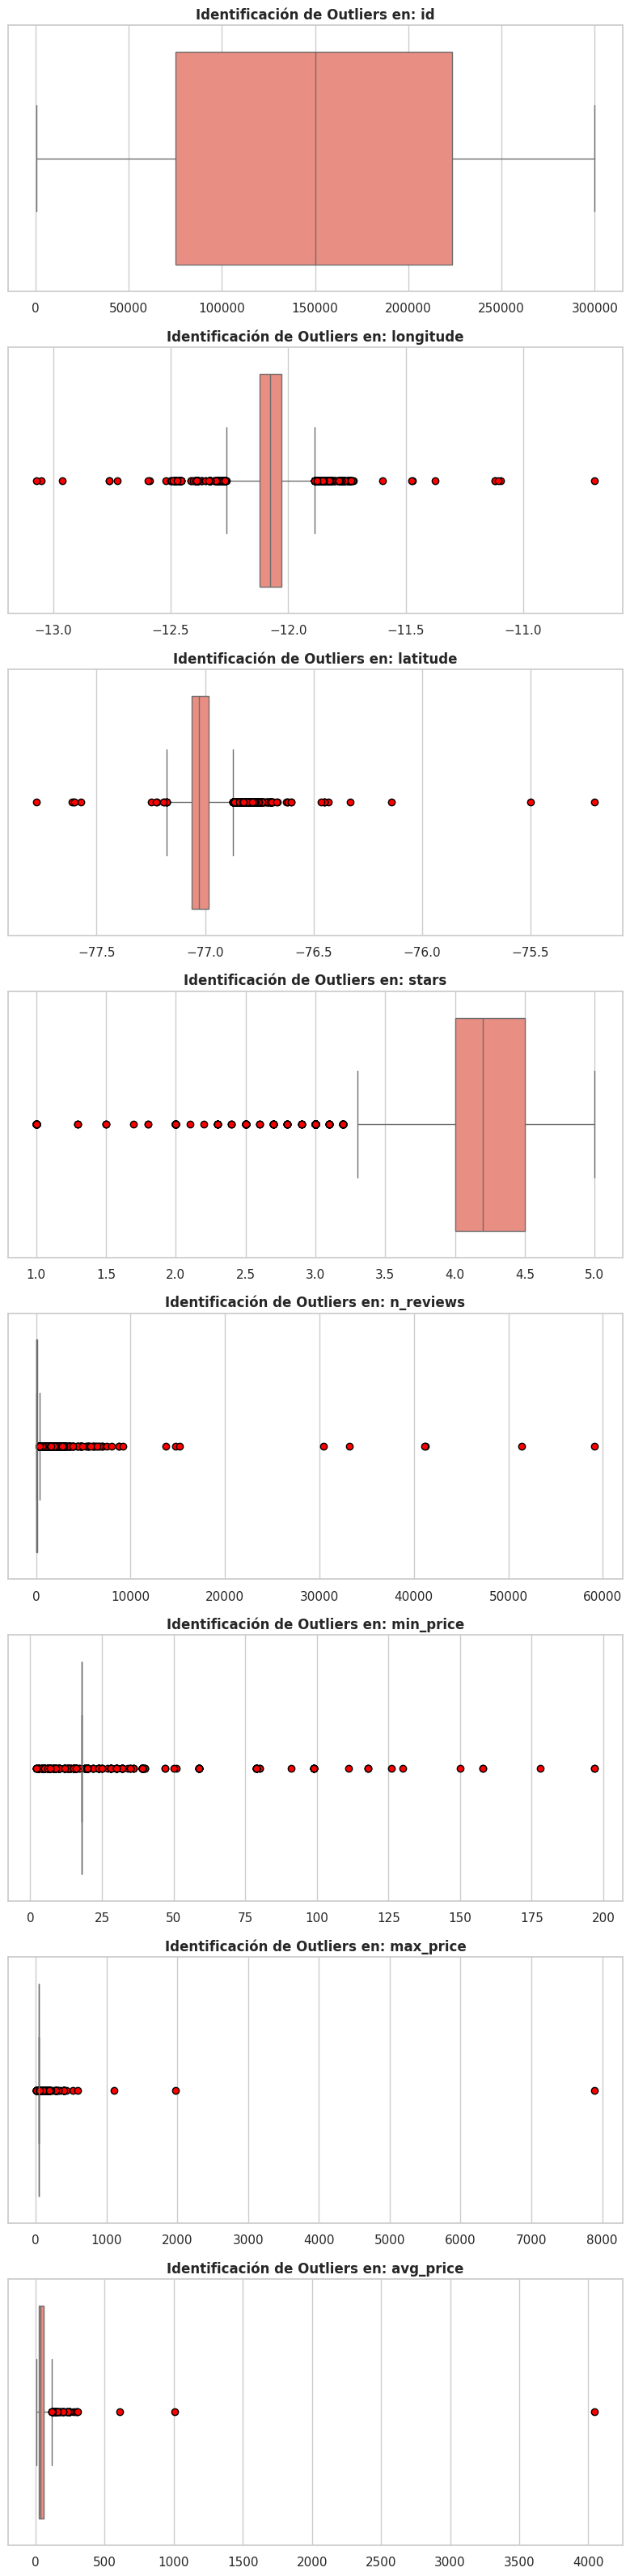

In [199]:
##Graficamos las variables de df_restaurantes
# 1. Identificar columnas numéricas (los outliers solo aplican a datos numéricos)
num_cols = df_restaurantes.select_dtypes(include=[np.number]).columns

# 2. Configurar el lienzo (subplots) solo para variables numéricas
total_vars = len(num_cols)

if total_vars == 0:
    print("No hay variables numéricas para analizar outliers.")
else:
    fig, axes = plt.subplots(nrows=total_vars, ncols=1, figsize=(8, 4 * total_vars))

    # Asegurarse de que axes sea una lista indexable
    if total_vars == 1:
        axes = [axes]

    # 3. Graficar Boxplots para identificar outliers
    for i, col in enumerate(num_cols):
        # flierprops configura el diseño visual de los puntos atípicos
        sns.boxplot(
            x=df_restaurantes[col],
            ax=axes[i],
            color='salmon',
            flierprops={'marker': 'o', 'markerfacecolor': 'red', 'markersize': 6, 'markeredgecolor': 'black'}
        )
        axes[i].set_title(f'Identificación de Outliers en: {col}', fontsize=12, fontweight='bold')
        axes[i].set_xlabel('')

    plt.tight_layout()
    plt.show()


**Variables geograficas: Longitud y latitud**

Como hacen referencia a la ubicacion geografica, no podemos modificar ni eliminar estas variables utilizando metodos estadisticos. Debido a ello no podemos aplicar ni rango intercuartilico ni winzorizacion, a raiz de esta aclaracion podemos identificar las coordenadas sospechosas y reemplazarlas por la mediana de la latitud y longitud de su propio distrito ya que con esto se corrige el error y se coloca el restaurante en el centro de la zona de su distrito correspondiente.

In [200]:
# Calculamos la coordenada central (mediana) para cada distrito de manera independiente
medianas_geo = df_restaurantes.groupby('district')[['latitude', 'longitude']].transform('median')

# Definimos el umbral de tolerancia en grados (0.2 grados equivale a aprox. 22 km)
# Cualquier restaurante más lejano que esto respecto a su distrito será corregido
tolerancia = 0.2
outliers_lat = abs(df_restaurantes['latitude'] - medianas_geo['latitude']) > tolerancia
outliers_lon = abs(df_restaurantes['longitude'] - medianas_geo['longitude']) > tolerancia

# Reemplazamos los valores atípicos con la mediana de su respectivo distrito
df_restaurantes.loc[outliers_lat, 'latitude'] = medianas_geo.loc[outliers_lat, 'latitude']
df_restaurantes.loc[outliers_lon, 'longitude'] = medianas_geo.loc[outliers_lon, 'longitude']

**Variables de precios: min_price, max_price**

Aplicaremos para los precios el metodo de winzorizacion ya que necesitamos conservar los valores en lugar de borrarlos,reducir el error humano al digitar los precios y con ello mantener la estabilidad del modelo evitando que los valores gigantescos distorsionen el modelo.

In [201]:
# Limitamos los valores extremos del precio al percentil 1 y 99 para no perder filas
from scipy.stats import mstats
cols_precios = ['min_price', 'max_price']
for col in cols_precios:
    if col in df_restaurantes.columns:
        df_restaurantes[col] = mstats.winsorize(df_restaurantes[col], limits=[0.01, 0.01])

**Variable n_reviews**

Como logramos apreciar en los apartados superiores la variable asociada al numero de reviews posee mayor concentracion en la de menor valor, aquellos restaurantes con 1 solo review, para evitar perdidas de informacion vamos a tratar la variable mediante la transformacion logaritmica.

In [202]:
# Usamos log1p (logaritmo de x + 1) para estabilizar el sesgo extremo de las reseñas
if 'n_reviews' in df_restaurantes.columns:
    df_restaurantes['log_n_reviews'] = np.log1p(df_restaurantes['n_reviews'])

# Eliminamos la variable original para proteger el modelo
df_restaurantes = df_restaurantes.drop(columns=['n_reviews'])

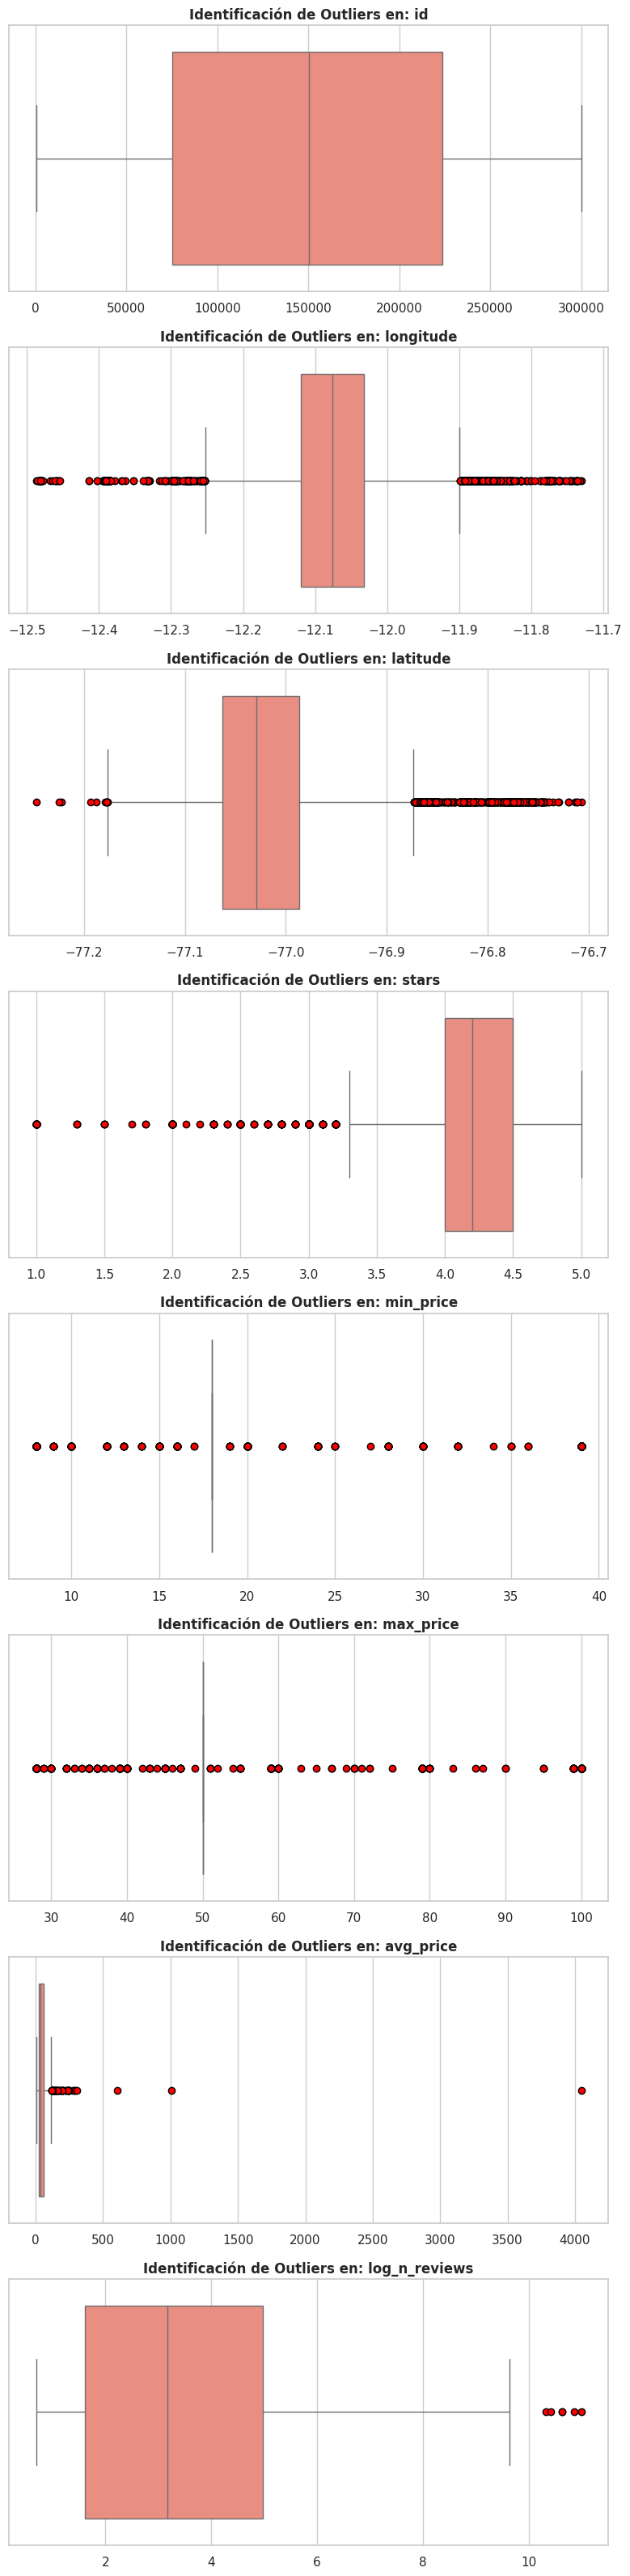

In [203]:
##Graficamos las variables de df_restaurantes
# 1. Identificar columnas numéricas (los outliers solo aplican a datos numéricos)
num_cols = df_restaurantes.select_dtypes(include=[np.number]).columns

# 2. Configurar el lienzo (subplots) solo para variables numéricas
total_vars = len(num_cols)

if total_vars == 0:
    print("No hay variables numéricas para analizar outliers.")
else:
    fig, axes = plt.subplots(nrows=total_vars, ncols=1, figsize=(8, 4 * total_vars))

    # Asegurarse de que axes sea una lista indexable
    if total_vars == 1:
        axes = [axes]

    # 3. Graficar Boxplots para identificar outliers
    for i, col in enumerate(num_cols):
        # flierprops configura el diseño visual de los puntos atípicos
        sns.boxplot(
            x=df_restaurantes[col],
            ax=axes[i],
            color='salmon',
            flierprops={'marker': 'o', 'markerfacecolor': 'red', 'markersize': 6, 'markeredgecolor': 'black'}
        )
        axes[i].set_title(f'Identificación de Outliers en: {col}', fontsize=12, fontweight='bold')
        axes[i].set_xlabel('')

    plt.tight_layout()
    plt.show()

In [204]:
df_restaurantes.head(3)

,id,name,tag,longitude,latitude,district,stars,min_price,max_price,platform,avg_price,price_level,log_n_reviews
0,71036,Restaurante Statera,Peruana,-12.115658,-77.043440,MIRAFLORES,5.0,39.0,100.0,tripadvisor,180.0,Lujo,4.875197
1,72471,Maras Restaurante,Peruana,-12.092106,-77.024660,SAN ISIDRO,4.5,39.0,100.0,tripadvisor,197.5,Lujo,6.516193
2,29667,Ventarrón Restaurante Chiclayano & Barra,Peruana,-12.149373,-77.020706,BARRANCO,4.5,12.0,72.0,tripadvisor,42.0,Intermedio,5.720312


In [205]:
# VALIDACIÓN FINAL - df_restaurantes
print("=" * 60)
print("VALIDACIÓN FINAL DF_RESTAURANTES")
print("=" * 60)

print("\nDimensiones:")
print(df_restaurantes.shape)

print("\nTipos de datos:")
print(df_restaurantes.dtypes)

print("\nValores nulos:")
print(df_restaurantes.isnull().sum())

print("\nFilas duplicadas:")
print(df_restaurantes.duplicated().sum())

print("\nIDs duplicados:")
print(df_restaurantes["id"].duplicated().sum())

print("\nRango de stars:")
print(df_restaurantes["stars"].min(),
      "-",
      df_restaurantes["stars"].max())

print("\nRango de precios:")
print("min_price:",
      df_restaurantes["min_price"].min(),
      "-",
      df_restaurantes["min_price"].max())

print("max_price:",
      df_restaurantes["max_price"].min(),
      "-",
      df_restaurantes["max_price"].max())

print("\nNiveles de precio:")
print(df_restaurantes["price_level"].value_counts(dropna=False))

print("\nPlataformas:")
print(df_restaurantes["platform"].value_counts(dropna=False))

print("\nDistritos:")
print(df_restaurantes["district"].value_counts(dropna=False))

VALIDACIÓN FINAL DF_RESTAURANTES

Dimensiones:
(9871, 13)

Tipos de datos:
id                  int64
name               object
tag                object
longitude         float64
latitude          float64
district           object
stars             float64
min_price         float64
max_price         float64
platform           object
avg_price         float64
price_level      category
log_n_reviews     float64
dtype: object

Valores nulos:
id                  0
name                0
tag                 0
longitude           0
latitude            0
district            0
stars               0
min_price           0
max_price           0
platform            0
avg_price        9356
price_level      9356
log_n_reviews       0
dtype: int64

Filas duplicadas:
0

IDs duplicados:
0

Rango de stars:
1.0 - 5.0

Rango de precios:
min_price: 8.0 - 39.0
max_price: 28.0 - 100.0

Niveles de precio:
price_level
NaN           9356
Intermedio     187
Económico      165
Premium        103
Lujo            60

**Diagnostico Variables de precios**

In [206]:
# DIAGNÓSTICO DE VARIABLES DE PRECIO
print("Total restaurantes:", len(df_restaurantes))
print("\nNulos:")
print(df_restaurantes[["min_price", "max_price", "avg_price", "price_level"]].isnull().sum())

print("\nPrimeras 20 combinaciones:")
display(df_restaurantes[["platform", "min_price", "max_price","avg_price", "price_level"]].head(20))

print("\nPrecios según plataforma:")
print(df_restaurantes.groupby("platform")[["min_price", "max_price", "avg_price"]].count())

print("\nFilas con avg_price nulo:")
display(df_restaurantes.loc[df_restaurantes["avg_price"].isna(),["platform", "min_price", "max_price","avg_price", "price_level"]].head(20))

Total restaurantes: 9871

Nulos:
min_price         0
max_price         0
avg_price      9356
price_level    9356
dtype: int64

Primeras 20 combinaciones:


,platform,min_price,max_price,avg_price,price_level
0,tripadvisor,39.0,100.0,180.0,Lujo
1,tripadvisor,39.0,100.0,197.5,Lujo
2,tripadvisor,12.0,72.0,42.0,Intermedio
3,tripadvisor,20.0,83.0,51.5,Premium
4,tripadvisor,39.0,99.0,89.0,Premium
5,tripadvisor,18.0,50.0,NaN,NaN
6,tripadvisor,18.0,50.0,NaN,NaN
7,tripadvisor,39.0,100.0,128.5,Lujo
8,tripadvisor,39.0,100.0,124.5,Lujo
9,tripadvisor,39.0,100.0,276.5,Lujo



Precios según plataforma:
              min_price  max_price  avg_price
platform                                     
googleplaces       8155       8155          0
tripadvisor        1716       1716        515

Filas con avg_price nulo:


,platform,min_price,max_price,avg_price,price_level
5,tripadvisor,18.0,50.0,NaN,NaN
6,tripadvisor,18.0,50.0,NaN,NaN
15,tripadvisor,18.0,50.0,NaN,NaN
18,tripadvisor,18.0,50.0,NaN,NaN
19,tripadvisor,18.0,50.0,NaN,NaN
22,tripadvisor,18.0,50.0,NaN,NaN
23,tripadvisor,18.0,50.0,NaN,NaN
24,tripadvisor,18.0,50.0,NaN,NaN
27,tripadvisor,18.0,50.0,NaN,NaN
28,tripadvisor,18.0,50.0,NaN,NaN


In [207]:
# revision final de min_price y max_price
print("Combinaciones de precios más frecuentes:")
print(df_restaurantes.groupby(["min_price", "max_price"]).size().sort_values(ascending=False).head(15))
print("\nPor plataforma:")
print(df_restaurantes.groupby(["platform", "min_price", "max_price"]).size().sort_values(ascending=False).head(20))

Combinaciones de precios más frecuentes:
min_price  max_price
18.0       50.0         9356
39.0       100.0          75
8.0        28.0           68
39.0       99.0           20
           79.0           19
8.0        30.0           12
10.0       28.0           11
39.0       59.0           11
20.0       39.0           11
           100.0          10
           59.0           10
10.0       30.0            7
           50.0            7
8.0        45.0            6
12.0       59.0            6
dtype: int64

Por plataforma:
platform      min_price  max_price
googleplaces  18.0       50.0         8155
tripadvisor   18.0       50.0         1201
              39.0       100.0          75
              8.0        28.0           68
              39.0       99.0           20
                         79.0           19
              8.0        30.0           12
              10.0       28.0           11
              39.0       59.0           11
              20.0       39.0           11
        

In [208]:
# Creamos una marca para precio disponible
df_restaurantes["price_available"] = (df_restaurantes["avg_price"].notna().astype(int))
print(df_restaurantes["price_available"].value_counts())
print("\nPorcentaje:",(df_restaurantes["price_available"].value_counts(normalize=True) * 100).round(2))

price_available
0    9356
1     515
Name: count, dtype: int64

Porcentaje: price_available
0    94.78
1     5.22
Name: proportion, dtype: float64


In [209]:
##Completamos los price lavel sin informacion
df_restaurantes["price_level"] = (df_restaurantes["price_level"].cat.add_categories(["Sin información"]).fillna("Sin información"))

**Conclusiones**

Durante el análisis de las variables relacionadas con el precio se identificó una elevada proporción de restaurantes sin información completa de precios.

De los 9,871 restaurantes analizados, únicamente 515 (5.22%) disponían de
información de precio promedio (`avg_price`), mientras que 9,356 (94.78%)
no contaban con dicha información.

Durante el tratamiento previo de los valores faltantes de `min_price` y
`max_price`, los restaurantes sin información de precio quedaron representados por el rango 18–50. Se verificó que los 9,356 registros con dicho rango correspondían exactamente a aquellos sin información en `avg_price`.

Debido al elevado porcentaje de ausencia, se decidió no imputar `avg_price`,
evitando introducir información artificial en el dataset.

Adicionalmente, se creó la variable `price_available`, que permite distinguir entre restaurantes con información original de precio (`1`) y restaurantes sin dicha información (`0`).

Para `price_level`, los casos sin información se identifican mediante la
categoría "Sin información".

De esta manera se conserva la mayor cantidad posible de restaurantes sin
confundir los valores imputados con información de precios originalmente
observada.

In [210]:
df_restaurantes.head(5)

,id,name,tag,longitude,latitude,district,stars,min_price,max_price,platform,avg_price,price_level,log_n_reviews,price_available
0,71036,Restaurante Statera,Peruana,-12.115658,-77.043440,MIRAFLORES,5.0,39.0,100.0,tripadvisor,180.0,Lujo,4.875197,1
1,72471,Maras Restaurante,Peruana,-12.092106,-77.024660,SAN ISIDRO,4.5,39.0,100.0,tripadvisor,197.5,Lujo,6.516193,1
2,29667,Ventarrón Restaurante Chiclayano & Barra,Peruana,-12.149373,-77.020706,BARRANCO,4.5,12.0,72.0,tripadvisor,42.0,Intermedio,5.720312,1
3,144186,Aji 555 Real Thai Cuisine,Sushi / Japonesa,-12.105918,-76.992340,SAN BORJA,4.5,20.0,83.0,tripadvisor,51.5,Premium,5.891644,1
4,124291,Cebicheria La Mar,Peruana,-12.113314,-77.045400,MIRAFLORES,4.5,39.0,99.0,tripadvisor,89.0,Premium,8.489822,1


#### **2.2. Data Reviews**

**Revision General de la data**

In [211]:
##Auditoria general
print("=" * 75)
print("AUDITORÍA GENERAL DE CALIDAD - DF_REVIEWS")
print("=" * 75)

# Dimensiones
print("\n1. DIMENSIONES")
print("-" * 50)
print(f"Filas:    {df_reviews.shape[0]:,}")
print(f"Columnas: {df_reviews.shape[1]:,}")

# tipo de datos
print("\n2. TIPOS DE DATOS")
print("-" * 50)
display(pd.DataFrame({"variable": df_reviews.columns,"dtype": df_reviews.dtypes.astype(str).values}))

# Valores nulos
print("\n3. VALORES NULOS")
print("-" * 50)
resumen_nulos = pd.DataFrame({"variable": df_reviews.columns,"nulos": df_reviews.isnull().sum().values,"porcentaje_nulos":
                            (df_reviews.isnull().mean().values * 100).round(2)})

resumen_nulos = resumen_nulos.sort_values("porcentaje_nulos",ascending=False).reset_index(drop=True)
display(resumen_nulos)


# ============================================================
# Valores Unicos
# ============================================================
# Algunas columnas contienen listas, por lo que nunique()
# directamente sobre todo el dataframe puede generar:
# TypeError: unhashable type: 'list'
#
# Por ello calculamos los valores únicos columna por columna.
# La conversión list -> tuple es únicamente temporal.
# NO modifica df_reviews.
# ============================================================

print("\n4. VALORES ÚNICOS")
print("-" * 50)
resultados_unicos = []
for col in df_reviews.columns:
    try:
        n_unicos = df_reviews[col].nunique(dropna=True)

    except TypeError:

        serie_temporal = (df_reviews[col].dropna().apply(lambda x:tuple(x) if isinstance(x, list) else x))
        n_unicos = serie_temporal.nunique()
    resultados_unicos.append({"variable": col,"valores_unicos": n_unicos})
resumen_unicos = pd.DataFrame(resultados_unicos)
display(resumen_unicos)

# Duplicados

print("\n5. DUPLICADOS")
print("-" * 50)

# ID REVIEW
duplicados_id = (df_reviews["id_review"].duplicated().sum())
print(f"IDs de review duplicados: "  f"{duplicados_id:,}")

# TEXTO DE REVIEW
duplicados_review = (df_reviews["review"].duplicated().sum())
print(f"Reviews textualmente duplicadas: "    f"{duplicados_review:,}")

# ID + REVIEW
duplicados_id_review = (df_reviews.duplicated(subset=["id_review", "review"]).sum())
print( f"Combinaciones id_review + review duplicadas: "  f"{duplicados_id_review:,}")

# VALORES VACÍOS EN VARIABLES TEXTUALES

print("\n6. TEXTOS / LISTAS VACÍOS")
print("-" * 50)
columnas_texto = ["review","title","review_clean","review_bigramas"]

resultados_vacios = []

for col in columnas_texto:

    vacios = df_reviews[col].apply(
        lambda x:
            x is None
            or (
                isinstance(x, str)
                and x.strip() == ""
            )
            or (
                isinstance(x, list)
                and len(x) == 0
            )
    ).sum()

    porcentaje = (vacios / len(df_reviews)) * 100

    resultados_vacios.append({"variable": col,"vacios": vacios,"porcentaje_vacios": round(porcentaje, 2)})
resumen_vacios = pd.DataFrame(resultados_vacios)
display(resumen_vacios)


AUDITORÍA GENERAL DE CALIDAD - DF_REVIEWS

1. DIMENSIONES
--------------------------------------------------
Filas:    569,877
Columnas: 20

2. TIPOS DE DATOS
--------------------------------------------------


,variable,dtype
0,id_review,object
1,review,object
2,title,object
3,score,float64
4,likes,int64
5,id_nick,object
6,service,int64
7,date,object
8,platform,object
9,review_len,int64



3. VALORES NULOS
--------------------------------------------------


,variable,nulos,porcentaje_nulos
0,score_group_temp,568877,99.82
1,score_group,568877,99.82
2,id_review,0,0.00
3,review,0,0.00
4,score,0,0.00
5,title,0,0.00
6,likes,0,0.00
7,id_nick,0,0.00
8,platform,0,0.00
9,review_len,0,0.00



4. VALORES ÚNICOS
--------------------------------------------------


,variable,valores_unicos
0,id_review,569877
1,review,569877
2,title,45811
3,score,5
4,likes,18
5,id_nick,259773
6,service,8917
7,date,25
8,platform,2
9,review_len,1891



5. DUPLICADOS
--------------------------------------------------
IDs de review duplicados: 0
Reviews textualmente duplicadas: 0
Combinaciones id_review + review duplicadas: 0

6. TEXTOS / LISTAS VACÍOS
--------------------------------------------------


,variable,vacios,porcentaje_vacios
0,review,0,0.00
1,title,505576,88.72
2,review_clean,775,0.14
3,review_bigramas,1155,0.20


**Conclusión del Análisis de Valores Nulos (`df_reviews`)**

Con estos resultados se concluye el análisis de valores faltantes para el conjunto de datos `df_reviews`. Las únicas variables que presentan registros nulos se detallan a continuación:

| Variable | Nulos | % | Decisión |
| :--- | :---: | :---: | :--- |
| `score_group` | 568,877 | 99.82% | Eliminar / No usar |
| `score_group_temp` | 568,877 | 99.82% | Eliminar / No usar |
| *Resto de variables* | 0 | 0.00% | Sin tratamiento |

**Justificación metodológica:**
Estas dos columnas fueron variables auxiliares y experimentales construidas únicamente sobre una muestra de 1,000 observaciones. Debido a que no representan una ausencia natural de información dentro del ecosistema del *dataset*, carece de sentido estadístico imputar el 99.82% restante. Por lo tanto, se procederá a excluirlas del DataFrame de trabajo.


In [212]:
##Eliminamos la columnas auxiliares
columnas_eliminar = ["score_group","score_group_temp"]
df_reviews = df_reviews.drop(columns=columnas_eliminar)

**Variables categoricas**

In [213]:
print("\n7. VARIABLES CATEGÓRICAS")
print("-" * 50)
columnas_categoricas = ["platform","sentimiento","sentiment","sentiment_prueba"]

for col in columnas_categoricas:

    print("\n" + "=" * 60)
    print(col.upper())
    print("=" * 60)
    print(df_reviews[col].value_counts(dropna=False).head(20))




7. VARIABLES CATEGÓRICAS
--------------------------------------------------

PLATFORM
platform
googleplaces    505576
tripadvisor      64301
Name: count, dtype: int64

SENTIMIENTO
sentimiento
Positivo    440647
Neutral      72066
Negativo     57164
Name: count, dtype: int64

SENTIMENT
sentiment
POS    414125
NEG     82438
NEU     73314
Name: count, dtype: int64

SENTIMENT_PRUEBA
sentiment_prueba
nan    568877
POS       835
NEG       120
NEU        45
Name: count, dtype: int64


**Variables numericas**

In [214]:
print("\n8. VARIABLES NUMÉRICAS")
print("-" * 50)
columnas_numericas = ["score","likes","review_len"]
percentiles = [0.01,0.05,0.25,0.50,0.75,0.95,0.99]
resumen_numericas = (df_reviews[columnas_numericas].describe(percentiles=percentiles).T)
display(resumen_numericas)


8. VARIABLES NUMÉRICAS
--------------------------------------------------


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
score,569877.0,4.103600,1.137209,1.0,1.0,1.0,4.0,4.0,5.0,5.0,5.0,5.0
likes,569877.0,0.094178,0.373900,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,31.0
review_len,569877.0,106.269177,145.544675,1.0,9.0,16.0,34.0,59.0,122.0,336.0,698.0,9811.0


In [215]:
# VALIDACIÓN DEL SCORE
print("\n9. VALIDACIÓN DEL SCORE")
print("-" * 50)
print("Distribución:")
print(df_reviews["score"].value_counts(dropna=False).sort_index())

scores_validos = [1, 2, 3, 4, 5]
scores_invalidos = ( ~df_reviews["score"].isin(scores_validos)).sum()
print(f"\nScores fuera de 1-5: "  f"{scores_invalidos:,}")



9. VALIDACIÓN DEL SCORE
--------------------------------------------------
Distribución:
score
1.0     32825
2.0     24339
3.0     72066
4.0    162389
5.0    278258
Name: count, dtype: int64

Scores fuera de 1-5: 0


In [216]:
# IDENTIFICADORES
print("\n10. IDENTIFICADORES")
print("-" * 50)

columnas_id = ["id_review","id_nick","service"]

for col in columnas_id:
    print(f"{col}: "  f"{df_reviews[col].nunique():,} "  f"valores únicos")


10. IDENTIFICADORES
--------------------------------------------------
id_review: 569,877 valores únicos
id_nick: 259,773 valores únicos
service: 8,917 valores únicos


In [217]:
# Probabilidades de sentimientos
print("\n11. PROBABILIDADES DE SENTIMIENTO")
print("-" * 50)

prob_cols = ["sentiment_prob_neg","sentiment_prob_neu","sentiment_prob_pos"]

for col in prob_cols:

    print("\n" + "=" * 60)
    print(col.upper())
    print("=" * 60)
    print("Dtype:", df_reviews[col].dtype)
    print("Nulos:",df_reviews[col].isnull().sum())
    print("Valores únicos:",df_reviews[col].nunique())
    print("Primeros ejemplos:")
    print(df_reviews[col].head(10).tolist())


11. PROBABILIDADES DE SENTIMIENTO
--------------------------------------------------

SENTIMENT_PROB_NEG
Dtype: object
Nulos: 0
Valores únicos: 557761
Primeros ejemplos:
[0.8898704051971436, 0.0022736068349331, 0.0022820523008704, 0.0032598851248621, 0.0038652811199426, 0.0024299584329128, 0.0061644208617508, 0.0031050699763, 0.0066934418864548, 0.0023814118467271]

SENTIMENT_PROB_NEU
Dtype: object
Nulos: 0
Valores únicos: 559308
Primeros ejemplos:
[0.0905579850077629, 0.0193896163254976, 0.0189094953238964, 0.0242992844432592, 0.0301607549190521, 0.0225205514580011, 0.0592447593808174, 0.0215766411274671, 0.1563580930233001, 0.0146633479744195]

SENTIMENT_PROB_POS
Dtype: object
Nulos: 0
Valores únicos: 485026
Primeros ejemplos:
[0.0195715855807065, 0.9783368110656738, 0.9788084030151368, 0.9724408388137816, 0.965973973274231, 0.9750494956970216, 0.9345908761024476, 0.9753183722496032, 0.8369484543800354, 0.982955276966095]


In [218]:
# DATE
print("\n12. VARIABLE DATE")
print("-" * 50)
print(df_reviews["date"].value_counts(dropna=False).head(30))



12. VARIABLE DATE
--------------------------------------------------
date
2 years ago      177883
12 months ago    148668
3 years ago       85021
4 years ago       35752
5 years ago       19870
1 months ago      18497
5 months ago      11749
6 years ago       10501
6 months ago       9389
2 months ago       7495
7 months ago       7263
4 months ago       5823
8 months ago       5588
3 months ago       4586
9 months ago       4308
10 months ago      3731
1 years ago        3672
7 years ago        3611
8 years ago        2787
11 months ago      1843
9 years ago        1452
10 years ago        150
13 years ago         93
12 years ago         74
11 years ago         71
Name: count, dtype: int64


Se determinó que la variable `date` hace referencia a la antigüedad relativa de la reseña (*review*) y no a una fecha cronológica específica en el tiempo. Mantenerla en estas condiciones generaría ruido estructural al momento de entrenar el modelo de aprendizaje automático.

**Decisión metodológica:** Con el objetivo de optimizar la señal de los datos y evitar distorsiones en las predicciones, se procederá a eliminar esta variable del conjunto de datos.


In [219]:
##Eliminamos la columnas auxiliares
columnas_eliminar = ['date']
df_reviews = df_reviews.drop(columns=columnas_eliminar)

In [220]:
#RESUMEN GENERAL
print("\n" + "=" * 75)
print("RESUMEN DE AUDITORÍA")
print("=" * 75)
print(f"Total de registros: "  f"{len(df_reviews):,}")
print(f"Total de variables: " f"{df_reviews.shape[1]}")
print(f"Variables con nulos: "  f"{(df_reviews.isnull().sum() > 0).sum()}")
print(f"IDs de review duplicados: " f"{duplicados_id:,}")
print(f"Reviews textualmente duplicadas: " f"{duplicados_review:,}")
print(f"ID + review duplicados: " f"{duplicados_id_review:,}")
print(f"Scores fuera del rango 1-5: "  f"{scores_invalidos:,}")
print("=" * 75)


RESUMEN DE AUDITORÍA
Total de registros: 569,877
Total de variables: 17
Variables con nulos: 0
IDs de review duplicados: 0
Reviews textualmente duplicadas: 0
ID + review duplicados: 0
Scores fuera del rango 1-5: 0


**Analisis de textos vacios**

In [221]:
##Definimos la columnas de texto
columnas_texto = [ "review","title","review_clean","review_bigramas"]

##Generamos un bucle para analizar los textos
resultados_vacios = []
for col in columnas_texto:
    vacios = df_reviews[col].apply(
        lambda x:
            x is None
            or (
                isinstance(x, str)
                and x.strip() == ""
            )
            or (
                isinstance(x, list)
                and len(x) == 0
            )).sum()

    porcentaje = (vacios / len(df_reviews)) * 100
    resultados_vacios.append({"variable": col,"vacios": vacios,"porcentaje_vacios": round(porcentaje, 4)})

##Mostramos los resultados
resumen_vacios = pd.DataFrame(resultados_vacios)
display(resumen_vacios)

,variable,vacios,porcentaje_vacios
0,review,0,0.0000
1,title,505576,88.7167
2,review_clean,775,0.1360
3,review_bigramas,1155,0.2027


Se recomienda excluir la variable `title` debido a un alto porcentaje de registros ausentes, detallado a continuación:

* **Registros vacíos:** 505,576 de un total de 569,877 observaciones.
* **Proporción de nulos:** Representa el **88.72%** del conjunto de datos.
* **Información disponible:** Únicamente el **11.28%** de los registros cuenta con información.

Por lo tanto, la estrategia más limpia y óptima para el modelado consiste en **descartar la columna `title` por completo**.
En el caso de las otras dos variables procederemos a realizar un analisis mas exahustivo para determinar si conservarlas o no para el desarrollo del modelo.


In [222]:
##Eliminamos la variable title
columnas_eliminar = ['title']
df_reviews = df_reviews.drop(columns=columnas_eliminar)

In [223]:
## Analizar reviews con review_clean vacio
mask_clean_vacio = df_reviews["review_clean"].apply(lambda x: x is None or (isinstance(x, str) and x.strip() == "")                                                or (isinstance(x, list) and len(x) == 0))
df_clean_vacios = df_reviews.loc[mask_clean_vacio,["review","score","sentiment","review_clean","review_bigramas"]].copy()

##Mostramos los resultados vacios
print("Reviews con review_clean vacío:",len(df_clean_vacios))
print( "Porcentaje:",round(len(df_clean_vacios) / len(df_reviews) * 100, 4),"%")
display(df_clean_vacios.head(10))

##Mostramos la distribucion por score y sentimiento
print("Distribución por score:")
print(df_clean_vacios["score"].value_counts().sort_index())
print("\nDistribución por sentimiento:")
print(df_clean_vacios["sentiment"].value_counts())


Reviews con review_clean vacío: 775
Porcentaje: 0.136 %


,review,score,sentiment,review_clean,review_bigramas
64300,這是一間著名的烤肉鎖鏈店，位置在中產區，原本我們晚餐是在地下的一層，後來到2樓去，因為外人比...,3.0,NEU,[],[]
64314,非常惊人惊奇地发现！秘鲁菜做的这么漂亮和美味！尤其是餐后甜点口味简直太棒了！中国人口口味很刁...,5.0,NEU,[],[]
64447,👍👍👍,5.0,NEU,[],[]
64955,👍😊,5.0,NEU,[],[]
65853,👍,5.0,NEU,[],[]
65925,😋👌,4.0,NEU,[],[]
66327,😏,3.0,NEU,[],[]
68997,😊,4.0,NEU,[],[]
69257,😁,5.0,NEU,[],[]
69449,🤢🤢🤢,1.0,NEG,[],[]


Distribución por score:
score
1.0     26
2.0     33
3.0     72
4.0    157
5.0    487
Name: count, dtype: int64

Distribución por sentimiento:
sentiment
NEU    697
POS     50
NEG     28
Name: count, dtype: int64


Este análisis explica la naturaleza de las **775 observaciones vacías** encontradas en `review_clean` (apenas el **0.136%** del *dataset*) y valida que el pipeline de preprocesamiento no presenta errores, concluyendo lo siguiente:

* **Origen del vacío:** Son reseñas escritas en otros idiomas o compuestas exclusivamente por emojis y símbolos. Al aplicar el procesamiento de texto diseñado para español, estas se reducen correctamente a valores vacíos (`[]`).
* **Inconsistencia en el análisis de sentimiento:** El **89.9%** (697 registros) de estos casos fue clasificado erróneamente como neutral (`NEU`), ignorando la presencia de emojis positivos o textos en chino con calificaciones de 5 estrellas. Esto confirma que el modelo de sentimiento actual no interpreta correctamente este subconjunto.

**Decisión metodológica:**
1. **Evitar parches artificiales:** No se recomienda sustituir estos vacíos por el texto original, ya que introduciría caracteres e idiomas que el modelo NLP (como TF-IDF orientado a español) no procesará de forma consistente.
2. **Estrategia de exclusión:** Dado el bajo volumen de registros, es óptimo descartar estas 775 observaciones para el modelado de texto, en lugar de intentar reconstruirlas artificialmente.

**Tratamiento Recomendado**

Para preservar la integridad de los datos, se mantendrá `df_reviews` intacto como el **conjunto de datos maestro**. Las exclusiones se realizarán generando un nuevo DataFrame optimizado exclusivamente para la fase de modelado textual.


In [224]:
##Creamos un nuevo dataframe para los reviews validas para el modelo

##generamos una funcion para procesar los vacios
def texto_procesado_vacio(x):
    return ( x is None
        or (isinstance(x, str) and x.strip() == "")
        or (isinstance(x, list) and len(x) == 0))

##Aplicamos la funcion
mask_clean_vacio = df_reviews["review_clean"].apply(texto_procesado_vacio)
df_reviews_model = df_reviews.loc[ ~mask_clean_vacio].copy()

##Revisamos los resultados
print("Reviews originales:", f"{len(df_reviews):,}")
print("Reviews excluidas:", f"{mask_clean_vacio.sum():,}")
print("Reviews para modelado:", f"{len(df_reviews_model):,}")
print("Porcentaje conservado:",round(len(df_reviews_model) / len(df_reviews) * 100, 4), "%")

Reviews originales: 569,877
Reviews excluidas: 775
Reviews para modelado: 569,102
Porcentaje conservado: 99.864 %


In [225]:
##Validamos la distribucion del target en el nuevo dataframe
##Asociamos el target con el score
df_reviews_model["target"] = df_reviews_model["score"].map({1: "NEG",2: "NEG",3: "NEU", 4: "POS", 5: "POS"})

##Mostramos resultados
print("Distribución target:")
print(df_reviews_model["target"].value_counts())
print("\nDistribución porcentual:")
print((df_reviews_model["target"].value_counts(normalize=True) * 100).round(2))
print("\nNulos en target:")
print(df_reviews_model["target"].isnull().sum())

Distribución target:
target
POS    440003
NEU     71994
NEG     57105
Name: count, dtype: int64

Distribución porcentual:
target
POS    77.32
NEU    12.65
NEG    10.03
Name: proportion, dtype: float64

Nulos en target:
0


**Analisis de variables categoricas**

In [226]:
##Definimos la lista de variable categoricas
columnas_categoricas = ["platform","sentimiento","sentiment_prueba","sentiment"]

##Generamos un bucle para el analisis
for col in columnas_categoricas:
    print("\n" + "=" * 70)
    print(f"VARIABLE: {col}")
    print("=" * 70)
    print("Tipo:", df_reviews_model[col].dtype)
    print("Valores únicos:",df_reviews_model[col].nunique(dropna=True))
    print("Nulos:",df_reviews_model[col].isnull().sum())
    print("\nFrecuencias:")
    print(df_reviews_model[col].value_counts(dropna=False))
    print("\nPorcentajes:")
    print((df_reviews_model[col].value_counts(normalize=True,dropna=False) * 100).round(2))


VARIABLE: platform
Tipo: object
Valores únicos: 2
Nulos: 0

Frecuencias:
platform
googleplaces    504803
tripadvisor      64299
Name: count, dtype: int64

Porcentajes:
platform
googleplaces    88.7
tripadvisor     11.3
Name: proportion, dtype: float64

VARIABLE: sentimiento
Tipo: object
Valores únicos: 3
Nulos: 0

Frecuencias:
sentimiento
Positivo    440003
Neutral      71994
Negativo     57105
Name: count, dtype: int64

Porcentajes:
sentimiento
Positivo    77.32
Neutral     12.65
Negativo    10.03
Name: proportion, dtype: float64

VARIABLE: sentiment_prueba
Tipo: object
Valores únicos: 4
Nulos: 0

Frecuencias:
sentiment_prueba
nan    568102
POS       835
NEG       120
NEU        45
Name: count, dtype: int64

Porcentajes:
sentiment_prueba
nan    99.82
POS     0.15
NEG     0.02
NEU     0.01
Name: proportion, dtype: float64

VARIABLE: sentiment
Tipo: object
Valores únicos: 3
Nulos: 0

Frecuencias:
sentiment
POS    414075
NEG     82410
NEU     72617
Name: count, dtype: int64

Porcentajes

In [227]:
# COMPROBAR EQUIVALENCIA SENTIMIENTO VS TARGET
map_sentimiento = { "Positivo": "POS","Neutral": "NEU","Negativo": "NEG"}
sentimiento_convertido = (df_reviews_model["sentimiento"].map(map_sentimiento))
coincidencias = (sentimiento_convertido == df_reviews_model["target"]).sum()
diferencias = (sentimiento_convertido != df_reviews_model["target"]).sum()

##Mostramos los resultados
print("Coincidencias:", f"{coincidencias:,}")
print("Diferencias:", f"{diferencias:,}")
print("Porcentaje de coincidencia:",round(coincidencias /len(df_reviews_model) * 100,4),"%")

Coincidencias: 569,102
Diferencias: 0
Porcentaje de coincidencia: 100.0 %


Estos resultados nos permiten cerrar el analisis de variables categóricas y detectar **dos columnas** que no deberían llegar a la selección de variables.

**Resumen de Decisiones**

| Variable | Resultado | Decisión |
| :--- | :--- | :--- |
| **platform** | 2 categorías, sin nulos | ✅ Conservar como candidata |
| **sentimiento** | distribución idéntica al target | ❌ No usar como predictor |
| **sentiment_prueba** | 99.82% "nan" | ❌ Eliminar |
| **sentiment** | sentimiento NLP final | 🟡 Conservar para análisis; evaluar como feature |


In [228]:
##Eliminamos la variables
columnas_eliminar = ['sentimiento','sentiment_prueba','id_nick']
df_reviews_model = df_reviews_model.drop(columns=columnas_eliminar)

**Analisis de variables numericas**

In [229]:
##Analisis general de variables
variables_numericas = ["score","likes","review_len"]

# Estadísticos descriptivos
resumen_numericas = df_reviews_model[variables_numericas].describe(percentiles=[0.01,0.05,0.25,0.50,0.75,0.90,0.95,0.99]).T

##Revisamos los resultados
print("=" * 70)
print("ESTADÍSTICOS DESCRIPTIVOS")
print("=" * 70)
display(resumen_numericas)


ESTADÍSTICOS DESCRIPTIVOS


,count,mean,std,min,1%,5%,25%,50%,75%,90%,95%,99%,max
score,569102.0,4.103264,1.137305,1.0,1.0,1.0,4.0,4.0,5.0,5.0,5.0,5.0,5.0
likes,569102.0,0.094241,0.374040,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,31.0
review_len,569102.0,106.408612,145.594542,2.0,10.0,17.0,34.0,59.0,122.0,238.0,336.0,698.0,9811.0


In [230]:
##Deteccion de outliers mediante IQR
variables_outliers = [ "likes", "review_len"]

resultados_outliers = []
for col in variables_outliers:

    Q1 = df_reviews_model[col].quantile(0.25)
    Q3 = df_reviews_model[col].quantile(0.75)

    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = ((df_reviews_model[col] < limite_inferior) | (df_reviews_model[col] > limite_superior))
    cantidad = outliers.sum()
    porcentaje = (cantidad /len(df_reviews_model) * 100)

    resultados_outliers.append({
        "variable": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "limite_inferior": limite_inferior,
        "limite_superior": limite_superior,
        "outliers": cantidad,
        "porcentaje_outliers": round(porcentaje,4)})


##Mostramos los resultados
df_outliers = pd.DataFrame(resultados_outliers)
print("\n" + "=" * 70)
print("OUTLIERS SEGÚN IQR")
print("=" * 70)
display(df_outliers)


OUTLIERS SEGÚN IQR


,variable,Q1,Q3,IQR,limite_inferior,limite_superior,outliers,porcentaje_outliers
0,likes,0.0,0.0,0.0,0.0,0.0,44681,7.8511
1,review_len,34.0,122.0,88.0,-98.0,254.0,48712,8.5594


In [231]:
##Realizaremos un analisis de los reviews extensos
reviews_largas = (df_reviews_model[["id_review","review","score","review_len"]]
                  .sort_values("review_len",ascending=False).head(20))

##Mostramos el top 20
display(reviews_largas)

# Distribución de valores extremadamente altos
umbrales = [500, 1000, 2000, 5000]
for umbral in umbrales:
    cantidad = (df_reviews_model["review_len"] > umbral).sum()
    porcentaje = (cantidad /len(df_reviews_model) * 100)
    print(f"review_len > {umbral:,}: " f"{cantidad:,} " f"({porcentaje:.4f}%)")


,id_review,review,score,review_len
53538,R124088,Este es un restaurante al que hay que ir antes...,5.0,9811
12159,R32064,Este domingo pasado día del padre fuimos mi fa...,1.0,6498
61781,R149422,Lamentablemente no tuve el tiempo necesario pa...,1.0,6253
54316,R124866,Como el restaurante número 1 en Tripadvisor en...,4.0,6021
15680,R39351,A principios de mi strollings observé como un ...,4.0,5944
31244,R78028,El día viernes 01 de febrero mi amiga celebró ...,1.0,5876
38682,R88953,Creando verdaderamente restaurantes siempre es...,3.0,5520
1080681,R1453765,TLDR- El personal nos cuidó muy bien. La comid...,5.0,4301
24558,R64386,Como estoy en Perú por trabajo para una semana...,3.0,4043
1057039,R1425199,Ayer hubo el último examen de ingreso de la fa...,5.0,3966


review_len > 500: 12,756 (2.2414%)
review_len > 1,000: 2,050 (0.3602%)
review_len > 2,000: 200 (0.0351%)
review_len > 5,000: 7 (0.0012%)


**Tratamiento de `likes` y `review_len`**

Los valores extremos de **likes** y **review_len** no fueron eliminados mediante el criterio IQR, debido a que su distribucion y naturaleza indican que dichos valores no necesariamente corresponden a errores.

**Justificación por Variable**

* **`likes`**: El IQR es cero debido a la elevada concentración de observaciones sin interacciones. Aplicar el criterio estándar habría borrado incorrectamente todos los datos con interacciones.
* **`review_len`**: Las observaciones extremas corresponden mayoritariamente a reseñas extensas completamente válidas.

Ambas variables se conservan en su totalidad para el modelo, protegiendo la variabilidad real del conjunto de datos.

**Probabilidades de sentimiento**

In [232]:
# Revision general
prob_cols = ["sentiment_prob_neg","sentiment_prob_neu","sentiment_prob_pos"]
print("=" * 70)
print("DIAGNÓSTICO DE PROBABILIDADES")
print("=" * 70)

for col in prob_cols:

    # Conversión temporal
    serie_num = pd.to_numeric(df_reviews_model[col],errors="coerce")

    # Mostramos los resultados
    print("\n" + "-" * 60)
    print(f"VARIABLE: {col}")
    print("-" * 60)
    print("Dtype original:", df_reviews_model[col].dtype)
    print("Nulos originales:", df_reviews_model[col].isna().sum())
    print("Valores no convertibles:", serie_num.isna().sum())
    print("Mínimo:", serie_num.min())
    print("Máximo:", serie_num.max())
    print("Media:", serie_num.mean())

DIAGNÓSTICO DE PROBABILIDADES

------------------------------------------------------------
VARIABLE: sentiment_prob_neg
------------------------------------------------------------
Dtype original: object
Nulos originales: 0
Valores no convertibles: 0
Mínimo: 0.0013065130915492
Máximo: 0.9893963932991028
Media: 0.14823880454839103

------------------------------------------------------------
VARIABLE: sentiment_prob_neu
------------------------------------------------------------
Dtype original: object
Nulos originales: 0
Valores no convertibles: 0
Mínimo: 0.008890158496797
Máximo: 0.958230435848236
Media: 0.16294021034639875

------------------------------------------------------------
VARIABLE: sentiment_prob_pos
------------------------------------------------------------
Dtype original: object
Nulos originales: 0
Valores no convertibles: 0
Mínimo: 0.0013939299387857
Máximo: 0.986387014389038
Media: 0.6888209850669786


In [233]:
##Validmos la suma de probabilidades
prob_temp = df_reviews_model[prob_cols].apply(pd.to_numeric,errors="coerce")
suma_prob = prob_temp.sum(axis=1)

##Mostramos los resultados
print("\n" + "=" * 70)
print("VALIDACIÓN DE SUMA DE PROBABILIDADES")
print("=" * 70)
print(suma_prob.describe())
print("\nFilas cuya suma no es aproximadamente 1:",
    (~np.isclose(suma_prob,1.0,atol=1e-4)).sum())


VALIDACIÓN DE SUMA DE PROBABILIDADES
count    5.691020e+05
mean     1.000000e+00
std      4.614689e-08
min      9.999999e-01
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
dtype: float64

Filas cuya suma no es aproximadamente 1: 0


In [234]:
##Convertimos las probabilidades a tipo float
prob_cols = ["sentiment_prob_neg","sentiment_prob_neu","sentiment_prob_pos"]
df_reviews_model[prob_cols] = (df_reviews_model[prob_cols].astype("float32"))

# Revisamos los resultados
print("Tipos después de la conversión:")
print(df_reviews_model[prob_cols].dtypes)
print("\nNulos:")
print(df_reviews_model[prob_cols].isnull().sum())
print("\nPrimeras filas:")
display(df_reviews_model[prob_cols].head())

Tipos después de la conversión:
sentiment_prob_neg    float32
sentiment_prob_neu    float32
sentiment_prob_pos    float32
dtype: object

Nulos:
sentiment_prob_neg    0
sentiment_prob_neu    0
sentiment_prob_pos    0
dtype: int64

Primeras filas:


,sentiment_prob_neg,sentiment_prob_neu,sentiment_prob_pos
0,0.889870,0.090558,0.019572
1,0.002274,0.019390,0.978337
2,0.002282,0.018909,0.978808
3,0.003260,0.024299,0.972441
4,0.003865,0.030161,0.965974


In [235]:
##Realizamos un resumen de la validacion final
print("=" * 70)
print("VALIDACIÓN FINAL DF_REVIEWS_MODEL")
print("=" * 70)
print(f"\nDimensiones: {df_reviews_model.shape}")
print("\nNulos totales:")
print(df_reviews_model.isnull().sum().sum())
print("\nIDs de review duplicados:")
print(df_reviews_model["id_review"].duplicated().sum())
print("\nReviews duplicadas:")
print(df_reviews_model["review"].duplicated().sum())
print("\nDistribución target:")
print(df_reviews_model["target"].value_counts())
print("\nDistribución porcentual:")
print((df_reviews_model["target"].value_counts(normalize=True) * 100).round(2))
print("\nTipos de datos:")
print(df_reviews_model.dtypes)

VALIDACIÓN FINAL DF_REVIEWS_MODEL

Dimensiones: (569102, 14)

Nulos totales:
0

IDs de review duplicados:
0

Reviews duplicadas:
0

Distribución target:
target
POS    440003
NEU     71994
NEG     57105
Name: count, dtype: int64

Distribución porcentual:
target
POS    77.32
NEU    12.65
NEG    10.03
Name: proportion, dtype: float64

Tipos de datos:
id_review              object
review                 object
score                 float64
likes                   int64
service                 int64
platform               object
review_len              int64
review_clean           object
review_bigramas        object
sentiment              object
sentiment_prob_neg    float32
sentiment_prob_neu    float32
sentiment_prob_pos    float32
target                 object
dtype: object


### **3. Modelo predictivo**

##### **3.1. Division en train y test**

In [236]:
##guardamos la variable objetivo
y=df_reviews_model['target']

##Separamos variables para el entrenamiento
X = df_reviews_model.drop(columns=["target","score"])

##Dividimos en train y test
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)

In [237]:
##Revisamos la particion en train y test
print("=" * 70)
print("DIVISIÓN TRAIN / TEST")
print("=" * 70)
print(f"\nDataset completo: {len(df_reviews_model):,}")
print(f"X_train:          {len(X_train):,}")
print(f"X_test:           {len(X_test):,}")
print(f"y_train:          {len(y_train):,}")
print(f"y_test:           {len(y_test):,}")
print("\nDistribución y_train:")
print((y_train.value_counts(normalize=True) * 100).round(2))
print("\nDistribución y_test:")
print((y_test.value_counts(normalize=True) * 100).round(2))
print("\nColumnas disponibles en X:")
print(X_train.columns.tolist())

DIVISIÓN TRAIN / TEST

Dataset completo: 569,102
X_train:          455,281
X_test:           113,821
y_train:          455,281
y_test:           113,821

Distribución y_train:
target
POS    77.32
NEU    12.65
NEG    10.03
Name: proportion, dtype: float64

Distribución y_test:
target
POS    77.32
NEU    12.65
NEG    10.03
Name: proportion, dtype: float64

Columnas disponibles en X:
['id_review', 'review', 'likes', 'service', 'platform', 'review_len', 'review_clean', 'review_bigramas', 'sentiment', 'sentiment_prob_neg', 'sentiment_prob_neu', 'sentiment_prob_pos']


**Seleccion de variables por Mutual Information**

In [238]:
#Importamos las librerias necesarias
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif

# Generemos una copia del data train
df_mi = X_train[["likes","review_len","platform","sentiment","sentiment_prob_neg","sentiment_prob_neu","sentiment_prob_pos"]].copy()

# Codificamos por categorias (LabelEncoder)
le_platform = LabelEncoder()
le_sentiment = LabelEncoder()
df_mi["platform_encoded"] = le_platform.fit_transform(df_mi["platform"])
df_mi["sentiment_encoded"] = le_sentiment.fit_transform(df_mi["sentiment"])

# Pasamos las nuevas variables para el mutual information
X_mi = df_mi[["likes","review_len","platform_encoded","sentiment_encoded","sentiment_prob_neg","sentiment_prob_neu","sentiment_prob_pos"]]

In [239]:
##Aplicamos el mutual information
##True: Para las variables discretas y False: Para las variables continuas
mi = mutual_info_classif(X_mi,y_train,
discrete_features=[
        True,   # likes
        False,  # review_len
        True,   # platform
        True,   # sentiment
        False,  # prob_neg
        False,  # prob_neu
        False   # prob_pos
    ],random_state=42)

##Revisamos los resultados
resultado_mi = pd.DataFrame({
    "variable": [
        "likes",
        "review_len",
        "platform",
        "sentiment",
        "sentiment_prob_neg",
        "sentiment_prob_neu",
        "sentiment_prob_pos"
    ],"mutual_information": mi})

resultado_mi = (resultado_mi.sort_values("mutual_information",ascending=False).reset_index(drop=True))
display(resultado_mi)

,variable,mutual_information
0,sentiment_prob_pos,0.243889
1,sentiment_prob_neg,0.237791
2,sentiment,0.208858
3,sentiment_prob_neu,0.038584
4,review_len,0.008446
5,platform,0.000571
6,likes,0.000477


**Comprobrar redundancia entre SENTIMENT VS PROBABILIDADES**

In [240]:
##Definimos las columnas de probabilidades
prob_cols = ["sentiment_prob_neg","sentiment_prob_neu","sentiment_prob_pos"]

# Clase correspondiente a la probabilidad máxima
sentiment_desde_prob = (X_train[prob_cols].idxmax(axis=1).map({"sentiment_prob_neg": "NEG","sentiment_prob_neu": "NEU","sentiment_prob_pos": "POS"}))

# Comparación
coincidencias = (sentiment_desde_prob == X_train["sentiment"]).sum()
diferencias = (sentiment_desde_prob != X_train["sentiment"]).sum()
porcentaje = (coincidencias / len(X_train) * 100)

#Mostramos los resultados
print("=" * 70)
print("SENTIMENT VS PROBABILIDAD MÁXIMA")
print("=" * 70)
print(f"Coincidencias: {coincidencias:,}")
print(f"Diferencias:   {diferencias:,}")
print(f"Coincidencia:  {porcentaje:.4f}%")

SENTIMENT VS PROBABILIDAD MÁXIMA
Coincidencias: 455,281
Diferencias:   0
Coincidencia:  100.0000%


In [241]:
# CORRELACIÓN ENTRE PROBABILIDADES NLP
prob_cols = ["sentiment_prob_neg","sentiment_prob_neu","sentiment_prob_pos"]
correlacion_prob = X_train[prob_cols].corr()
print("=" * 70)
print("CORRELACIÓN ENTRE PROBABILIDADES")
print("=" * 70)
display(correlacion_prob)

# Comprobar suma de probabilidades en TRAIN
suma_prob = X_train[prob_cols].sum(axis=1)
print("\nResumen suma probabilidades:")
print(suma_prob.describe())
print("\nFilas cuya suma no es aproximadamente 1:",
    (~np.isclose(suma_prob, 1.0, atol=1e-4)).sum())

CORRELACIÓN ENTRE PROBABILIDADES


,sentiment_prob_neg,sentiment_prob_neu,sentiment_prob_pos
sentiment_prob_neg,1.000000,0.035763,-0.826067
sentiment_prob_neu,0.035763,1.000000,-0.592755
sentiment_prob_pos,-0.826067,-0.592755,1.000000



Resumen suma probabilidades:
count    4.552810e+05
mean     1.000000e+00
std      5.074968e-08
min      9.999998e-01
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
dtype: float64

Filas cuya suma no es aproximadamente 1: 0


Se evaluaron las variables utilizando **Mutual Information** exclusivamente sobre el conjunto de entrenamiento para evitar el sesgo de datos (*data leakage*).

**Resultados de Mutual Information**
* **`sentiment_prob_pos`**: 0.2439 (Alta relación)
* **`sentiment_prob_neg`**: 0.2378 (Alta relación)
* **`sentiment`**: 0.2089
* **`sentiment_prob_neu`**: 0.0386
* **`review_len`**: 0.0084 (Baja relación, retenida para pruebas)
* **`platform`**: 0.0006 (Baja relación, retenida para pruebas)
* **`likes`**: 0.0005 (Baja relación, retenida para pruebas)

**Criterios de Exclusión**
* **Por Redundancia:** `sentiment` (coincide al 100% con la probabilidad máxima) y `sentiment_prob_neu` (descartada por dependencia matemática, ya que la suma de las tres probabilidades es ≈ 1).
* **Por Target Leakage:** `score` (base de la variable objetivo).
* **Por Identificadores / Procesamiento:** `id_review`, `service` (uso posterior), `review` (reemplazada por `review_clean`) y `review_bigramas` (se gestionará directamente en el TF-IDF).

**Variables Preseleccionadas**
* **Texto:** `review_clean` (para transformación TF-IDF).
* **Estructuradas:** `review_len`, `platform`, `likes`, `sentiment_prob_pos` y `sentiment_prob_neg`.

In [242]:
##Conservamos las siguientes variables
features_seleccionadas = ["review_clean","review_len","platform","likes","sentiment_prob_pos","sentiment_prob_neg"]

# Train
X_train_sel = X_train[features_seleccionadas].copy()

# Test
X_test_sel = X_test[features_seleccionadas].copy()

# Variable objetivo
y_train_sel = y_train.copy()
y_test_sel = y_test.copy()


In [243]:
##Revisamos los resultados
print("=" * 70)
print("VARIABLES SELECCIONADAS")
print("=" * 70)
print("\nTrain:")
print(X_train_sel.shape)
print("\nTest:")
print(X_test_sel.shape)
print("\nColumnas:")
print(X_train_sel.columns.tolist())
print("\nDistribución target - Train:")
print((y_train_sel.value_counts(normalize=True) * 100).round(2))
print("\nDistribución target - Test:")
print((y_test_sel.value_counts(normalize=True) * 100).round(2))

VARIABLES SELECCIONADAS

Train:
(455281, 6)

Test:
(113821, 6)

Columnas:
['review_clean', 'review_len', 'platform', 'likes', 'sentiment_prob_pos', 'sentiment_prob_neg']

Distribución target - Train:
target
POS    77.32
NEU    12.65
NEG    10.03
Name: proportion, dtype: float64

Distribución target - Test:
target
POS    77.32
NEU    12.65
NEG    10.03
Name: proportion, dtype: float64


##### **3.2. Vectorización TF-IDF**

**TF-IDF inicial**

In [244]:
##revisamos el formato de review
print("Tipo de review_clean:")
print(type(X_train_sel["review_clean"].iloc[0]))
print("\nEjemplo:")
print(X_train_sel["review_clean"].iloc[0])

Tipo de review_clean:
<class 'list'>

Ejemplo:
['un', 'lugar', 'clásico', 'para', 'disfrutar', 'de', 'unas', 'bebidas', 'en', 'el', 'centro', 'de', 'lima', 'una', 'casona', 'bien', 'conservada', 'que', 'poseen', 'la', 'estructura', 'interna', 'de', 'los', 'cafés', 'antiguos', 'de', 'lima', 'posee', 'un', 'salón', 'al', 'fondo', 'con', 'una', 'exposición', 'permanente', 'de', 'fotografías']


In [245]:
##Volvemos a llevar el review_clean a texto
X_train_sel["review_clean_text"] = (X_train_sel["review_clean"].apply(lambda x: " ".join(x)))
X_test_sel["review_clean_text"] = (X_test_sel["review_clean"].apply(lambda x: " ".join(x)))

##Volvemos a revisar los resultados
print("Tipo de review_clean:")
print(type(X_train_sel["review_clean_text"].iloc[0]))
print("\nEjemplo:")
print(X_train_sel["review_clean_text"].iloc[0])

Tipo de review_clean:
<class 'str'>

Ejemplo:
un lugar clásico para disfrutar de unas bebidas en el centro de lima una casona bien conservada que poseen la estructura interna de los cafés antiguos de lima posee un salón al fondo con una exposición permanente de fotografías


In [246]:
##Establecemos configuracion inicial
tfidf = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.95,
    sublinear_tf=True,
    dtype="float32")
print(tfidf)

TfidfVectorizer(dtype='float32', max_df=0.95, max_features=30000, min_df=5,
                ngram_range=(1, 2), sublinear_tf=True)


In [247]:
##Realizamos los ajustes sobre train
X_train_tfidf = tfidf.fit_transform(X_train_sel["review_clean_text"])

##Aplicamos la transformacion a test
X_test_tfidf = tfidf.transform(X_test_sel["review_clean_text"])

##Revisamos los resultados
print("=" * 70)
print("TF-IDF COMPLETADO")
print("=" * 70)
print("\nTrain TF-IDF:")
print(X_train_tfidf.shape)
print("\nTest TF-IDF:")
print(X_test_tfidf.shape)
print("\nNúmero de características:")
print(len(tfidf.get_feature_names_out()))
print("\nPrimeras características:")
print(tfidf.get_feature_names_out()[:30])


/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:2043: UserWarning: Only (<class 'numpy.float64'>, <class 'numpy.float32'>, <class 'numpy.float16'>) 'dtype' should be used. float32 'dtype' will be converted to np.float64.
  warnings.warn(


TF-IDF COMPLETADO

Train TF-IDF:
(455281, 30000)

Test TF-IDF:
(113821, 30000)

Número de características:
30000

Primeras características:
['abajo' 'abandonado' 'abanico' 'abarrotado' 'abarrotado de' 'abarrotes'
 'abastecen' 'abastecido' 'abasto' 'abasto para' 'abierta' 'abiertas'
 'abierto' 'abierto al' 'abierto desde' 'abierto en' 'abierto hasta'
 'abierto las' 'abierto para' 'abiertos' 'abran' 'abre' 'abre las'
 'abrebocas' 'abren' 'abren las' 'abrieron' 'abril' 'abrir' 'abrió']


In [248]:
# Realizamos una matriz de diagnostico TF-IDF
print("=" * 70)
print("DIAGNÓSTICO MATRIZ TF-IDF")
print("=" * 70)
print("\nTRAIN")
print("Filas:", f"{X_train_tfidf.shape[0]:,}")
print("Columnas:", f"{X_train_tfidf.shape[1]:,}")
print("Valores no cero:", f"{X_train_tfidf.nnz:,}")
densidad_train = (X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1])) * 100
print(f"Densidad: {densidad_train:.6f}%")
print("\nTEST")
print("Filas:", f"{X_test_tfidf.shape[0]:,}")
print("Columnas:", f"{X_test_tfidf.shape[1]:,}")
print("Valores no cero:", f"{X_test_tfidf.nnz:,}")
densidad_test = (X_test_tfidf.nnz / (X_test_tfidf.shape[0] * X_test_tfidf.shape[1])) * 100
print(f"Densidad: {densidad_test:.6f}%")
print("\nTipo de matriz Train:")
print(type(X_train_tfidf))
print("\nTipo de dato:")
print(X_train_tfidf.dtype)

DIAGNÓSTICO MATRIZ TF-IDF

TRAIN
Filas: 455,281
Columnas: 30,000
Valores no cero: 11,090,788
Densidad: 0.081201%

TEST
Filas: 113,821
Columnas: 30,000
Valores no cero: 2,766,326
Densidad: 0.081014%

Tipo de matriz Train:
<class 'scipy.sparse._csr.csr_matrix'>

Tipo de dato:
float32


**Modelo Inicial TRAIN / TEST**

In [249]:
##Imporatmos las librerias necesarias
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score,f1_score,classification_report)

##Modelo inicial sin balanceo
modelo_lr = LogisticRegression( max_iter=300,solver="saga",random_state=42,n_jobs=-1)
modelo_lr.fit(X_train_tfidf,y_train)
pred_lr = modelo_lr.predict(X_test_tfidf)

##Modelo inicial CLASS_WEIGHT BALANCED
modelo_lr_bal = LogisticRegression(max_iter=300,solver="saga",class_weight="balanced",random_state=42,n_jobs=-1,tol=1e-3,verbose=1)
modelo_lr_bal.fit(X_train_tfidf,y_train)
pred_lr_bal = modelo_lr_bal.predict(X_test_tfidf)


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.


max_iter reached after 250 seconds


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [250]:
##Revisamos los resultados
resultados = []
for nombre, pred in [("Logistic Regression", pred_lr),("Logistic Regression Balanced", pred_lr_bal)]:

    resultados.append({
        "modelo": nombre,
        "accuracy": accuracy_score(y_test, pred),
        "macro_f1": f1_score(
            y_test,
            pred,
            average="macro"
        ),
        "weighted_f1": f1_score(
            y_test,
            pred,
            average="weighted")})

resultados_baseline = pd.DataFrame(resultados)
print("=" * 70)
print("COMPARACIÓN MODELOS BASELINE")
print("=" * 70)
display(resultados_baseline.sort_values("macro_f1", ascending=False))


COMPARACIÓN MODELOS BASELINE


,modelo,accuracy,macro_f1,weighted_f1
0,Logistic Regression,0.852488,0.665698,0.833943
1,Logistic Regression Balanced,0.708059,0.622459,0.750849


In [251]:
##Mostramos el calification report de los modelos
print("\n" + "=" * 70)
print("LOGISTIC REGRESSION")
print("=" * 70)

print(classification_report(y_test,pred_lr,digits=4))
print("\n" + "=" * 70)
print("LOGISTIC REGRESSION BALANCED")
print("=" * 70)
print(classification_report(y_test,pred_lr_bal,digits=4))


LOGISTIC REGRESSION
              precision    recall  f1-score   support

         NEG     0.7479    0.6867    0.7160     11421
         NEU     0.5202    0.2673    0.3532     14399
         POS     0.8895    0.9698    0.9279     88001

    accuracy                         0.8525    113821
   macro avg     0.7192    0.6413    0.6657    113821
weighted avg     0.8286    0.8525    0.8339    113821


LOGISTIC REGRESSION BALANCED
              precision    recall  f1-score   support

         NEG     0.7159    0.6038    0.6551     11421
         NEU     0.2696    0.7044    0.3899     14399
         POS     0.9547    0.7222    0.8223     88001

    accuracy                         0.7081    113821
   macro avg     0.6467    0.6768    0.6225    113821
weighted avg     0.8441    0.7081    0.7508    113821



**Modelo Baseline: Regresión Logística + TF-IDF**

Se entrenó un modelo base utilizando **TF-IDF** (unigramas/bigramas, max 30,000 características) sobre el conjunto de entrenamiento.

**Resultados de Configuración**

| Modelo | Accuracy | Macro F1 | Weighted F1 |
| :--- | :---: | :---: | :---: |
| **Logistic Regression (Sin balanceo)** | **0.8525** | **0.6657** | **0.8339** |
| Logistic Regression (Balanced) | 0.7081 | 0.6225 | 0.7508 |

**Conclusiones Clave**
* **Ganador:** La versión **sin balanceo** se establece como el baseline oficial con un **Macro F1 de 0.6657**.
* **Desempeño por clase:** Excelente en positivos ($F1 = 0.9279$) y aceptable en negativos ($F1 = 0.7160$). La clase **neutral** fue la más compleja ($F1 = 0.3532$).
* **Efecto de `class_weight="balanced"`:** Aunque subió el recall de la clase neutral a 0.7044, destruyó su precisión (0.2696) y afectó el rendimiento de las demás clases, bajando el Macro F1 global.


**Creación del Conjunto de Validación**

Para evitar el sesgo en la evaluación y el sobreajuste indirecto al tomar decisiones de modelado (como algoritmos, hiperparámetros y TF-IDF), el dataset original se dividió en tres conjuntos mediante una **partición estratificada** que conserva la distribución de las clases (`POS`, `NEU`, `NEG`):

*   **Train (64%):** Ajusta el TF-IDF y entrena los modelos.
*   **Validation (16%):** Compara configuraciones y selecciona variables o hiperparámetros.
*   **Test (20%):** Evalúa una única vez el desempeño y la generalización del modelo final.


In [252]:
##Dividimos la data de train para validation
X_train_int, X_val, y_train_int, y_val = train_test_split(
    X_train_sel,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train)

##Revisamos los resultados
print("=" * 70)
print("DIVISIÓN TRAIN / VALIDATION")
print("=" * 70)
print(f"\nTrain interno: {len(X_train_int):,}")
print(f"Validation:    {len(X_val):,}")
print(f"Test:          {len(X_test_sel):,}")
print("\nDistribución Train interno:")
print((y_train_int.value_counts(normalize=True) * 100).round(2))
print("\nDistribución Validation:")
print((y_val.value_counts(normalize=True) * 100).round(2))
print("\nDistribución Test:")
print((y_test.value_counts(normalize=True) * 100).round(2))

DIVISIÓN TRAIN / VALIDATION

Train interno: 364,224
Validation:    91,057
Test:          113,821

Distribución Train interno:
target
POS    77.32
NEU    12.65
NEG    10.03
Name: proportion, dtype: float64

Distribución Validation:
target
POS    77.32
NEU    12.65
NEG    10.03
Name: proportion, dtype: float64

Distribución Test:
target
POS    77.32
NEU    12.65
NEG    10.03
Name: proportion, dtype: float64


In [253]:
##Volvemos a configurar parametros para el TF-IDF
tfidf_val = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.95,
    sublinear_tf=True,
    dtype="float32")

# TRAIN
# Aprende vocabulario + IDF únicamente de Train
X_train_int_tfidf = tfidf_val.fit_transform(X_train_int["review_clean_text"])

# VALIDATION
# Solo utiliza el vocabulario aprendido en Train
X_val_tfidf = tfidf_val.transform(X_val["review_clean_text"])

##Mostramos los resultados
print("=" * 70)
print("TF-IDF TRAIN / VALIDATION")
print("=" * 70)
print("\nTrain TF-IDF:")
print(X_train_int_tfidf.shape)
print("\nValidation TF-IDF:")
print(X_val_tfidf.shape)
print("\nNúmero de características:")
print(len(tfidf_val.get_feature_names_out()))
print("\nTipo de matriz Train:")
print(type(X_train_int_tfidf))
print("\nTipo de dato:")
print(X_train_int_tfidf.dtype)

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:2043: UserWarning: Only (<class 'numpy.float64'>, <class 'numpy.float32'>, <class 'numpy.float16'>) 'dtype' should be used. float32 'dtype' will be converted to np.float64.
  warnings.warn(


TF-IDF TRAIN / VALIDATION

Train TF-IDF:
(364224, 30000)

Validation TF-IDF:
(91057, 30000)

Número de características:
30000

Tipo de matriz Train:
<class 'scipy.sparse._csr.csr_matrix'>

Tipo de dato:
float32


In [254]:
##Entrenamos nuevamente el modelo base
##LOGISTIC REGRESSION NORMAL
modelo_lr_val = LogisticRegression(max_iter=300,solver="saga",random_state=42,n_jobs=-1)
modelo_lr_val.fit(X_train_int_tfidf,y_train_int)
pred_lr_val = modelo_lr_val.predict(X_val_tfidf)

##LOGISTIC REGRESSION BALANCED
modelo_lr_bal_val = LogisticRegression(max_iter=300,solver="saga",class_weight="balanced",random_state=42,n_jobs=-1,tol=1e-3,verbose=1)
modelo_lr_bal_val.fit(X_train_int_tfidf,y_train_int)
pred_lr_bal_val = modelo_lr_bal_val.predict(X_val_tfidf)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.


max_iter reached after 191 seconds


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [255]:
##Revisamos los resultados de los modelos ejecutados previamente
resultados_val = []
for nombre, pred in [("Logistic Regression", pred_lr_val),("Logistic Regression Balanced", pred_lr_bal_val)]:

    resultados_val.append({
        "modelo": nombre,
        "accuracy": accuracy_score(y_val, pred),
        "macro_f1": f1_score(
            y_val,
            pred,
            average="macro"
        ),
        "weighted_f1": f1_score(
            y_val,
            pred,
            average="weighted")})

resultados_val = pd.DataFrame(resultados_val)

print("=" * 70)
print("BASELINE OFICIAL - VALIDATION")
print("=" * 70)

display(resultados_val.sort_values("macro_f1",ascending=False))

print("\n" + "=" * 70)
print("LOGISTIC REGRESSION")
print("=" * 70)

print(classification_report(y_val,pred_lr_val,digits=4))
print("\n" + "=" * 70)
print("LOGISTIC REGRESSION BALANCED")
print("=" * 70)
print(classification_report(y_val,pred_lr_bal_val,digits=4))

BASELINE OFICIAL - VALIDATION


,modelo,accuracy,macro_f1,weighted_f1
0,Logistic Regression,0.849270,0.660145,0.831102
1,Logistic Regression Balanced,0.751167,0.608163,0.773569



LOGISTIC REGRESSION
              precision    recall  f1-score   support

         NEG     0.7346    0.6741    0.7030      9137
         NEU     0.5094    0.2679    0.3511     11519
         POS     0.8887    0.9671    0.9263     70401

    accuracy                         0.8493     91057
   macro avg     0.7109    0.6364    0.6601     91057
weighted avg     0.8252    0.8493    0.8311     91057


LOGISTIC REGRESSION BALANCED
              precision    recall  f1-score   support

         NEG     0.4659    0.8336    0.5977      9137
         NEU     0.3137    0.4314    0.3632     11519
         POS     0.9481    0.7928    0.8635     70401

    accuracy                         0.7512     91057
   macro avg     0.5759    0.6859    0.6082     91057
weighted avg     0.8195    0.7512    0.7736     91057



**TF-IDF + Variables Estructuradas**

En esta sección se evalúa si la inclusión de características adicionales complementa la información textual vectorizada mediante TF-IDF. El objetivo es determinar si las variables estructurales y de contexto aportan poder predictivo para clasificar las clases de satisfacción (`POS`, `NEU`, `NEG`).

**Variables Evaluadas**
*   `review_len`: Longitud del texto de la reseña.
*   `likes`: Cantidad de reacciones o interacciones recibidas.
*   `platform`: Plataforma de origen de la publicación.


In [256]:
##Importamos las librerias necesarias
from sklearn.preprocessing import StandardScaler

##Variables numericas
variables_numericas = ["review_len","likes"]
scaler_num = StandardScaler(with_mean=False)

## Aprende SOLO de Train
X_train_num = scaler_num.fit_transform(X_train_int[variables_numericas])

## Validation solo se transforma
X_val_num = scaler_num.transform(X_val[variables_numericas])

##Mostramos los resultados
print("=" * 70)
print("VARIABLES NUMÉRICAS")
print("=" * 70)
print("Train:", X_train_num.shape)
print("Validation:", X_val_num.shape)

##variables categoricas
encoder_platform = OneHotEncoder(handle_unknown="ignore",dtype="float32")

##Aprende categorías SOLO de Train
X_train_platform = encoder_platform.fit_transform(X_train_int[["platform"]])

##Validation solo se transforma
X_val_platform = encoder_platform.transform(X_val[["platform"]])

##Mostramos los resultados
print("=" * 70)
print("VARIABLE PLATFORM")
print("=" * 70)
print("Categorías:")
print(encoder_platform.categories_)
print("\nTrain:")
print(X_train_platform.shape)
print("\nValidation:")
print(X_val_platform.shape)

VARIABLES NUMÉRICAS
Train: (364224, 2)
Validation: (91057, 2)
VARIABLE PLATFORM
Categorías:
[array(['googleplaces', 'tripadvisor'], dtype=object)]

Train:
(364224, 2)

Validation:
(91057, 2)


In [257]:
##Combinar TF-IDF + variables estructuradas
X_train_B = hstack([X_train_int_tfidf,csr_matrix(X_train_num),X_train_platform], format="csr")
X_val_B = hstack([X_val_tfidf,csr_matrix(X_val_num),X_val_platform], format="csr")

##mostramos los resultados
print("=" * 70)
print("MODELO  - MATRICES FINALES")
print("=" * 70)
print("\nTrain:")
print(X_train_B.shape)
print("\nValidation:")
print(X_val_B.shape)
print("\nTipo:")
print(type(X_train_B))
print("\nValores no cero Train:")
print(f"{X_train_B.nnz:,}")

MODELO  - MATRICES FINALES

Train:
(364224, 30004)

Validation:
(91057, 30004)

Tipo:
<class 'scipy.sparse._csr.csr_matrix'>

Valores no cero Train:
9,630,319


In [258]:
##Entrenamos el modelo: TF-IDF + REVIEW_LEN + LIKES + PLATFORM
modelo_B = LogisticRegression(max_iter=300,solver="saga",random_state=42,n_jobs=-1)
modelo_B.fit(X_train_B,y_train_int)
pred_B = modelo_B.predict(X_val_B)

##Mostramos los resultados
accuracy_B = accuracy_score(y_val, pred_B)
macro_f1_B = f1_score(y_val,pred_B,average="macro")
weighted_f1_B = f1_score(y_val,pred_B,average="weighted")
print("=" * 70)
print("MODELO - TF-IDF + VARIABLES ESTRUCTURADAS")
print("=" * 70)
print(f"\nAccuracy:    {accuracy_B:.4f}")
print(f"Macro F1:    {macro_f1_B:.4f}")
print(f"Weighted F1: {weighted_f1_B:.4f}")
print("\nClassification Report:\n")
print(classification_report(y_val,pred_B,digits=4))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


MODELO - TF-IDF + VARIABLES ESTRUCTURADAS

Accuracy:    0.8438
Macro F1:    0.6373
Weighted F1: 0.8199

Classification Report:

              precision    recall  f1-score   support

         NEG     0.7335    0.6359    0.6812      9137
         NEU     0.5173    0.2205    0.3092     11519
         POS     0.8754    0.9727    0.9215     70401

    accuracy                         0.8438     91057
   macro avg     0.7087    0.6097    0.6373     91057
weighted avg     0.8159    0.8438    0.8199     91057



Se evaluo un segundo modelo que combino la representacion textual TF-IDF con las variables estructuradas `review_len`, `likes` y `platform`.

El objetivo fue comprobar si dichas características aportaban informacion adicional al contenido textual de las reviews.

Los resultados fueron:

| Modelo | Accuracy | Macro F1 | Weighted F1 |
|---|---:|---:|---:|
| TF-IDF + Logistic Regression | 0.8493 | 0.6601 | 0.8311 |
| TF-IDF + variables estructuradas | 0.8438 | 0.6373 | 0.8199 |

La incorporación de las variables estructuradas produjo una disminución del Macro F1 de 0.6601 a 0.6373.

Asimismo, se observó una reducción del F1 en las tres clases, especialmente en la categoría neutral.

Estos resultados son consistentes con el análisis previo de Mutual Information, donde `review_len`, `platform` y `likes` presentaron una relación individual reducida con la variable objetivo.

Por este motivo, dichas variables no se consideran necesarias para la configuración principal del modelo predictivo, manteniéndose el modelo basado exclusivamente en TF-IDF como referencia.

La siguiente etapa evaluará si las probabilidades obtenidas mediante el modelo de sentimiento (`sentiment_prob_pos` y `sentiment_prob_neg`) aportan capacidad predictiva adicional.

**TF-IDF + probabilidades NLP**

En esta etapa se descarta la inclusión de las variables estructurales anteriores (`review_len`, `likes` y `platform`), dado que el **Modelo anterior demostro que reducen el rendimiento** general del clasificador.

En su lugar, nos enfocaremos en integrar las siguientes probabilidades generadas por el modelo de procesamiento de lenguaje natural (NLP):

*   `sentiment_prob_pos`: Probabilidad asociada a la clase positiva.
*   `sentiment_prob_neg`: Probabilidad asociada a la clase negativa.


In [259]:
##Definimos las variables a utilizar
variables_nlp = ["sentiment_prob_pos","sentiment_prob_neg"]
X_train_nlp = X_train_int[variables_nlp].astype("float32")
X_val_nlp = X_val[variables_nlp].astype("float32")

##Mostramos la distribucion
print("=" * 70)
print("VARIABLES NLP")
print("=" * 70)
print("\nTrain:")
print(X_train_nlp.shape)
print("\nValidation:")
print(X_val_nlp.shape)
print("\nTipos:")
print(X_train_nlp.dtypes)
print("\nEstadísticos Train:")
display(X_train_nlp.describe())

VARIABLES NLP

Train:
(364224, 2)

Validation:
(91057, 2)

Tipos:
sentiment_prob_pos    float32
sentiment_prob_neg    float32
dtype: object

Estadísticos Train:


,sentiment_prob_pos,sentiment_prob_neg
count,364224.000000,364224.000000
mean,0.688833,0.148162
std,0.372960,0.300797
min,0.001553,0.001312
25%,0.358515,0.002962
50%,0.917166,0.005591
75%,0.966936,0.053327
max,0.986387,0.989396


In [260]:
### COMBINAR TF-IDF + VARIABLES NLP
X_train_C = hstack([X_train_int_tfidf,csr_matrix(X_train_nlp.values)],format="csr")
X_val_C = hstack([X_val_tfidf,csr_matrix(X_val_nlp.values)],format="csr")

##Mostramos los resultados
print("=" * 70)
print("MODELO - TF-IDF + VARIABLES NLP")
print("=" * 70)
print("\nTrain:")
print(X_train_C.shape)
print("\nValidation:")
print(X_val_C.shape)
print("\nTipo:")
print(type(X_train_C))
print("\nDtype:")
print(X_train_C.dtype)
print("\nValores no cero Train:")
print(f"{X_train_C.nnz:,}")

MODELO - TF-IDF + VARIABLES NLP

Train:
(364224, 30002)

Validation:
(91057, 30002)

Tipo:
<class 'scipy.sparse._csr.csr_matrix'>

Dtype:
float32

Valores no cero Train:
9,601,734


In [261]:
##Entrenamos nuevamente el modelo
modelo_C = LogisticRegression(max_iter=300,solver="saga",random_state=42,n_jobs=-1)

## Entrenamiento
modelo_C.fit(X_train_C,y_train_int)

## Prediccion sobre VALIDATION
pred_C = modelo_C.predict(X_val_C)

##Guardamos las metricas en variables
accuracy_C = accuracy_score(y_val,pred_C)
macro_f1_C = f1_score(y_val,pred_C,average="macro")
weighted_f1_C = f1_score(y_val,pred_C,average="weighted")

##Mostramos los resultados
print("=" * 70)
print("MODELO - TF-IDF + PROBABILIDADES NLP")
print("=" * 70)
print(f"\nAccuracy:    {accuracy_C:.4f}")
print(f"Macro F1:    {macro_f1_C:.4f}")
print(f"Weighted F1: {weighted_f1_C:.4f}")
print("\nClassification Report:\n")
print(classification_report(y_val,pred_C,digits=4))


MODELO - TF-IDF + PROBABILIDADES NLP

Accuracy:    0.8534
Macro F1:    0.6703
Weighted F1: 0.8372

Classification Report:

              precision    recall  f1-score   support

         NEG     0.7141    0.7290    0.7215      9137
         NEU     0.5083    0.2776    0.3591     11519
         POS     0.8994    0.9637    0.9305     70401

    accuracy                         0.8534     91057
   macro avg     0.7073    0.6568    0.6703     91057
weighted avg     0.8313    0.8534    0.8372     91057



Se construyo un tercer modelo incorporando a la representación TF-IDF las probabilidades `sentiment_prob_pos` y `sentiment_prob_neg` (excluyendo la neutral por dependencia matemática). Estas variables registraron los mayores valores de *Mutual Information* previamente.

**Rendimiento Global**

| Modelo | Accuracy | Macro F1 | Weighted F1 |
|---|---:|---:|---:|
| TF-IDF | 0.8493 | 0.6601 | 0.8311 |
| TF-IDF + variables estructuradas | 0.8438 | 0.6373 | 0.8199 |
| **TF-IDF + probabilidades NLP** | **0.8534** | **0.6703** | **0.8372** |

La inclusión de las probabilidades de sentimiento incrementó el **Macro F1 a 0.6703**, superando a las configuraciones previas.

**Rendimiento por Clase (F1-Score)**

| Clase | TF-IDF | TF-IDF + probabilidades NLP | Delta |
|---|---:|---:|---:|
| **NEG** | 0.7030 | **0.7215** | *+0.0185 (Mayor mejora)* |
| **NEU** | 0.3511 | **0.3591** | *+0.0080 (Bajo recall)* |
| **POS** | 0.9263 | **0.9305** | *+0.0042* |

**Conclusiones**
*   **Mejora generalizada:** Las tres clases aumentaron su rendimiento, destacando el avance en la categoría negativa.
*   **Desafío persistente:** La clase neutral mantiene el desempeño más bajo debido a su **bajo recall**, siendo el foco principal para futuras optimizaciones.
*   **Selección:** Se establece la combinación de **TF-IDF + probabilidades NLP** como la mejor configuración provisional de características.


**Modelo LinearSVC + probabilidades NLP**

El siguiente candidato recomendado para el modelado es **LinearSVC** (Support Vector Classifier lineal).

Este algoritmo es especialmente apropiado debido a la naturaleza de los datos, la cual es muy dispersa y presenta una alta dimensionalidad, escenario típico en la clasificación de textos. Además, se anticipa que su tiempo de entrenamiento será considerablemente más rápido en comparación con `LogisticRegression(solver='saga')`.

**Configuracion**

Para mantener la consistencia y aislar el impacto del cambio de algoritmo, se utilizarán directamente las matrices de características ya consolidadas en el experimento anterior, sin aplicar modificaciones a TF-IDF ni a las probabilidades NLP:

*   `X_train_C`
*   `X_val_C`


In [262]:
##Importamos las librerias necesarias
from sklearn.svm import LinearSVC

##Modelo LinearSVC
modelo_D = LinearSVC(C=1.0,class_weight=None,random_state=42,max_iter=5000)

## Entrenamiento
modelo_D.fit(X_train_C,y_train_int)

## Prediccion sobre VALIDATION
pred_D = modelo_D.predict(X_val_C)

##Guardamos las metricas
accuracy_D = accuracy_score(y_val,pred_D)
macro_f1_D = f1_score(y_val,pred_D,average="macro")
weighted_f1_D = f1_score(y_val,pred_D,average="weighted")

##Mostramos los resultados del modelo
print("=" * 70)
print("MODELO - LINEAR SVC")
print("=" * 70)
print(f"\nAccuracy:    {accuracy_D:.4f}")
print(f"Macro F1:    {macro_f1_D:.4f}")
print(f"Weighted F1: {weighted_f1_D:.4f}")
print("\nClassification Report:\n")
print(classification_report(y_val,pred_D,digits=4))

MODELO - LINEAR SVC

Accuracy:    0.8497
Macro F1:    0.6584
Weighted F1: 0.8317

Classification Report:

              precision    recall  f1-score   support

         NEG     0.7028    0.7135    0.7081      9137
         NEU     0.4992    0.2563    0.3387     11519
         POS     0.8950    0.9645    0.9285     70401

    accuracy                         0.8497     91057
   macro avg     0.6990    0.6447    0.6584     91057
weighted avg     0.8256    0.8497    0.8317     91057



Los resultados obtenidos confirman que **LinearSVC no supera a Logistic Regression** bajo la configuracion actual ($C=1.0$). El algoritmo base de Regresión Logística mantiene el mejor desempeño global.

**Comparación del Rendimiento Global**

| Modelo | Accuracy | Macro F1 | Weighted F1 |
|---|---:|---:|---:|
| **C — Logistic Regression + TF-IDF + NLP** | **0.8534** | **0.6703** ⭐ | **0.8372** |
| D — LinearSVC + TF-IDF + NLP | 0.8497 | 0.6584 | 0.8317 |

La métrica principal de decisión (**Macro F1**) muestra una disminucion de **0.0119** al cambiar hacia `LinearSVC`.

**Comparación de F1-Score por Clase**

| Clase | F1 Logistic Regression | F1 LinearSVC | Diferencia |
|---|---:|---:|---:|
| **NEG** | 0.7215 | 0.7081 | -0.0134 |
| **NEU** | 0.3591 | 0.3387 | -0.0204 *(Mayor pérdida)* |
| **POS** | 0.9305 | 0.9285 | -0.0020 |



**SGDClassifier + probabilidades NLP**

Este algoritmo es especialmente apropiado debido a la naturaleza de los datos, la cual es muy dispersa y presenta una alta dimensionalidad, escenario típico en la clasificación de textos. Además, se anticipa que su tiempo de entrenamiento será considerablemente más rápido en comparación con `LogisticRegression(solver='saga')`.

**Configuracion**

Para mantener la consistencia y aislar el impacto del cambio de algoritmo, se utilizarán directamente las matrices de características ya consolidadas en el experimento anterior, sin aplicar modificaciones a TF-IDF ni a las probabilidades NLP:

*   `X_train_C`
*   `X_val_C`

In [263]:
##Importamos las librerias necesarias
from sklearn.linear_model import SGDClassifier

##Modelos SGDClassifier
modelo_E = SGDClassifier(loss="log_loss",penalty="l2",alpha=0.0001,max_iter=1000,tol=1e-3,random_state=42,n_jobs=-1)

##Entrenamos el modelo
modelo_E.fit(X_train_C,y_train_int)
pred_E = modelo_E.predict(X_val_C)

##Guardamos las metricas en las variables
accuracy_E = accuracy_score(y_val,pred_E)
macro_f1_E = f1_score(y_val,pred_E,average="macro")
weighted_f1_E = f1_score(y_val,pred_E,average="weighted")

##Mostramos los resultados
print("=" * 70)
print("MODELO - SGD CLASSIFIER")
print("=" * 70)
print(f"\nAccuracy:    {accuracy_E:.4f}")
print(f"Macro F1:    {macro_f1_E:.4f}")
print(f"Weighted F1: {weighted_f1_E:.4f}")
print("\nClassification Report:\n")
print(classification_report(y_val,pred_E,digits=4))


MODELO - SGD CLASSIFIER

Accuracy:    0.8401
Macro F1:    0.6028
Weighted F1: 0.8090

Classification Report:

              precision    recall  f1-score   support

         NEG     0.6135    0.7618    0.6797      9137
         NEU     0.5064    0.1276    0.2039     11519
         POS     0.8862    0.9668    0.9248     70401

    accuracy                         0.8401     91057
   macro avg     0.6687    0.6188    0.6028     91057
weighted avg     0.8108    0.8401    0.8090     91057



Se evaluaron tres algoritmos manteniendo constante la mejor representación de datos detallando lo siguiente:

**Rendimiento en el Conjunto de Validacion**

| Algoritmo | Accuracy | Macro F1 | Weighted F1 |
|---|---:|---:|---:|
| **Logistic Regression** | **0.8534** | **0.6703** ⭐ | **0.8372** |
| LinearSVC | 0.8497 | 0.6584 | 0.8317 |
| SGDClassifier | 0.8401 | 0.6028 | 0.8090 |

**Hallazgos Clave**
*   **Ganador provisional:** La **Regresión Logística** obtuvo el mejor desempeño global en todas las métricas.
*   **Rendimiento intermedio:** `LinearSVC` mostró un comportamiento competitivo, pero inferior en los tres frentes evaluados.
*   **Menor desempeño:** `SGDClassifier` obtuvo los peores resultados debido a su extrema dificultad para identificar la categoría neutral, registrando en esta un **recall de 0.1276** y un **F1 de 0.2039**.

Se selecciona la **Regresión Logística** como el algoritmo base del proyecto. El objetivo de la siguiente etapa de optimizacion será diseñar estrategias para mitigar el bajo rendimiento de la **clase neutral**, intentando elevar su métrica sin perjudicar el exito alcanzado en las clases positiva y negativa.

In [264]:
valores_C = [0.1, 0.5, 1.0, 2.0, 5.0]

resultados_C = []

for C in valores_C:

    print("=" * 70)
    print(f"ENTRENANDO C = {C}")
    print("=" * 70)

    inicio = time.time()

    modelo = LogisticRegression(C=C,max_iter=1000,solver="saga",random_state=42, n_jobs=-1)
    modelo.fit(X_train_C,y_train_int)
    pred = modelo.predict(X_val_C)
    accuracy = accuracy_score(y_val,pred)
    macro_f1 = f1_score(y_val,pred,average="macro")
    weighted_f1 = f1_score(y_val,pred,average="weighted")
    tiempo = (time.time() - inicio) / 60

    ##Mostramos resultados
    resultados_C.append({
        "C": C,
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "tiempo_min": tiempo})

    print(f"Accuracy:    {accuracy:.4f}")
    print(f"Macro F1:    {macro_f1:.4f}")
    print(f"Weighted F1: {weighted_f1:.4f}")
    print(f"Tiempo:      {tiempo:.2f} minutos")

ENTRENANDO C = 0.1
Accuracy:    0.8501
Macro F1:    0.6498
Weighted F1: 0.8285
Tiempo:      0.28 minutos
ENTRENANDO C = 0.5
Accuracy:    0.8534
Macro F1:    0.6678
Weighted F1: 0.8360
Tiempo:      0.31 minutos
ENTRENANDO C = 1.0
Accuracy:    0.8534
Macro F1:    0.6703
Weighted F1: 0.8372
Tiempo:      0.32 minutos
ENTRENANDO C = 2.0


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Accuracy:    0.8518
Macro F1:    0.6709
Weighted F1: 0.8371
Tiempo:      11.34 minutos
ENTRENANDO C = 5.0


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Accuracy:    0.8490
Macro F1:    0.6689
Weighted F1: 0.8356
Tiempo:      11.27 minutos


In [265]:
##Resumen de los resultados
df_resultados_C = pd.DataFrame(resultados_C)
df_resultados_C = df_resultados_C.sort_values("macro_f1",ascending=False).reset_index(drop=True)
print("\n" + "=" * 70)
print("RESULTADOS OPTIMIZACIÓN DE C")
print("=" * 70)
display(df_resultados_C)


RESULTADOS OPTIMIZACIÓN DE C


,C,accuracy,macro_f1,weighted_f1,tiempo_min
0,2.0,0.851807,0.670873,0.837056,11.340629
1,1.0,0.853389,0.670349,0.837206,0.323824
2,5.0,0.848985,0.668871,0.835586,11.266048
3,0.5,0.853378,0.667779,0.836048,0.312186
4,0.1,0.850127,0.649787,0.828544,0.279531


Se evaluo el comportamiento del parametro de regularización `C` en la Regresión Logística, manteniendo fija la configuración de **TF-IDF + probabilidades NLP**.

**Resultados de la Busqueda**

*   **Valores bajos ($C = 0.1$):** El rendimiento disminuye (**Macro F1: 0.6498**), indicando que una regularización excesiva penaliza el aprendizaje del modelo.
*   **Punto óptimo absoluto ($C = 2.0$):** Registró el rendimiento máximo del experimento con un **Macro F1 de 0.6709**.
*   **Valores altos ($C = 5.0$):** Provocan un deterioro en las métricas, sugiriendo que relajar de más la regularización no aporta beneficios de generalizacion.

**Decisiones**

A pesar de que $C=2.0$ obtuvo la métrica más alta, se seleccionó **$C=1.0$ como la configuración de referencia** por los siguientes motivos:

1.  **Mejora marginal:** El incremento en el Macro F1 respecto a $C=1.0$ (0.6703) es de apenas **0.0005**.
2.  **Métricas globales:** El modelo con $C=1.0$ presentó una *Accuracy* sutilmente superior.
3.  **Costo computacional:** Requiere un tiempo de procesamiento considerablemente menor en los experimentos.

Se prioriza así un equilibrio óptimo entre **capacidad predictiva, simplicidad y eficiencia computacional**.


##### **3.3. Pesos personalizados**

**¿Por qué no usar `class_weight='balanced'`?**
* Aumenta el recall de clases minoritarias.
* Deteriora drasticamente la **precision** y el **rendimiento global**.

**Nueva Estrategia Controlada**

Se propone un ajuste gradual enfocadose unicamente en la clase neutra:

* **Clases fijas:** `NEG = 1.0` y `POS = 1.0`
* **Incremento progresivo (NEU):** `1.0` $\rightarrow$ `1.1` $\rightarrow$ `1.2` $\rightarrow$ `1.3` $\rightarrow$ `1.5`

> **Lógica:** Penalizar el error en reviews neutras (`NEU`) para que sea progresivamente mas costoso para el modelo, buscando un equilibrio óptimo.


In [266]:
from sklearn.metrics import (accuracy_score,f1_score,precision_score,recall_score)

# Pesos para los reviews neutros que vamos a evaluar
pesos_neu = [1.0, 1.1, 1.2, 1.3, 1.5]

resultados_pesos = []
for peso_neu in pesos_neu:

    print("=" * 70)
    print(f"ENTRENANDO - PESO NEU = {peso_neu}")
    print("=" * 70)
    inicio = time.time()

    # Pesos personalizados
    pesos = {"NEG": 1.0,"NEU": peso_neu,"POS": 1.0}

    # Modelo
    modelo = LogisticRegression(C=1.0,max_iter=1000,solver="saga",class_weight=pesos,random_state=42,n_jobs=-1)
    modelo.fit(X_train_C,y_train_int)
    pred = modelo.predict(X_val_C)

    # Metricas generales
    accuracy = accuracy_score(y_val,pred)
    macro_f1 = f1_score(y_val,pred,average="macro")
    weighted_f1 = f1_score(y_val,pred,average="weighted")

    # Metricas especificas por clase
    f1_clases = f1_score(y_val,pred,labels=["NEG", "NEU", "POS"],average=None)
    recall_clases = recall_score(y_val,pred,labels=["NEG", "NEU", "POS"],average=None)
    precision_clases = precision_score(y_val,pred,labels=["NEG", "NEU", "POS"],average=None)
    tiempo = (time.time() - inicio) / 60

    # Mostramos los resultados
    resultados_pesos.append({
        "peso_NEU": peso_neu,
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "f1_NEG": f1_clases[0],
        "f1_NEU": f1_clases[1],
        "f1_POS": f1_clases[2],
        "recall_NEU": recall_clases[1],
        "precision_NEU": precision_clases[1],
        "tiempo_min": tiempo})
    print(f"Accuracy:      {accuracy:.4f}")
    print(f"Macro F1:      {macro_f1:.4f}")
    print(f"F1 NEU:        {f1_clases[1]:.4f}")
    print(f"Recall NEU:    {recall_clases[1]:.4f}")
    print(f"Precision NEU: {precision_clases[1]:.4f}")
    print(f"Tiempo:        {tiempo:.2f} min")

ENTRENANDO - PESO NEU = 1.0
Accuracy:      0.8534
Macro F1:      0.6703
F1 NEU:        0.3591
Recall NEU:    0.2776
Precision NEU: 0.5083
Tiempo:        0.35 min
ENTRENANDO - PESO NEU = 1.1
Accuracy:      0.8527
Macro F1:      0.6755
F1 NEU:        0.3782
Recall NEU:    0.3053
Precision NEU: 0.4966
Tiempo:        0.31 min
ENTRENANDO - PESO NEU = 1.2
Accuracy:      0.8526
Macro F1:      0.6809
F1 NEU:        0.3960
Recall NEU:    0.3322
Precision NEU: 0.4901
Tiempo:        0.37 min
ENTRENANDO - PESO NEU = 1.3
Accuracy:      0.8517
Macro F1:      0.6837
F1 NEU:        0.4085
Recall NEU:    0.3543
Precision NEU: 0.4823
Tiempo:        0.35 min
ENTRENANDO - PESO NEU = 1.5
Accuracy:      0.8493
Macro F1:      0.6868
F1 NEU:        0.4273
Recall NEU:    0.3939
Precision NEU: 0.4668
Tiempo:        0.39 min


In [267]:
# Generamos un dataframe con los resultados obtenidos en el punto anterior
df_resultados_pesos = pd.DataFrame(resultados_pesos)
df_resultados_pesos = df_resultados_pesos.sort_values("macro_f1",ascending=False).reset_index(drop=True)
print("\n" + "=" * 70)
print("RESULTADOS - PESOS PERSONALIZADOS NEU")
print("=" * 70)
display(df_resultados_pesos)


RESULTADOS - PESOS PERSONALIZADOS NEU


,peso_NEU,accuracy,macro_f1,weighted_f1,f1_NEG,f1_NEU,f1_POS,recall_NEU,precision_NEU,tiempo_min
0,1.5,0.849336,0.686841,0.843000,0.704237,0.427253,0.929034,0.393871,0.466818,0.386710
1,1.3,0.851730,0.683654,0.842220,0.712423,0.408509,0.930030,0.354284,0.482331,0.348074
2,1.2,0.852554,0.680867,0.841215,0.716306,0.396026,0.930268,0.332234,0.490138,0.365133
3,1.1,0.852708,0.675528,0.839107,0.718214,0.378152,0.930218,0.305322,0.496611,0.314806
4,1.0,0.853389,0.670349,0.837206,0.721473,0.359124,0.930451,0.277628,0.508345,0.354770


Se evaluo una estrategia de ponderacion personalizada para mejorar la clasificacion de la categoría neutral (`NEU`), la cual presentaba el menor rendimiento.

**Estrategia Aplicada**
* **Diferencia con `balanced`:** Evita la penalización excesiva de clases mayoritarias.
* **Ajuste:** Se mantuvieron pesos unitarios (1.0) para `NEG` y `POS`, incrementando progresivamente solo el peso de `NEU`.

**Resultados con Peso `NEU = 1.5`**
* **Macro F1 Global:** Incrementó de **0.6703** (sin ponderación) a **0.6868**.
* **Métricas de la clase `NEU`:**
  * El F1-score subió de **0.3591** a **0.4273**.
  * El Recall mejoró de **0.2776** a **0.3939**.
* **Impacto colateral:** Provoco una ligera reduccion en la *Accuracy* global y en los F1-scores de `NEG` y `POS`.

**Conclusión:** A pesar de las ligeras perdidas en otras clases, la estrategia ofrece un mejor equilibrio general debido al desbalance original de los datos.

**Proximo Paso**
Dado que el mejor Macro F1 se obtuvo en el limite superior evaluado (**1.5**), se decidió **ampliar la búsqueda de forma controlada** antes de definir el peso final.


In [268]:
# Pesos para los reviews neutros que vamos a evaluar
pesos_neu = [1.6, 1.7, 1.8, 2.0]

resultados_pesos = []
for peso_neu in pesos_neu:

    print("=" * 70)
    print(f"ENTRENANDO - PESO NEU = {peso_neu}")
    print("=" * 70)
    inicio = time.time()

    # Pesos personalizados
    pesos = {"NEG": 1.0,"NEU": peso_neu,"POS": 1.0}

    # Modelo
    modelo = LogisticRegression(C=1.0,max_iter=1000,solver="saga",class_weight=pesos,random_state=42,n_jobs=-1)
    modelo.fit(X_train_C,y_train_int)
    pred = modelo.predict(X_val_C)

    # Metricas generales
    accuracy = accuracy_score(y_val,pred)
    macro_f1 = f1_score(y_val,pred,average="macro")
    weighted_f1 = f1_score(y_val,pred,average="weighted")

    # Metricas especificas por clase
    f1_clases = f1_score(y_val,pred,labels=["NEG", "NEU", "POS"],average=None)
    recall_clases = recall_score(y_val,pred,labels=["NEG", "NEU", "POS"],average=None)
    precision_clases = precision_score(y_val,pred,labels=["NEG", "NEU", "POS"],average=None)
    tiempo = (time.time() - inicio) / 60

    # Mostramos los resultados
    resultados_pesos.append({
        "peso_NEU": peso_neu,
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "f1_NEG": f1_clases[0],
        "f1_NEU": f1_clases[1],
        "f1_POS": f1_clases[2],
        "recall_NEU": recall_clases[1],
        "precision_NEU": precision_clases[1],
        "tiempo_min": tiempo})
    print(f"Accuracy:      {accuracy:.4f}")
    print(f"Macro F1:      {macro_f1:.4f}")
    print(f"F1 NEU:        {f1_clases[1]:.4f}")
    print(f"Recall NEU:    {recall_clases[1]:.4f}")
    print(f"Precision NEU: {precision_clases[1]:.4f}")
    print(f"Tiempo:        {tiempo:.2f} min")

ENTRENANDO - PESO NEU = 1.6
Accuracy:      0.8481
Macro F1:      0.6876
F1 NEU:        0.4346
Recall NEU:    0.4112
Precision NEU: 0.4607
Tiempo:        0.36 min
ENTRENANDO - PESO NEU = 1.7
Accuracy:      0.8467
Macro F1:      0.6879
F1 NEU:        0.4401
Recall NEU:    0.4268
Precision NEU: 0.4543
Tiempo:        0.39 min
ENTRENANDO - PESO NEU = 1.8
Accuracy:      0.8449
Macro F1:      0.6871
F1 NEU:        0.4440
Recall NEU:    0.4414
Precision NEU: 0.4467
Tiempo:        0.38 min
ENTRENANDO - PESO NEU = 2.0
Accuracy:      0.8423
Macro F1:      0.6871
F1 NEU:        0.4522
Recall NEU:    0.4684
Precision NEU: 0.4370
Tiempo:        0.42 min


In [269]:
# Generamos un dataframe con los resultados obtenidos en el punto anterior
df_resultados_pesos = pd.DataFrame(resultados_pesos)
df_resultados_pesos = df_resultados_pesos.sort_values("macro_f1",ascending=False).reset_index(drop=True)
print("\n" + "=" * 70)
print("RESULTADOS - PESOS PERSONALIZADOS NEU")
print("=" * 70)
display(df_resultados_pesos)


RESULTADOS - PESOS PERSONALIZADOS NEU


,peso_NEU,accuracy,macro_f1,weighted_f1,f1_NEG,f1_NEU,f1_POS,recall_NEU,precision_NEU,tiempo_min
0,1.7,0.846722,0.687897,0.842899,0.695652,0.440127,0.927911,0.426773,0.454344,0.391567
1,1.6,0.848084,0.687594,0.843069,0.699699,0.434567,0.928516,0.411234,0.460708,0.356386
2,2.0,0.842330,0.687146,0.841738,0.683195,0.452191,0.926052,0.468443,0.437029,0.420609
3,1.8,0.844855,0.687059,0.842228,0.690005,0.444037,0.927136,0.441358,0.446749,0.380577


Debido a la tendencia creciente del Macro F1 en la evaluación anterior, se amplio el rango de busqueda para el peso de la clase `NEU` y manteniendo fijos los pesos de `NEG` y `POS` en 1.0 y la regularización en `C=1.0`.

**Resultados sobre el Conjunto de Validacion**

| Peso NEU | Accuracy | Macro F1 | Weighted F1 | F1 NEG | F1 NEU | F1 POS | Recall NEU | Precision NEU |
|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| 1.6 | 0.8481 | 0.6876 | 0.8431 | 0.6997 | 0.4346 | 0.9285 | 0.4112 | 0.4607 |
| **1.7** | **0.8467** | **0.6879** | **0.8429** | **0.6957** | **0.4401** | **0.9279** | **0.4268** | **0.4543** |
| 1.8 | 0.8449 | 0.6871 | 0.8422 | 0.6900 | 0.4440 | 0.9271 | 0.4414 | 0.4467 |
| 2.0 | 0.8423 | 0.6871 | 0.8417 | 0.6832 | 0.4522 | 0.9261 | 0.4684 | 0.4370 |

* **Punto de Equilibrio:** El valor **1.7** otorgo el **Macro F1 maximo (0.6879)**, superando el 0.6703 del modelo base sin ponderacion.

> **Próximo Paso:** Antes de congelar el modelo final, se realizará una última verificación combinando el peso `NEU=1.7` con `C=2.0`, dado que este nivel de regularización mostró ventajas marginales en pruebas previas.


In [270]:
# ============================================================
# Prueba final de hiperparametros
# C = 2.0 + PESO NEU = 1.7
# ============================================================
# Pesos personalizados
pesos_finales = {"NEG": 1.0,"NEU": 1.7,"POS": 1.0}

# Modelo
modelo_final_c2 = LogisticRegression(C=2.0,max_iter=1000,solver="saga",class_weight=pesos_finales,random_state=42,n_jobs=-1)

# Entrenamiento
modelo_final_c2.fit(X_train_C,y_train_int)

# Prediccion sobre validation
pred_final_c2 = modelo_final_c2.predict(X_val_C)

# Metricas generales
accuracy_c2 = accuracy_score(y_val,pred_final_c2)
macro_f1_c2 = f1_score(y_val,pred_final_c2,average="macro")
weighted_f1_c2 = f1_score(y_val,pred_final_c2,average="weighted")

# Resultados
print("=" * 70)
print("PRUEBA FINAL - C=2.0 / PESO NEU=1.7")
print("=" * 70)
print(f"\nAccuracy:    {accuracy_c2:.6f}")
print(f"Macro F1:    {macro_f1_c2:.6f}")
print(f"Weighted F1: {weighted_f1_c2:.6f}")
print("\nClassification Report:\n")
print(classification_report(y_val,pred_final_c2,digits=4))
print("\nIteraciones utilizadas:")
print(modelo_final_c2.n_iter_)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


PRUEBA FINAL - C=2.0 / PESO NEU=1.7

Accuracy:    0.843867
Macro F1:    0.684215
Weighted F1: 0.840596

Classification Report:

              precision    recall  f1-score   support

         NEG     0.7585    0.6358    0.6917      9137
         NEU     0.4446    0.4250    0.4346     11519
         POS     0.9137    0.9394    0.9264     70401

    accuracy                         0.8439     91057
   macro avg     0.7056    0.6667    0.6842     91057
weighted avg     0.8387    0.8439    0.8406     91057


Iteraciones utilizadas:
[1000]


Se evaluo la combinación del peso optimo `NEU=1.7` con una regularizacion de `C=2.0` (la cual había destacado de forma individual) para determinar si existian mejoras adicionales.

**Comparativa de Rendimiento**

| Configuración | Accuracy | Macro F1 (Métrica Principal) | Weighted F1 | Comportamiento Computacional |
| :--- | :---: | :---: | :---: | :--- |
| **C=1.0 + NEU=1.7 (Elegida)** | **0.8467** | **0.6879** | **0.8429** | **Convergencia óptima** |
| C=2.0 + NEU=1.7 | 0.8439 | 0.6842 | 0.8406 | Alcanzó el límite de 1,000 iteraciones (SAGA) |

**Problemas Identificados con `C=2.0`**
* **Perdida de rendimiento:** El Macro F1 disminuyó respecto al modelo previo.
* **Inestabilidad:** Mostró dificultades de convergencia bajo el algoritmo SAGA.
* **Alto coste:** Incrementó el esfuerzo y tiempo de computo de forma injustificada.

Al no existir evidencia para modificar los hiperparámetros, la configuracion final queda congelada bajo los siguientes criterios:

* **Algoritmo:** Regresión Logística (*Logistic Regression*)
* **Solver / Regularización:** SAGA | `C=1.0`
* **Estrategia NLP:** TF-IDF + Variables de probabilidad predictiva (`sentiment_prob_pos`, `sentiment_prob_neg`)
* **Pesos de Clase:** `NEG: 1.0` | `NEU: 1.7` | `POS: 1.0`
* **Rendimiento de Validación:** Macro F1 de **0.6879**

Esta combinación ofrece el mejor balance de clasificacion e impulsa la detección de reseñas neutrales. Se cierra la fase de optimizacion; el conjunto de **Test** queda estrictamente reservado para evaluar la capacidad de generalización final.


##### **3.4. Entrenamiento y evaluacion final**

In [271]:
##Revisamos los datos de train y test antes del modelo final
print("=" * 70)
print("DATOS PARA MODELO FINAL")
print("=" * 70)
print(f"Train completo: {len(X_train):,}")
print(f"Test:           {len(X_test):,}")
print("\nDistribución Train:")
print((y_train.value_counts(normalize=True) * 100).round(2))
print("\nDistribución Test:")
print((y_test.value_counts(normalize=True) * 100).round(2))

DATOS PARA MODELO FINAL
Train completo: 455,281
Test:           113,821

Distribución Train:
target
POS    77.32
NEU    12.65
NEG    10.03
Name: proportion, dtype: float64

Distribución Test:
target
POS    77.32
NEU    12.65
NEG    10.03
Name: proportion, dtype: float64


In [272]:
##Vamos a reconstruir el texto
X_train_final = X_train.copy()
X_test_final = X_test.copy()

X_train_final["review_clean_text"] = (X_train_final["review_clean"].apply(lambda x: " ".join(x)))
X_test_final["review_clean_text"] = (X_test_final["review_clean"].apply(lambda x: " ".join(x)))

##Mostramos los resultados
print("Tipo:")
print(type(X_train_final["review_clean_text"].iloc[0]))
print("\nEjemplo:")
print(X_train_final["review_clean_text"].iloc[0][:500])

Tipo:
<class 'str'>

Ejemplo:
un lugar clásico para disfrutar de unas bebidas en el centro de lima una casona bien conservada que poseen la estructura interna de los cafés antiguos de lima posee un salón al fondo con una exposición permanente de fotografías


In [273]:
##Ajuste TF - IDF
tfidf_final = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.95,
    sublinear_tf=True,
    dtype=np.float32)

X_train_tfidf_final = tfidf_final.fit_transform(X_train_final["review_clean_text"])
X_test_tfidf_final = tfidf_final.transform(X_test_final["review_clean_text"])

##Mostramos los resultados de la configuracion
print("=" * 70)
print("TF-IDF FINAL")
print("=" * 70)
print("Train:", X_train_tfidf_final.shape)
print("Test: ", X_test_tfidf_final.shape)
print("\nCaracterísticas:")
print(len(tfidf_final.get_feature_names_out()))
print("\nTipo:")
print(type(X_train_tfidf_final))
print("\nDtype:")
print(X_train_tfidf_final.dtype)

TF-IDF FINAL
Train: (455281, 30000)
Test:  (113821, 30000)

Características:
30000

Tipo:
<class 'scipy.sparse._csr.csr_matrix'>

Dtype:
float32


In [274]:
##Agregamos las probabilidades
from scipy.sparse import hstack, csr_matrix

vars_nlp = ["sentiment_prob_pos","sentiment_prob_neg"]

X_train_nlp_final = csr_matrix(X_train_final[vars_nlp].to_numpy(dtype=np.float32))
X_test_nlp_final = csr_matrix(X_test_final[vars_nlp].to_numpy(dtype=np.float32))
X_train_model_final = hstack([X_train_tfidf_final,X_train_nlp_final],format="csr").astype(np.float32)
X_test_model_final = hstack([X_test_tfidf_final,X_test_nlp_final],format="csr").astype(np.float32)

##Mostramos las dimensiones para el modelo final
print("=" * 70)
print("MATRICES MODELO FINAL")
print("=" * 70)
print("Train:", X_train_model_final.shape)
print("Test: ", X_test_model_final.shape)
print("\nTipo:", type(X_train_model_final))
print("Dtype:", X_train_model_final.dtype)

MATRICES MODELO FINAL
Train: (455281, 30002)
Test:  (113821, 30002)

Tipo: <class 'scipy.sparse._csr.csr_matrix'>
Dtype: float32


In [275]:
##Modelo final
pesos_finales = {"NEG": 1.0,"NEU": 1.7,"POS": 1.0}
modelo_final = LogisticRegression(
    C=1.0,
    max_iter=1000,
    solver="saga",
    class_weight=pesos_finales,
    random_state=42,
    n_jobs=-1)

#Entrenamos el modelo
modelo_final.fit(X_train_model_final,y_train)

#Prediccion sobre el test
pred_test_final = modelo_final.predict(X_test_model_final)

#Guardamos las metricas
accuracy_final = accuracy_score(y_test,pred_test_final)
macro_f1_final = f1_score(y_test,pred_test_final,average="macro")
weighted_f1_final = f1_score(y_test,pred_test_final,average="weighted")

#Mostramos los resultados
print("=" * 70)
print("EVALUACIÓN FINAL SOBRE TEST")
print("=" * 70)
print(f"\nAccuracy:    {accuracy_final:.6f}")
print(f"Macro F1:    {macro_f1_final:.6f}")
print(f"Weighted F1: {weighted_f1_final:.6f}")
print("\nClassification Report:\n")
print(classification_report(y_test,pred_test_final,digits=4))
print("\nIteraciones utilizadas:")
print(modelo_final.n_iter_)

EVALUACIÓN FINAL SOBRE TEST

Accuracy:    0.851811
Macro F1:    0.695480
Weighted F1: 0.847310

Classification Report:

              precision    recall  f1-score   support

         NEG     0.7813    0.6465    0.7076     11421
         NEU     0.4687    0.4293    0.4481     14399
         POS     0.9145    0.9476    0.9308     88001

    accuracy                         0.8518    113821
   macro avg     0.7215    0.6745    0.6955    113821
weighted avg     0.8448    0.8518    0.8473    113821


Iteraciones utilizadas:
[31]


In [276]:
##Matriz de confusion
orden_clases = ["NEG","NEU","POS"]
matriz_confusion = confusion_matrix(y_test,pred_test_final,labels=orden_clases)
df_matriz_confusion = pd.DataFrame(matriz_confusion,
                                  index=["Real NEG","Real NEU","Real POS"],
                                  columns=["Pred NEG","Pred NEU","Pred POS" ])
#Mostramos los resultados
print("=" * 70)
print("MATRIZ DE CONFUSIÓN - TEST")
print("=" * 70)
display(df_matriz_confusion)

#Mostramos la matriz tambien en porcentajes
print("MATRIZ DE CONFUSIÓN - TEST (PORCENTUAL)")
df_matriz_pct = (df_matriz_confusion.div(df_matriz_confusion.sum(axis=1),axis=0)* 100).round(2)
display(df_matriz_pct)

MATRIZ DE CONFUSIÓN - TEST


,Pred NEG,Pred NEU,Pred POS
Real NEG,7384,2906,1131
Real NEU,1555,6181,6663
Real POS,512,4100,83389


MATRIZ DE CONFUSIÓN - TEST (PORCENTUAL)


,Pred NEG,Pred NEU,Pred POS
Real NEG,64.65,25.44,9.90
Real NEU,10.80,42.93,46.27
Real POS,0.58,4.66,94.76


Evaluación del rendimiento y estructura del modelo definitivo para la clasificación de satisfacción en reseñas de restaurantes (Clases: `POS`, `NEU`, `NEG`).

**Distribucion de Datos y Metrica Objetivo **
* **Volumen Total:** 569,102 reviews válidas.
* **Desbalance de Clases:** `POS` (77.32%) | `NEU` (12.65%) | `NEG` (10.03%).
* **Metrica Principal:** **Macro F1**, elegida para evaluar cada clase con la misma importancia sin importar su frecuencia.

**Evolucion Historica de los Modelos (Validacion)**

La combinacion de probabilidades NLP junto con la penalizacion controlada de la clase neutral impulso el rendimiento del modelo base:

1. `Logistic Regression + TF-IDF (Baseline)` ➡️ **0.6601**
2. `Logistic Regression + TF-IDF + Variables Estructuradas` ➡️ **0.6373** *(empeoró)*
3. `Logistic Regression + TF-IDF + Probabilidades NLP` ➡️ **0.6703**
4. `LinearSVC + TF-IDF + Probabilidades NLP` ➡️ **0.6584**
5. `SGDClassifier + TF-IDF + Probabilidades NLP` ➡️ **0.6028**
6. 🏆 **`Logistic Regression + TF-IDF + Probabilidades NLP + Peso NEU=1.7`** ➡️ **0.6879**

Tras reentrenar el modelo definitivo se otuvieron los siguientes resultados:
| Métrica | Resultado |
| :--- | :---: |
| **Accuracy Global** | **0.8518** |
| **Macro F1** | **0.6955** |
| **Weighted F1** | **0.8473** |

**Rendimiento por Categoría**
* **`POS` (F1: 0.9308 / Recall: 0.9476):** Rendimiento excelente. Clasificación casi perfecta.
* **`NEG` (F1: 0.7076 / Recall: 0.6465):** Capacidad predictiva sólida y adecuada.
* **`NEU` (F1: 0.4481 / Recall: 0.4293):** Sigue siendo la clase más compleja, pero muestra mejoras críticas gracias al peso de 1.7.

**Conclusion**
* **Robustez sin Overfitting:** El Macro F1 en **Test (0.6955)** supero ligeramente al de **Validacion (0.6879)**, confirmando la alta capacidad de generalización del modelo.


##### **3.5. Analisis de errores**

In [277]:
##Dataframe para el analisis de errores
df_errores = X_test_final.copy()

# Recuperamos score desde el dataframe original
# utilizando los índices originales del conjunto Test
df_errores["score"] = df_reviews_model.loc[df_errores.index,"score"]

# Agregamos target real conservando el índice
df_errores["target_real"] = y_test.loc[df_errores.index]

# Agregamos predicción final
df_errores["target_pred"] = pred_test_final

# Identificamos aciertos y errores
df_errores["resultado"] = (df_errores["target_real"] == df_errores["target_pred"])

#revisamos los resultados
print("=" * 70)
print("ANÁLISIS DE PREDICCIONES - TEST")
print("=" * 70)
print(f"\nTotal Test: {len(df_errores):,}")
print(f"Aciertos:   {df_errores['resultado'].sum():,}")
print(f"Errores:    {(~df_errores['resultado']).sum():,}")
print("Porcentaje de acierto:",round(df_errores["resultado"].mean() * 100,2),"%")
print("\nNulos en score:")
print(df_errores["score"].isnull().sum())
print("\nPrimeras filas:")
display(df_errores[["id_review","review","score","target_real","target_pred","resultado"]].head())

ANÁLISIS DE PREDICCIONES - TEST

Total Test: 113,821
Aciertos:   96,954
Errores:    16,867
Porcentaje de acierto: 85.18 %

Nulos en score:
0

Primeras filas:


,id_review,review,score,target_real,target_pred,resultado
295285,R426775,Es muy buena pollería su pollo es bien rico su...,5.0,POS,POS,True
884196,R1208255,Buen lugar para ir con los amigos es muy acoge...,4.0,POS,POS,True
43107,R100036,Menú sencillo con todos los clásicos peruanos....,4.0,POS,POS,True
804182,R1090328,Aquí encontrarás productos 100% orgánicos.,4.0,POS,POS,True
1222232,R1670705,Delicioso y además muy amables,5.0,POS,POS,True


In [278]:
##Detectamos los tipos de errores
tabla_errores = (df_errores.loc[~df_errores["resultado"]].groupby(["target_real", "target_pred"])
                  .size().reset_index(name="cantidad").sort_values("cantidad",ascending=False))

##Mostramos los resultados
display(tabla_errores)

,target_real,target_pred,cantidad
3,NEU,POS,6663
5,POS,NEU,4100
0,NEG,NEU,2906
2,NEU,NEG,1555
1,NEG,POS,1131
4,POS,NEG,512


In [279]:
##Principal error: NEU → POS
errores_neu_pos = df_errores[(df_errores["target_real"] == "NEU") & (df_errores["target_pred"] == "POS")]
muestra_neu_pos = errores_neu_pos.sample(n=10,random_state=42)
display(muestra_neu_pos[["review","score","target_real","target_pred","sentiment_prob_neg","sentiment_prob_pos"]])

,review,score,target_real,target_pred,sentiment_prob_neg,sentiment_prob_pos
308438,Muy buena sazon. Infrestructura algo corta. At...,3.0,NEU,POS,0.003395,0.952652
242807,Agradables sandwichs y sus complementos,3.0,NEU,POS,0.003331,0.941297
706104,Me gusta plaza vea es un ambienté tranquilo es...,3.0,NEU,POS,0.002724,0.959976
200227,"Pescado fresco, buen sabor y el precio accesible.",3.0,NEU,POS,0.004178,0.913073
1222168,"Todo rico, pero lo malo y raro es que había pa...",3.0,NEU,POS,0.637151,0.037378
964913,Delivery y con tarjeta,3.0,NEU,POS,0.021431,0.117280
650364,"Establecimiento amplio confortable,buena atenc...",3.0,NEU,POS,0.005672,0.903796
877341,Buen lugar para un momento de distracción,3.0,NEU,POS,0.004689,0.897504
927429,Ricos ..buena atención ...bańo impecable,3.0,NEU,POS,0.004081,0.961721
847646,Pollos a la brasa. Lugar acogedor para comida ...,3.0,NEU,POS,0.004756,0.907710


In [280]:
##Erro Negativo a Neutral
errores_neg_neu = df_errores[(df_errores["target_real"] == "NEG") & (df_errores["target_pred"] == "NEU")]
muestra_neg_neu = errores_neg_neu.sample(n=10,random_state=42)
display(muestra_neg_neu[["review","score","target_real","target_pred","sentiment_prob_neg","sentiment_prob_pos"]])

,review,score,target_real,target_pred,sentiment_prob_neg,sentiment_prob_pos
809603,"Lugar agradable,pero no me gustó su comida",1.0,NEG,NEU,0.654453,0.070161
795608,Regular por que solo fui para comer una choco ...,2.0,NEG,NEU,0.928529,0.004058
298453,"bonito lugar , pero falta la sazón arequipeña",2.0,NEG,NEU,0.029133,0.572642
812567,Las alitas tienen demasiado empanizado de hari...,1.0,NEG,NEU,0.921708,0.005535
673151,"Siempre da gusto disfrutar de un KFC, pero sus...",2.0,NEG,NEU,0.976484,0.004122
486441,Están empezando.nada por ahora.,2.0,NEG,NEU,0.186045,0.108509
754437,Bonito lugar; pero la comida muy salada para m...,2.0,NEG,NEU,0.817756,0.029850
1057747,demoraron en la atencion,1.0,NEG,NEU,0.667970,0.015683
293024,¡no es un fan!\n\n,2.0,NEG,NEU,0.353636,0.175826
1127108,Han reducido el tamaño de las hamburguesas.,1.0,NEG,NEU,0.791133,0.017396


Para ir más alla de las metricas cuantitativas, se realizó una revision manual de los dos errores más críticos identificados en la matriz de confusión sobre el conjunto de Test.

**1. Falsos Positivos (`NEU → POS`)**

Representa la fuente de error mas grande del modelo (**46.27%** de las reviews neutrales reales).

* **Hallazgo:** Reseñas con un `score = 3` (etiquetadas como `NEU`) que emplean expresiones lingüísticas puramente elogiosas.
* **Ejemplos frecuentes:** *"Muy buena sazón"*, *"precio accesible"*, o *"ambiente tranquilo"*.

El análisis NLP arrojo probabilidades positivas superiores a **0.90**. Existe una discrepancia real donde el usuario escribe un texto totalmente positivo pero califica con una nota intermedia.

**2. Falsos Neutrales (`NEG → NEU`)**

Afectó al **25.44%** de las reviews negativas reales, las cuales fueron suavizadas por el clasificador.

* **Opiniones Mixtas:** Estructuras que neutralizan el peso semántico como *"Lugar agradable, pero..."* o *"Bonito lugar, pero..."*.
* **Criticas Moderadas:** Reseñas con `score` 1 o 2 que expresan descontento sin usar lenguaje ofensivo o polaridad extrema (ej. quejas por demoras o reducción de porciones).
* **Textos Breves:** Falta de contexto textual suficiente para que el vectorizador TF-IDF determine la gravedad de la insatisfacción.

### **4. Sistema de recomendacion de restaurantes**

##### **4.1. Preparacion de la data**

**Analisis de llaves de union**

In [281]:
##Validamos la clave de union de los dataframe
print("=" * 70)
print("VALIDACIÓN DE CLAVES PARA EL RECOMENDADOR")
print("=" * 70)
print("\nReviews:")
print("Registros:", f"{len(df_reviews_model):,}")
print("Restaurantes distintos en reviews:",
      f"{df_reviews_model['service'].nunique():,}")
print("\nRestaurantes:")
print("Registros:", f"{len(df_restaurantes):,}")
print("IDs únicos:", f"{df_restaurantes['id'].nunique():,}")

# IDs presentes en ambas tablas
ids_reviews = set(df_reviews_model["service"].unique())
ids_restaurantes = set(df_restaurantes["id"].unique())
ids_comunes = ids_reviews.intersection(ids_restaurantes)
solo_reviews = ids_reviews - ids_restaurantes
solo_restaurantes = ids_restaurantes - ids_reviews

#Resumen
print("\n" + "-" * 70)
print("IDs presentes en ambas tablas:",f"{len(ids_comunes):,}")
print("IDs presentes solo en reviews:",f"{len(solo_reviews):,}")
print("IDs presentes solo en restaurantes:",f"{len(solo_restaurantes):,}")
print("\nCobertura de restaurantes de reviews:",f"{len(ids_comunes)/len(ids_reviews)*100:.2f}%")

VALIDACIÓN DE CLAVES PARA EL RECOMENDADOR

Reviews:
Registros: 569,102
Restaurantes distintos en reviews: 8,913

Restaurantes:
Registros: 9,871
IDs únicos: 9,871

----------------------------------------------------------------------
IDs presentes en ambas tablas: 8,913
IDs presentes solo en reviews: 0
IDs presentes solo en restaurantes: 958

Cobertura de restaurantes de reviews: 100.00%


Antes de construir el sistema de recomendacion, se analizo la integridad referencial entre el conjunto de reseñas y el catalogo maestro de restaurantes para asegurar la consistencia de los datos.

**Cobertura y Dimensiones del Dataset**
* **Reviews Procesadas:** 569,102 registros.
* **Restaurantes Únicos en Reviews:** 8,913 establecimientos.
* **Restaurantes en Catálogo Maestro:** 9,871 establecimientos.
* **Porcentaje de Cobertura Activa:** El sistema operará inicialmente con el **90.3%** del catálogo total.

**Hallazgos**
* **Integridad del 100%:** Todos los 8,913 restaurantes con reseñas existen dentro del dataset maestro. No se detectaron reseñas huérfanas.
* **Restaurantes sin Actividad:** Se identificaron **958 establecimientos** en el maestro sin reseñas válidas.
* **Acción de Negocio:** Estos 958 restaurantes quedan **excluidos del motor de recomendacion inicial** por la imposibilidad de calcular sus metricas históricas de satisfacción.


**Data para el recomendador**

In [282]:
# Metricas generales por restaurante
df_metricas_restaurante = (df_reviews_model.groupby("service")
                                            .agg(n_reviews_dataset=("id_review", "count"),
                                            score_promedio=("score", "mean"),
                                            prob_pos_promedio=("sentiment_prob_pos", "mean"),
                                            prob_neg_promedio=("sentiment_prob_neg", "mean")).reset_index())

# Distribucion porcentual del target por restaurante
distribucion_target = (pd.crosstab(df_reviews_model["service"],df_reviews_model["target"],normalize="index")* 100)

# Garantizamos que existan las tres categorías
for clase in ["NEG", "NEU", "POS"]:
    if clase not in distribucion_target.columns:
        distribucion_target[clase] = 0

# Seleccionamos y renombramos
distribucion_target = (distribucion_target[["NEG", "NEU", "POS"]].rename(columns={"NEG": "pct_neg","NEU": "pct_neu","POS": "pct_pos"}).reset_index())

# Unimos ambas tablas de métricas
df_metricas_restaurante = (df_metricas_restaurante.merge(distribucion_target,on="service",how="left"))

# Validación
print("=" * 70)
print("MÉTRICAS AGREGADAS POR RESTAURANTE")
print("=" * 70)
print(f"\nRestaurantes: {len(df_metricas_restaurante):,}")
print("\nDimensiones:")
print(df_metricas_restaurante.shape)
print("\nColumnas:")
print(df_metricas_restaurante.columns.tolist())
print("\nPrimeros registros:")
display(df_metricas_restaurante.head())

MÉTRICAS AGREGADAS POR RESTAURANTE

Restaurantes: 8,913

Dimensiones:
(8913, 8)

Columnas:
['service', 'n_reviews_dataset', 'score_promedio', 'prob_pos_promedio', 'prob_neg_promedio', 'pct_neg', 'pct_neu', 'pct_pos']

Primeros registros:


,service,n_reviews_dataset,score_promedio,prob_pos_promedio,prob_neg_promedio,pct_neg,pct_neu,pct_pos
0,381,3,3.666667,0.653605,0.327468,33.333333,0.000000,66.666667
1,454,5,4.800000,0.940725,0.004472,0.000000,0.000000,100.000000
2,462,30,3.933333,0.591812,0.167280,13.333333,10.000000,76.666667
3,642,2,4.000000,0.545781,0.188882,0.000000,50.000000,50.000000
4,710,11,3.454545,0.617195,0.200181,9.090909,45.454545,45.454545


In [283]:
##dataset base para el recomendador
df_recomendador = df_restaurantes.merge(df_metricas_restaurante,left_on="id",right_on="service",how="inner")

##Mostramos las especificaciones
print("=" * 70)
print("DATASET BASE DEL RECOMENDADOR")
print("=" * 70)
print("\nDimensiones:")
print(df_recomendador.shape)
print("\nColumnas:")
print(df_recomendador.columns.tolist())
print("\nPrimeros 5 registros:")
display(df_recomendador.head(5))

DATASET BASE DEL RECOMENDADOR

Dimensiones:
(8913, 22)

Columnas:
['id', 'name', 'tag', 'longitude', 'latitude', 'district', 'stars', 'min_price', 'max_price', 'platform', 'avg_price', 'price_level', 'log_n_reviews', 'price_available', 'service', 'n_reviews_dataset', 'score_promedio', 'prob_pos_promedio', 'prob_neg_promedio', 'pct_neg', 'pct_neu', 'pct_pos']

Primeros 5 registros:


,id,name,tag,longitude,latitude,district,stars,min_price,max_price,platform,...,log_n_reviews,price_available,service,n_reviews_dataset,score_promedio,prob_pos_promedio,prob_neg_promedio,pct_neg,pct_neu,pct_pos
0,71036,Restaurante Statera,Peruana,-12.115658,-77.043440,MIRAFLORES,5.0,39.0,100.0,tripadvisor,...,4.875197,1,71036,65,4.769231,0.881868,0.055580,3.076923,1.538462,95.384615
1,72471,Maras Restaurante,Peruana,-12.092106,-77.024660,SAN ISIDRO,4.5,39.0,100.0,tripadvisor,...,6.516193,1,72471,581,4.621343,0.883842,0.050966,2.581756,4.991394,92.426850
2,29667,Ventarrón Restaurante Chiclayano & Barra,Peruana,-12.149373,-77.020706,BARRANCO,4.5,12.0,72.0,tripadvisor,...,5.720312,1,29667,224,4.665179,0.888367,0.048743,4.017857,2.678571,93.303571
3,144186,Aji 555 Real Thai Cuisine,Sushi / Japonesa,-12.105918,-76.992340,SAN BORJA,4.5,20.0,83.0,tripadvisor,...,5.891644,1,144186,326,4.708589,0.905301,0.034677,1.533742,3.680982,94.785276
4,124291,Cebicheria La Mar,Peruana,-12.113314,-77.045400,MIRAFLORES,4.5,39.0,99.0,tripadvisor,...,8.489822,1,124291,3281,4.541298,0.839241,0.062965,2.103017,6.827187,91.069796


In [284]:
##Distribucion de reviews por restaurantes
print("=" * 70)
print("DISTRIBUCIÓN DE REVIEWS POR RESTAURANTE")
print("=" * 70)

print(df_recomendador["n_reviews_dataset"].describe(percentiles=[0.01,0.05,0.10,0.25,0.50,0.75,0.90,0.95,0.99]))

print("\n" + "=" * 70)
print("RESTAURANTES SEGÚN CANTIDAD DE REVIEWS")
print("=" * 70)

for limite in [1, 5, 10, 20, 50, 100]:

    cantidad = (df_recomendador["n_reviews_dataset"] >= limite).sum()
    porcentaje = (cantidad / len(df_recomendador) * 100)
    print(f">= {limite:3} reviews: "
        f"{cantidad:5,} restaurantes "
        f"({porcentaje:.2f}%)")

DISTRIBUCIÓN DE REVIEWS POR RESTAURANTE
count    8913.000000
mean       63.850780
std       138.786639
min         1.000000
1%          1.000000
5%          1.000000
10%         1.000000
25%         3.000000
50%        12.000000
75%        56.000000
90%       179.000000
95%       323.400000
99%       712.000000
max      3281.000000
Name: n_reviews_dataset, dtype: float64

RESTAURANTES SEGÚN CANTIDAD DE REVIEWS
>=   1 reviews: 8,913 restaurantes (100.00%)
>=   5 reviews: 6,012 restaurantes (67.45%)
>=  10 reviews: 4,825 restaurantes (54.13%)
>=  20 reviews: 3,773 restaurantes (42.33%)
>=  50 reviews: 2,372 restaurantes (26.61%)
>= 100 reviews: 1,502 restaurantes (16.85%)


**Weighted Rating**

In [285]:
# Definimos los parametros a utilizar
# C = score promedio global de todas las reviews
C = df_reviews_model["score"].mean()

# m = percentil 75 de cantidad de reviews por restaurante
m = df_recomendador["n_reviews_dataset"].quantile(0.75)

print("=" * 70)
print("PARÁMETROS DEL WEIGHTED RATING")
print("=" * 70)
print(f"\nScore promedio global (C): {C:.4f}")
print(f"Percentil 75 de reviews (m): {m:.0f}")

# Calculamos WEIGHTED RATING
v = df_recomendador["n_reviews_dataset"]
R = df_recomendador["score_promedio"]
df_recomendador["weighted_rating"] = ((v / (v + m)) * R + (m / (v + m)) * C)

print("\n" + "=" * 70)
print("WEIGHTED RATING CALCULADO")
print("=" * 70)
print(df_recomendador["weighted_rating"].describe())

# Validacion de valores
print("\n" + "=" * 70)
print("VALIDACIÓN DEL WEIGHTED RATING")
print("=" * 70)
print("Nulos:",df_recomendador["weighted_rating"].isnull().sum())
print("Mínimo:",round(df_recomendador["weighted_rating"].min(), 4))
print("Máximo:",round(df_recomendador["weighted_rating"].max(), 4))
print("Promedio:",round(df_recomendador["weighted_rating"].mean(), 4))

PARÁMETROS DEL WEIGHTED RATING

Score promedio global (C): 4.1033
Percentil 75 de reviews (m): 56

WEIGHTED RATING CALCULADO
count    8913.000000
mean        4.095072
std         0.133976
min         3.283775
25%         4.047979
50%         4.113047
75%         4.148861
max         4.734301
Name: weighted_rating, dtype: float64

VALIDACIÓN DEL WEIGHTED RATING
Nulos: 0
Mínimo: 3.2838
Máximo: 4.7343
Promedio: 4.0951


In [286]:
#Comparacion de rankings
columnas_ranking = ["id","tag","district","n_reviews_dataset","score_promedio","pct_pos","weighted_rating"]

# TOP 10 segun el promedio
print("=" * 70)
print("TOP 10 SEGÚN SCORE PROMEDIO")
print("=" * 70)

top_score = (df_recomendador[columnas_ranking].sort_values(["score_promedio", "n_reviews_dataset"],ascending=[False, False]).head(10))
display(top_score)

# TOP 10 segun WEIGHTED RATING
print("\n" + "=" * 70)
print("TOP 10 SEGÚN WEIGHTED RATING")
print("=" * 70)

top_weighted = (df_recomendador[columnas_ranking].sort_values("weighted_rating",ascending=False).head(10))
display(top_weighted)

TOP 10 SEGÚN SCORE PROMEDIO


,id,tag,district,n_reviews_dataset,score_promedio,pct_pos,weighted_rating
5782,155753,Heladería,SAN MIGUEL,133,5.0,100.0,4.734301
2799,182147,Restaurante (No especificado),VILLA EL SALVADOR,70,5.0,100.0,4.601451
6393,268832,Panadería / Pastelería,LOS OLIVOS,20,5.0,100.0,4.339247
4880,119439,Pizzería,EL AGUSTINO,18,5.0,100.0,4.321389
321,253871,Peruana,MIRAFLORES,17,5.0,100.0,4.312093
7933,109741,Restaurante (No especificado),SAN BARTOLO,16,5.0,100.0,4.302539
1827,178430,Restaurante (No especificado),ATE,14,5.0,100.0,4.282612
8228,2854,Restaurante (No especificado),SAN ISIDRO,14,5.0,100.0,4.282612
2081,111966,Restaurante (No especificado),BARRANCO,13,5.0,100.0,4.272215
7554,171475,Restaurante familiar,PUCUSANA,13,5.0,100.0,4.272215



TOP 10 SEGÚN WEIGHTED RATING


,id,tag,district,n_reviews_dataset,score_promedio,pct_pos,weighted_rating
5782,155753,Heladería,SAN MIGUEL,133,5.000000,100.000000,4.734301
2202,139269,Heladería,BARRANCO,596,4.718121,94.798658,4.665311
4505,3453,Bar / Pub,CHORRILLOS,717,4.701534,94.700139,4.658193
3818,51044,Otros / No Gastronómico,MIRAFLORES,860,4.669767,95.813953,4.635134
3,144186,Sushi / Japonesa,SAN BORJA,326,4.708589,94.785276,4.619850
9,241178,Peruana,MIRAFLORES,1028,4.644942,93.093385,4.616958
3679,279219,Cafetería,PUEBLO LIBRE,476,4.670168,93.067227,4.610494
7246,45748,Restaurante (No especificado),PUEBLO LIBRE,155,4.787097,96.774194,4.605606
2799,182147,Restaurante (No especificado),VILLA EL SALVADOR,70,5.000000,100.000000,4.601451
8178,172011,Cafetería,SAN BORJA,255,4.709804,95.686275,4.600588


In [287]:
##Revisamos las categorias de restaurantes para el recomendador
print(df_recomendador["tag"].value_counts().to_string())

tag
Restaurante (No especificado)    3096
Peruana                           862
Marisquería                       796
Pollería                          640
Restaurante peruano               508
Chifa / Comida China              470
Comida rápida                     448
Pizzería                          360
Cafetería                         337
Sushi / Japonesa                  218
Italiana                          181
Bar / Pub                         157
Parrilla / Carnes                 156
Comida Latina / Internacional     152
Otros / No Gastronómico           119
Panadería / Pastelería            117
Restaurante saludable              74
Heladería                          66
Restaurante familiar               59
Restaurante de cocina criolla      37
Mexicana                           34
Fusión                             16
Mariscos                           10


In [288]:
##Solo conservamos los tipo de restaurantes validos
tags_excluir = ["Otros / No Gastronómico"]
df_recomendador_final = (df_recomendador[~df_recomendador["tag"].isin(tags_excluir)].copy())

##Mostramos la distribucion del dataset final
print("=" * 70)
print("DATASET FINAL DEL RECOMENDADOR")
print("=" * 70)
print(f"\nRestaurantes originales: "  f"{len(df_recomendador):,}")
print(f"Restaurantes gastronómicos: "  f"{len(df_recomendador_final):,}")
print(f"Excluidos: "   f"{len(df_recomendador) - len(df_recomendador_final):,}")

DATASET FINAL DEL RECOMENDADOR

Restaurantes originales: 8,913
Restaurantes gastronómicos: 8,794
Excluidos: 119


In [289]:
##Revisamos nuevamente el top 10
columnas_ranking = ["id","tag","district","n_reviews_dataset","score_promedio","pct_pos","weighted_rating"]
top_weighted_final = (df_recomendador_final[columnas_ranking].sort_values("weighted_rating",ascending=False).head(10))

#Mostramos el top 10
display(top_weighted_final)

,id,tag,district,n_reviews_dataset,score_promedio,pct_pos,weighted_rating
5782,155753,Heladería,SAN MIGUEL,133,5.000000,100.000000,4.734301
2202,139269,Heladería,BARRANCO,596,4.718121,94.798658,4.665311
4505,3453,Bar / Pub,CHORRILLOS,717,4.701534,94.700139,4.658193
3,144186,Sushi / Japonesa,SAN BORJA,326,4.708589,94.785276,4.619850
9,241178,Peruana,MIRAFLORES,1028,4.644942,93.093385,4.616958
3679,279219,Cafetería,PUEBLO LIBRE,476,4.670168,93.067227,4.610494
7246,45748,Restaurante (No especificado),PUEBLO LIBRE,155,4.787097,96.774194,4.605606
2799,182147,Restaurante (No especificado),VILLA EL SALVADOR,70,5.000000,100.000000,4.601451
8178,172011,Cafetería,SAN BORJA,255,4.709804,95.686275,4.600588
2399,268208,Heladería,SANTIAGO DE SURCO,104,4.865385,99.038462,4.598643


In [290]:
##Corroboramos la existencia del nombre del restaurantes para las recomendaciones
print("¿Existe name?:", "name" in df_recomendador.columns)
print("\nColumnas df_restaurantes:")
print(df_restaurantes.columns.tolist())

¿Existe name?: True

Columnas df_restaurantes:
['id', 'name', 'tag', 'longitude', 'latitude', 'district', 'stars', 'min_price', 'max_price', 'platform', 'avg_price', 'price_level', 'log_n_reviews', 'price_available']


Se realizo un analisis comparativo entre el ordenamiento basado en el score promedio simple frente a la metrica de **Puntuación Ponderada (*Weighted Rating*)** para optimizar el motor de recomendacion.

**El Problema del Score Promedio Simple**
* **Sesgo de Baja Representatividad:** Favorecía injustamente a restaurantes con calificaciones perfectas de `5.0` pero sustentadas por un volumen minimo de opiniones (apenas entre 13 y 20 reviews).
* **Falta de Evidencia:** Un score perfecto con pocas muestras tiene menor validez estadística que una nota ligeramente menor respaldada por cientos de clientes.

**Solución: Implementacion de Weighted Rating**

El algoritmo ponderado corrigió este sesgo al combinar de forma simultánea la **calificación promedio** y el **volumen total de opiniones**.

* **Resultados:** Restaurantes con scores reales cercanos a `4.7` sustentados por cientos de opiniones pasaron a liderar el ranking por encima de los locales con `5.0` artificiales.
* **Mecanismo de Regularización:** Se adoptó el **percentil 75** de la distribución del volumen de opiniones por restaurante (equivalente a **~56 reviews**) como punto de anclaje.

**Arquitectura del Recomendador**

A partir de esta validacion, las reglas de negocio quedan parametrizadas bajo los siguientes niveles:

1. **Criterio Principal de Ordenamiento:** *Weighted Rating*.
2. **Filtros Configurables por el Usuario:** Ubicación (distrito), categoría culinaria, rango de precio y volumen mínimo de reviews.


**Funcion y reglas de busqueda**

In [291]:
##creamos la funcion para el recomendador
def recomendar_restaurantes(
    df,
    distrito=None,
    tag=None,
    price_level=None,
    min_reviews=5,
    precio_disponible=None,
    top_n=10):

    # Copia para no modificar el dataframe original
    resultado = df.copy()

    # Excluimos las categorias no gastronomicas
    resultado = resultado[resultado["tag"] != "Otros / No Gastronómico"]

    # filtro por distrito
    if distrito is not None:
        resultado = resultado[resultado["district"].str.upper().eq(distrito.upper())]


    # Filtro por categoria gastronomica
    if tag is not None:
        resultado = resultado[resultado["tag"].str.upper().eq(tag.upper())]

    # Filtro por nivel de precio
    if price_level is not None:
        resultado = resultado[resultado["price_level"].astype(str).str.upper().eq(price_level.upper())]

    # Filtro por cantidad minima de reviews
    resultado = resultado[resultado["n_reviews_dataset"] >= min_reviews]

    # Filtro por disponibilidad de precio
    if precio_disponible is not None:
        resultado = resultado[resultado["price_available"] == precio_disponible]

    # ordenar WEIGHTED RATING
    resultado = resultado.sort_values(["weighted_rating","n_reviews_dataset"],ascending=[False,False])

    # Columnas a mostrar
    columnas_salida = [
        "id",
        "tag",
        "district",
        "stars",
        "n_reviews_dataset",
        "score_promedio",
        "weighted_rating",
        "pct_pos",
        "pct_neu",
        "pct_neg",
        "prob_pos_promedio",
        "prob_neg_promedio",
        "price_available"]


    # Agregamos precio si existe
    for col in ["avg_price","price_level"]:

        if col in resultado.columns:
            columnas_salida.append(col)

    # Si posteriormente recuperamos el nombre,
    # también se mostrará automáticamente
    if "name" in resultado.columns:
        columnas_salida.insert(1, "name")


    # Resultado final
    return (resultado[columnas_salida].head(top_n).reset_index(drop=True))

In [292]:
##Probamos la funcion
top_general = recomendar_restaurantes(df_recomendador,min_reviews=10,top_n=10)
display(top_general)

,id,name,tag,district,stars,n_reviews_dataset,score_promedio,weighted_rating,pct_pos,pct_neu,pct_neg,prob_pos_promedio,prob_neg_promedio,price_available,avg_price,price_level
0,155753,La Masita,Heladería,SAN MIGUEL,5.0,133,5.000000,4.734301,100.000000,0.000000,0.000000,0.902102,0.012736,0,NaN,Sin información
1,139269,Blu Gelateria,Heladería,BARRANCO,4.7,596,4.718121,4.665311,94.798658,4.362416,0.838926,0.836377,0.041333,0,NaN,Sin información
2,3453,Club de Regatas Lima,Bar / Pub,CHORRILLOS,4.7,717,4.701534,4.658193,94.700139,3.765690,1.534170,0.755802,0.066482,0,NaN,Sin información
3,144186,Aji 555 Real Thai Cuisine,Sushi / Japonesa,SAN BORJA,4.5,326,4.708589,4.619850,94.785276,3.680982,1.533742,0.905301,0.034677,1,51.5,Premium
4,241178,IK Restaurante,Peruana,MIRAFLORES,4.5,1028,4.644942,4.616958,93.093385,4.669261,2.237354,0.874490,0.054777,1,276.5,Lujo
5,279219,Museo Larco Café-Restaurant,Cafetería,PUEBLO LIBRE,4.7,476,4.670168,4.610494,93.067227,3.361345,3.571429,0.853509,0.049019,0,NaN,Sin información
6,45748,JOVA,Restaurante (No especificado),PUEBLO LIBRE,4.8,155,4.787097,4.605606,96.774194,2.580645,0.645161,0.917224,0.013987,0,NaN,Sin información
7,182147,Chicharrones el canario,Restaurante (No especificado),VILLA EL SALVADOR,4.9,70,5.000000,4.601451,100.000000,0.000000,0.000000,0.869799,0.014892,0,NaN,Sin información
8,172011,Yogashi Patisserie,Cafetería,SAN BORJA,4.7,255,4.709804,4.600588,95.686275,3.921569,0.392157,0.838062,0.049807,0,NaN,Sin información
9,268208,Limapostre Santiago de Surco.,Heladería,SANTIAGO DE SURCO,4.7,104,4.865385,4.598643,99.038462,0.000000,0.961538,0.887836,0.031874,0,NaN,Sin información


In [293]:
##Prueba: Comida peruana en miraflores
top_peruana_miraflores = recomendar_restaurantes(
    df_recomendador,
    distrito="MIRAFLORES",
    tag="Peruana",
    min_reviews=10,
    top_n=10)

##Mostramos los resultados
display(top_peruana_miraflores)

,id,name,tag,district,stars,n_reviews_dataset,score_promedio,weighted_rating,pct_pos,pct_neu,pct_neg,prob_pos_promedio,prob_neg_promedio,price_available,avg_price,price_level
0,241178,IK Restaurante,Peruana,MIRAFLORES,4.5,1028,4.644942,4.616958,93.093385,4.669261,2.237354,0.874490,0.054777,1,276.5,Lujo
1,124291,Cebicheria La Mar,Peruana,MIRAFLORES,4.5,3281,4.541298,4.533948,91.069796,6.827187,2.103017,0.839241,0.062965,1,89.0,Premium
2,71036,Restaurante Statera,Peruana,MIRAFLORES,5.0,65,4.769231,4.461015,95.384615,1.538462,3.076923,0.881868,0.055580,1,180.0,Lujo
3,262488,Huaringas Bar,Peruana,MIRAFLORES,4.5,254,4.531496,4.454138,93.700787,4.724409,1.574803,0.886756,0.040582,1,43.5,Intermedio
4,251001,Delizia Cafe,Peruana,MIRAFLORES,5.0,33,4.878788,4.390818,100.000000,0.000000,0.000000,0.964601,0.002763,0,NaN,Sin información
5,222262,mó bistró,Peruana,MIRAFLORES,4.5,114,4.517544,4.381075,89.473684,6.140351,4.385965,0.849905,0.067877,1,18.0,Económico
6,61984,Artesano Bar,Peruana,MIRAFLORES,5.0,24,4.958333,4.359785,100.000000,0.000000,0.000000,0.956237,0.003190,1,39.5,Intermedio
7,135359,Puerto Med Restaurante,Peruana,MIRAFLORES,4.5,52,4.596154,4.340582,94.230769,5.769231,0.000000,0.915370,0.006773,1,35.5,Intermedio
8,237185,Mayta Restaurante,Peruana,MIRAFLORES,4.5,384,4.361979,4.329052,89.843750,5.729167,4.427083,0.853784,0.076657,1,124.5,Lujo
9,253871,Maikai Poke Perú,Peruana,MIRAFLORES,5.0,17,5.000000,4.312093,100.000000,0.000000,0.000000,0.973225,0.002486,1,45.5,Intermedio


In [294]:
##Prueba: En funcion al nivel de precio
top_precio = recomendar_restaurantes(
    df_recomendador,
    distrito="MIRAFLORES",
    price_level="Intermedio",
    min_reviews=10,
    precio_disponible=1,
    top_n=10)
#Mostramos los resultados
display(top_precio)

,id,name,tag,district,stars,n_reviews_dataset,score_promedio,weighted_rating,pct_pos,pct_neu,pct_neg,prob_pos_promedio,prob_neg_promedio,price_available,avg_price,price_level
0,262488,Huaringas Bar,Peruana,MIRAFLORES,4.5,254,4.531496,4.454138,93.700787,4.724409,1.574803,0.886756,0.040582,1,43.5,Intermedio
1,95895,Sakura Sushi,Sushi / Japonesa,MIRAFLORES,4.5,57,4.701754,4.405158,89.473684,7.017544,3.508772,0.879461,0.077690,1,36.5,Intermedio
2,61984,Artesano Bar,Peruana,MIRAFLORES,5.0,24,4.958333,4.359785,100.000000,0.000000,0.000000,0.956237,0.003190,1,39.5,Intermedio
3,135359,Puerto Med Restaurante,Peruana,MIRAFLORES,4.5,52,4.596154,4.340582,94.230769,5.769231,0.000000,0.915370,0.006773,1,35.5,Intermedio
4,253871,Maikai Poke Perú,Peruana,MIRAFLORES,5.0,17,5.000000,4.312093,100.000000,0.000000,0.000000,0.973225,0.002486,1,45.5,Intermedio
5,98492,La Postreria Cafe,Cafetería,MIRAFLORES,4.5,30,4.633333,4.288172,93.333333,3.333333,3.333333,0.847015,0.092398,1,35.5,Intermedio
6,11896,La Flor de la Candela,Comida Latina / Internacional,MIRAFLORES,4.5,21,4.714286,4.269907,95.238095,4.761905,0.000000,0.909522,0.047990,1,42.5,Intermedio
7,223168,Flame,Comida Latina / Internacional,MIRAFLORES,5.0,14,4.928571,4.268326,100.000000,0.000000,0.000000,0.962083,0.003413,1,40.0,Intermedio
8,222461,Pico y Tapa,Comida Latina / Internacional,MIRAFLORES,4.5,38,4.447368,4.242370,92.105263,2.631579,5.263158,0.872449,0.080213,1,26.5,Intermedio
9,296797,Sutorito Maketto,Chifa / Comida China,MIRAFLORES,4.5,22,4.590909,4.240805,95.454545,0.000000,4.545455,0.919623,0.046792,1,30.5,Intermedio


In [295]:
##Revisamos los resultados finales: Debe solo mostrar 10 resultados
print("Top general:")
print(len(top_general))
print("\nTop Peruana - Miraflores:")
print(len(top_peruana_miraflores))
print("\nTop con precio:")
print(len(top_precio))

Top general:
10

Top Peruana - Miraflores:
10

Top con precio:
10


**Aspectos de satisfaccion**

In [296]:
# Copia del dataframe de aspectos
df_aspectos_rec = df_aspectos_sentimiento.copy()

# Creamos tabla índice -> restaurante desde df_reviews ORIGINAL
df_review_service = (df_reviews[["service"]].reset_index())

print("Filas tabla auxiliar:",  f"{len(df_review_service):,}")
print("Índices únicos:",  f"{df_review_service['index'].nunique():,}")

# Unimos aspectos con el restaurante correspondiente
df_aspectos_rec = (df_aspectos_rec.merge(df_review_service,on="index",how="left"))

# Validacion
print("=" * 70)
print("ASPECTOS + RESTAURANTE")
print("=" * 70)
print( "\nFilas:", f"{len(df_aspectos_rec):,}")
print("Service nulos:",f"{df_aspectos_rec['service'].isnull().sum():,}")
print("Restaurantes distintos:",f"{df_aspectos_rec['service'].nunique():,}")
print("\nPrimeras filas:")
display(df_aspectos_rec[["index","service","aspectos","sentiment"]].head())

Filas tabla auxiliar: 569,877
Índices únicos: 569,877
ASPECTOS + RESTAURANTE

Filas: 569,877
Service nulos: 0
Restaurantes distintos: 8,917

Primeras filas:


,index,service,aspectos,sentiment
0,0,71036,"[comida, atencion, precio]",NEG
1,1,71036,"[comida, calidad, bebidas]",POS
2,2,71036,"[comida, atencion, ambiente]",POS
3,3,71036,"[comida, atencion, ambiente]",POS
4,4,71036,"[comida, atencion, precio, calidad]",POS


In [297]:
##Expandimos los aspectos por restaurantes
df_aspectos_rec_exp = (df_aspectos_rec[["service","aspectos","sentiment"]].explode("aspectos"))

# Eliminamos registros sin aspecto identificado
df_aspectos_rec_exp = (df_aspectos_rec_exp[df_aspectos_rec_exp["aspectos"].notna()].copy())

# Filtramos solo restaurantes del recomendador
ids_recomendador = set(df_recomendador["id"].unique())
df_aspectos_rec_exp = (df_aspectos_rec_exp[df_aspectos_rec_exp["service"].isin(ids_recomendador)].copy())

#validaciones
print("=" * 70)
print("ASPECTOS EXPANDIDOS")
print("=" * 70)
print("\nMenciones totales:",f"{len(df_aspectos_rec_exp):,}")
print("Restaurantes:",f"{df_aspectos_rec_exp['service'].nunique():,}")
print("\nFrecuencia de aspectos:")
print(df_aspectos_rec_exp["aspectos"].value_counts())

ASPECTOS EXPANDIDOS

Menciones totales: 652,743
Restaurantes: 8,239

Frecuencia de aspectos:
aspectos
comida           205357
atencion         182585
precio            70709
ambiente          63275
tiempo_espera     41071
bebidas           28796
calidad           24792
ubicacion         21348
porciones         14810
Name: count, dtype: int64


In [298]:
##Metricas por restaurantes y aspectos
tabla_aspectos = pd.crosstab([df_aspectos_rec_exp["service"],df_aspectos_rec_exp["aspectos"]],df_aspectos_rec_exp["sentiment"]).reset_index()

# Garantizamos las tres categorías
for clase in ["NEG", "NEU", "POS"]:
    if clase not in tabla_aspectos.columns:
        tabla_aspectos[clase] = 0

# Cantidad total de menciones del aspecto
tabla_aspectos["n_menciones"] = (tabla_aspectos["NEG"] + tabla_aspectos["NEU"] + tabla_aspectos["POS"])

# Porcentaje de sentimiento dentro de cada aspecto
tabla_aspectos["pct_neg_aspecto"] = (tabla_aspectos["NEG"] / tabla_aspectos["n_menciones"] * 100)
tabla_aspectos["pct_neu_aspecto"] = (tabla_aspectos["NEU"] / tabla_aspectos["n_menciones"] * 100)
tabla_aspectos["pct_pos_aspecto"] = (tabla_aspectos["POS"] / tabla_aspectos["n_menciones"] * 100)

# Resultados
columnas_aspectos = ["service","aspectos","n_menciones","pct_neg_aspecto","pct_neu_aspecto","pct_pos_aspecto"]
print("=" * 70)
print("MÉTRICAS POR RESTAURANTE Y ASPECTO")
print("=" * 70)
print("\nCombinaciones restaurante-aspecto:", f"{len(tabla_aspectos):,}")
print("Restaurantes con aspectos:", f"{tabla_aspectos['service'].nunique():,}")
print("\nPrimeras filas:")
display(tabla_aspectos[columnas_aspectos].head(15))

MÉTRICAS POR RESTAURANTE Y ASPECTO

Combinaciones restaurante-aspecto: 45,327
Restaurantes con aspectos: 8,239

Primeras filas:


sentiment,service,aspectos,n_menciones,pct_neg_aspecto,pct_neu_aspecto,pct_pos_aspecto
0,381,atencion,2,50.000000,0.000000,50.000000
1,381,comida,3,33.333333,0.000000,66.666667
2,381,porciones,1,0.000000,0.000000,100.000000
3,454,atencion,1,0.000000,0.000000,100.000000
4,454,comida,4,0.000000,0.000000,100.000000
5,454,precio,2,0.000000,0.000000,100.000000
6,462,ambiente,3,0.000000,0.000000,100.000000
7,462,atencion,6,16.666667,0.000000,83.333333
8,462,calidad,1,100.000000,0.000000,0.000000
9,462,comida,16,25.000000,25.000000,50.000000


In [299]:
# Distribucion de menciones por aspectos
print("=" * 70)
print("DISTRIBUCIÓN DE MENCIONES RESTAURANTE-ASPECTO")
print("=" * 70)
print(tabla_aspectos["n_menciones"].describe(percentiles=[0.01,0.05,0.10,0.25,0.50,0.75,0.90,0.95,0.99]))

print("\n" + "=" * 70)
print("COMBINACIONES SEGÚN CANTIDAD DE MENCIONES")
print("=" * 70)

for limite in [1, 3, 5, 10, 20, 50, 100]:
    cantidad = (tabla_aspectos["n_menciones"] >= limite).sum()
    porcentaje = (cantidad / len(tabla_aspectos) * 100)
    print(f">= {limite:3} menciones: " f"{cantidad:6,} combinaciones " f"({porcentaje:.2f}%)")

DISTRIBUCIÓN DE MENCIONES RESTAURANTE-ASPECTO
count    45327.000000
mean        14.400755
std         41.536435
min          1.000000
1%           1.000000
5%           1.000000
10%          1.000000
25%          1.000000
50%          4.000000
75%         11.000000
90%         33.000000
95%         61.000000
99%        176.000000
max       2433.000000
Name: n_menciones, dtype: float64

COMBINACIONES SEGÚN CANTIDAD DE MENCIONES
>=   1 menciones: 45,327 combinaciones (100.00%)
>=   3 menciones: 26,710 combinaciones (58.93%)
>=   5 menciones: 19,952 combinaciones (44.02%)
>=  10 menciones: 12,620 combinaciones (27.84%)
>=  20 menciones:  7,309 combinaciones (16.13%)
>=  50 menciones:  2,906 combinaciones (6.41%)
>= 100 menciones:  1,161 combinaciones (2.56%)


El análisis de la distribucion de menciones por aspecto revelo una asimetria critica que exige una estrategia de regularización estadistica antes de incorporarla al motor de recomendación.

**Diagnostico del Desbalance por Aspecto**

La cantidad de menciones en la combinación **restaurante-aspecto** es incluso mas extrema que el volumen general de reviews:
* **Mediana:** Solo **4 menciones** por combinación.
* **Percentil 75 (P75):** Apenas **11 menciones**.
* **Volumen Robusto:** Solo el **6.41%** de las combinaciones alcanza o supera las 50 menciones.

**Solucion: Weighted Rating por Aspecto (Ajuste Bayesiano) **
Para corregir este comportamiento, se implementara una **regularización bayesiana** con una optimización por componentes:

1. **Suavizado de Baja Frecuencia:** Si una combinacion posee pocas menciones, su puntuación es atraida hacia la media general para mitigar la incertidumbre probabilistica.
2. **Medias Globales Diferenciadas:** A diferencia del calculo tradicional, se estimará una **media global positiva independiente para cada aspecto** (ej. Comida, Precio, Atención).

**Weighted Rating por aspecto**

In [300]:
# Parametro de regularización
m_aspecto = tabla_aspectos["n_menciones"].quantile(0.75)

print("=" * 70)
print("PARÁMETRO DE REGULARIZACIÓN POR ASPECTO")
print("=" * 70)
print(f"\nP75 de menciones (m_aspecto): "  f"{m_aspecto:.0f}")

# Satisfaccion positiva global de cada aspecto
global_aspectos = (df_aspectos_rec_exp.assign(es_pos=lambda x:(x["sentiment"] == "POS").astype(int))
                   .groupby("aspectos").agg(menciones_globales=("sentiment", "size"),tasa_pos_global=("es_pos", "mean")).reset_index())

#Mostramos los resultados
print("\n" + "=" * 70)
print("SATISFACCIÓN GLOBAL POR ASPECTO")
print("=" * 70)
display(global_aspectos.sort_values("tasa_pos_global",ascending=False))

PARÁMETRO DE REGULARIZACIÓN POR ASPECTO

P75 de menciones (m_aspecto): 11

SATISFACCIÓN GLOBAL POR ASPECTO


,aspectos,menciones_globales,tasa_pos_global
0,ambiente,63275,0.881565
2,bebidas,28796,0.781324
4,comida,205357,0.780183
8,ubicacion,21348,0.776045
1,atencion,182585,0.766399
6,precio,70709,0.725608
3,calidad,24792,0.711762
5,porciones,14810,0.710939
7,tiempo_espera,41071,0.627353


In [301]:
# Incorporamos media global del aspecto
tabla_aspectos = tabla_aspectos.merge(global_aspectos[["aspectos","tasa_pos_global"]],on="aspectos",how="left")

# Proporción positiva del restaurante
tabla_aspectos["tasa_pos_restaurante"] = (tabla_aspectos["pct_pos_aspecto"] / 100)

# Variables de la formula
v = tabla_aspectos["n_menciones"]
R = tabla_aspectos["tasa_pos_restaurante"]
C_aspecto = tabla_aspectos["tasa_pos_global"]

# WEIGHTED ASPECT SCORE
tabla_aspectos["weighted_aspect_score"] = ((v / (v + m_aspecto)) * R + (m_aspecto / (v + m_aspecto)) * C_aspecto)

print("=" * 70)
print("WEIGHTED ASPECT SCORE CALCULADO")
print("=" * 70)
print(tabla_aspectos["weighted_aspect_score"].describe())

WEIGHTED ASPECT SCORE CALCULADO
count    45327.000000
mean         0.753851
std          0.093992
min          0.277226
25%          0.697629
50%          0.760710
75%          0.814001
max          0.979644
Name: weighted_aspect_score, dtype: float64


In [302]:
# Comparacion - ASPECTO ATENCIÓN
atencion = (tabla_aspectos[tabla_aspectos["aspectos"] == "atencion"].copy())
columnas_comparacion = ["service","n_menciones","pct_pos_aspecto","tasa_pos_global","weighted_aspect_score"]

#Revisamos los resultados
print("=" * 70)
print("TOP 10 ATENCIÓN - % POSITIVO SIN AJUSTAR")
print("=" * 70)
display(atencion[columnas_comparacion].sort_values(["pct_pos_aspecto","n_menciones"],ascending=[False,False]).head(10))

print("=" * 70)
print("TOP 10 ATENCIÓN - WEIGHTED ASPECT SCORE")
print("=" * 70)
display(atencion[columnas_comparacion].sort_values("weighted_aspect_score",ascending=False).head(10))

TOP 10 ATENCIÓN - % POSITIVO SIN AJUSTAR


,service,n_menciones,pct_pos_aspecto,tasa_pos_global,weighted_aspect_score
26387,175045,55,100.0,0.766399,0.961067
10766,71549,45,100.0,0.766399,0.954114
26988,178667,45,100.0,0.766399,0.954114
20589,134831,38,100.0,0.766399,0.947559
39691,260694,36,100.0,0.766399,0.945327
24223,160032,34,100.0,0.766399,0.942898
22560,148610,33,100.0,0.766399,0.941600
8874,59081,31,100.0,0.766399,0.938819
655,4517,28,100.0,0.766399,0.934113
26970,178657,26,100.0,0.766399,0.930551


TOP 10 ATENCIÓN - WEIGHTED ASPECT SCORE


,service,n_menciones,pct_pos_aspecto,tasa_pos_global,weighted_aspect_score
6624,45748,84,98.809524,0.766399,0.962425
26387,175045,55,100.000000,0.766399,0.961067
21900,144186,209,96.650718,0.766399,0.956502
10766,71549,45,100.000000,0.766399,0.954114
26988,178667,45,100.000000,0.766399,0.954114
18176,118798,216,96.296296,0.766399,0.953438
2553,18166,87,97.701149,0.766399,0.953371
13364,87711,107,97.196262,0.766399,0.952800
33796,222253,121,96.694215,0.766399,0.950230
20589,134831,38,100.000000,0.766399,0.947559


Se valido el comportamiento de la variable `weighted_aspect_score`, confirmando que el algoritmo mitiga el sesgo de representatividad frente al calculo del porcentaje de positividad simple.

**Comparativa de Comportamientos**

**1. Porcentaje Sin Ajustar (Metrica Tradicional)**
* **Comportamiento:** El ranking se satura en las primeras posiciones con restaurantes que registran un **100% de opiniones positivas**.
* **Limitación:** Las puntuaciones perfectas están respaldadas por volúmenes de muestra bajos (apenas entre **26 y 55 menciones**).

**2. Porcentaje Regularizado (`weighted_aspect_score`)**
* **Comportamiento:** Prioriza establecimientos que combinan una tasa de éxito sobresaliente con un volumen robusto de muestras (**84 a 216 menciones** y **96% a 99%** de positividad).
* **Beneficio:** Otorga una base estadística sólida para garantizar recomendaciones estables.

**Conclusion:** El modelo ponderado castiga la baja representatividad e impulsa a los establecimientos que sostienen una alta calidad en el servicio a gran escala. La métrica queda oficialmente **validada** para producción.


**Score personalizado del recomendador**

In [303]:
# Normalizamos Weighted Rating a escala 0-1
df_recomendador["weighted_rating_norm"] = (df_recomendador["weighted_rating"] / 5)
print("=" * 70)
print("NORMALIZACIÓN DEL WEIGHTED RATING")
print("=" * 70)
print(df_recomendador["weighted_rating_norm"].describe())

NORMALIZACIÓN DEL WEIGHTED RATING
count    8913.000000
mean        0.819014
std         0.026795
min         0.656755
25%         0.809596
50%         0.822609
75%         0.829772
max         0.946860
Name: weighted_rating_norm, dtype: float64


In [304]:
# Funcion para generar ranking por aspecto
def ranking_por_aspecto(
    df_rest,
    df_asp,
    aspecto,
    peso_general=0.60,
    peso_aspecto=0.40):

    # Seleccionar aspecto solicitado
    aspecto_df = df_asp[df_asp["aspectos"].str.lower() == aspecto.lower()].copy()

    # Unir con información general del restaurante
    resultado = df_rest.merge(aspecto_df[["service","n_menciones","pct_pos_aspecto","weighted_aspect_score"]],left_on="id"
                              ,right_on="service",how="inner")

    # Score personalizado
    resultado["score_recomendacion"] = (peso_general * resultado["weighted_rating_norm"] + peso_aspecto * resultado["weighted_aspect_score"])

    # Ordenamiento
    resultado = resultado.sort_values(["score_recomendacion","n_menciones"],ascending=[False,False])

    return resultado

In [305]:
##Realizamos una prueba de la funcion
ranking_atencion = ranking_por_aspecto(df_recomendador,tabla_aspectos,aspecto="atencion")
columnas_mostrar = [
    "id",
    "tag",
    "district",
    "n_reviews_dataset",
    "score_promedio",
    "weighted_rating",
    "n_menciones",
    "pct_pos_aspecto",
    "weighted_aspect_score",
    "score_recomendacion"]

display(ranking_atencion[columnas_mostrar].head(10))

,id,tag,district,n_reviews_dataset,score_promedio,weighted_rating,n_menciones,pct_pos_aspecto,weighted_aspect_score,score_recomendacion
4592,155753,Heladería,SAN MIGUEL,133,5.000000,4.734301,24,100.000000,0.926583,0.938749
5780,45748,Restaurante (No especificado),PUEBLO LIBRE,155,4.787097,4.605606,84,98.809524,0.962425,0.937643
3,144186,Sushi / Japonesa,SAN BORJA,326,4.708589,4.619850,209,96.650718,0.956502,0.936983
4814,118798,Restaurante (No especificado),SURQUILLO,416,4.641827,4.577930,216,96.296296,0.953438,0.930727
3578,71549,Otros / No Gastronómico,CHORRILLOS,130,4.776923,4.574101,45,100.000000,0.954114,0.930538
2065,175045,Chifa / Comida China,SURQUILLO,122,4.745902,4.543724,55,100.000000,0.961067,0.929673
1656,87711,Sushi / Japonesa,EL AGUSTINO,217,4.682028,4.563307,107,97.196262,0.952800,0.928717
2306,182147,Restaurante (No especificado),VILLA EL SALVADOR,70,5.000000,4.601451,26,100.000000,0.930551,0.924395
2668,25420,Comida Latina / Internacional,SAN ISIDRO,325,4.646154,4.566359,99,95.959596,0.940276,0.924074
9,241178,Peruana,MIRAFLORES,1028,4.644942,4.616958,645,92.713178,0.924437,0.923810


**Recomendador final de restaurantes**

In [306]:
# Funcion integrada del recomendador

def recomendar_restaurantes_final(
    df_rest,
    df_aspectos,
    distrito=None,
    tag=None,
    price_level=None,
    aspecto=None,
    min_reviews=5,
    min_menciones=3,
    precio_disponible=None,
    top_n=10,
    peso_general=0.60,
    peso_aspecto=0.40):

    # Copia del dataframe
    resultado = df_rest.copy()

    # Excluir categorias no gastronomicas
    resultado = resultado[resultado["tag"] != "Otros / No Gastronómico"]

    # Filtro por distrito
    if distrito is not None:
        resultado = resultado[resultado["district"].str.upper().eq(distrito.upper())]

    # Filtro por categoria
    if tag is not None:
        resultado = resultado[resultado["tag"].str.upper().eq(tag.upper())]

    # Filtro nivel de precio
    if price_level is not None:
        resultado = resultado[resultado["price_level"].astype(str).str.upper().eq(price_level.upper())]

    # Filtro por disponibilidad de precio
    if precio_disponible is not None:
        resultado = resultado[resultado["price_available"] == precio_disponible]

    # Filtro por numero minimo de reviews
    resultado = resultado[resultado["n_reviews_dataset"] >= min_reviews]

    # CASO 1: SIN ASPECTO ESPECIFICO
    if aspecto is None:
        resultado["score_recomendacion"] = (resultado["weighted_rating_norm"])
        resultado["aspecto"] = None
        resultado["n_menciones"] = None
        resultado["pct_pos_aspecto"] = None
        resultado["weighted_aspect_score"] = None

    # CASO 2: CON ASPECTO ESPECIFICO
    else:
        aspecto_df = df_aspectos[df_aspectos["aspectos"].str.lower().eq(aspecto.lower())].copy()

        # Filtro por minimo de menciones
        aspecto_df = aspecto_df[aspecto_df["n_menciones"] >= min_menciones]

        # Unir con restaurantes
        resultado = resultado.merge(aspecto_df[["service","aspectos","n_menciones","pct_pos_aspecto","weighted_aspect_score"]],
                                                left_on="id",right_on="service",how="inner")
        # Score personalizado
        resultado["score_recomendacion"] = (peso_general * resultado["weighted_rating_norm"] + peso_aspecto * resultado["weighted_aspect_score"])
        resultado["aspecto"] = aspecto

    # Ordenamiento
    resultado = resultado.sort_values(["score_recomendacion","n_reviews_dataset"],ascending=[False,False])

    # Columnas de salida
    columnas_salida = [
        "id",
        "tag",
        "district",
        "stars",
        "n_reviews_dataset",
        "score_promedio",
        "weighted_rating",
        "pct_pos",
        "pct_neu",
        "pct_neg",
        "aspecto",
        "n_menciones",
        "pct_pos_aspecto",
        "weighted_aspect_score",
        "score_recomendacion",
        "price_available"]


    # Precio
    for col in ["avg_price","price_level"]:
        if col in resultado.columns:
            columnas_salida.append(col)

    # Nombre, si posteriormente lo recuperamos
    if "name" in resultado.columns:
        columnas_salida.insert(1, "name")

    # Resultado final
    resultado_final = resultado[columnas_salida].head(top_n).reset_index(drop=True)

    #if len(resultado_final) == 0:
    #    print( "No se encontraron restaurantes que cumplan "
    #            "con los criterios seleccionados.")

    #else:
    #    print(f"Se encontraron {len(resultado_final)} " f"recomendaciones.")

    return resultado_final



    #return (resultado[columnas_salida].head(top_n).reset_index(drop=True))


In [307]:
##Prueba: Comida en miraflores

##Sin considerar aspecto
print("----RECOMENDACIONES EN MIRAFLORES - SIN ASPECTOS----")
top_peruana_miraflores = recomendar_restaurantes_final(
    df_recomendador,
    tabla_aspectos,
    distrito="MIRAFLORES",
    tag="Peruana",
    min_reviews=10,
    top_n=10)

#Mostramos los resultados
display(top_peruana_miraflores)

##Considerando aspecto
print("----RECOMENDACIONES EN MIRAFLORES - CON ASPECTOS----")
top_atencion = recomendar_restaurantes_final(
    df_recomendador,
    tabla_aspectos,
    distrito="MIRAFLORES",
    tag="Peruana",
    aspecto="atencion",
    min_reviews=10,
    min_menciones=3,
    top_n=10)

#Mostramos los resultados
display(top_atencion)

----RECOMENDACIONES EN MIRAFLORES - SIN ASPECTOS----


,id,name,tag,district,stars,n_reviews_dataset,score_promedio,weighted_rating,pct_pos,pct_neu,pct_neg,aspecto,n_menciones,pct_pos_aspecto,weighted_aspect_score,score_recomendacion,price_available,avg_price,price_level
0,241178,IK Restaurante,Peruana,MIRAFLORES,4.5,1028,4.644942,4.616958,93.093385,4.669261,2.237354,None,None,None,None,0.923392,1,276.5,Lujo
1,124291,Cebicheria La Mar,Peruana,MIRAFLORES,4.5,3281,4.541298,4.533948,91.069796,6.827187,2.103017,None,None,None,None,0.906790,1,89.0,Premium
2,71036,Restaurante Statera,Peruana,MIRAFLORES,5.0,65,4.769231,4.461015,95.384615,1.538462,3.076923,None,None,None,None,0.892203,1,180.0,Lujo
3,262488,Huaringas Bar,Peruana,MIRAFLORES,4.5,254,4.531496,4.454138,93.700787,4.724409,1.574803,None,None,None,None,0.890828,1,43.5,Intermedio
4,251001,Delizia Cafe,Peruana,MIRAFLORES,5.0,33,4.878788,4.390818,100.000000,0.000000,0.000000,None,None,None,None,0.878164,0,NaN,Sin información
5,222262,mó bistró,Peruana,MIRAFLORES,4.5,114,4.517544,4.381075,89.473684,6.140351,4.385965,None,None,None,None,0.876215,1,18.0,Económico
6,61984,Artesano Bar,Peruana,MIRAFLORES,5.0,24,4.958333,4.359785,100.000000,0.000000,0.000000,None,None,None,None,0.871957,1,39.5,Intermedio
7,135359,Puerto Med Restaurante,Peruana,MIRAFLORES,4.5,52,4.596154,4.340582,94.230769,5.769231,0.000000,None,None,None,None,0.868116,1,35.5,Intermedio
8,237185,Mayta Restaurante,Peruana,MIRAFLORES,4.5,384,4.361979,4.329052,89.843750,5.729167,4.427083,None,None,None,None,0.865810,1,124.5,Lujo
9,253871,Maikai Poke Perú,Peruana,MIRAFLORES,5.0,17,5.000000,4.312093,100.000000,0.000000,0.000000,None,None,None,None,0.862419,1,45.5,Intermedio


----RECOMENDACIONES EN MIRAFLORES - CON ASPECTOS----


,id,name,tag,district,stars,n_reviews_dataset,score_promedio,weighted_rating,pct_pos,pct_neu,pct_neg,aspecto,n_menciones,pct_pos_aspecto,weighted_aspect_score,score_recomendacion,price_available,avg_price,price_level
0,241178,IK Restaurante,Peruana,MIRAFLORES,4.5,1028,4.644942,4.616958,93.093385,4.669261,2.237354,atencion,645,92.713178,0.924437,0.923810,1,276.5,Lujo
1,124291,Cebicheria La Mar,Peruana,MIRAFLORES,4.5,3281,4.541298,4.533948,91.069796,6.827187,2.103017,atencion,1692,90.721040,0.906301,0.906594,1,89.0,Premium
2,71036,Restaurante Statera,Peruana,MIRAFLORES,5.0,65,4.769231,4.461015,95.384615,1.538462,3.076923,atencion,47,95.744681,0.921214,0.903807,1,180.0,Lujo
3,251001,Delizia Cafe,Peruana,MIRAFLORES,5.0,33,4.878788,4.390818,100.000000,0.000000,0.000000,atencion,22,100.000000,0.922133,0.895751,0,NaN,Sin información
4,262488,Huaringas Bar,Peruana,MIRAFLORES,4.5,254,4.531496,4.454138,93.700787,4.724409,1.574803,atencion,80,91.250000,0.894839,0.892432,1,43.5,Intermedio
5,135359,Puerto Med Restaurante,Peruana,MIRAFLORES,4.5,52,4.596154,4.340582,94.230769,5.769231,0.000000,atencion,20,100.000000,0.917109,0.887714,1,35.5,Intermedio
6,171004,La Estancia Cafe Restaurante,Peruana,MIRAFLORES,4.5,52,4.500000,4.294285,98.076923,1.923077,0.000000,atencion,35,97.142857,0.922400,0.884274,0,NaN,Sin información
7,160032,La Moma Restaurante y Café,Peruana,MIRAFLORES,4.5,47,4.297872,4.192066,85.106383,8.510638,6.382979,atencion,34,100.000000,0.942898,0.880207,0,NaN,Sin información
8,237185,Mayta Restaurante,Peruana,MIRAFLORES,4.5,384,4.361979,4.329052,89.843750,5.729167,4.427083,atencion,214,90.654206,0.899691,0.879362,1,124.5,Lujo
9,289784,Kg Restaurante,Peruana,MIRAFLORES,4.5,34,4.558824,4.275365,91.176471,8.823529,0.000000,atencion,29,96.551724,0.910760,0.877348,0,NaN,Sin información


In [308]:
##realizamos la prueba de otro aspecto:Comida
top_comida = recomendar_restaurantes_final(
    df_recomendador,
    tabla_aspectos,
    distrito="MIRAFLORES",
    tag="Peruana",
    aspecto="comida",
    min_reviews=10,
    min_menciones=3,
    top_n=10)

print("RECOMENDACIONES - MIRAFLORES / PERUANA / COMIDA")
display(top_comida)

RECOMENDACIONES - MIRAFLORES / PERUANA / COMIDA


,id,name,tag,district,stars,n_reviews_dataset,score_promedio,weighted_rating,pct_pos,pct_neu,pct_neg,aspecto,n_menciones,pct_pos_aspecto,weighted_aspect_score,score_recomendacion,price_available,avg_price,price_level
0,241178,IK Restaurante,Peruana,MIRAFLORES,4.5,1028,4.644942,4.616958,93.093385,4.669261,2.237354,comida,939,92.438765,0.922718,0.923122,1,276.5,Lujo
1,251001,Delizia Cafe,Peruana,MIRAFLORES,5.0,33,4.878788,4.390818,100.000000,0.000000,0.000000,comida,29,100.000000,0.939550,0.902718,0,NaN,Sin información
2,124291,Cebicheria La Mar,Peruana,MIRAFLORES,4.5,3281,4.541298,4.533948,91.069796,6.827187,2.103017,comida,2433,88.820386,0.887718,0.899161,1,89.0,Premium
3,262488,Huaringas Bar,Peruana,MIRAFLORES,4.5,254,4.531496,4.454138,93.700787,4.724409,1.574803,comida,99,91.919192,0.905291,0.896613,1,43.5,Intermedio
4,71036,Restaurante Statera,Peruana,MIRAFLORES,5.0,65,4.769231,4.461015,95.384615,1.538462,3.076923,comida,60,91.666667,0.895521,0.893530,1,180.0,Lujo
5,135359,Puerto Med Restaurante,Peruana,MIRAFLORES,4.5,52,4.596154,4.340582,94.230769,5.769231,0.000000,comida,39,97.435897,0.931640,0.893526,1,35.5,Intermedio
6,171004,La Estancia Cafe Restaurante,Peruana,MIRAFLORES,4.5,52,4.500000,4.294285,98.076923,1.923077,0.000000,comida,40,97.500000,0.932981,0.888506,0,NaN,Sin información
7,289784,Kg Restaurante,Peruana,MIRAFLORES,4.5,34,4.558824,4.275365,91.176471,8.823529,0.000000,comida,26,96.153846,0.907622,0.876093,0,NaN,Sin información
8,237185,Mayta Restaurante,Peruana,MIRAFLORES,4.5,384,4.361979,4.329052,89.843750,5.729167,4.427083,comida,321,89.096573,0.887295,0.874404,1,124.5,Lujo
9,253871,Maikai Poke Perú,Peruana,MIRAFLORES,5.0,17,5.000000,4.312093,100.000000,0.000000,0.000000,comida,10,100.000000,0.884858,0.871394,1,45.5,Intermedio


In [309]:
##Prueba de aspecto: Precio
top_precio = recomendar_restaurantes_final(
    df_recomendador,
    tabla_aspectos,
    distrito="MIRAFLORES",
    price_level="Intermedio",
    precio_disponible=1,
    min_reviews=10,
    top_n=10)

print("RECOMENDACIONES - MIRAFLORES / PRECIO INTERMEDIO")
display(top_precio)

print("\nNúmero de resultados:", len(top_precio))

RECOMENDACIONES - MIRAFLORES / PRECIO INTERMEDIO


,id,name,tag,district,stars,n_reviews_dataset,score_promedio,weighted_rating,pct_pos,pct_neu,pct_neg,aspecto,n_menciones,pct_pos_aspecto,weighted_aspect_score,score_recomendacion,price_available,avg_price,price_level
0,262488,Huaringas Bar,Peruana,MIRAFLORES,4.5,254,4.531496,4.454138,93.700787,4.724409,1.574803,None,None,None,None,0.890828,1,43.5,Intermedio
1,95895,Sakura Sushi,Sushi / Japonesa,MIRAFLORES,4.5,57,4.701754,4.405158,89.473684,7.017544,3.508772,None,None,None,None,0.881032,1,36.5,Intermedio
2,61984,Artesano Bar,Peruana,MIRAFLORES,5.0,24,4.958333,4.359785,100.000000,0.000000,0.000000,None,None,None,None,0.871957,1,39.5,Intermedio
3,135359,Puerto Med Restaurante,Peruana,MIRAFLORES,4.5,52,4.596154,4.340582,94.230769,5.769231,0.000000,None,None,None,None,0.868116,1,35.5,Intermedio
4,253871,Maikai Poke Perú,Peruana,MIRAFLORES,5.0,17,5.000000,4.312093,100.000000,0.000000,0.000000,None,None,None,None,0.862419,1,45.5,Intermedio
5,98492,La Postreria Cafe,Cafetería,MIRAFLORES,4.5,30,4.633333,4.288172,93.333333,3.333333,3.333333,None,None,None,None,0.857634,1,35.5,Intermedio
6,11896,La Flor de la Candela,Comida Latina / Internacional,MIRAFLORES,4.5,21,4.714286,4.269907,95.238095,4.761905,0.000000,None,None,None,None,0.853981,1,42.5,Intermedio
7,223168,Flame,Comida Latina / Internacional,MIRAFLORES,5.0,14,4.928571,4.268326,100.000000,0.000000,0.000000,None,None,None,None,0.853665,1,40.0,Intermedio
8,222461,Pico y Tapa,Comida Latina / Internacional,MIRAFLORES,4.5,38,4.447368,4.242370,92.105263,2.631579,5.263158,None,None,None,None,0.848474,1,26.5,Intermedio
9,296797,Sutorito Maketto,Chifa / Comida China,MIRAFLORES,4.5,22,4.590909,4.240805,95.454545,0.000000,4.545455,None,None,None,None,0.848161,1,30.5,Intermedio



Número de resultados: 10


##### **4.2. Interfaz interactiva del recomendador**

In [310]:
##Importamos las librerias necesarias
import ipywidgets as widgets
from IPython.display import display, clear_output

##Creamos las opciones disponibles
distritos = sorted(df_recomendador["district"].dropna().unique().tolist())
categorias = sorted(df_recomendador.loc[df_recomendador["tag"] != "Otros / No Gastronómico","tag"].dropna().unique().tolist())
niveles_precio = sorted(df_recomendador.loc[df_recomendador["price_available"] == 1,"price_level"].dropna().astype(str).unique().tolist())
aspectos_disponibles = sorted(tabla_aspectos["aspectos"].dropna().unique().tolist())

##Creamos los controles

widget_distrito = widgets.Dropdown(
    options=["Todos"] + distritos,
    value="Todos",
    description="Distrito:",
    style={"description_width": "120px"},
    layout=widgets.Layout(width="420px"))

widget_categoria = widgets.Dropdown(
    options=["Todas"] + categorias,
    value="Todas",
    description="Categoría:",
    style={"description_width": "120px"},
    layout=widgets.Layout(width="420px"))

widget_precio = widgets.Dropdown(
    options=["Todos"] + niveles_precio,
    value="Todos",
    description="Precio:",
    style={"description_width": "120px"},
    layout=widgets.Layout(width="420px"))

widget_aspecto = widgets.Dropdown(
    options=["Ninguno"] + aspectos_disponibles,
    value="Ninguno",
    description="Valoro más:",
    style={"description_width": "120px"},
    layout=widgets.Layout(width="420px"))

widget_min_reviews = widgets.IntSlider(
    value=10,
    min=1,
    max=100,
    step=1,
    description="Mín. reviews:",
    continuous_update=False,
    style={"description_width": "120px"},
    layout=widgets.Layout(width="500px"))

widget_min_menciones = widgets.IntSlider(
    value=3,
    min=1,
    max=30,
    step=1,
    description="Mín. menciones:",
    continuous_update=False,
    style={"description_width": "120px"},
    layout=widgets.Layout(width="500px"))

widget_top_n = widgets.IntSlider(
    value=10,
    min=5,
    max=20,
    step=1,
    description="Resultados:",
    continuous_update=False,
    style={"description_width": "120px"},
    layout=widgets.Layout(width="500px"))

boton_recomendar = widgets.Button(
    description="Buscar restaurantes",
    button_style="success",
    icon="search",
    layout=widgets.Layout(
        width="250px",
        height="40px"))

# Control dinamico de minimo de menciones
def actualizar_estado_menciones(change):

    # Si no se selecciona ningún aspecto,
    # el mínimo de menciones no es necesario
    widget_min_menciones.disabled = (change["new"] == "Ninguno")

# Detectar cambios en el selector de aspecto
widget_aspecto.observe(actualizar_estado_menciones,names="value")

# Estado inicial
widget_min_menciones.disabled = (widget_aspecto.value == "Ninguno")

salida_recomendador = widgets.Output()

In [311]:
#Funcion que conecta la interfaz con el recomendador
def ejecutar_recomendacion(b):

    with salida_recomendador:
        clear_output()

        # Convertir valores de interfaz
        distrito = (None if widget_distrito.value == "Todos"  else widget_distrito.value)
        categoria = (None if widget_categoria.value == "Todas"  else widget_categoria.value)
        precio = (None if widget_precio.value == "Todos"  else widget_precio.value )
        aspecto = (None  if widget_aspecto.value == "Ninguno"  else widget_aspecto.value )

        # Si no se selecciona precio,
        # no exigimos price_available
        precio_disponible = (1 if precio is not None else None)

        # Ejecutar recomendador
        recomendaciones = recomendar_restaurantes_final(
            df_recomendador,
            tabla_aspectos,
            distrito=distrito,
            tag=categoria,
            price_level=precio,
            aspecto=aspecto,
            min_reviews=widget_min_reviews.value,
            min_menciones=widget_min_menciones.value,
            precio_disponible=precio_disponible,
            top_n=widget_top_n.value)


        # Presentacion
        if len(recomendaciones) == 0:

            print("No se encontraron restaurantes que cumplan "
                "con todos los criterios seleccionados.")

            print("\nPrueba reduciendo el mínimo de reviews "
                "o eliminando alguno de los filtros.")

        elif len(recomendaciones) == 1:
            print("Se encontró 1 recomendación.\n")

        else:
            print(f"Se encontraron {len(recomendaciones)} recomendaciones.\n")


        # Mostrar resultados

        if len(recomendaciones) > 0:

            columnas_usuario = [
                "name",
                "tag",
                "district",
                "score_promedio",
                "weighted_rating",
                "n_reviews_dataset"
            ]

            # Si se seleccionó aspecto
            if aspecto is not None:

                columnas_usuario += [
                    "n_menciones",
                    "pct_pos_aspecto"
                ]

            # Información de precios
            columnas_usuario += [
                "avg_price",
                "price_level",
                "score_recomendacion"
            ]

            # Conservamos solo columnas existentes
            columnas_usuario = [
                col
                for col in columnas_usuario
                if col in recomendaciones.columns
            ]

            # Preparar tabla para el usuario
            recomendaciones_mostrar = recomendaciones[columnas_usuario].copy()

            # Renombrar columnas para una presentación más amigable
            recomendaciones_mostrar = recomendaciones_mostrar.rename(
                columns={
                    "name": "Restaurante",
                    "tag": "Categoría",
                    "district": "Distrito",
                    "score_promedio": "Valoración promedio",
                    "weighted_rating": "Valoración ajustada",
                    "n_reviews_dataset": "N.º de reseñas",
                    "n_menciones": "Menciones del aspecto",
                    "pct_pos_aspecto": "% positivo en el aspecto",
                    "avg_price": "Precio promedio",
                    "price_level": "Nivel de precio",
                    "score_recomendacion": "Puntuación final"
                }
            )


            # Formato de valores
            if "Valoración promedio" in recomendaciones_mostrar.columns:
                recomendaciones_mostrar["Valoración promedio"] = (
                    recomendaciones_mostrar["Valoración promedio"].round(2)
                )

            if "Valoración ajustada" in recomendaciones_mostrar.columns:
                recomendaciones_mostrar["Valoración ajustada"] = (
                    recomendaciones_mostrar["Valoración ajustada"].round(2)
                )

            if "% positivo en el aspecto" in recomendaciones_mostrar.columns:
                recomendaciones_mostrar["% positivo en el aspecto"] = (
                    recomendaciones_mostrar["% positivo en el aspecto"].round(2)
                )

            if "Puntuación final" in recomendaciones_mostrar.columns:
                recomendaciones_mostrar["Puntuación final"] = (
                    recomendaciones_mostrar["Puntuación final"].round(3)
                )

            if "Precio promedio" in recomendaciones_mostrar.columns:
                recomendaciones_mostrar["Precio promedio"] = (
                    recomendaciones_mostrar["Precio promedio"]
                    .apply(
                        lambda x:
                        "Sin información"
                        if pd.isna(x)
                        else f"S/ {x:.2f}"
                    )
                )

            # Mostrar tabla
            display(recomendaciones_mostrar)


            # Leyenda de puntuaciones
            if aspecto is not None:

                leyenda = widgets.HTML(
                    value=f"""
                    <div style="
                        margin-top: 15px;
                        padding: 12px;
                        border: 1px solid #cccccc;
                        border-radius: 6px;
                        background-color: #f7f7f7;
                    ">

                        <b>¿Cómo interpretar las puntuaciones?</b>
                        <br><br>

                        <b>Valoración promedio:</b>
                        promedio de las puntuaciones otorgadas por los usuarios
                        al restaurante, en una escala de 1 a 5.
                        <br><br>

                        <b>Valoración ajustada:</b>
                        considera tanto la valoración promedio como la cantidad
                        de reseñas disponibles, reduciendo el efecto de restaurantes
                        con pocas opiniones.
                        <br><br>

                        <b>% positivo en el aspecto:</b>
                        porcentaje de menciones positivas correspondientes al aspecto
                        seleccionado: <b>{aspecto}</b>.
                        <br><br>

                        <b>Puntuación final:</b>
                        combina 60% de la valoración ajustada normalizada y
                        40% del desempeño ajustado en el aspecto seleccionado.
                        Cuanto mayor sea la puntuación, mayor será la prioridad
                        del restaurante dentro de los criterios seleccionados.
                        <b>No representa una probabilidad.</b>

                    </div>
                    """
                )

            else:

                leyenda = widgets.HTML(
                    value="""
                    <div style="
                        margin-top: 15px;
                        padding: 12px;
                        border: 1px solid #cccccc;
                        border-radius: 6px;
                        background-color: #f7f7f7;
                    ">

                        <b>¿Cómo interpretar las puntuaciones?</b>
                        <br><br>

                        <b>Valoración promedio:</b>
                        promedio de las puntuaciones otorgadas por los usuarios
                        al restaurante, en una escala de 1 a 5.
                        <br><br>

                        <b>Valoración ajustada:</b>
                        considera tanto la valoración promedio como la cantidad
                        de reseñas disponibles, reduciendo el efecto de restaurantes
                        con pocas opiniones.
                        <br><br>

                        <b>Puntuación final:</b>
                        al no haberse seleccionado un aspecto específico,
                        corresponde a la valoración ajustada normalizada.
                        Cuanto mayor sea la puntuación, mayor será la prioridad
                        del restaurante dentro de los criterios seleccionados.
                        <b>No representa una probabilidad.</b>

                    </div>
                    """
                )

            # Mostrar leyenda
            display(leyenda)

#Conectamos el boton con la recomendacion
boton_recomendar.on_click(ejecutar_recomendacion)

In [312]:
#Mostrar la interfaz
titulo = widgets.HTML(
    value="""
    <h2>Recomendador de restaurantes</h2>
    <p>
    Selecciona tus preferencias para obtener
    recomendaciones personalizadas.
    </p>
    """)

display(
    titulo,
    widget_distrito,
    widget_categoria,
    widget_precio,
    widget_aspecto,
    widget_min_reviews,
    widget_min_menciones,
    widget_top_n,
    boton_recomendar,
    salida_recomendador)

HTML(value='\n    <h2>Recomendador de restaurantes</h2>\n    <p>\n    Selecciona tus preferencias para obtener…

Dropdown(description='Distrito:', layout=Layout(width='420px'), options=('Todos', 'ANCON', 'ATE', 'BARRANCO', …

Dropdown(description='Categoría:', layout=Layout(width='420px'), options=('Todas', 'Bar / Pub', 'Cafetería', '…

Dropdown(description='Precio:', layout=Layout(width='420px'), options=('Todos', 'Económico', 'Intermedio', 'Lu…

Dropdown(description='Valoro más:', layout=Layout(width='420px'), options=('Ninguno', 'ambiente', 'atencion', …

IntSlider(value=10, continuous_update=False, description='Mín. reviews:', layout=Layout(width='500px'), min=1,…

IntSlider(value=3, continuous_update=False, description='Mín. menciones:', disabled=True, layout=Layout(width=…

IntSlider(value=10, continuous_update=False, description='Resultados:', layout=Layout(width='500px'), max=20, …

Button(button_style='success', description='Buscar restaurantes', icon='search', layout=Layout(height='40px', …

Output()

### **5. DashBoard Experiencia Gastronomica**

##### **5.1. Preparacion de la data**

**KPIs generales para el dashboard**

In [313]:
# Numero de restaurantes
kpi_restaurantes = df_recomendador["id"].nunique()

# Numero de reviews
kpi_reviews = len(df_reviews_model)

# Score promedio general
kpi_score = df_reviews_model["score"].mean()

# Porcentaje de sentimiento positivo
kpi_pct_pos = ((df_reviews_model["sentiment"] == "POS").mean() * 100)

##Resumen de KPIs Generales
print("=" * 70)
print("KPIs GENERALES")
print("=" * 70)
print(f"Restaurantes analizados: {kpi_restaurantes:,}")
print(f"Reviews analizadas:      {kpi_reviews:,}")
print(f"Score promedio:          {kpi_score:.2f} / 5")
print(f"Sentimiento positivo:    {kpi_pct_pos:.2f}%")

KPIs GENERALES
Restaurantes analizados: 8,913
Reviews analizadas:      569,102
Score promedio:          4.10 / 5
Sentimiento positivo:    72.76%


In [314]:
##KPIs generales - Tarjetas Visuales
from IPython.display import display, HTML

html_kpis = f"""
<div style="
    display: flex;
    gap: 15px;
    margin-top: 10px;
    margin-bottom: 20px;
">

    <div style="
        flex: 1;
        padding: 18px;
        border: 1px solid #dddddd;
        border-radius: 8px;
        text-align: center;
    ">
        <div style="font-size: 14px;">
            Restaurantes
        </div>
        <div style="font-size: 28px; font-weight: bold;">
            {kpi_restaurantes:,}
        </div>
    </div>

    <div style="
        flex: 1;
        padding: 18px;
        border: 1px solid #dddddd;
        border-radius: 8px;
        text-align: center;
    ">
        <div style="font-size: 14px;">
            Reviews analizadas
        </div>
        <div style="font-size: 28px; font-weight: bold;">
            {kpi_reviews:,}
        </div>
    </div>

    <div style="
        flex: 1;
        padding: 18px;
        border: 1px solid #dddddd;
        border-radius: 8px;
        text-align: center;
    ">
        <div style="font-size: 14px;">
            Score promedio
        </div>
        <div style="font-size: 28px; font-weight: bold;">
            {kpi_score:.2f}
        </div>
        <div style="font-size: 12px;">
            sobre 5
        </div>
    </div>

    <div style="
        flex: 1;
        padding: 18px;
        border: 1px solid #dddddd;
        border-radius: 8px;
        text-align: center;
    ">
        <div style="font-size: 14px;">
            Sentimiento positivo
        </div>
        <div style="font-size: 28px; font-weight: bold;">
            {kpi_pct_pos:.1f}%
        </div>
    </div>

</div>
"""

#Mostramos los resultados
display(HTML("<h2>Dashboard de satisfacción gastronómica</h2>"
        "<p>Resumen general de los principales resultados del análisis.</p>"
        + html_kpis))

**Distribucion general de los sentimientos**

In [315]:
# Calculamos distribucion
distribucion_sentimiento = (df_reviews_model["sentiment"].value_counts().reindex(["POS", "NEU", "NEG"]))

# Porcentajes
porcentaje_sentimiento = (distribucion_sentimiento / distribucion_sentimiento.sum() * 100)

# Etiquetas amigables
etiquetas_sentimiento = {"POS": "Positivo","NEU": "Neutral","NEG": "Negativo"}
porcentaje_sentimiento.index = (porcentaje_sentimiento.index.map(etiquetas_sentimiento))

#Mostramos los resultados
print("=" * 70)
print("DISTRIBUCIÓN GENERAL DE SENTIMIENTOS")
print("=" * 70)
print(porcentaje_sentimiento.round(2))

DISTRIBUCIÓN GENERAL DE SENTIMIENTOS
sentiment
Positivo    72.76
Neutral     12.76
Negativo    14.48
Name: count, dtype: float64


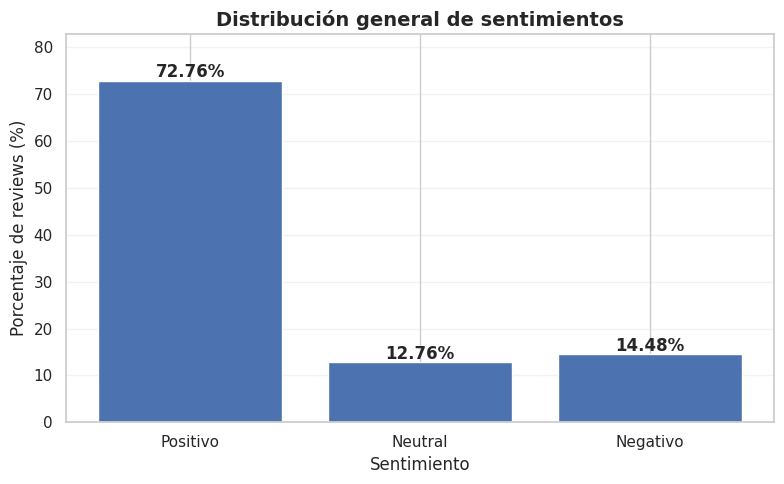

In [316]:
##Grafico: Distribucion general de sentimientos
# Crear gráfico
plt.figure(figsize=(8, 5))
barras = plt.bar(porcentaje_sentimiento.index,porcentaje_sentimiento.values)

# Título y etiquetas
plt.title("Distribución general de sentimientos",fontsize=14,fontweight="bold")
plt.ylabel("Porcentaje de reviews (%)")
plt.xlabel("Sentimiento")

# Mostrar porcentaje sobre cada barra
for barra, valor in zip(barras,porcentaje_sentimiento.values):
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 0.8,
        f"{valor:.2f}%",
        ha="center",
        fontweight="bold")

# Límite para dejar espacio a las etiquetas
plt.ylim(0,porcentaje_sentimiento.max() + 10)
plt.grid(axis="y",alpha=0.25)
plt.tight_layout()
plt.show()

**Satisfaccion por distritos**

In [317]:
# Unimos las reviews con la información del restaurante
df_dashboard_distrito = df_reviews_model.merge(df_restaurantes[["id", "district"]],left_on="service",right_on="id",how="left")

#Metricas por distrito
metricas_distrito = (df_dashboard_distrito.groupby("district")
                                          .agg( n_reviews=("score", "size"),score_promedio=("score", "mean"),
                                          pct_positivo=("sentiment",lambda x: (x == "POS").mean() * 100)).reset_index())

# Ordenamos inicialmente por cantidad de reviews
metricas_distrito = (metricas_distrito.sort_values("n_reviews",ascending=False).reset_index(drop=True))

#Revisamos los resultados
print("=" * 70)
print("MÉTRICAS DE SATISFACCIÓN POR DISTRITO")
print("=" * 70)
print(f"Distritos analizados: {len(metricas_distrito):,}")
print("\nDistribución de reviews por distrito:")
print(metricas_distrito["n_reviews"].describe(percentiles=[0.10,0.25,0.50,0.75,0.90]))
print("\nDistritos con mayor volumen de reviews:")
display(metricas_distrito.head(10))

MÉTRICAS DE SATISFACCIÓN POR DISTRITO
Distritos analizados: 43

Distribución de reviews por distrito:
count        43.000000
mean      13234.930233
std       18258.089343
min         128.000000
10%        1408.600000
25%        2470.000000
50%        8335.000000
75%       17710.500000
90%       27910.400000
max      111854.000000
Name: n_reviews, dtype: float64

Distritos con mayor volumen de reviews:


,district,n_reviews,score_promedio,pct_positivo
0,MIRAFLORES,111854,4.158805,75.681692
1,SANTIAGO DE SURCO,34042,4.045179,70.495271
2,SAN ISIDRO,33770,4.198845,75.940184
3,JESUS MARIA,29022,4.080628,71.604300
4,SAN BORJA,28455,4.149253,73.111931
5,SAN MIGUEL,25732,4.080445,70.041194
6,BARRANCO,25563,4.275320,79.771545
7,LIMA,24143,4.085242,72.882409
8,LA MOLINA,21301,4.053706,69.616450
9,LOS OLIVOS,19090,4.045521,70.392876


**1. Validacion de la Muestra**
* **Cobertura total:** Se analizaron **43 distritos** en total.
* **Representatividad:** El distrito con menor representación cuenta con **128 reviews**.
* **Volumen general:** La mediana se sitúa en **8,335 reviews**, lo que asegura una buena cobertura general.

**2. Criterio de Filtrado**

A diferencia de los restaurantes individuales, para el análisis distrital se establece un **umbral mínimo de 1,000 reviews**:
* **Ventaja:** Elimina distritos con evidencia muy limitada.
* **Diversidad:** Conserva practicamente toda la variedad geografica.
* **Justificacion:** Es un criterio simple y directo para explicar en la redacción del TFM.

**3. Hallazgo Clave: Volumen vs. Satisfaccion**
Los datos demuestran la importancia de separar el volumen de las opiniones de la satisfacción real:
* **Miraflores:** Domina ampliamente en volumen con **111,854 reviews**.
* **Barranco:** Supera en satisfacción con un **79.77% positivo** y un score de **4.28**.
* **San Isidro:** Registra un **75.94% positivo** y un score de **4.20**.


In [318]:
##Ranking de satisfaccion por distrito
MIN_REVIEWS_DISTRITO = 1000

# Filtrar distritos con evidencia suficiente
distritos_validos = (metricas_distrito[metricas_distrito["n_reviews"] >= MIN_REVIEWS_DISTRITO].copy())

# Ordenar por porcentaje de sentimiento positivo
ranking_distritos = (distritos_validos.sort_values("pct_positivo",ascending=False).reset_index(drop=True))

# Mostramos los resultados
print("=" * 70)
print("RANKING DE SATISFACCIÓN POR DISTRITO")
print("=" * 70)
print(f"Umbral mínimo: {MIN_REVIEWS_DISTRITO:,} reviews")
print(f"Distritos incluidos: {len(ranking_distritos):,} "  f"de {len(metricas_distrito):,}")
print("\nTop 10 distritos por sentimiento positivo:")
display(ranking_distritos[["district","n_reviews","score_promedio","pct_positivo"]].head(10))

RANKING DE SATISFACCIÓN POR DISTRITO
Umbral mínimo: 1,000 reviews
Distritos incluidos: 40 de 43

Top 10 distritos por sentimiento positivo:


,district,n_reviews,score_promedio,pct_positivo
0,BARRANCO,25563,4.275320,79.771545
1,PUNTA HERMOSA,1591,4.114393,78.252671
2,SANTA MARIA DEL MAR,1363,4.311812,77.622891
3,CHACLACAYO,2460,4.111382,76.260163
4,SAN ISIDRO,33770,4.198845,75.940184
5,PACHACAMAC,1734,4.121107,75.893887
6,MIRAFLORES,111854,4.158805,75.681692
7,CARABAYLLO,4063,4.113463,75.092296
8,VILLA EL SALVADOR,6503,4.123481,74.980778
9,ANCON,2267,4.180415,74.724305


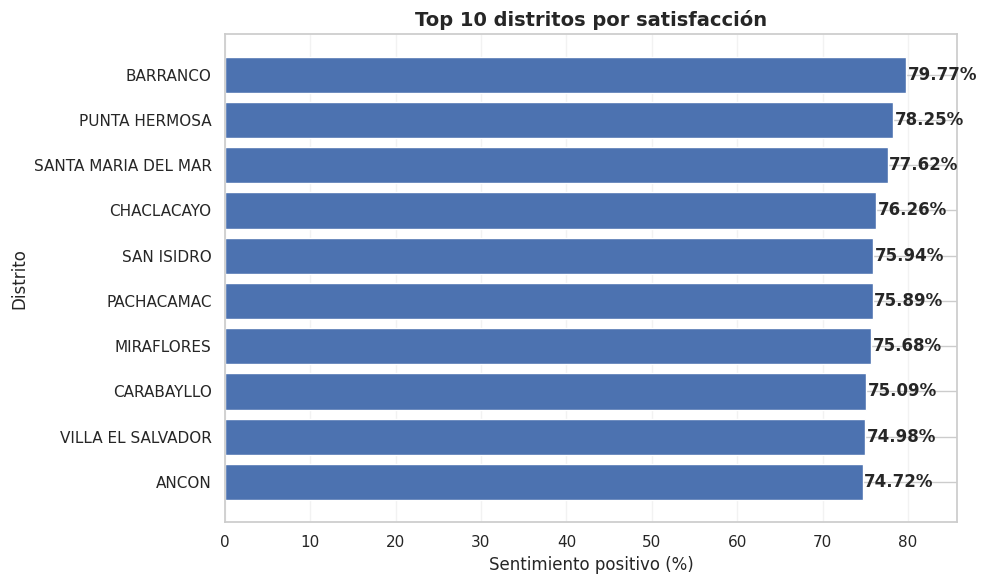

In [319]:
##Graficamos el TOP 10 de distritos de satisfaccion

# Seleccionar Top 10
top10_distritos = (ranking_distritos.head(10).copy())

# Invertimos el orden para que el mejor aparezca arriba
top10_distritos = top10_distritos.iloc[::-1]

# Crear gráfico
plt.figure(figsize=(10, 6))
barras = plt.barh(top10_distritos["district"],top10_distritos["pct_positivo"])

# Título y etiquetas
plt.title("Top 10 distritos por satisfacción",fontsize=14,fontweight="bold")
plt.xlabel("Sentimiento positivo (%)")
plt.ylabel("Distrito")

# Mostrar porcentaje al final de cada barra
for barra, valor in zip(barras,top10_distritos["pct_positivo"]):
    plt.text(valor + 0.15,barra.get_y() + barra.get_height() / 2,f"{valor:.2f}%",va="center",fontweight="bold")

# Ajustar escala
plt.xlim(0,top10_distritos["pct_positivo"].max() + 6)

# Cuadrícula
plt.grid(axis="x",alpha=0.25)
plt.tight_layout()
plt.show()

**Satisfaccion por categoria gastronomica**

In [320]:
# Unimos reviews con la categoría del restaurante
df_dashboard_categoria = df_reviews_model.merge( df_restaurantes[["id", "tag"]],left_on="service",right_on="id",how="left")

#Metricas por categoria
metricas_categoria = (df_dashboard_categoria.groupby("tag")
                      .agg(n_reviews=("score", "size"),score_promedio=("score", "mean"),
                      pct_positivo=("sentiment",lambda x: (x == "POS").mean() * 100)).reset_index())

# Ordenar inicialmente por volumen
metricas_categoria = (metricas_categoria.sort_values("n_reviews",ascending=False).reset_index(drop=True))

# Mostramos los resultados
print("=" * 70)
print("MÉTRICAS DE SATISFACCIÓN POR CATEGORÍA")
print("=" * 70)
print(f"Categorías analizadas: "  f"{len(metricas_categoria):,}")
print("\nDistribución de reviews por categoría:")
print(metricas_categoria["n_reviews"].describe(percentiles=[0.10,0.25,0.50,0.75,0.90]))
print("\nCategorías con mayor volumen de reviews:")
display(metricas_categoria[["tag","n_reviews","score_promedio","pct_positivo"]].head(15))

MÉTRICAS DE SATISFACCIÓN POR CATEGORÍA
Categorías analizadas: 23

Distribución de reviews por categoría:
count        23.000000
mean      24743.565217
std       33173.269039
min          53.000000
10%        1873.800000
25%        4049.000000
50%       12780.000000
75%       34482.500000
90%       43183.800000
max      158626.000000
Name: n_reviews, dtype: float64

Categorías con mayor volumen de reviews:


,tag,n_reviews,score_promedio,pct_positivo
0,Restaurante (No especificado),158626,4.114893,73.105922
1,Pollería,52896,3.955101,67.568436
2,Restaurante peruano,43897,4.121922,73.863818
3,Peruana,40331,4.179192,83.342838
4,Marisquería,36642,4.113722,74.166257
5,Comida rápida,35379,3.853133,57.240171
6,Chifa / Comida China,33586,3.992616,72.062764
7,Pizzería,29142,4.013863,66.838240
8,Otros / No Gastronómico,25485,4.224367,67.926231
9,Cafetería,23903,4.319876,78.061331


**1. Diagnostico de la Distribucion**
* **Volumen total:** Se identificaron **23 categorías** gastronomicas.
* **Muestra general:** La mediana es alta, situandose en **12,780 reviews**.
* **Dispersion:** Existe una gran amplitud; la categoria menos representada cuenta con solo **53 reviews**.

**2. Definicion del Umbral de Inclusion**
Para dar solidez a los rankings y mantener la coherencia con el analisis distrital:
* **Regla:** Se establece un **umbral minimo de 1,000 reviews** por categoria.
* **Sustento estadistico:** El percentil 10 se ubica en **1,873.8 reviews**, lo que garantiza que este límite conservará la gran mayoría de las categorías.
* **Objetivo:** Evitar que el ranking sea distorsionado por categorías con evidencia estadística limitada.


In [321]:
##Ranking de satisfaccion de categoria
MIN_REVIEWS_CATEGORIA = 1000

# Categorías genéricas que no utilizaremos en el ranking gastronómico
categorias_excluir = ["Restaurante (No especificado)","Otros / No Gastronómico"]

# Filtrar categorías con evidencia suficiente y categorías gastronómicas identificables
categorias_validas = (metricas_categoria[(metricas_categoria["n_reviews"] >= MIN_REVIEWS_CATEGORIA) &
                                        (~metricas_categoria["tag"].isin(categorias_excluir))].copy())

# Ordenar por porcentaje de sentimiento positivo
ranking_categorias = (categorias_validas.sort_values("pct_positivo",ascending=False).reset_index(drop=True))

# Mostramos los resultados
print("=" * 70)
print("RANKING DE SATISFACCIÓN POR CATEGORÍA")
print("=" * 70)
print(f"Umbral mínimo: {MIN_REVIEWS_CATEGORIA:,} reviews")
print(f"Categorías incluidas: {len(ranking_categorias):,} "  f"de {len(metricas_categoria):,}")
print("\nNota: se excluyen del ranking visual las categorías "
    "'Restaurante (No especificado)' y "
    "'Otros / No Gastronómico'.")
print("\nTop 10 categorías por sentimiento positivo:")
display(ranking_categorias[["tag","n_reviews","score_promedio","pct_positivo"]].head(10))

RANKING DE SATISFACCIÓN POR CATEGORÍA
Umbral mínimo: 1,000 reviews
Categorías incluidas: 19 de 23

Nota: se excluyen del ranking visual las categorías 'Restaurante (No especificado)' y 'Otros / No Gastronómico'.

Top 10 categorías por sentimiento positivo:


,tag,n_reviews,score_promedio,pct_positivo
0,Peruana,40331,4.179192,83.342838
1,Restaurante saludable,3746,4.265884,81.927389
2,Italiana,12780,4.162676,80.837246
3,Comida Latina / Internacional,8655,4.165338,79.318313
4,Bar / Pub,8790,4.280432,78.339022
5,Cafetería,23903,4.319876,78.061331
6,Panadería / Pastelería,11304,4.272647,77.521231
7,Heladería,3905,4.324456,77.516005
8,Parrilla / Carnes,11941,4.175865,77.321832
9,Sushi / Japonesa,18444,4.185155,75.921709


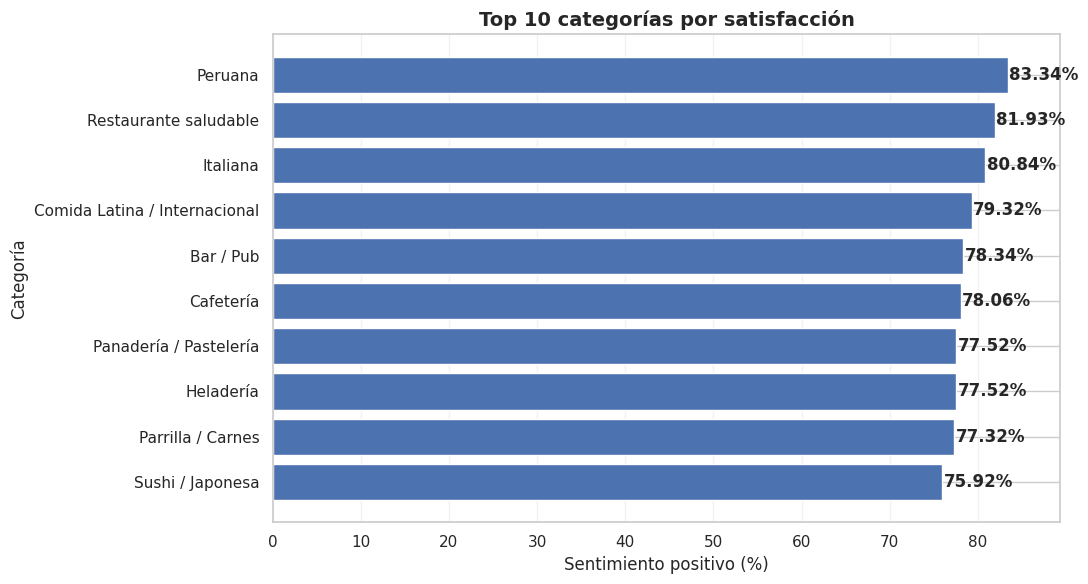

In [322]:
##Grafica: TOP 10 categorias por satisfaccion
# Seleccionar Top 10
top10_categorias = (ranking_categorias.head(10).copy())

# Invertimos el orden para que la mejor aparezca arriba
top10_categorias = top10_categorias.iloc[::-1]

# Crear grafico
plt.figure(figsize=(11, 6))
barras = plt.barh(top10_categorias["tag"],top10_categorias["pct_positivo"])

# Titulo y etiquetas
plt.title("Top 10 categorías por satisfacción",fontsize=14,fontweight="bold")
plt.xlabel("Sentimiento positivo (%)")
plt.ylabel("Categoría")

# Mostrar porcentaje al final de cada barra
for barra, valor in zip(barras,top10_categorias["pct_positivo"]):
    plt.text(valor + 0.15,
        barra.get_y() + barra.get_height() / 2,
        f"{valor:.2f}%",
        va="center",
        fontweight="bold")

# Ajustar escala
plt.xlim(0,top10_categorias["pct_positivo"].max() + 6)

# Cuadrícula
plt.grid(axis="x",alpha=0.25)
plt.tight_layout()
plt.show()

**Satisfaccion por aspectos**

In [326]:
# Metricas para el dashboard
metricas_aspectos_dashboard = (df_aspectos_expandido.groupby("aspectos")
                                                    .agg(n_menciones=("sentiment", "size"),
                                                      n_pos=("sentiment",lambda x: (x == "POS").sum()),
                                                      n_neu=("sentiment",lambda x: (x == "NEU").sum() ),
                                                      n_neg=("sentiment",lambda x: (x == "NEG").sum())).reset_index())

#Porcentajes
metricas_aspectos_dashboard["pct_pos"] = (metricas_aspectos_dashboard["n_pos"] / metricas_aspectos_dashboard["n_menciones"] * 100)
metricas_aspectos_dashboard["pct_neu"] = (metricas_aspectos_dashboard["n_neu"] / metricas_aspectos_dashboard["n_menciones"] * 100)
metricas_aspectos_dashboard["pct_neg"] = (metricas_aspectos_dashboard["n_neg"] / metricas_aspectos_dashboard["n_menciones"] * 100)

# Ordenar por número de menciones
metricas_aspectos_dashboard = (metricas_aspectos_dashboard.sort_values("n_menciones",ascending=False).reset_index(drop=True))

# Mostramos los resultados
print("=" * 70)
print("SATISFACCIÓN POR ASPECTO")
print("=" * 70)
display( metricas_aspectos_dashboard[["aspectos","n_menciones","pct_pos","pct_neu","pct_neg"]])

SATISFACCIÓN POR ASPECTO


,aspectos,n_menciones,pct_pos,pct_neu,pct_neg
0,comida,205357,78.018280,8.098093,13.883627
1,atencion,182585,76.639921,7.257442,16.102637
2,precio,70709,72.560777,10.901017,16.538206
3,ambiente,63275,88.156460,5.016199,6.827341
4,tiempo_espera,41071,62.735263,15.288160,21.976577
5,bebidas,28796,78.132379,8.542853,13.324767
6,calidad,24792,71.176186,7.813004,21.010810
7,ubicacion,21348,77.604459,10.998688,11.396852
8,porciones,14810,71.093856,11.802836,17.103309


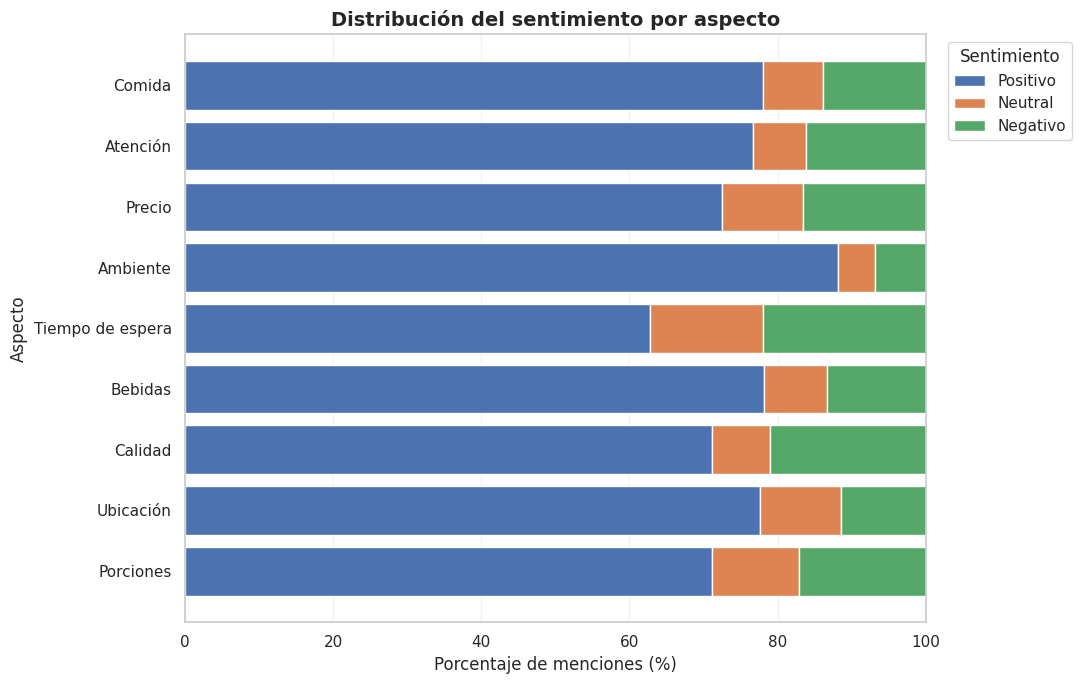

In [328]:
##Grafico de satisfaccion por aspecto
aspectos_grafico = metricas_aspectos_dashboard.copy()

# Nombres mas amigables
nombres_aspectos = {
    "comida": "Comida",
    "atencion": "Atención",
    "precio": "Precio",
    "ambiente": "Ambiente",
    "tiempo_espera": "Tiempo de espera",
    "bebidas": "Bebidas",
    "calidad": "Calidad",
    "ubicacion": "Ubicación",
    "porciones": "Porciones"}

aspectos_grafico["aspecto_label"] = (aspectos_grafico["aspectos"].map(nombres_aspectos))

# Creamos graficos
plt.figure(figsize=(11, 7))

# Sentimiento positivo
plt.barh(aspectos_grafico["aspecto_label"],aspectos_grafico["pct_pos"],label="Positivo")

# Sentimiento neutral
plt.barh(aspectos_grafico["aspecto_label"],aspectos_grafico["pct_neu"],left=aspectos_grafico["pct_pos"],label="Neutral")

# Sentimiento negativo
plt.barh(aspectos_grafico["aspecto_label"],aspectos_grafico["pct_neg"],left=(aspectos_grafico["pct_pos"] + aspectos_grafico["pct_neu"]),label="Negativo")

# Invertir eje para mantener el aspecto con mayor numero de menciones arriba
plt.gca().invert_yaxis()

# Título y etiquetas
plt.title("Distribución del sentimiento por aspecto",fontsize=14,fontweight="bold")
plt.xlabel("Porcentaje de menciones (%)")
plt.ylabel("Aspecto")

# Escala porcentual
plt.xlim(0, 100)

# Leyenda
plt.legend(title="Sentimiento",bbox_to_anchor=(1.02, 1),loc="upper left")

# Cuadrícula
plt.grid(axis="x",alpha=0.25)
plt.tight_layout()
plt.show()


El estudio evalua la distribución del sentimiento (**positivo, neutral y negativo**) en las reseñas (Reviews) para identificar qué factores impactan más en la experiencia del usuario.

**Aspectos Mejor Valorados**
* **Ambiente:** Registra la percepción más favorable de todo el análisis.
  * **Sentimiento positivo:** 88.16%
  * **Sentimiento negativo:** 6.83%

**Componentes Críticos (Mayor Volumen de Menciones)**

Tanto la **Comida** como la **Atención** concentran la mayor cantidad de opiniones, manteniendo niveles saludables de aprobación:
* **Comida:** 78.02% de sentimiento positivo.
* **Atención:** 76.64% de sentimiento positivo.

Los datos demuestran de forma cuantitativa que la satisfacción final del cliente es **multidimensional**. No se limita exclusivamente al producto principal (la comida), sino que está fuertemente sujeta a la gestion del entorno (ambiente), el servicio (atencion), la eficiencia operativa (tiempos) y la relación valor/precio (calidad percibida).


**Top restaurantes**

In [330]:
# Top de restaurantes segun valoracion ajustada
MIN_REVIEWS_TOP = 50

# Filtrar restaurantes con evidencia suficiente y excluir establecimientos no gastronómicos
top_restaurantes_dashboard = ( df_recomendador[(df_recomendador["n_reviews_dataset"] >= MIN_REVIEWS_TOP) &
                                                (df_recomendador["tag"] != "Otros / No Gastronómico")].copy())
# Ordenar según weighted rating
top_restaurantes_dashboard = (top_restaurantes_dashboard.sort_values("weighted_rating",ascending=False).reset_index(drop=True))

#Mostramos los resultados
print("=" * 70)
print("TOP RESTAURANTES SEGÚN VALORACIÓN AJUSTADA")
print("=" * 70)
print(f"Umbral mínimo: {MIN_REVIEWS_TOP} reviews")
print(f"Restaurantes elegibles: "  f"{len(top_restaurantes_dashboard):,}")
display(top_restaurantes_dashboard[["name","tag","district","n_reviews_dataset","score_promedio","weighted_rating","pct_pos"]].head(10))

TOP RESTAURANTES SEGÚN VALORACIÓN AJUSTADA
Umbral mínimo: 50 reviews
Restaurantes elegibles: 2,312


,name,tag,district,n_reviews_dataset,score_promedio,weighted_rating,pct_pos
0,La Masita,Heladería,SAN MIGUEL,133,5.000000,4.734301,100.000000
1,Blu Gelateria,Heladería,BARRANCO,596,4.718121,4.665311,94.798658
2,Club de Regatas Lima,Bar / Pub,CHORRILLOS,717,4.701534,4.658193,94.700139
3,Aji 555 Real Thai Cuisine,Sushi / Japonesa,SAN BORJA,326,4.708589,4.619850,94.785276
4,IK Restaurante,Peruana,MIRAFLORES,1028,4.644942,4.616958,93.093385
5,Museo Larco Café-Restaurant,Cafetería,PUEBLO LIBRE,476,4.670168,4.610494,93.067227
6,JOVA,Restaurante (No especificado),PUEBLO LIBRE,155,4.787097,4.605606,96.774194
7,Chicharrones el canario,Restaurante (No especificado),VILLA EL SALVADOR,70,5.000000,4.601451,100.000000
8,Yogashi Patisserie,Cafetería,SAN BORJA,255,4.709804,4.600588,95.686275
9,Limapostre Santiago de Surco.,Heladería,SANTIAGO DE SURCO,104,4.865385,4.598643,99.038462


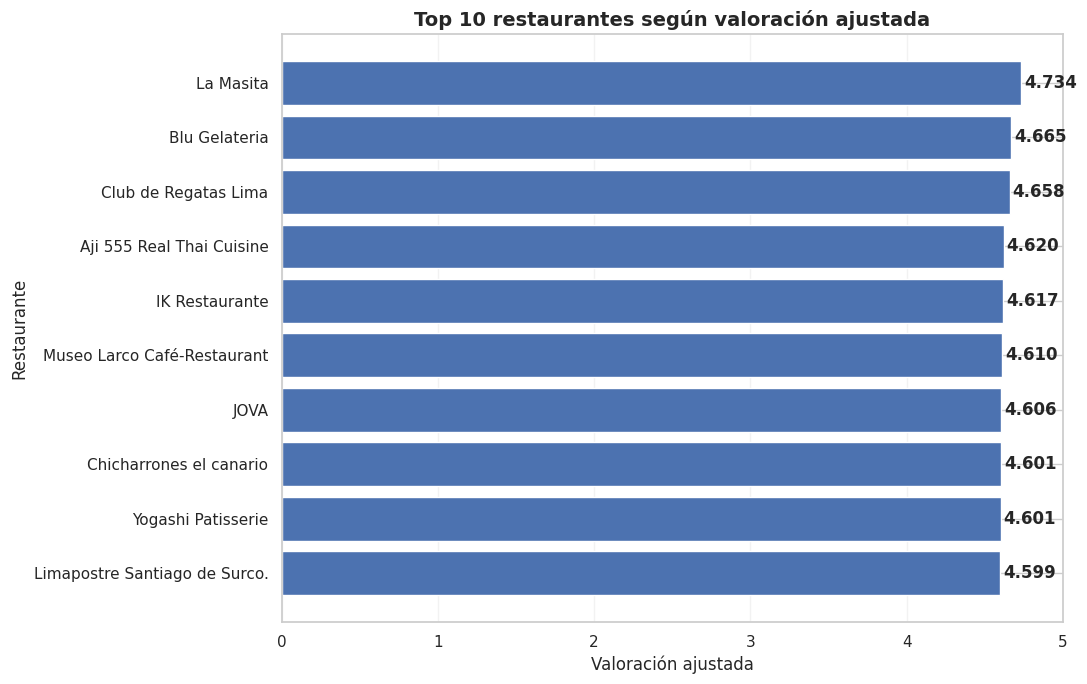

In [331]:
##Grafica TOP 10 de restaurantes
# Seleccionar Top 10
top10_restaurantes = (top_restaurantes_dashboard.head(10).copy())

# Invertir orden para mostrar el restaurante mejor valorado arriba
top10_restaurantes = top10_restaurantes.iloc[::-1]

# Creamos el grafico
plt.figure(figsize=(11, 7))
barras = plt.barh(top10_restaurantes["name"],top10_restaurantes["weighted_rating"])

# Título y etiquetas
plt.title("Top 10 restaurantes según valoración ajustada",fontsize=14,fontweight="bold")
plt.xlabel("Valoración ajustada")
plt.ylabel("Restaurante")

# Mostrar valoración al final de cada barra
for barra, valor in zip(barras,top10_restaurantes["weighted_rating"]):
    plt.text(valor + 0.02,
        barra.get_y() + barra.get_height() / 2,
        f"{valor:.3f}",
        va="center",
        fontweight="bold")

# Escala completa de valoración
plt.xlim(0, 5)

# Cuadrícula
plt.grid(axis="x",alpha=0.25)
plt.tight_layout()
plt.show()

Para identificar los restaurantes con mejor desempeño se utilizo la
**valoración ajustada (Weighted Rating)**, en lugar de ordenar únicamente
los establecimientos según su valoración promedio.

Esta metrica considera tanto la puntuacion promedio del restaurante como
el volumen de reseñas disponibles, reduciendo el efecto que pueden producir
establecimientos con puntuaciones elevadas sustentadas en pocas opiniones.

Para garantizar un volumen minimo de evidencia, se consideraron unicamente
restaurantes con al menos **50 reseñas**. Asimismo, se excluyeron del ranking los establecimientos pertenecientes a la categoría
**"Otros / No Gastronómico"**.

Bajo este criterio, **La Masita** ocupa la primera posicion con una
valoracion ajustada de **4.734**, seguida de **Blu Gelateria (4.665)** y
**Club de Regatas Lima (4.658)**.

El ranking permite identificar establecimientos con un desempeño favorable
considerando simultaneamente la valoracion recibida y la cantidad de
opiniones disponibles.

##### **5.2. DashBoard Interactivo**

In [332]:
##Importamos las librerias
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
import matplotlib.pyplot as plt

# Selector de visualizacion
widget_visualizacion = widgets.Dropdown(
    options=[
        "Distribución general de sentimientos",
        "Satisfacción por distrito",
        "Satisfacción por categoría",
        "Satisfacción por aspecto",
        "Top restaurantes"],
    value="Distribución general de sentimientos",
    description="Visualización:",
    style={"description_width": "120px"},
    layout=widgets.Layout(width="430px"))

boton_dashboard = widgets.Button(
    description="Mostrar análisis",
    button_style="info",
    icon="bar-chart",
    layout=widgets.Layout(
        width="220px",
        height="40px"))

salida_dashboard = widgets.Output()

In [335]:
##Creamos la funcion para el dashboard

def mostrar_dashboard(b):

    with salida_dashboard:
        clear_output(wait=True)
        opcion = widget_visualizacion.value

        # Distribucion general del sentimiento

        if opcion == "Distribución general de sentimientos":
            plt.figure(figsize=(8, 5))
            barras = plt.bar(porcentaje_sentimiento.index,porcentaje_sentimiento.values)
            plt.title("Distribución general de sentimientos",fontsize=14,fontweight="bold")
            plt.ylabel("Porcentaje de reviews (%)")
            plt.xlabel("Sentimiento")

            for barra, valor in zip(barras,porcentaje_sentimiento.values):

                plt.text(barra.get_x() + barra.get_width() / 2,
                    barra.get_height() + 0.8,
                    f"{valor:.2f}%",
                    ha="center",
                    fontweight="bold")

            plt.ylim(0,porcentaje_sentimiento.max() + 10)
            plt.grid(axis="y",alpha=0.25)
            plt.tight_layout()
            plt.show()

        # Satisfaccion por distrito
        elif opcion == "Satisfacción por distrito":
            datos = (ranking_distritos.head(10).copy().iloc[::-1])

            #Grafica
            plt.figure(figsize=(10, 6))
            barras = plt.barh(datos["district"],datos["pct_positivo"])
            plt.title("Top 10 distritos por satisfacción",fontsize=14,fontweight="bold")
            plt.xlabel("Sentimiento positivo (%)")
            plt.ylabel("Distrito")

            for barra, valor in zip(barras,datos["pct_positivo"]):
                plt.text(valor + 0.15,
                    barra.get_y() + barra.get_height() / 2,
                    f"{valor:.2f}%",
                    va="center",
                    fontweight="bold")

            plt.xlim(0,datos["pct_positivo"].max() + 6)
            plt.grid(axis="x",alpha=0.25)
            plt.tight_layout()
            plt.show()

        # Satisfaccion por categoria
        elif opcion == "Satisfacción por categoría":
            datos = (ranking_categorias.head(10).copy().iloc[::-1])

            #Grafica
            plt.figure(figsize=(11, 6))
            barras = plt.barh(datos["tag"],datos["pct_positivo"])
            plt.title("Top 10 categorías por satisfacción",fontsize=14,fontweight="bold")
            plt.xlabel("Sentimiento positivo (%)")
            plt.ylabel("Categoría")

            for barra, valor in zip(barras,datos["pct_positivo"]):
                plt.text(valor + 0.15,
                    barra.get_y() + barra.get_height() / 2,
                    f"{valor:.2f}%",
                    va="center",
                    fontweight="bold")

            plt.xlim(0,datos["pct_positivo"].max() + 6)
            plt.grid(axis="x",alpha=0.25)
            plt.tight_layout()
            plt.show()

        # satisfaccion por aspecto

        elif opcion == "Satisfacción por aspecto":

            datos = metricas_aspectos_dashboard.copy()

            nombres_aspectos = {
                "comida": "Comida",
                "atencion": "Atención",
                "precio": "Precio",
                "ambiente": "Ambiente",
                "tiempo_espera": "Tiempo de espera",
                "bebidas": "Bebidas",
                "calidad": "Calidad",
                "ubicacion": "Ubicación",
                "porciones": "Porciones"}

            datos["aspecto_label"] = (datos["aspecto"].map(nombres_aspectos))

            #Grafica
            plt.figure(figsize=(11, 7))
            plt.barh(datos["aspecto_label"],datos["pct_pos"],label="Positivo")
            plt.barh(datos["aspecto_label"],datos["pct_neu"],left=datos["pct_pos"],label="Neutral")
            plt.barh(datos["aspecto_label"],datos["pct_neg"],left=(datos["pct_pos"] + datos["pct_neu"]),label="Negativo")
            plt.gca().invert_yaxis()
            plt.title("Distribución del sentimiento por aspecto",fontsize=14,fontweight="bold")
            plt.xlabel("Porcentaje de menciones (%)")
            plt.ylabel("Aspecto")
            plt.xlim(0, 100)
            plt.legend(title="Sentimiento",bbox_to_anchor=(1.02, 1),loc="upper left")
            plt.grid(axis="x",alpha=0.25)
            plt.tight_layout()
            plt.show()

        # Top de restaurantes
        elif opcion == "Top restaurantes":
            datos = (top_restaurantes_dashboard.head(10).copy().iloc[::-1])

            #Grafica
            plt.figure(figsize=(11, 7))
            barras = plt.barh(datos["name"],datos["weighted_rating"])
            plt.title("Top 10 restaurantes según valoración ajustada",fontsize=14,fontweight="bold")
            plt.xlabel("Valoración ajustada")
            plt.ylabel("Restaurante")

            for barra, valor in zip(barras,datos["weighted_rating"]):
                plt.text(valor + 0.02,
                    barra.get_y() + barra.get_height() / 2,
                    f"{valor:.3f}",
                    va="center",
                    fontweight="bold")

            plt.xlim(0, 5)
            plt.grid(axis="x",alpha=0.25)
            plt.tight_layout()
            plt.show()

##Creamos el boton para el dashboard
boton_dashboard._click_handlers.callbacks = []
boton_dashboard.on_click(mostrar_dashboard)

In [ ]:
##Mostrar DashBoard Final
titulo_dashboard = widgets.HTML(
    value="""
    <h2>Dashboard de satisfacción gastronómica</h2>

    <p>
    Explora los principales resultados obtenidos
    a partir del análisis de reseñas de restaurantes.
    </p>
    """)

display(titulo_dashboard)

# Tarjetas KPI
display(HTML(html_kpis))

# Selector
display(widget_visualizacion,boton_dashboard,salida_dashboard)